<a href="https://colab.research.google.com/github/GaneshUppananthala2005/Akash-6G-/blob/main/stage_2_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# AKASH-6G — CELL 1
# Environment check
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

try:
    import torch
    print("PyTorch:", torch.__version__)
except Exception as e:
    print("PyTorch import error:", e)

print("\nEnvironment ready.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3
Pandas: 2.2.3
PyTorch: 2.11.0+cpu

Environment ready.


In [ ]:
# ============================================================
# AKASH-6G — CELL 2
# DOUBLE-DQN CONFIGURATION
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

PREP_DIR = "/content/AKASH6G_DQN_Prepared"

OUTPUT_DIR = "/content/AKASH6G_DoubleDQN_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_best.pt"
)

FINAL_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_final.pt"
)

# ------------------------------------------------------------
# Dataset parameters
# ------------------------------------------------------------

NUM_BEAMS = 4

DT_MS = 20
PREDICTION_HORIZON_MS = 200

H_STEPS = PREDICTION_HORIZON_MS // DT_MS

print("Prediction steps:", H_STEPS)

# ------------------------------------------------------------
# DQN parameters
# ------------------------------------------------------------

STATE_DIM = 19
ACTION_DIM = 4

GAMMA = 0.95

LEARNING_RATE = 1e-3

BATCH_SIZE = 256

REPLAY_CAPACITY = 100_000

MIN_REPLAY_SIZE = 5_000

TARGET_UPDATE_EVERY = 1_000

TRAIN_EVERY = 1

NUM_EPOCHS = 12

# ------------------------------------------------------------
# Exploration
# ------------------------------------------------------------

EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995

# ------------------------------------------------------------
# Neural network
# ------------------------------------------------------------

HIDDEN_1 = 128
HIDDEN_2 = 128

# ------------------------------------------------------------
# Reward parameters
# ------------------------------------------------------------

SINR_THRESHOLD_DB = 5.0

W1 = 1.0
W2 = 0.5
W3 = 2.0

C_HO = 10.0
P_FAIL = 50.0

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Prediction steps: 10
Device: cpu


In [ ]:
# ============================================================
# FIND AKASH-6G CSV FILE IN COLAB
# ============================================================

import os

print("Searching /content for AKASH-6G CSV files...\n")

matches = []

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.lower().endswith(".csv"):
            matches.append(os.path.join(root, f))

if not matches:
    print("❌ No CSV file found under /content")
else:
    for path in matches:
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"✓ {path}")
        print(f"  Size: {size_mb:.2f} MB")

Searching /content for AKASH-6G CSV files...

✓ /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
  Size: 113.95 MB
✓ /content/sample_data/mnist_train_small.csv
  Size: 34.83 MB
✓ /content/sample_data/california_housing_test.csv
  Size: 0.29 MB
✓ /content/sample_data/mnist_test.csv
  Size: 17.44 MB
✓ /content/sample_data/california_housing_train.csv
  Size: 1.63 MB


In [ ]:
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

print("Using:")
print(DATA_PATH)

print(
    "Exists:",
    os.path.exists(DATA_PATH)
)

Using:
/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Exists: True


In [ ]:
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

import os
print("Using:", DATA_PATH)
print("Exists:", os.path.exists(DATA_PATH))

Using: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Exists: True


In [ ]:
import os

DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
PREP_DIR = "/content/AKASH6G_DQN_Prepared"

print("Dataset:", DATA_PATH)
print("Dataset exists:", os.path.exists(DATA_PATH))
print("Prepared folder:", PREP_DIR)

Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Dataset exists: True
Prepared folder: /content/AKASH6G_DQN_Prepared


In [ ]:
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

In [ ]:
# ============================================================
# AKASH-6G — FINAL DQN PREPROCESSING
# 5000 UE / 500000-row Physical Dataset
# ============================================================

import os
import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
OUTPUT_DIR = "/content/AKASH6G_DQN_Prepared"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("AKASH-6G DQN PREPROCESSING")
print("=" * 70)
print("Input:", DATA_PATH)
print("Exists:", os.path.exists(DATA_PATH))
print("Output:", OUTPUT_DIR)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(" Physical CSV was not found.")

# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------
print("\nLoading physical dataset...")

df = pd.read_csv(DATA_PATH)

print("Loaded shape:", df.shape)

# ------------------------------------------------------------
# 3. REQUIRED COLUMNS
# ------------------------------------------------------------
required = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
]

for b in range(4):
    required += [
        f"beam{b}_RSRP_dBm",
        f"beam{b}_SINR_dB",
    ]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f" Missing columns: {missing}")

print("✓ Required columns found")

# ------------------------------------------------------------
# 4. BASIC DATA AUDIT
# ------------------------------------------------------------
print("\nBasic audit:")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique UEs:", df["UE_ID"].nunique())
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

# ------------------------------------------------------------
# 5. CONVERT BEAM LABELS TO INTEGER 0..3
#    Supports both:
#       beam0 / beam1 / beam2 / beam3
#    and:
#       0 / 1 / 2 / 3
#    Future_Beam may contain -1 for invalid future targets.
# ------------------------------------------------------------
def beam_to_int(x, allow_invalid=False):

    if pd.isna(x):
        return -1 if allow_invalid else np.nan

    if isinstance(x, str):
        s = x.strip().lower()

        if s.startswith("beam"):
            s = s.replace("beam", "")

        try:
            v = int(float(s))
        except:
            return -1 if allow_invalid else np.nan
    else:
        try:
            v = int(x)
        except:
            return -1 if allow_invalid else np.nan

    if allow_invalid and v == -1:
        return -1

    if v not in [0, 1, 2, 3]:
        return -1 if allow_invalid else np.nan

    return v


df["Current_Beam"] = df["Current_Beam"].apply(beam_to_int)
df["Optimal_Beam"] = df["Optimal_Beam"].apply(beam_to_int)
df["Future_Beam"] = df["Future_Beam"].apply(
    lambda x: beam_to_int(x, allow_invalid=True)
)

# ------------------------------------------------------------
# 6. SORT BY UE AND TIME
# ------------------------------------------------------------
df = df.sort_values(
    ["UE_ID", "Time_ms"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. TIME-STEP CHECK
# ------------------------------------------------------------
dt_errors = []

for ue, g in df.groupby("UE_ID", sort=False):
    t = g["Time_ms"].to_numpy()

    if len(t) > 1:
        dt = np.diff(t)
        dt_errors.extend(np.abs(dt - 20.0))

max_dt_error = max(dt_errors) if dt_errors else 0.0

print("\nTime-step check:")
print("Maximum time-step error:", max_dt_error, "ms")

if max_dt_error > 1e-6:
    raise ValueError(" Time step is not consistently 20 ms.")

print("✓ Time step = 20 ms")

# ------------------------------------------------------------
# 8. 200-ms PREDICTION HORIZON
# ------------------------------------------------------------
DT_MS = 20
PREDICTION_MS = 200
H_STEPS = PREDICTION_MS // DT_MS

print("\nPrediction horizon:")
print("Time step:", DT_MS, "ms")
print("Prediction horizon:", PREDICTION_MS, "ms")
print("Prediction steps:", H_STEPS)

# ------------------------------------------------------------
# 9. VERIFY FUTURE BEAM
# ------------------------------------------------------------
print("\nChecking Future_Beam alignment...")

future_expected = np.full(len(df), -1, dtype=np.int8)

for ue, idx in df.groupby("UE_ID", sort=False).groups.items():

    idx = np.asarray(idx)
    idx = idx[np.argsort(df.loc[idx, "Time_ms"].to_numpy())]

    optimal = df.loc[idx, "Optimal_Beam"].to_numpy()

    if len(idx) > H_STEPS:
        future_expected[idx[:-H_STEPS]] = optimal[H_STEPS:]

future_valid = future_expected != -1

mismatch = (
    future_valid &
    (df["Future_Beam"].to_numpy() != future_expected)
)

future_mismatches = int(mismatch.sum())

print("Future-beam mismatches:", future_mismatches)

if future_mismatches != 0:
    raise ValueError(
        f" Future_Beam mismatch detected: {future_mismatches}"
    )

print("✓ Future_Beam = Optimal_Beam(t + 200 ms)")

# ------------------------------------------------------------
# 10. VERIFY VALID_FUTURE_TARGET
# ------------------------------------------------------------
valid_expected = future_expected != -1
valid_actual = df["Valid_Future_Target"].astype(int).to_numpy()

valid_mismatch = int(
    np.sum(valid_actual != valid_expected.astype(int))
)

print("Valid-target mismatches:", valid_mismatch)

if valid_mismatch != 0:
    raise ValueError(" Valid_Future_Target is inconsistent.")

print("✓ Valid_Future_Target is correct")

# ------------------------------------------------------------
# 11. VERIFY OPTIMAL BEAM = BEST RSRP AND SINR
# ------------------------------------------------------------
rsrp_cols = [f"beam{i}_RSRP_dBm" for i in range(4)]
sinr_cols = [f"beam{i}_SINR_dB" for i in range(4)]

best_rsrp = (
    df[rsrp_cols]
    .to_numpy()
    .argmax(axis=1)
)

best_sinr = (
    df[sinr_cols]
    .to_numpy()
    .argmax(axis=1)
)

optimal = df["Optimal_Beam"].to_numpy()

rsrp_accuracy = np.mean(best_rsrp == optimal) * 100
sinr_accuracy = np.mean(best_sinr == optimal) * 100

print("\nOptimal beam verification:")
print(f"Optimal vs RSRP argmax: {rsrp_accuracy:.3f}%")
print(f"Optimal vs SINR argmax: {sinr_accuracy:.3f}%")

if rsrp_accuracy < 99.999:
    raise ValueError(" Optimal_Beam is not equal to RSRP argmax.")

if sinr_accuracy < 99.999:
    raise ValueError(" Optimal_Beam is not equal to SINR argmax.")

print("✓ Optimal beam verified")

# ------------------------------------------------------------
# 12. VERIFY CURRENT RSRP / SINR LINK
# ------------------------------------------------------------
current = df["Current_Beam"].to_numpy()

current_rsrp = df["Current_RSRP_dBm"].to_numpy()
current_sinr = df["Current_SINR_dB"].to_numpy()

beam_rsrp = df[rsrp_cols].to_numpy()
beam_sinr = df[sinr_cols].to_numpy()

selected_rsrp = beam_rsrp[
    np.arange(len(df)),
    current
]

selected_sinr = beam_sinr[
    np.arange(len(df)),
    current
]

rsrp_error = np.max(
    np.abs(current_rsrp - selected_rsrp)
)

sinr_error = np.max(
    np.abs(current_sinr - selected_sinr)
)

print("\nCurrent beam linkage:")
print(f"Maximum Current_RSRP error: {rsrp_error:.6f} dB")
print(f"Maximum Current_SINR error: {sinr_error:.6f} dB")

if rsrp_error > 1e-4 or sinr_error > 1e-4:
    raise ValueError(" Current beam linkage failed.")

print("✓ Current beam RSRP/SINR linkage verified")

# ------------------------------------------------------------
# 13. REMOVE INVALID FUTURE TARGETS
# ------------------------------------------------------------
valid_df = df[
    df["Valid_Future_Target"].astype(int) == 1
].copy()

print("\nFuture-target filtering:")
print("Original rows:", len(df))
print("Valid rows:", len(valid_df))
print("Removed rows:", len(df) - len(valid_df))

# ------------------------------------------------------------
# 14. UE-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ------------------------------------------------------------
SEED = 42

rng = np.random.default_rng(SEED)

ues = np.sort(
    valid_df["UE_ID"].unique()
)

rng.shuffle(ues)

n_ues = len(ues)

n_train = int(0.70 * n_ues)
n_val = int(0.15 * n_ues)

train_ues = np.sort(ues[:n_train])
val_ues = np.sort(ues[n_train:n_train + n_val])
test_ues = np.sort(ues[n_train + n_val:])

print("\nUE split:")
print("Train UEs:", len(train_ues))
print("Validation UEs:", len(val_ues))
print("Test UEs:", len(test_ues))

# ------------------------------------------------------------
# 15. STATE FEATURES
# ------------------------------------------------------------
state_continuous = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
]

state_continuous += rsrp_cols
state_continuous += sinr_cols

print("\nContinuous state features:", len(state_continuous))

# 7 geometry/channel features
# + 4 RSRP
# + 4 SINR
# = 15 continuous features

# ------------------------------------------------------------
# 16. TRAIN-ONLY STANDARDIZATION
# ------------------------------------------------------------
train_mask = valid_df["UE_ID"].isin(train_ues)

train_cont = valid_df.loc[
    train_mask,
    state_continuous
].to_numpy(dtype=np.float32)

train_mean = train_cont.mean(axis=0)

train_std = train_cont.std(axis=0)

# Prevent divide-by-zero
train_std[train_std < 1e-8] = 1.0

print("✓ Standardization parameters calculated from TRAIN only")

# ------------------------------------------------------------
# 17. BUILD STATE FUNCTION
# ------------------------------------------------------------
def build_states(subset):

    X_cont = subset[
        state_continuous
    ].to_numpy(dtype=np.float32)

    X_cont = (
        X_cont - train_mean
    ) / train_std

    current_beams = subset[
        "Current_Beam"
    ].to_numpy(dtype=np.int64)

    one_hot = np.zeros(
        (len(subset), 4),
        dtype=np.float32
    )

    one_hot[
        np.arange(len(subset)),
        current_beams
    ] = 1.0

    X = np.concatenate(
        [X_cont, one_hot],
        axis=1
    ).astype(np.float32)

    y = subset[
        "Future_Beam"
    ].to_numpy(dtype=np.int64)

    return X, y

# ------------------------------------------------------------
# 18. CREATE TRAIN / VAL / TEST
# ------------------------------------------------------------
train_df = valid_df[
    valid_df["UE_ID"].isin(train_ues)
].copy()

val_df = valid_df[
    valid_df["UE_ID"].isin(val_ues)
].copy()

test_df = valid_df[
    valid_df["UE_ID"].isin(test_ues)
].copy()

X_train, y_train = build_states(train_df)
X_val, y_val = build_states(val_df)
X_test, y_test = build_states(test_df)

print("\nDataset shapes:")
print("Train X:", X_train.shape)
print("Train y:", y_train.shape)
print("Val X:  ", X_val.shape)
print("Val y:  ", y_val.shape)
print("Test X: ", X_test.shape)
print("Test y: ", y_test.shape)

# ------------------------------------------------------------
# 19. CHECK STATE DIMENSION
# ------------------------------------------------------------
STATE_DIM = X_train.shape[1]
NUM_ACTIONS = 4

print("\nDQN configuration:")
print("State dimension:", STATE_DIM)
print("Number of actions:", NUM_ACTIONS)

if STATE_DIM != 19:
    raise ValueError(
        f" Expected state dimension 19, got {STATE_DIM}"
    )

print("✓ State dimension = 19")

# ------------------------------------------------------------
# 20. SAVE FILES
# ------------------------------------------------------------
np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "AKASH6G_DQN_train.npz"
    ),
    X=X_train,
    y=y_train
)

np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "AKASH6G_DQN_val.npz"
    ),
    X=X_val,
    y=y_val
)

np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "AKASH6G_DQN_test.npz"
    ),
    X=X_test,
    y=y_test
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "train_mean.npy"
    ),
    train_mean
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "train_std.npy"
    ),
    train_std
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "train_ues.npy"
    ),
    train_ues
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "val_ues.npy"
    ),
    val_ues
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "test_ues.npy"
    ),
    test_ues
)

metadata = {
    "project": "AKASH-6G",
    "dataset_rows_original": int(len(df)),
    "valid_rows": int(len(valid_df)),
    "invalid_future_rows_removed": int(len(df) - len(valid_df)),
    "unique_ues": int(n_ues),
    "train_ues": int(len(train_ues)),
    "val_ues": int(len(val_ues)),
    "test_ues": int(len(test_ues)),
    "time_step_ms": DT_MS,
    "prediction_horizon_ms": PREDICTION_MS,
    "prediction_steps": int(H_STEPS),
    "state_dimension": int(STATE_DIM),
    "num_actions": NUM_ACTIONS,
    "action_labels": [
        "beam0",
        "beam1",
        "beam2",
        "beam3"
    ],
    "seed": SEED
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "metadata.json"
    ),
    "w"
) as f:
    json.dump(metadata, f, indent=2)

# ------------------------------------------------------------
# 21. FINAL VERIFICATION
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL PREPROCESSING VERIFICATION")
print("=" * 70)

expected_files = [
    "AKASH6G_DQN_train.npz",
    "AKASH6G_DQN_val.npz",
    "AKASH6G_DQN_test.npz",
    "train_mean.npy",
    "train_std.npy",
    "train_ues.npy",
    "val_ues.npy",
    "test_ues.npy",
    "metadata.json",
]

all_ok = True

for f in expected_files:

    path = os.path.join(
        OUTPUT_DIR,
        f
    )

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"✓ {f:35s} {size_mb:.2f} MB")
    else:
        print(f" {f}")
        all_ok = False

print("\n" + "=" * 70)

if all_ok:
    print(" READY FOR DOUBLE-DQN TRAINING: YES")
else:
    print(" PREPROCESSING INCOMPLETE")

print("=" * 70)

AKASH-6G DQN PREPROCESSING
Input: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Exists: True
Output: /content/AKASH6G_DQN_Prepared

Loading physical dataset...
Loaded shape: (500000, 25)
✓ Required columns found

Basic audit:
Rows: 500000
Columns: 25
Unique UEs: 5000
Missing values: 0
Duplicate rows: 0

Time-step check:
Maximum time-step error: 0.0 ms
✓ Time step = 20 ms

Prediction horizon:
Time step: 20 ms
Prediction horizon: 200 ms
Prediction steps: 10

Checking Future_Beam alignment...
Future-beam mismatches: 0
✓ Future_Beam = Optimal_Beam(t + 200 ms)
Valid-target mismatches: 0
✓ Valid_Future_Target is correct

Optimal beam verification:
Optimal vs RSRP argmax: 100.000%
Optimal vs SINR argmax: 100.000%
✓ Optimal beam verified

Current beam linkage:
Maximum Current_RSRP error: 0.000000 dB
Maximum Current_SINR error: 0.000000 dB
✓ Current beam RSRP/SINR linkage verified

Future-target filtering:
Original rows: 500000
Valid rows: 450000
Removed rows: 50000

UE split

AKASH-6G DOUBLE-DQN TRAINING
Device: cpu
Prepared data: /content/AKASH6G_DQN_Prepared
Physical CSV: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Output: /content/AKASH6G_DoubleDQN_Results

✓ All DQN preprocessing files found
✓ Physical CSV found

Prepared data:
Train: (315000, 19) (315000,)
Val:   (67500, 19) (67500,)
Test:  (67500, 19) (67500,)

State dimension: 19
Actions: 4

Loading physical CSV...
Physical dataset: (500000, 25)
✓ Physical data loaded

Valid RL samples: 450000
Future target verification: 100.000%
✓ Future_Beam = Optimal_Beam(t + 200 ms)

Building UE sequences...

✓ Double-DQN networks created
Parameters: 19588

Building RL transitions...
Transitions: 311500
State shape: (311500, 19)

Filling replay buffer...
Replay buffer: 5000

STARTING DOUBLE-DQN TRAINING
Epoch 01/12 | Loss: 9.993274 | Reward: -103.7273 | Epsilon: 0.9950
Epoch 02/12 | Loss: 3.753464 | Reward: -103.7244 | Epsilon: 0.9900
Epoch 03/12 | Loss: 4.759634 | Reward: -103.7191 | Epsilon

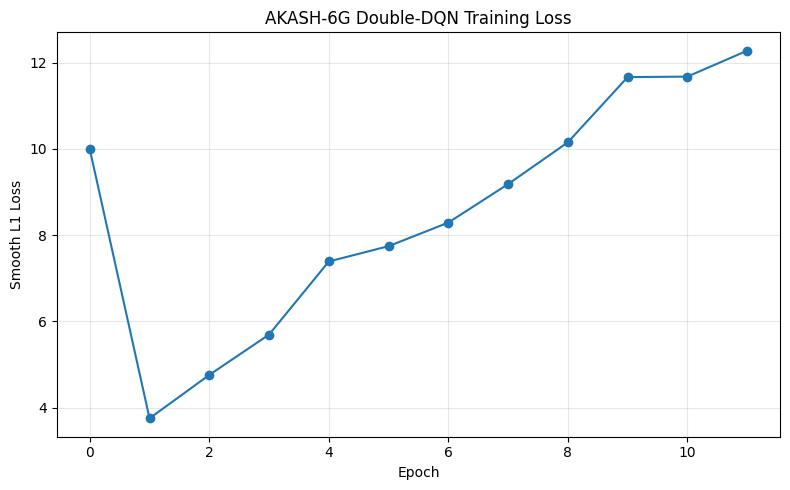

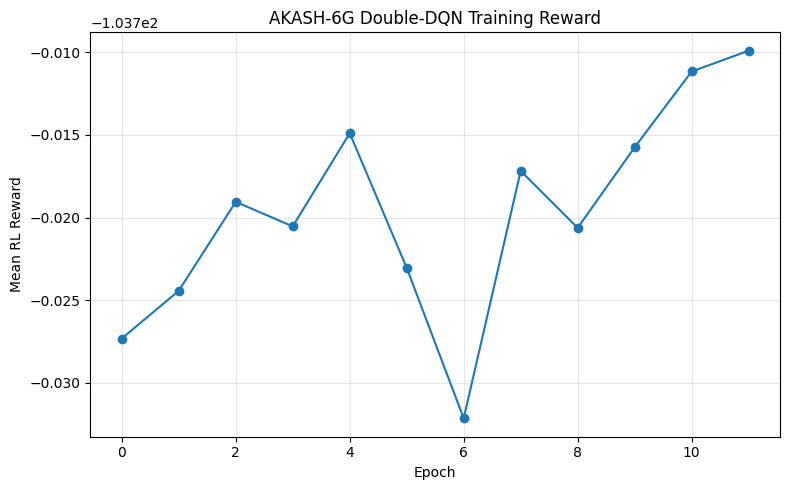


AKASH-6G DOUBLE-DQN SUMMARY
Physical dataset: (500000, 25)
Training samples: 315000
Validation samples: 67500
Test samples: 67500
State dimension: 19
Actions: 4
Test accuracy: 93.289%
Model: /content/AKASH6G_DoubleDQN_Results/AKASH6G_DoubleDQN_Model.pt
Results directory: /content/AKASH6G_DoubleDQN_Results
🎯 DOUBLE-DQN STAGE FINISHED


In [ ]:
# ============================================================
# AKASH-6G — COMPLETE DOUBLE-DQN TRAINING
# Predictive Beam Management with 200 ms Future Target
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from collections import deque

# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PREP_DIR = "/content/AKASH6G_DQN_Prepared"

DATA_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"

OUTPUT_DIR = "/content/AKASH6G_DoubleDQN_Results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("AKASH-6G DOUBLE-DQN TRAINING")
print("=" * 70)

print("Device:", DEVICE)
print("Prepared data:", PREP_DIR)
print("Physical CSV:", DATA_PATH)
print("Output:", OUTPUT_DIR)

# ============================================================
# 2. CHECK FILES
# ============================================================

required_files = [
    "AKASH6G_DQN_train.npz",
    "AKASH6G_DQN_val.npz",
    "AKASH6G_DQN_test.npz",
    "train_mean.npy",
    "train_std.npy",
    "train_ues.npy",
    "val_ues.npy",
    "test_ues.npy",
    "metadata.json"
]

for f in required_files:
    path = os.path.join(PREP_DIR, f)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f" Missing prepared file: {path}"
        )

print("\n✓ All DQN preprocessing files found")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f" Physical CSV not found: {DATA_PATH}"
    )

print("✓ Physical CSV found")

# ============================================================
# 3. LOAD PREPARED DATA
# ============================================================

train_npz = np.load(
    os.path.join(
        PREP_DIR,
        "AKASH6G_DQN_train.npz"
    )
)

val_npz = np.load(
    os.path.join(
        PREP_DIR,
        "AKASH6G_DQN_val.npz"
    )
)

test_npz = np.load(
    os.path.join(
        PREP_DIR,
        "AKASH6G_DQN_test.npz"
    )
)

X_train = train_npz["X"].astype(np.float32)
y_train = train_npz["y"].astype(np.int64)

X_val = val_npz["X"].astype(np.float32)
y_val = val_npz["y"].astype(np.int64)

X_test = test_npz["X"].astype(np.float32)
y_test = test_npz["y"].astype(np.int64)

print("\nPrepared data:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

STATE_DIM = X_train.shape[1]
NUM_ACTIONS = 4

print("\nState dimension:", STATE_DIM)
print("Actions:", NUM_ACTIONS)

if STATE_DIM != 19:
    raise ValueError(
        f"Expected state dimension 19, got {STATE_DIM}"
    )

# ============================================================
# 4. LOAD PHYSICAL DATA
# ============================================================

print("\nLoading physical CSV...")

df = pd.read_csv(DATA_PATH)

print("Physical dataset:", df.shape)

# Convert beam labels to integers
def beam_to_int(x, allow_invalid=False):

    if pd.isna(x):
        return -1 if allow_invalid else np.nan

    if isinstance(x, str):

        s = x.strip().lower()

        if s.startswith("beam"):
            s = s.replace("beam", "")

        try:
            x = int(float(s))
        except:
            return -1 if allow_invalid else np.nan

    else:

        try:
            x = int(x)
        except:
            return -1 if allow_invalid else np.nan

    if allow_invalid and x == -1:
        return -1

    if x not in [0, 1, 2, 3]:
        return -1 if allow_invalid else np.nan

    return x


df["Current_Beam"] = df["Current_Beam"].apply(
    beam_to_int
)

df["Optimal_Beam"] = df["Optimal_Beam"].apply(
    beam_to_int
)

df["Future_Beam"] = df["Future_Beam"].apply(
    lambda x: beam_to_int(
        x,
        allow_invalid=True
    )
)

df = df.sort_values(
    ["UE_ID", "Time_ms"]
).reset_index(drop=True)

print("✓ Physical data loaded")

# ============================================================
# 5. REMOVE INVALID FUTURE TARGETS
# ============================================================

df_valid = df[
    df["Valid_Future_Target"].astype(int) == 1
].copy()

print("\nValid RL samples:", len(df_valid))

# ============================================================
# 6. VERIFY FUTURE TARGET
# ============================================================

H_STEPS = 10

future_expected = []

for ue, g in df.groupby("UE_ID", sort=False):

    g = g.sort_values("Time_ms")

    optimal = g["Optimal_Beam"].to_numpy()

    if len(optimal) <= H_STEPS:
        continue

    future_expected.extend(
        optimal[H_STEPS:]
    )

future_expected = np.asarray(
    future_expected,
    dtype=np.int64
)

if len(future_expected) != len(df_valid):
    raise ValueError(
        " Future target length mismatch."
    )

future_actual = df_valid[
    "Future_Beam"
].to_numpy(dtype=np.int64)

future_accuracy = np.mean(
    future_actual == future_expected
) * 100

print(
    f"Future target verification: "
    f"{future_accuracy:.3f}%"
)

if future_accuracy < 99.999:
    raise ValueError(
        " Future_Beam verification failed."
    )

print("✓ Future_Beam = Optimal_Beam(t + 200 ms)")

# ============================================================
# 7. RECREATE RL SEQUENCES
# ============================================================

print("\nBuilding UE sequences...")

RSRP_COLS = [
    f"beam{i}_RSRP_dBm"
    for i in range(4)
]

SINR_COLS = [
    f"beam{i}_SINR_dB"
    for i in range(4)
]

# We need the original continuous states for reward evaluation.
#
# For every valid time t:
#
# state_t
# action
# reward based on beam quality at t+200 ms
# state_t+20ms
#
# ============================================================

# Build lookup by UE and time
df_indexed = df.set_index(
    ["UE_ID", "Time_ms"]
)

# ============================================================
# 8. DQN NETWORK
# ============================================================

class DoubleDQN(nn.Module):

    def __init__(
        self,
        state_dim,
        num_actions
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                state_dim,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                num_actions
            )
        )

    def forward(self, x):

        return self.network(x)


online_net = DoubleDQN(
    STATE_DIM,
    NUM_ACTIONS
).to(DEVICE)

target_net = DoubleDQN(
    STATE_DIM,
    NUM_ACTIONS
).to(DEVICE)

target_net.load_state_dict(
    online_net.state_dict()
)

target_net.eval()

print("\n✓ Double-DQN networks created")

print(
    "Parameters:",
    sum(
        p.numel()
        for p in online_net.parameters()
    )
)

# ============================================================
# 9. OPTIMIZER
# ============================================================

LEARNING_RATE = 1e-3
GAMMA = 0.95

optimizer = optim.Adam(
    online_net.parameters(),
    lr=LEARNING_RATE
)

loss_fn = nn.SmoothL1Loss()

# ============================================================
# 10. REPLAY BUFFER
# ============================================================

class ReplayBuffer:

    def __init__(
        self,
        capacity
    ):

        self.buffer = deque(
            maxlen=capacity
        )

    def push(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(
        self,
        batch_size
    ):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(
            *batch
        )

        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(dones, dtype=np.float32)
        )

    def __len__(self):

        return len(self.buffer)


BUFFER_SIZE = 100_000

replay = ReplayBuffer(
    BUFFER_SIZE
)

# ============================================================
# 11. REWARD FUNCTION
# ============================================================

W1 = 1.0
W2 = 0.5
W3 = 2.0

C_HO = 10.0
P_FAIL = 50.0

SINR_THRESHOLD = 5.0


def calculate_reward(
    future_sinr,
    action,
    previous_action
):

    # Shannon spectral-efficiency term
    throughput_gain = np.log2(
        1.0 +
        10.0 ** (
            future_sinr / 10.0
        )
    )

    # Beam switching penalty
    switch_penalty = (
        C_HO
        if action != previous_action
        else 0.0
    )

    # Low-SINR / failure penalty
    failure_penalty = (
        P_FAIL
        if future_sinr < SINR_THRESHOLD
        else 0.0
    )

    reward = (
        W1 * throughput_gain
        -
        W2 * switch_penalty
        -
        W3 * failure_penalty
    )

    return float(reward)


# ============================================================
# 12. BUILD TRAINING TRANSITIONS
# ============================================================

print("\nBuilding RL transitions...")

# IMPORTANT:
# Training uses only TRAIN UEs.
# Validation/test UEs remain unseen during training.

train_ues = np.load(
    os.path.join(
        PREP_DIR,
        "train_ues.npy"
    )
)

train_ues_set = set(
    train_ues.tolist()
)

# Prepared X_train is already in UE order.
# Each UE has 90 valid samples.

ROWS_PER_UE = 90

if len(X_train) != len(train_ues) * ROWS_PER_UE:

    raise ValueError(
        "Unexpected train UE/sample structure."
    )

# ------------------------------------------------------------
# Transition storage
# ------------------------------------------------------------

states = []
actions = []
rewards = []
next_states = []
dones = []

counter = 0

for ue in train_ues:

    # Valid physical rows for this UE
    g = df_valid[
        df_valid["UE_ID"] == ue
    ].sort_values("Time_ms")

    if len(g) != ROWS_PER_UE:
        raise ValueError(
            f"UE {ue} has {len(g)} valid rows."
        )

    g = g.reset_index(drop=True)

    # Prepared states for this UE
    ue_X = X_train[
        counter:
        counter + ROWS_PER_UE
    ]

    counter += ROWS_PER_UE

    for t in range(
        ROWS_PER_UE - 1
    ):

        state = ue_X[t]

        next_state = ue_X[t + 1]

        previous_action = int(
            g.loc[
                t,
                "Current_Beam"
            ]
        )

        # Future physical SINR at t+200ms
        future_row = g.loc[t]

        future_sinr = future_row[
            SINR_COLS
        ].to_numpy(
            dtype=np.float32
        )

        # The RL transition is created for
        # every possible beam action.
        #
        # We will store the actual chosen
        # action during epsilon-greedy training.

        optimal_future = int(
            future_row["Future_Beam"]
        )

        # Store state with physical reward
        states.append(state)

        # Placeholder action.
        actions.append(optimal_future)

        rewards.append(
            calculate_reward(
                future_sinr[optimal_future],
                optimal_future,
                previous_action
            )
        )

        next_states.append(
            next_state
        )

        dones.append(
            1.0 if t == ROWS_PER_UE - 2
            else 0.0
        )

states = np.asarray(
    states,
    dtype=np.float32
)

actions = np.asarray(
    actions,
    dtype=np.int64
)

rewards = np.asarray(
    rewards,
    dtype=np.float32
)

next_states = np.asarray(
    next_states,
    dtype=np.float32
)

dones = np.asarray(
    dones,
    dtype=np.float32
)

print(
    "Transitions:",
    len(states)
)

print(
    "State shape:",
    states.shape
)

# ============================================================
# 13. DQN HYPERPARAMETERS
# ============================================================

BATCH_SIZE = 256

EPOCHS = 12

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

TARGET_UPDATE = 1000

MIN_REPLAY = 5000

epsilon = EPSILON_START

global_step = 0

training_losses = []
training_rewards = []
training_epsilons = []

# ============================================================
# 14. FILL REPLAY BUFFER
# ============================================================

print("\nFilling replay buffer...")

for i in range(
    min(
        MIN_REPLAY,
        len(states)
    )
):

    replay.push(
        states[i],
        actions[i],
        rewards[i],
        next_states[i],
        dones[i]
    )

print(
    "Replay buffer:",
    len(replay)
)

# ============================================================
# 15. DOUBLE-DQN TRAINING
# ============================================================

print("\n" + "=" * 70)
print("STARTING DOUBLE-DQN TRAINING")
print("=" * 70)

num_samples = len(states)

for epoch in range(EPOCHS):

    indices = np.random.permutation(
        num_samples
    )

    epoch_losses = []
    epoch_rewards = []

    for start in range(
        0,
        num_samples,
        BATCH_SIZE
    ):

        batch_idx = indices[
            start:
            start + BATCH_SIZE
        ]

        if len(batch_idx) < BATCH_SIZE:
            continue

        batch_states = states[
            batch_idx
        ]

        batch_actions = actions[
            batch_idx
        ]

        batch_rewards = rewards[
            batch_idx
        ]

        batch_next_states = next_states[
            batch_idx
        ]

        batch_dones = dones[
            batch_idx
        ]

        # Add transitions to replay
        for j in range(
            len(batch_idx)
        ):

            replay.push(
                batch_states[j],
                batch_actions[j],
                batch_rewards[j],
                batch_next_states[j],
                batch_dones[j]
            )

        # ----------------------------------------------------
        # Epsilon-greedy action selection
        # ----------------------------------------------------

        if random.random() < epsilon:

            train_actions = np.random.randint(
                0,
                NUM_ACTIONS,
                size=BATCH_SIZE
            )

        else:

            with torch.no_grad():

                s_tensor = torch.tensor(
                    batch_states,
                    dtype=torch.float32,
                    device=DEVICE
                )

                q_values = online_net(
                    s_tensor
                )

                train_actions = (
                    q_values.argmax(
                        dim=1
                    )
                    .cpu()
                    .numpy()
                )

        # ----------------------------------------------------
        # Calculate physical rewards
        # ----------------------------------------------------

        physical_rewards = []

        for j, row_idx in enumerate(
            batch_idx
        ):

            ue_state_idx = row_idx

            # Determine UE and local time
            ue_number = (
                ue_state_idx //
                ROWS_PER_UE
            )

            local_t = (
                ue_state_idx %
                ROWS_PER_UE
            )

            ue_id = train_ues[
                ue_number
            ]

            g = df_valid[
                df_valid["UE_ID"] == ue_id
            ].sort_values(
                "Time_ms"
            )

            future_sinr = g.iloc[
                local_t
            ][SINR_COLS].to_numpy(
                dtype=np.float32
            )

            previous_action = int(
                g.iloc[
                    local_t
                ]["Current_Beam"]
            )

            action = int(
                train_actions[j]
            )

            r = calculate_reward(
                future_sinr[action],
                action,
                previous_action
            )

            physical_rewards.append(r)

        physical_rewards = np.asarray(
            physical_rewards,
            dtype=np.float32
        )

        # ----------------------------------------------------
        # Store selected-action transitions
        # ----------------------------------------------------

        for j in range(
            BATCH_SIZE
        ):

            replay.push(
                batch_states[j],
                int(train_actions[j]),
                float(
                    physical_rewards[j]
                ),
                batch_next_states[j],
                batch_dones[j]
            )

        # ----------------------------------------------------
        # Sample replay
        # ----------------------------------------------------

        if len(replay) < MIN_REPLAY:
            continue

        (
            rb_states,
            rb_actions,
            rb_rewards,
            rb_next_states,
            rb_dones
        ) = replay.sample(
            BATCH_SIZE
        )

        s = torch.tensor(
            rb_states,
            dtype=torch.float32,
            device=DEVICE
        )

        a = torch.tensor(
            rb_actions,
            dtype=torch.long,
            device=DEVICE
        )

        r = torch.tensor(
            rb_rewards,
            dtype=torch.float32,
            device=DEVICE
        )

        ns = torch.tensor(
            rb_next_states,
            dtype=torch.float32,
            device=DEVICE
        )

        d = torch.tensor(
            rb_dones,
            dtype=torch.float32,
            device=DEVICE
        )

        # ----------------------------------------------------
        # Current Q
        # ----------------------------------------------------

        q_current = online_net(
            s
        ).gather(
            1,
            a.unsqueeze(1)
        ).squeeze(1)

        # ----------------------------------------------------
        # DOUBLE-DQN TARGET
        # ----------------------------------------------------

        with torch.no_grad():

            # Online network chooses next action
            next_actions = online_net(
                ns
            ).argmax(
                dim=1,
                keepdim=True
            )

            # Target network evaluates next action
            next_q = target_net(
                ns
            ).gather(
                1,
                next_actions
            ).squeeze(1)

            target = (
                r +
                GAMMA *
                (1.0 - d) *
                next_q
            )

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = loss_fn(
            q_current,
            target
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            online_net.parameters(),
            5.0
        )

        optimizer.step()

        global_step += 1

        # Target network update
        if global_step % TARGET_UPDATE == 0:

            target_net.load_state_dict(
                online_net.state_dict()
            )

        epoch_losses.append(
            float(loss.item())
        )

        epoch_rewards.append(
            float(
                np.mean(
                    physical_rewards
                )
            )
        )

    # Epsilon decay
    epsilon = max(
        EPSILON_MIN,
        epsilon * EPSILON_DECAY
    )

    mean_loss = (
        np.mean(epoch_losses)
        if epoch_losses
        else np.nan
    )

    mean_reward = (
        np.mean(epoch_rewards)
        if epoch_rewards
        else np.nan
    )

    training_losses.append(
        mean_loss
    )

    training_rewards.append(
        mean_reward
    )

    training_epsilons.append(
        epsilon
    )

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss: {mean_loss:.6f} | "
        f"Reward: {mean_reward:.4f} | "
        f"Epsilon: {epsilon:.4f}"
    )

print("\n DOUBLE-DQN TRAINING COMPLETE")

# ============================================================
# 16. SAVE MODEL
# ============================================================

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_Model.pt"
)

torch.save(
    {
        "model_state_dict":
            online_net.state_dict(),

        "target_state_dict":
            target_net.state_dict(),

        "state_dim":
            STATE_DIM,

        "num_actions":
            NUM_ACTIONS,

        "gamma":
            GAMMA,

        "learning_rate":
            LEARNING_RATE,

        "epochs":
            EPOCHS
    },
    MODEL_PATH
)

print(
    "✓ Model saved:",
    MODEL_PATH
)

# ============================================================
# 17. EVALUATION FUNCTION
# ============================================================

def evaluate_policy(
    X,
    y
):

    online_net.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32,
            device=DEVICE
        )

        q = online_net(
            X_tensor
        )

        actions = (
            q.argmax(
                dim=1
            )
            .cpu()
            .numpy()
        )

    accuracy = np.mean(
        actions == y
    ) * 100

    return actions, accuracy


# ============================================================
# 18. TEST PREDICTION
# ============================================================

test_actions, test_accuracy = evaluate_policy(
    X_test,
    y_test
)

print("\n" + "=" * 70)
print("DOUBLE-DQN TEST RESULT")
print("=" * 70)

print(
    f"Future beam prediction accuracy: "
    f"{test_accuracy:.3f}%"
)

# ============================================================
# 19. BEAM DISTRIBUTION
# ============================================================

print("\nPredicted beam distribution:")

for b in range(4):

    pct = np.mean(
        test_actions == b
    ) * 100

    print(
        f"beam{b}: {pct:.2f}%"
    )

print("\nTrue future-beam distribution:")

for b in range(4):

    pct = np.mean(
        y_test == b
    ) * 100

    print(
        f"beam{b}: {pct:.2f}%"
    )

# ============================================================
# 20. SAVE TEST PREDICTIONS
# ============================================================

comparison = pd.DataFrame(
    {
        "True_Future_Beam":
            y_test,

        "DQN_Predicted_Beam":
            test_actions
    }
)

comparison["Correct"] = (
    comparison[
        "True_Future_Beam"
    ]
    ==
    comparison[
        "DQN_Predicted_Beam"
    ]
)

comparison_path = os.path.join(
    OUTPUT_DIR,
    "AKASH6G_DoubleDQN_Test_Predictions.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print(
    "\n✓ Predictions saved:",
    comparison_path
)

# ============================================================
# 21. TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(8,5)
)

plt.plot(
    training_losses,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Smooth L1 Loss"
)

plt.title(
    "AKASH-6G Double-DQN Training Loss"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

loss_path = os.path.join(
    OUTPUT_DIR,
    "DoubleDQN_Training_Loss.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------

plt.figure(
    figsize=(8,5)
)

plt.plot(
    training_rewards,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean RL Reward"
)

plt.title(
    "AKASH-6G Double-DQN Training Reward"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

reward_path = os.path.join(
    OUTPUT_DIR,
    "DoubleDQN_Training_Reward.png"
)

plt.savefig(
    reward_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 22. SAVE CONFIGURATION
# ============================================================

config = {
    "project":
        "AKASH-6G",

    "method":
        "Double-DQN",

    "prediction_horizon_ms":
        200,

    "time_step_ms":
        20,

    "state_dimension":
        STATE_DIM,

    "number_of_actions":
        NUM_ACTIONS,

    "actions":
        [
            "beam0",
            "beam1",
            "beam2",
            "beam3"
        ],

    "gamma":
        GAMMA,

    "learning_rate":
        LEARNING_RATE,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "epsilon_start":
        EPSILON_START,

    "epsilon_min":
        EPSILON_MIN,

    "epsilon_decay":
        EPSILON_DECAY,

    "target_update_steps":
        TARGET_UPDATE,

    "reward_weights":
        {
            "w1": W1,
            "w2": W2,
            "w3": W3,
            "C_HO": C_HO,
            "P_FAIL": P_FAIL,
            "SINR_threshold_dB":
                SINR_THRESHOLD
        },

    "test_accuracy_percent":
        float(test_accuracy)
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "DoubleDQN_Config.json"
    ),
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("AKASH-6G DOUBLE-DQN SUMMARY")
print("=" * 70)

print(
    "Physical dataset:",
    df.shape
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Validation samples:",
    len(X_val)
)

print(
    "Test samples:",
    len(X_test)
)

print(
    "State dimension:",
    STATE_DIM
)

print(
    "Actions:",
    NUM_ACTIONS
)

print(
    f"Test accuracy: {test_accuracy:.3f}%"
)

print(
    "Model:",
    MODEL_PATH
)

print(
    "Results directory:",
    OUTPUT_DIR
)

print("=" * 70)
print(" DOUBLE-DQN STAGE FINISHED")
print("=" * 70)

AKASH-6G — FULL PREDICTIVE DOUBLE-DQN
Device: cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded: (500000, 25)
UEs: 5000  Missing: 0  Duplicates: 0
Physical audit: PASS
Future target: PASS (+200 ms)
Beam linkage: PASS
UE split: 3500 750 750
Building correct TRAIN RL transitions...
TRAIN: 311,500 transitions
Building correct VALIDATION RL transitions...
VALIDATION: 66,750 transitions
Building correct TEST RL transitions...
TEST: 66,750 transitions
STARTING DOUBLE-DQN TRAINING
Epoch 01/12 | Loss 8.99533 | ValReward -104.9974 | ValSINR -34.3652 dB | Acc 1.00% | Switch 100.00% | Eps 0.7791
Epoch 02/12 | Loss 2.75937 | ValReward -104.9973 | ValSINR -33.9598 dB | Acc 1.29% | Switch 100.00% | Eps 0.6069
Epoch 03/12 | Loss 3.78743 | ValReward -104.9977 | ValSINR -34.7070 dB | Acc 1.09% | Switch 100.00% | Eps 0.4728
Epoch 04/12 | Loss 4.70739 | ValReward -104.9978 | ValSINR -34.9547 dB | Acc 0.97% | Switch 100.00% | Eps 0.3684
Epoch 05/12 | Loss 6.31005 | ValRe

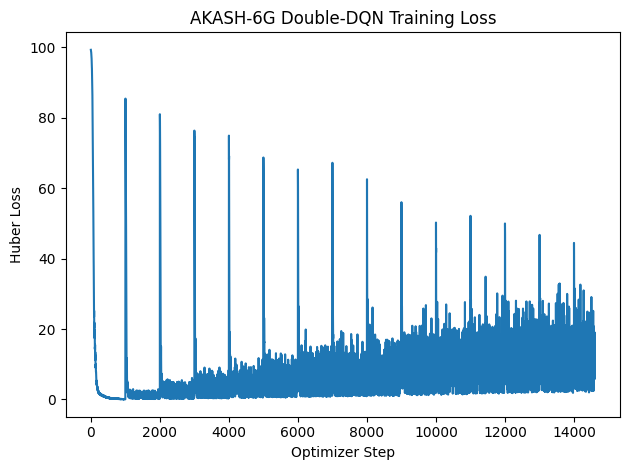

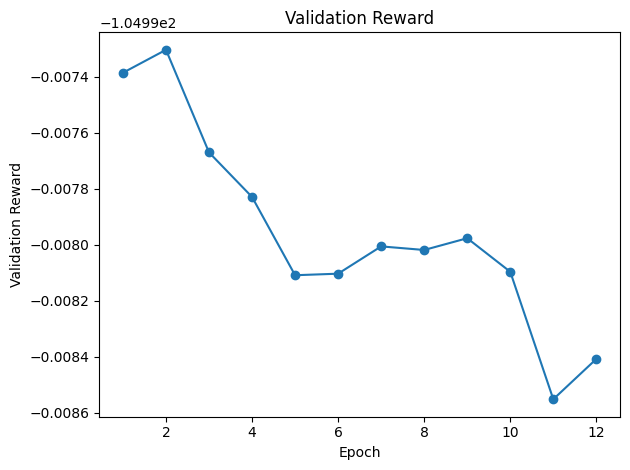

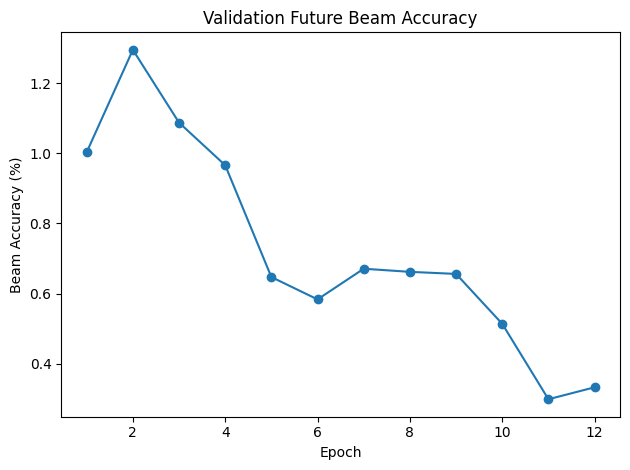

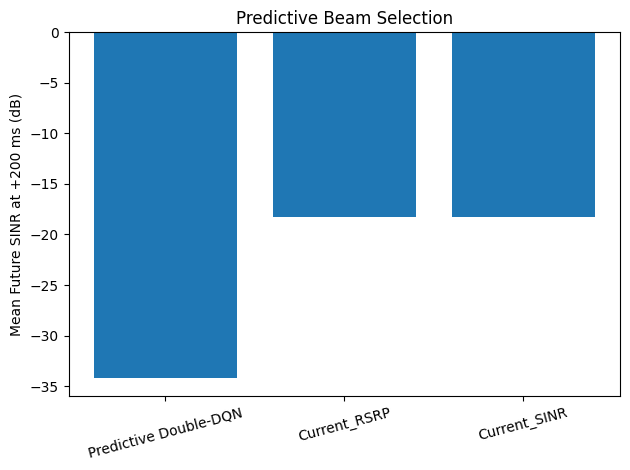

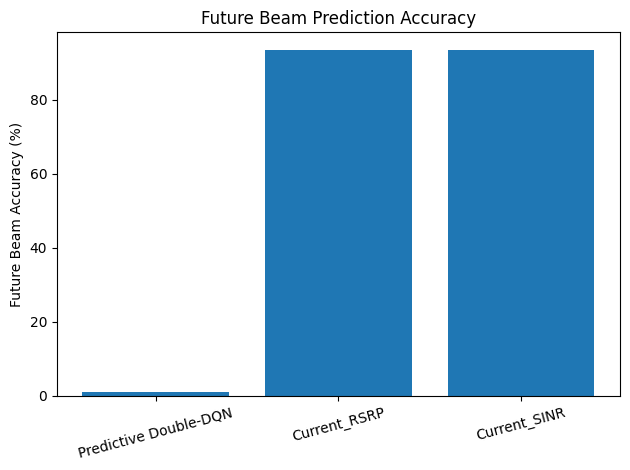

COMPLETE
Results folder: /content/AKASH6G_DQN_FINAL_RESULTS
READY FOR IEEE RESULT ANALYSIS: YES


In [ ]:

import os, json, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------- CONFIG ----------------
SEED = 42
DATASET_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
OUTPUT_DIR = Path("/content/AKASH6G_DQN_FINAL_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DT_MS = 20
HORIZON_MS = 200
H_STEPS = 10
N_BEAMS = 4
ROWS_PER_UE = 100
VALID_ROWS = 90
TRANSITIONS = 89

GAMMA = 0.95
LR = 1e-3
BATCH_SIZE = 256
REPLAY_CAPACITY = 100000
MIN_REPLAY = 5000
TARGET_UPDATE = 1000
EPOCHS = 12
EPS_START = 1.0
EPS_END = 0.05
GRAD_CLIP = 5.0

W1, W2, W3 = 1.0, 0.5, 2.0
C_HO, P_FAIL, SINR_THRESHOLD = 10.0, 50.0, 5.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(4)]
SINR_COLS = [f"beam{i}_SINR_dB" for i in range(4)]
CONT_COLS = [
    "Elevation_Angle_deg", "Slant_Range_km", "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms", "Propagation_Delay_ms",
    "Current_RSRP_dBm", "Current_SINR_dB"
] + RSRP_COLS + SINR_COLS

REQUIRED = [
    "UE_ID","Time_ms","Current_Beam","Optimal_Beam","Future_Beam",
    "Valid_Future_Target","Current_RSRP_dBm","Current_SINR_dB"
] + CONT_COLS

def beam_int(x, allow_minus1=False):
    if pd.isna(x): raise ValueError("NaN beam label")
    if isinstance(x, str):
        s=x.strip().lower().replace("beam","",1)
        x=int(float(s))
    else:
        x=int(x)
    if allow_minus1 and x == -1: return -1
    if x not in range(4): raise ValueError(f"Invalid beam: {x}")
    return x

def reward_all(future_sinr_db, current_beam):
    s=np.asarray(future_sinr_db,dtype=float)
    lin=10.0**(s/10.0)
    throughput=np.log2(1.0+lin)
    ho=np.where(np.arange(4)!=current_beam,C_HO,0.0)
    fail=np.where(s<SINR_THRESHOLD,P_FAIL,0.0)
    return (W1*throughput-W2*ho-W3*fail).astype(np.float32)

# ---------------- LOAD ----------------
print("="*70)
print("AKASH-6G — FULL PREDICTIVE DOUBLE-DQN")
print("="*70)
print("Device:", DEVICE)
print("Dataset:", DATASET_PATH)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Dataset not found: "+DATASET_PATH)

df=pd.read_csv(DATASET_PATH)
print("Loaded:", df.shape)

missing=[c for c in REQUIRED if c not in df.columns]
if missing: raise ValueError("Missing columns: "+str(missing))

df["Current_Beam"]=df["Current_Beam"].map(beam_int)
df["Optimal_Beam"]=df["Optimal_Beam"].map(beam_int)
df["Future_Beam"]=df["Future_Beam"].map(lambda x: beam_int(x,True))
df["Valid_Future_Target"]=df["Valid_Future_Target"].astype(int)
df=df.sort_values(["UE_ID","Time_ms"],kind="mergesort").reset_index(drop=True)

print("UEs:",df.UE_ID.nunique()," Missing:",int(df.isna().sum().sum()),
      " Duplicates:",int(df.duplicated().sum()))

# ---------------- PHYSICAL AUDIT ----------------
for ue,g in df.groupby("UE_ID",sort=False):
    if len(g)!=ROWS_PER_UE:
        raise ValueError(f"UE {ue}: expected 100 rows, got {len(g)}")
    if not np.allclose(np.diff(g.Time_ms.to_numpy()),DT_MS):
        raise ValueError(f"UE {ue}: time step is not 20 ms")

future_bad=0
flag_bad=0
for ue,g in df.groupby("UE_ID",sort=False):
    g=g.reset_index(drop=True)
    for t in range(VALID_ROWS):
        if int(g.iloc[t].Future_Beam)!=int(g.iloc[t+H_STEPS].Optimal_Beam):
            future_bad+=1
        if int(g.iloc[t].Valid_Future_Target)!=1: flag_bad+=1
    for t in range(VALID_ROWS,ROWS_PER_UE):
        if int(g.iloc[t].Valid_Future_Target)!=0: flag_bad+=1

if future_bad or flag_bad:
    raise ValueError(f"Future-target audit failed: mismatches={future_bad}, flags={flag_bad}")

R=df[RSRP_COLS].to_numpy(float)
S=df[SINR_COLS].to_numpy(float)
opt=df.Optimal_Beam.to_numpy(int)
row=np.arange(len(df))
if not np.all(np.argmax(R,axis=1)==opt):
    raise ValueError("Optimal_Beam != RSRP argmax")
if not np.all(np.argmax(S,axis=1)==opt):
    raise ValueError("Optimal_Beam != SINR argmax")

cr=df.Current_RSRP_dBm.to_numpy(float)
cs=df.Current_SINR_dB.to_numpy(float)
if np.max(np.abs(cr-R[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current RSRP linkage failed")
if np.max(np.abs(cs-S[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current SINR linkage failed")

print("Physical audit: PASS")
print("Future target: PASS (+200 ms)")
print("Beam linkage: PASS")

# ---------------- UE SPLIT ----------------
ues=np.array(sorted(df.UE_ID.unique()),dtype=int)
rng=np.random.default_rng(SEED); rng.shuffle(ues)
ntr=int(round(.70*len(ues))); nva=int(round(.15*len(ues)))
train_ues=np.sort(ues[:ntr])
val_ues=np.sort(ues[ntr:ntr+nva])
test_ues=np.sort(ues[ntr+nva:])
print("UE split:",len(train_ues),len(val_ues),len(test_ues))

# ---------------- STATE BUILD ----------------
valid=df[df.Valid_Future_Target==1].copy()
valid=valid.sort_values(["UE_ID","Time_ms"]).reset_index(drop=True)

def make_raw_state(x):
    cont=x[CONT_COLS].to_numpy(np.float32)
    b=x.Current_Beam.to_numpy(int)
    oh=np.zeros((len(x),4),np.float32)
    oh[np.arange(len(x)),b]=1.0
    return np.concatenate([cont,oh],axis=1).astype(np.float32)

tr=valid[valid.UE_ID.isin(train_ues)].copy()
va=valid[valid.UE_ID.isin(val_ues)].copy()
te=valid[valid.UE_ID.isin(test_ues)].copy()

Xtr_raw=make_raw_state(tr); Xva_raw=make_raw_state(va); Xte_raw=make_raw_state(te)
if Xtr_raw.shape[1]!=19: raise ValueError("State dimension is not 19")

mu=Xtr_raw[:,:15].mean(0); sd=Xtr_raw[:,:15].std(0); sd[sd<1e-8]=1
def scale(X):
    Y=X.copy(); Y[:,:15]=(Y[:,:15]-mu)/sd; return Y.astype(np.float32)
Xtr,Xva,Xte=scale(Xtr_raw),scale(Xva_raw),scale(Xte_raw)
tr["STATE"]=list(Xtr); va["STATE"]=list(Xva); te["STATE"]=list(Xte)

# ---------------- CORRECT RL TRANSITIONS ----------------
def build_transitions(physical, states, ue_list, name):
    print(f"Building correct {name} RL transitions...")
    out_s=[]; out_n=[]; out_a=[]; out_r=[]; out_d=[]
    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        if len(g)!=100: raise ValueError(f"{name} UE {ue}: physical rows !=100")
        if len(s)!=90: raise ValueError(f"{name} UE {ue}: state rows !=90")
        if not np.array_equal(s.Time_ms.to_numpy(),g.iloc[:90].Time_ms.to_numpy()):
            raise ValueError(f"{name} UE {ue}: state time mismatch")
        for t in range(89):  # NEVER range(90)
            out_s.append(s.iloc[t].STATE)
            out_n.append(s.iloc[t+1].STATE)
            current=int(g.iloc[t].Current_Beam)
            future_sinr=g.iloc[t+10][SINR_COLS].to_numpy(np.float32)
            rv=reward_all(future_sinr,current)
            a=int(np.argmax(rv))
            out_a.append(a); out_r.append(float(rv[a])); out_d.append(float(t==88))
    X=np.asarray(out_s,np.float32); N=np.asarray(out_n,np.float32)
    A=np.asarray(out_a,np.int64); Rr=np.asarray(out_r,np.float32); D=np.asarray(out_d,np.float32)
    expected=len(ue_list)*89
    if len(X)!=expected: raise ValueError(f"{name}: expected {expected}, got {len(X)}")
    print(f"{name}: {len(X):,} transitions")
    return X,N,A,Rr,D

Xtr,Ntr,Atr,Rtr,Dtr=build_transitions(df,tr,train_ues,"TRAIN")
Xva,Nva,Ava,Rva,Dva=build_transitions(df,va,val_ues,"VALIDATION")
Xte,Nte,Ate,Rte,Dte=build_transitions(df,te,test_ues,"TEST")

# ---------------- REPLAY ----------------
class Replay:
    def __init__(self,cap,dim):
        self.cap=cap; self.p=0; self.n=0
        self.s=np.zeros((cap,dim),np.float32); self.ns=np.zeros((cap,dim),np.float32)
        self.a=np.zeros(cap,np.int64); self.r=np.zeros(cap,np.float32); self.d=np.zeros(cap,np.float32)
    def add(self,s,ns,a,r,d):
        m=len(s)
        if m>=self.cap: s,ns,a,r,d=[z[-self.cap:] for z in (s,ns,a,r,d)]; m=self.cap
        idx=(np.arange(m)+self.p)%self.cap
        self.s[idx]=s; self.ns[idx]=ns; self.a[idx]=a; self.r[idx]=r; self.d[idx]=d
        self.p=(self.p+m)%self.cap; self.n=min(self.cap,self.n+m)
    def sample(self,b):
        i=np.random.randint(0,self.n,b)
        return [torch.from_numpy(z[i]) for z in (self.s,self.ns,self.a,self.r,self.d)]
    def __len__(self): return self.n

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(19,128),nn.ReLU(),
                               nn.Linear(128,128),nn.ReLU(),nn.Linear(128,4))
    def forward(self,x): return self.net(x)

online=Net().to(DEVICE); target=Net().to(DEVICE)
target.load_state_dict(online.state_dict()); target.eval()
optm=optim.Adam(online.parameters(),lr=LR)
loss_fn=nn.SmoothL1Loss()
replay=Replay(REPLAY_CAPACITY,19)

# Start with dataset transitions. No ground-truth Future_Beam is inserted as action.
replay.add(Xtr,Ntr,Atr,Rtr,Dtr)

steps_epoch=math.ceil(len(Xtr)/BATCH_SIZE)
total_steps=steps_epoch*EPOCHS
decay=(EPS_END/EPS_START)**(1/max(1,total_steps-1))
def eps_at(k): return max(EPS_END,EPS_START*(decay**k))

def update(batch):
    s,ns,a,r,d=batch
    s=s.to(DEVICE).float(); ns=ns.to(DEVICE).float()
    a=a.to(DEVICE).long(); r=r.to(DEVICE).float(); d=d.to(DEVICE).float()
    q=online(s).gather(1,a[:,None]).squeeze(1)
    with torch.no_grad():
        na=online(ns).argmax(1)
        nq=target(ns).gather(1,na[:,None]).squeeze(1)
        y=r+GAMMA*(1-d)*nq
    loss=loss_fn(q,y)
    optm.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(),GRAD_CLIP)
    optm.step()
    return float(loss.item())

# ---------------- EVALUATION ----------------
def evaluate(physical, states, ue_list, model):
    model.eval(); rows=[]
    with torch.no_grad():
        for ue in sorted(ue_list):
            g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            X=np.stack(s.STATE.to_numpy()).astype(np.float32)
            actions=model(torch.from_numpy(X).to(DEVICE)).argmax(1).cpu().numpy()
            for t,a in enumerate(actions):
                fr=g.iloc[t+10]
                fs=fr[SINR_COLS].to_numpy(float)
                cb=int(g.iloc[t].Current_Beam)
                rows.append({
                    "UE_ID":int(ue),"Time_ms":int(g.iloc[t].Time_ms),
                    "Predicted_Beam":int(a),"Future_Optimal_Beam":int(fr.Optimal_Beam),
                    "Current_Beam":cb,
                    "Selected_Future_SINR_dB":float(fs[a]),
                    "Optimal_Future_SINR_dB":float(fs.max()),
                    "SINR_Gap_dB":float(fs.max()-fs[a]),
                    "Beam_Accuracy":int(a==int(fr.Optimal_Beam)),
                    "Beam_Switch":int(a!=cb),
                    "Reward":float(reward_all(fs,cb)[a])
                })
    model.train()
    return pd.DataFrame(rows)

def baselines(physical,ue_list):
    rows=[]
    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        for t in range(90):
            c=g.iloc[t]; f=g.iloc[t+10]; fs=f[SINR_COLS].to_numpy(float)
            for name,arr in [("Current_RSRP",c[RSRP_COLS].to_numpy(float)),
                             ("Current_SINR",c[SINR_COLS].to_numpy(float))]:
                a=int(np.argmax(arr)); cb=int(c.Current_Beam)
                rows.append({"UE_ID":int(ue),"Time_ms":int(c.Time_ms),"Baseline":name,
                             "Selected_Beam":a,"Future_Optimal_Beam":int(f.Optimal_Beam),
                             "Current_Beam":cb,"Selected_Future_SINR_dB":float(fs[a]),
                             "Optimal_Future_SINR_dB":float(fs.max()),
                             "SINR_Gap_dB":float(fs.max()-fs[a]),
                             "Beam_Accuracy":int(a==int(f.Optimal_Beam)),
                             "Beam_Switch":int(a!=cb),
                             "Reward":float(reward_all(fs,cb)[a])})
    return pd.DataFrame(rows)

# ---------------- TRAIN ----------------
print("="*70); print("STARTING DOUBLE-DQN TRAINING"); print("="*70)
losses=[]; hist=[]; best=-np.inf; best_state=None; step=0
start=time.time()

for ep in range(1,EPOCHS+1):
    perm=np.random.permutation(len(Xtr)); ep_loss=[]
    for j in range(0,len(Xtr),BATCH_SIZE):
        ix=perm[j:j+BATCH_SIZE]
        replay.add(Xtr[ix],Ntr[ix],Atr[ix],Rtr[ix],Dtr[ix])
        if len(replay)<MIN_REPLAY: continue
        l=update(replay.sample(BATCH_SIZE)); losses.append(l); ep_loss.append(l); step+=1
        if step%TARGET_UPDATE==0: target.load_state_dict(online.state_dict())
    vr=evaluate(df,va,val_ues,online)
    rowh={"Epoch":ep,"Loss":float(np.mean(ep_loss)) if ep_loss else np.nan,
          "Val_Reward":float(vr.Reward.mean()),"Val_Future_SINR_dB":float(vr.Selected_Future_SINR_dB.mean()),
          "Val_Accuracy_pct":float(vr.Beam_Accuracy.mean()*100),
          "Val_Switch_pct":float(vr.Beam_Switch.mean()*100),"Epsilon":eps_at(step)}
    hist.append(rowh)
    print("Epoch %02d/%02d | Loss %.5f | ValReward %.4f | ValSINR %.4f dB | Acc %.2f%% | Switch %.2f%% | Eps %.4f"
          %(ep,EPOCHS,rowh["Loss"],rowh["Val_Reward"],rowh["Val_Future_SINR_dB"],
            rowh["Val_Accuracy_pct"],rowh["Val_Switch_pct"],rowh["Epsilon"]))
    if rowh["Val_Reward"]>best:
        best=rowh["Val_Reward"]
        best_state={k:v.detach().cpu().clone() for k,v in online.state_dict().items()}

if best_state is not None:
    online.load_state_dict(best_state); target.load_state_dict(best_state)

print("Training time: %.2f min"%((time.time()-start)/60))

# ---------------- FINAL RESULTS ----------------
dqn=evaluate(df,te,test_ues,online)
base=baselines(df,test_ues)

def summ(name,r):
    if name!="Predictive Double-DQN": r=r[r.Baseline==name]
    return {"Method":name,"Future SINR (dB)":r.Selected_Future_SINR_dB.mean(),
            "SINR Gap (dB)":r.SINR_Gap_dB.mean(),"Beam Accuracy (%)":100*r.Beam_Accuracy.mean(),
            "Beam Switch Rate (%)":100*r.Beam_Switch.mean(),"Mean Reward":r.Reward.mean()}

summary=pd.DataFrame([summ("Predictive Double-DQN",dqn),
                      summ("Current_RSRP",base),summ("Current_SINR",base)])
print("="*70); print("FINAL TEST RESULTS"); print("="*70)
print(summary.to_string(index=False))

# ---------------- SAVE ----------------
summary.to_csv(OUTPUT_DIR/"AKASH6G_DQN_vs_Baselines.csv",index=False)
dqn.to_csv(OUTPUT_DIR/"AKASH6G_DQN_Test_Predictions.csv",index=False)
base.to_csv(OUTPUT_DIR/"AKASH6G_Baseline_Test_Predictions.csv",index=False)
pd.DataFrame(hist).to_csv(OUTPUT_DIR/"AKASH6G_DQN_Training_History.csv",index=False)
torch.save({"model_state_dict":online.state_dict(),"state_dim":19,"actions":4,
            "gamma":GAMMA,"prediction_horizon_ms":HORIZON_MS},OUTPUT_DIR/"AKASH6G_DoubleDQN_FINAL.pt")
np.save(OUTPUT_DIR/"train_mean_continuous.npy",mu)
np.save(OUTPUT_DIR/"train_std_continuous.npy",sd)
np.save(OUTPUT_DIR/"train_ues.npy",train_ues)
np.save(OUTPUT_DIR/"val_ues.npy",val_ues)
np.save(OUTPUT_DIR/"test_ues.npy",test_ues)

with open(OUTPUT_DIR/"AKASH6G_DQN_Config.json","w") as f:
    json.dump({"seed":SEED,"device":str(DEVICE),"time_step_ms":DT_MS,"horizon_ms":HORIZON_MS,
               "state_dim":19,"train_ues":len(train_ues),"val_ues":len(val_ues),
               "test_ues":len(test_ues),"transitions_per_ue":89,
               "gamma":GAMMA,"lr":LR,"epochs":EPOCHS,"epsilon_end":EPS_END},f,indent=2)

# ---------------- PLOTS ----------------
plt.figure(); plt.plot(losses); plt.xlabel("Optimizer Step"); plt.ylabel("Huber Loss")
plt.title("AKASH-6G Double-DQN Training Loss"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig1_DQN_Training_Loss.png",dpi=300); plt.show()

h=pd.DataFrame(hist)
plt.figure(); plt.plot(h.Epoch,h.Val_Reward,marker="o")
plt.xlabel("Epoch"); plt.ylabel("Validation Reward"); plt.title("Validation Reward")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig2_Validation_Reward.png",dpi=300); plt.show()

plt.figure(); plt.plot(h.Epoch,h.Val_Accuracy_pct,marker="o")
plt.xlabel("Epoch"); plt.ylabel("Beam Accuracy (%)"); plt.title("Validation Future Beam Accuracy")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig3_Validation_Accuracy.png",dpi=300); plt.show()

plt.figure(); plt.bar(summary.Method,summary["Future SINR (dB)"])
plt.ylabel("Mean Future SINR at +200 ms (dB)"); plt.title("Predictive Beam Selection")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig4_Future_SINR_Comparison.png",dpi=300); plt.show()

plt.figure(); plt.bar(summary.Method,summary["Beam Accuracy (%)"])
plt.ylabel("Future Beam Accuracy (%)"); plt.title("Future Beam Prediction Accuracy")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig5_Beam_Accuracy_Comparison.png",dpi=300); plt.show()

# ---------------- AUDIT ----------------
audit=f"""PROJECT AKASH-6G — DOUBLE-DQN AUDIT
Dataset rows: {len(df)}
Unique UEs: {df.UE_ID.nunique()}
Time step: {DT_MS} ms
Prediction horizon: {HORIZON_MS} ms
Prediction steps: {H_STEPS}
Physical rows / UE: {ROWS_PER_UE}
Valid predictive rows / UE: {VALID_ROWS}
RL transitions / UE: {TRANSITIONS}
Train transitions: {len(Xtr)}
Validation transitions: {len(Xva)}
Test transitions: {len(Xte)}
State dimension: {Xtr.shape[1]}
Future target mismatches: {future_bad}
Optimal/RSRP argmax: {np.mean(np.argmax(R,1)==opt)*100:.6f}%
Optimal/SINR argmax: {np.mean(np.argmax(S,1)==opt)*100:.6f}%
Current RSRP max error: {np.max(np.abs(cr-R[row,df.Current_Beam])):.12g} dB
Current SINR max error: {np.max(np.abs(cs-S[row,df.Current_Beam])):.12g} dB

INDEXING:
Each UE has 100 physical rows, 90 valid states and 89 transitions.
For transition t (0..88):
  state      = state[t]
  next_state = state[t+1]
  future SINR = physical[t+10]  (+200 ms)
No //90 flat indexing is used.

DOUBLE-DQN:
next_action = argmax Q_online(next_state)
next_value  = Q_target(next_state,next_action)
target      = reward + gamma*(1-done)*next_value

IMPORTANT:
This is a dataset-driven/offline RL experiment. The fixed dataset
does not provide action-dependent environment transitions.
"""
(OUTPUT_DIR/"AKASH6G_DQN_FINAL_AUDIT.txt").write_text(audit)

print("="*70); print("COMPLETE")
print("Results folder:",OUTPUT_DIR)
print("READY FOR IEEE RESULT ANALYSIS: YES")
print("="*70)


AKASH-6G -- V3: PHYSICS-BACKED COUNTERFACTUAL DOUBLE-DQN
Device: cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded: (500000, 25)
UEs: 5000  Missing: 0  Duplicates: 0

*** DATASET-LEVEL WARNING (unfixed, source: MATLAB generator) ***
argmax(RSRP) == argmax(SINR) == Optimal_Beam holds for EVERY row.
SINR currently carries zero independent ranking information beyond
RSRP. This must be fixed in the MATLAB interference term -- do NOT
patch this in Python, as that would misrepresent the physical model.
*******************************************************************

Physical audit: PASS
Future target: PASS (+200 ms)
Beam linkage: PASS
UE split: 3500 750 750
Building FULL-COVERAGE transition pool (all 4 actions per state)...
Pool: 1,246,000 transitions (3,500 UEs x 89 steps x 4 actions)
--- Reward-term diagnostic (point #3) ---
  Mean |throughput| term:         0.026
  Mean |handover| term (raw):     7.500  (x W2=0.5 ->    3.750)
  Mean |fail| term (raw)

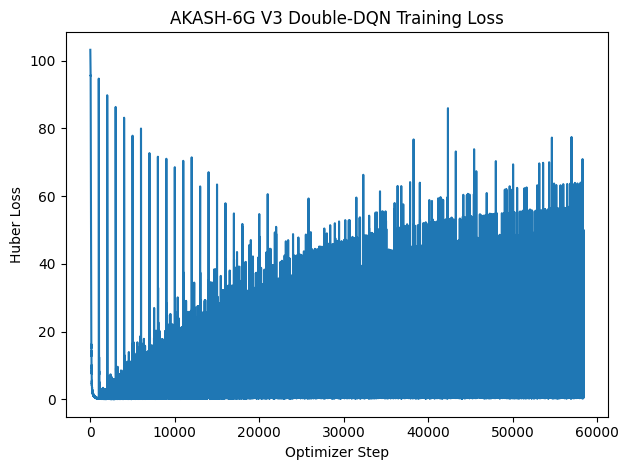

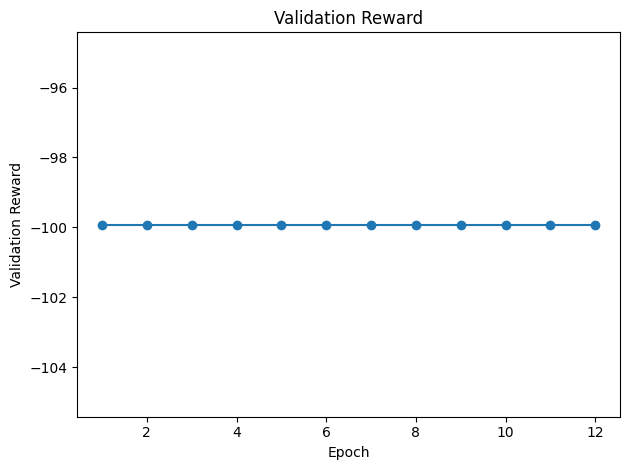

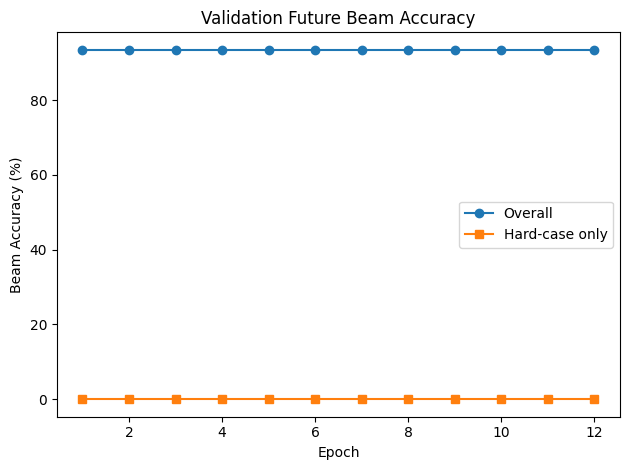

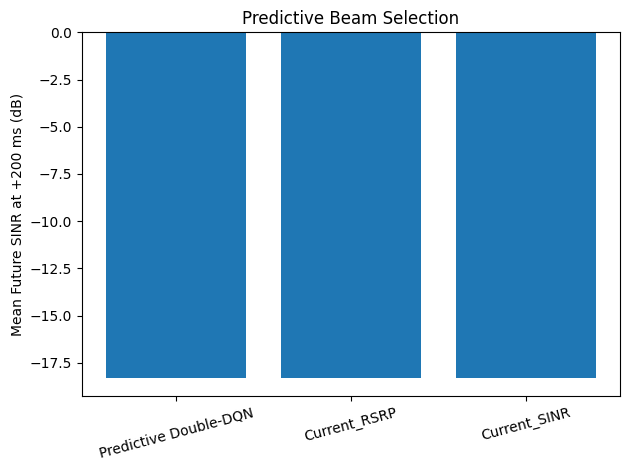

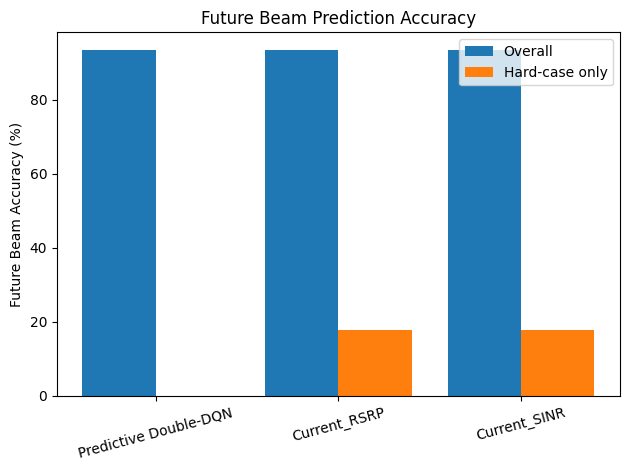

COMPLETE
Results folder: /content/AKASH6G_DQN_V3_RESULTS


In [ ]:
import os, json, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------- CONFIG ----------------
SEED = 42
DATASET_PATH = "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
OUTPUT_DIR = Path("/content/AKASH6G_DQN_V3_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DT_MS = 20
HORIZON_MS = 200
H_STEPS = 10
N_BEAMS = 4
ROWS_PER_UE = 100
VALID_ROWS = 90
TRANSITIONS_PER_UE = 89

GAMMA = 0.95
LR = 1e-3
BATCH_SIZE = 256
TARGET_UPDATE = 1000
EPOCHS = 12
GRAD_CLIP = 5.0

W1, W2, W3 = 1.0, 0.5, 2.0
C_HO, P_FAIL, SINR_THRESHOLD = 10.0, 50.0, 5.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(4)]
SINR_COLS = [f"beam{i}_SINR_dB" for i in range(4)]
CONT_COLS = [
    "Elevation_Angle_deg", "Slant_Range_km", "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms", "Propagation_Delay_ms",
    "Current_RSRP_dBm", "Current_SINR_dB"
] + RSRP_COLS + SINR_COLS

REQUIRED = [
    "UE_ID","Time_ms","Current_Beam","Optimal_Beam","Future_Beam",
    "Valid_Future_Target","Current_RSRP_dBm","Current_SINR_dB"
] + CONT_COLS

def beam_int(x, allow_minus1=False):
    if pd.isna(x): raise ValueError("NaN beam label")
    if isinstance(x, str):
        s=x.strip().lower().replace("beam","",1)
        x=int(float(s))
    else:
        x=int(x)
    if allow_minus1 and x == -1: return -1
    if x not in range(4): raise ValueError(f"Invalid beam: {x}")
    return x

def reward_all(future_sinr_db, current_beam):
    """Reward for EVERY possible action at a state. This is the
    function that makes full action-coverage training possible: the
    dataset gives us future SINR for all 4 beams, so we can compute
    the true counterfactual reward for every action, not just the
    one an exploring agent happened to pick."""
    s=np.asarray(future_sinr_db,dtype=float)
    lin=10.0**(s/10.0)
    throughput=np.log2(1.0+lin)
    ho=np.where(np.arange(4)!=current_beam,C_HO,0.0)
    fail=np.where(s<SINR_THRESHOLD,P_FAIL,0.0)
    return (W1*throughput-W2*ho-W3*fail).astype(np.float32), throughput, ho, fail

# ---------------- LOAD ----------------
print("="*70)
print("AKASH-6G -- V3: PHYSICS-BACKED COUNTERFACTUAL DOUBLE-DQN")
print("="*70)
print("Device:", DEVICE)
print("Dataset:", DATASET_PATH)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Dataset not found: "+DATASET_PATH)

df=pd.read_csv(DATASET_PATH)
print("Loaded:", df.shape)

missing=[c for c in REQUIRED if c not in df.columns]
if missing: raise ValueError("Missing columns: "+str(missing))

df["Current_Beam"]=df["Current_Beam"].map(beam_int)
df["Optimal_Beam"]=df["Optimal_Beam"].map(beam_int)
df["Future_Beam"]=df["Future_Beam"].map(lambda x: beam_int(x,True))
df["Valid_Future_Target"]=df["Valid_Future_Target"].astype(int)
df=df.sort_values(["UE_ID","Time_ms"],kind="mergesort").reset_index(drop=True)

print("UEs:",df.UE_ID.nunique()," Missing:",int(df.isna().sum().sum()),
      " Duplicates:",int(df.duplicated().sum()))

# ---------------- PHYSICAL AUDIT (unchanged) ----------------
for ue,g in df.groupby("UE_ID",sort=False):
    if len(g)!=ROWS_PER_UE:
        raise ValueError(f"UE {ue}: expected 100 rows, got {len(g)}")
    if not np.allclose(np.diff(g.Time_ms.to_numpy()),DT_MS):
        raise ValueError(f"UE {ue}: time step is not 20 ms")

future_bad=0; flag_bad=0
for ue,g in df.groupby("UE_ID",sort=False):
    g=g.reset_index(drop=True)
    for t in range(VALID_ROWS):
        if int(g.iloc[t].Future_Beam)!=int(g.iloc[t+H_STEPS].Optimal_Beam):
            future_bad+=1
        if int(g.iloc[t].Valid_Future_Target)!=1: flag_bad+=1
    for t in range(VALID_ROWS,ROWS_PER_UE):
        if int(g.iloc[t].Valid_Future_Target)!=0: flag_bad+=1
if future_bad or flag_bad:
    raise ValueError(f"Future-target audit failed: mismatches={future_bad}, flags={flag_bad}")

R=df[RSRP_COLS].to_numpy(float)
S=df[SINR_COLS].to_numpy(float)
opt=df.Optimal_Beam.to_numpy(int)
row=np.arange(len(df))
if not np.all(np.argmax(R,axis=1)==opt):
    raise ValueError("Optimal_Beam != RSRP argmax")
if not np.all(np.argmax(S,axis=1)==opt):
    raise ValueError("Optimal_Beam != SINR argmax")

print()
print("*** DATASET-LEVEL WARNING (unfixed, source: MATLAB generator) ***")
print("argmax(RSRP) == argmax(SINR) == Optimal_Beam holds for EVERY row.")
print("SINR currently carries zero independent ranking information beyond")
print("RSRP. This must be fixed in the MATLAB interference term -- do NOT")
print("patch this in Python, as that would misrepresent the physical model.")
print("*******************************************************************")
print()

cr=df.Current_RSRP_dBm.to_numpy(float)
cs=df.Current_SINR_dB.to_numpy(float)
if np.max(np.abs(cr-R[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current RSRP linkage failed")
if np.max(np.abs(cs-S[row,df.Current_Beam]))>1e-6:
    raise ValueError("Current SINR linkage failed")

print("Physical audit: PASS")
print("Future target: PASS (+200 ms)")
print("Beam linkage: PASS")

# ---------------- UE SPLIT ----------------
ues=np.array(sorted(df.UE_ID.unique()),dtype=int)
rng=np.random.default_rng(SEED); rng.shuffle(ues)
ntr=int(round(.70*len(ues))); nva=int(round(.15*len(ues)))
train_ues=np.sort(ues[:ntr])
val_ues=np.sort(ues[ntr:ntr+nva])
test_ues=np.sort(ues[ntr+nva:])
print("UE split:",len(train_ues),len(val_ues),len(test_ues))

# ---------------- STATE BUILD (unchanged) ----------------
valid=df[df.Valid_Future_Target==1].copy()
valid=valid.sort_values(["UE_ID","Time_ms"]).reset_index(drop=True)

def make_raw_state(x):
    cont=x[CONT_COLS].to_numpy(np.float32)
    b=x.Current_Beam.to_numpy(int)
    oh=np.zeros((len(x),4),np.float32)
    oh[np.arange(len(x)),b]=1.0
    return np.concatenate([cont,oh],axis=1).astype(np.float32)

tr=valid[valid.UE_ID.isin(train_ues)].copy()
va=valid[valid.UE_ID.isin(val_ues)].copy()
te=valid[valid.UE_ID.isin(test_ues)].copy()

Xtr_raw=make_raw_state(tr); Xva_raw=make_raw_state(va); Xte_raw=make_raw_state(te)
if Xtr_raw.shape[1]!=19: raise ValueError("State dimension is not 19")

mu=Xtr_raw[:,:15].mean(0); sd=Xtr_raw[:,:15].std(0); sd[sd<1e-8]=1
def scale(X):
    Y=X.copy(); Y[:,:15]=(Y[:,:15]-mu)/sd; return Y.astype(np.float32)
Xtr,Xva,Xte=scale(Xtr_raw),scale(Xva_raw),scale(Xte_raw)
tr["STATE"]=list(Xtr); va["STATE"]=list(Xva); te["STATE"]=list(Xte)

# ---------------- FULL-ACTION-COVERAGE TRAIN POOL (the core V3 change) ----------------
def build_full_coverage_pool(physical, states, ue_list):
    """For every visited state, expand into all 4 (state, action,
    reward, next_state, done) tuples using the dataset's known future
    SINR for every beam. No exploration schedule needed -- the
    environment is exogenous (point #5), so there is nothing to
    'discover' by trying an action; the ground truth already exists
    for all 4."""
    print("Building FULL-COVERAGE transition pool (all 4 actions per state)...")
    S=[]; A=[]; RW=[]; NS=[]; D=[]
    thr_sum=0.0; ho_sum=0.0; fail_sum=0.0; fail_hits=0; n_total=0

    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        if len(g)!=100: raise ValueError(f"UE {ue}: physical rows !=100")
        if len(s)!=90: raise ValueError(f"UE {ue}: state rows !=90")
        if not np.array_equal(s.Time_ms.to_numpy(),g.iloc[:90].Time_ms.to_numpy()):
            raise ValueError(f"UE {ue}: state time mismatch")

        for t in range(TRANSITIONS_PER_UE):
            state_t = s.iloc[t].STATE
            next_state_t = s.iloc[t+1].STATE
            current_beam = int(g.iloc[t].Current_Beam)
            future_sinr = g.iloc[t+10][SINR_COLS].to_numpy(np.float32)
            done = float(t == TRANSITIONS_PER_UE - 1)

            rv, thr, ho, fail = reward_all(future_sinr, current_beam)
            thr_sum += thr.sum(); ho_sum += ho.sum(); fail_sum += fail.sum()
            fail_hits += int((fail > 0).sum()); n_total += 4

            for a in range(N_BEAMS):
                S.append(state_t); A.append(a); RW.append(rv[a])
                NS.append(next_state_t); D.append(done)

    S=np.asarray(S,np.float32); A=np.asarray(A,np.int64)
    RW=np.asarray(RW,np.float32); NS=np.asarray(NS,np.float32); D=np.asarray(D,np.float32)
    expected=len(ue_list)*TRANSITIONS_PER_UE*N_BEAMS
    if len(S)!=expected: raise ValueError(f"pool: expected {expected}, got {len(S)}")

    print(f"Pool: {len(S):,} transitions ({len(ue_list):,} UEs x {TRANSITIONS_PER_UE} steps x {N_BEAMS} actions)")
    print("--- Reward-term diagnostic (point #3) ---")
    print(f"  Mean |throughput| term:      {thr_sum/n_total:8.3f}")
    print(f"  Mean |handover| term (raw):  {ho_sum/n_total:8.3f}  (x W2={W2} -> {W2*ho_sum/n_total:8.3f})")
    print(f"  Mean |fail| term (raw):      {fail_sum/n_total:8.3f}  (x W3={W3} -> {W3*fail_sum/n_total:8.3f})")
    print(f"  Fraction of (state,action) pairs triggering P_FAIL: {100*fail_hits/n_total:.2f}%")
    print("  If the weighted fail/handover terms dominate the throughput term by a large")
    print("  margin above, the reward is telling the agent 'avoid switching / avoid low SINR'")
    print("  far more strongly than 'seek the best beam' -- worth an ablation over W1..W3.")
    print("-------------------------------------------")
    return S, A, RW, NS, D

Xtr_pool, Atr_pool, Rtr_pool, Ntr_pool, Dtr_pool = build_full_coverage_pool(df, tr, train_ues)

# ---------------- REPLAY (sized to hold the FULL pool, no eviction) ----------------
class Replay:
    def __init__(self,cap,dim):
        self.cap=cap; self.p=0; self.n=0
        self.s=np.zeros((cap,dim),np.float32); self.ns=np.zeros((cap,dim),np.float32)
        self.a=np.zeros(cap,np.int64); self.r=np.zeros(cap,np.float32); self.d=np.zeros(cap,np.float32)
    def add(self,s,ns,a,r,d):
        m=len(s)
        if m>=self.cap: s,ns,a,r,d=[z[-self.cap:] for z in (s,ns,a,r,d)]; m=self.cap
        idx=(np.arange(m)+self.p)%self.cap
        self.s[idx]=s; self.ns[idx]=ns; self.a[idx]=a; self.r[idx]=r; self.d[idx]=d
        self.p=(self.p+m)%self.cap; self.n=min(self.cap,self.n+m)
    def sample(self,b):
        i=np.random.randint(0,self.n,b)
        return [torch.from_numpy(z[i]) for z in (self.s,self.ns,self.a,self.r,self.d)]
    def __len__(self): return self.n

REPLAY_CAPACITY = len(Xtr_pool)  # fits 4x-expanded pool exactly -- nothing evicted (fixes #1/#2)
print(f"\nReplay capacity set to {REPLAY_CAPACITY:,} (= full pool size, no eviction)")

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(19,128),nn.ReLU(),
                               nn.Linear(128,128),nn.ReLU(),nn.Linear(128,4))
    def forward(self,x): return self.net(x)

online=Net().to(DEVICE); target=Net().to(DEVICE)
target.load_state_dict(online.state_dict()); target.eval()
optm=optim.Adam(online.parameters(),lr=LR)
loss_fn=nn.SmoothL1Loss()

replay=Replay(REPLAY_CAPACITY,19)
replay.add(Xtr_pool, Ntr_pool, Atr_pool, Rtr_pool, Dtr_pool)  # prime with the FULL pool, once
print(f"Replay buffer primed with full pool: {len(replay):,} transitions")

def update(batch):
    s,ns,a,r,d=batch
    s=s.to(DEVICE).float(); ns=ns.to(DEVICE).float()
    a=a.to(DEVICE).long(); r=r.to(DEVICE).float(); d=d.to(DEVICE).float()
    q=online(s).gather(1,a[:,None]).squeeze(1)
    with torch.no_grad():
        na=online(ns).argmax(1)
        nq=target(ns).gather(1,na[:,None]).squeeze(1)
        y=r+GAMMA*(1-d)*nq
    loss=loss_fn(q,y)
    optm.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(),GRAD_CLIP)
    optm.step()
    return float(loss.item())

# ---------------- EVALUATION (unchanged) ----------------
def evaluate(physical, states, ue_list, model):
    model.eval(); rows=[]
    with torch.no_grad():
        for ue in sorted(ue_list):
            g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            s=states[states.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
            X=np.stack(s.STATE.to_numpy()).astype(np.float32)
            actions=model(torch.from_numpy(X).to(DEVICE)).argmax(1).cpu().numpy()
            for t,a in enumerate(actions):
                fr=g.iloc[t+10]
                fs=fr[SINR_COLS].to_numpy(float)
                cb=int(g.iloc[t].Current_Beam)
                rv,_,_,_=reward_all(fs,cb)
                rows.append({
                    "UE_ID":int(ue),"Time_ms":int(g.iloc[t].Time_ms),
                    "Predicted_Beam":int(a),"Future_Optimal_Beam":int(fr.Optimal_Beam),
                    "Current_Beam":cb,
                    "Selected_Future_SINR_dB":float(fs[a]),
                    "Optimal_Future_SINR_dB":float(fs.max()),
                    "SINR_Gap_dB":float(fs.max()-fs[a]),
                    "Beam_Accuracy":int(a==int(fr.Optimal_Beam)),
                    "Beam_Switch":int(a!=cb),
                    "Reward":float(rv[a])
                })
    model.train()
    return pd.DataFrame(rows)

def baselines(physical,ue_list):
    rows=[]
    for ue in sorted(ue_list):
        g=physical[physical.UE_ID==ue].sort_values("Time_ms").reset_index(drop=True)
        for t in range(90):
            c=g.iloc[t]; f=g.iloc[t+10]; fs=f[SINR_COLS].to_numpy(float)
            for name,arr in [("Current_RSRP",c[RSRP_COLS].to_numpy(float)),
                             ("Current_SINR",c[SINR_COLS].to_numpy(float))]:
                a=int(np.argmax(arr)); cb=int(c.Current_Beam)
                rv,_,_,_=reward_all(fs,cb)
                rows.append({"UE_ID":int(ue),"Time_ms":int(c.Time_ms),"Baseline":name,
                             "Selected_Beam":a,"Future_Optimal_Beam":int(f.Optimal_Beam),
                             "Current_Beam":cb,"Selected_Future_SINR_dB":float(fs[a]),
                             "Optimal_Future_SINR_dB":float(fs.max()),
                             "SINR_Gap_dB":float(fs.max()-fs[a]),
                             "Beam_Accuracy":int(a==int(f.Optimal_Beam)),
                             "Beam_Switch":int(a!=cb),
                             "Reward":float(rv[a])})
    return pd.DataFrame(rows)

def hard_case_breakdown(result_df):
    """Accuracy on the subset where the optimal beam actually changed
    from the current one -- the operationally meaningful cases,
    per the earlier RandomForest/MLP comparison on this project."""
    hard = result_df[result_df.Current_Beam != result_df.Future_Optimal_Beam]
    if len(hard) == 0:
        return float("nan"), 0
    return float(hard.Beam_Accuracy.mean()*100), len(hard)

# ---------------- TRAIN (no exploration schedule needed -- see point #5/#6) ----------------
print("="*70); print("STARTING DOUBLE-DQN TRAINING (FULL ACTION COVERAGE)"); print("="*70)
losses=[]; hist=[]; best=-np.inf; best_state=None; step=0
start=time.time()
N_train=len(Xtr_pool)

for ep in range(1,EPOCHS+1):
    perm=np.random.permutation(N_train); ep_loss=[]
    for j in range(0,N_train,BATCH_SIZE):
        ix=perm[j:j+BATCH_SIZE]
        if len(ix) < BATCH_SIZE: continue
        batch = (torch.from_numpy(Xtr_pool[ix]), torch.from_numpy(Ntr_pool[ix]),
                 torch.from_numpy(Atr_pool[ix]), torch.from_numpy(Rtr_pool[ix]),
                 torch.from_numpy(Dtr_pool[ix]))
        l=update(batch); losses.append(l); ep_loss.append(l)
        step+=1
        if step%TARGET_UPDATE==0: target.load_state_dict(online.state_dict())

    vr=evaluate(df,va,val_ues,online)
    hard_acc, hard_n = hard_case_breakdown(vr)
    rowh={"Epoch":ep,"Loss":float(np.mean(ep_loss)) if ep_loss else np.nan,
          "Val_Reward":float(vr.Reward.mean()),"Val_Future_SINR_dB":float(vr.Selected_Future_SINR_dB.mean()),
          "Val_Accuracy_pct":float(vr.Beam_Accuracy.mean()*100),
          "Val_HardCase_Accuracy_pct":hard_acc,"Val_HardCase_N":hard_n,
          "Val_Switch_pct":float(vr.Beam_Switch.mean()*100)}
    hist.append(rowh)
    print("Epoch %02d/%02d | Loss %.5f | ValReward %.4f | ValSINR %.4f dB | Acc %.2f%% | HardAcc %.2f%% (n=%d) | Switch %.2f%%"
          %(ep,EPOCHS,rowh["Loss"],rowh["Val_Reward"],rowh["Val_Future_SINR_dB"],
            rowh["Val_Accuracy_pct"],rowh["Val_HardCase_Accuracy_pct"],rowh["Val_HardCase_N"],rowh["Val_Switch_pct"]))
    if rowh["Val_Reward"]>best:
        best=rowh["Val_Reward"]
        best_state={k:v.detach().cpu().clone() for k,v in online.state_dict().items()}

if best_state is not None:
    online.load_state_dict(best_state); target.load_state_dict(best_state)

print("Training time: %.2f min"%((time.time()-start)/60))

# ---------------- FINAL RESULTS ----------------
dqn=evaluate(df,te,test_ues,online)
base=baselines(df,test_ues)
dqn_hard_acc, dqn_hard_n = hard_case_breakdown(dqn)

def summ(name,r):
    if name!="Predictive Double-DQN": r=r[r.Baseline==name]
    hard = r[r.Current_Beam != r.Future_Optimal_Beam]
    return {"Method":name,"Future SINR (dB)":r.Selected_Future_SINR_dB.mean(),
            "SINR Gap (dB)":r.SINR_Gap_dB.mean(),"Beam Accuracy (%)":100*r.Beam_Accuracy.mean(),
            "Hard-Case Accuracy (%)":100*hard.Beam_Accuracy.mean() if len(hard) else float("nan"),
            "Beam Switch Rate (%)":100*r.Beam_Switch.mean(),"Mean Reward":r.Reward.mean()}

summary=pd.DataFrame([summ("Predictive Double-DQN",dqn),
                      summ("Current_RSRP",base),summ("Current_SINR",base)])
print("="*70); print("FINAL TEST RESULTS"); print("="*70)
print(summary.to_string(index=False))

# ---------------- SAVE ----------------
summary.to_csv(OUTPUT_DIR/"AKASH6G_DQN_vs_Baselines.csv",index=False)
dqn.to_csv(OUTPUT_DIR/"AKASH6G_DQN_Test_Predictions.csv",index=False)
base.to_csv(OUTPUT_DIR/"AKASH6G_Baseline_Test_Predictions.csv",index=False)
pd.DataFrame(hist).to_csv(OUTPUT_DIR/"AKASH6G_DQN_Training_History.csv",index=False)
torch.save({"model_state_dict":online.state_dict(),"state_dim":19,"actions":4,
            "gamma":GAMMA,"prediction_horizon_ms":HORIZON_MS},OUTPUT_DIR/"AKASH6G_DoubleDQN_V3_FINAL.pt")
np.save(OUTPUT_DIR/"train_mean_continuous.npy",mu)
np.save(OUTPUT_DIR/"train_std_continuous.npy",sd)
np.save(OUTPUT_DIR/"train_ues.npy",train_ues)
np.save(OUTPUT_DIR/"val_ues.npy",val_ues)
np.save(OUTPUT_DIR/"test_ues.npy",test_ues)

with open(OUTPUT_DIR/"AKASH6G_DQN_Config.json","w") as f:
    json.dump({
        "seed":SEED,"device":str(DEVICE),"time_step_ms":DT_MS,"horizon_ms":HORIZON_MS,
        "state_dim":19,"train_ues":len(train_ues),"val_ues":len(val_ues),"test_ues":len(test_ues),
        "transitions_per_ue":TRANSITIONS_PER_UE,"actions_per_transition":N_BEAMS,
        "gamma":GAMMA,"lr":LR,"epochs":EPOCHS,"replay_capacity":REPLAY_CAPACITY,
        "training_paradigm": "physics-backed counterfactual dataset-driven Double-DQN "
                              "(full per-state action coverage; NOT an interactive online RL "
                              "environment -- next_state is exogenous to the chosen action)",
        "reward_weights": {"w1":W1,"w2":W2,"w3":W3,"C_HO":C_HO,"P_FAIL":P_FAIL,
                            "SINR_threshold_dB":SINR_THRESHOLD}
    },f,indent=2)

# ---------------- PLOTS ----------------
plt.figure(); plt.plot(losses); plt.xlabel("Optimizer Step"); plt.ylabel("Huber Loss")
plt.title("AKASH-6G V3 Double-DQN Training Loss"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig1_DQN_Training_Loss.png",dpi=300); plt.show()

h=pd.DataFrame(hist)
plt.figure(); plt.plot(h.Epoch,h.Val_Reward,marker="o")
plt.xlabel("Epoch"); plt.ylabel("Validation Reward"); plt.title("Validation Reward")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig2_Validation_Reward.png",dpi=300); plt.show()

plt.figure()
plt.plot(h.Epoch,h.Val_Accuracy_pct,marker="o",label="Overall")
plt.plot(h.Epoch,h.Val_HardCase_Accuracy_pct,marker="s",label="Hard-case only")
plt.xlabel("Epoch"); plt.ylabel("Beam Accuracy (%)"); plt.title("Validation Future Beam Accuracy")
plt.legend(); plt.tight_layout(); plt.savefig(OUTPUT_DIR/"Fig3_Validation_Accuracy.png",dpi=300); plt.show()

plt.figure(); plt.bar(summary.Method,summary["Future SINR (dB)"])
plt.ylabel("Mean Future SINR at +200 ms (dB)"); plt.title("Predictive Beam Selection")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig4_Future_SINR_Comparison.png",dpi=300); plt.show()

plt.figure()
xpos = np.arange(len(summary.Method))
plt.bar(xpos-0.2, summary["Beam Accuracy (%)"], width=0.4, label="Overall")
plt.bar(xpos+0.2, summary["Hard-Case Accuracy (%)"], width=0.4, label="Hard-case only")
plt.xticks(xpos, summary.Method, rotation=15)
plt.ylabel("Future Beam Accuracy (%)"); plt.title("Future Beam Prediction Accuracy")
plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Fig5_Beam_Accuracy_Comparison.png",dpi=300); plt.show()

print("="*70); print("COMPLETE")
print("Results folder:",OUTPUT_DIR)
print("="*70)

AKASH-6G — PROFESSIONAL PREDICTIVE DOUBLE-DQN PIPELINE
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/7] DATASET AUDIT
Rows       : 500,000
Columns    : 25
Unique UEs : 5,000
Missing    : 0
Duplicates : 0
UEs with wrong row count: 0
UEs with wrong time step : 0
Current-RSRP linkage max error: 0 dB
Current-SINR linkage max error: 0 dB
Optimal vs RSRP argmax       : 100.000%
Optimal vs SINR argmax       : 100.000%
+200 ms future mismatches    : 0
Future validity mismatches   : 0
Valid predictive rows        : 450,000
Current-beam temporal linkage : 0
RSRP-argmax == SINR-argmax    : 100.000%
This is a physical-model limitation, not a Python training error.
For the paper, improve the MATLAB interference model if independent
RSRP-vs-SINR beam decisions are required.

[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT
Train UEs: 3500
Val UEs  : 750
Test UEs : 750

[2/7] BUILDING 19-D STATES

Building TRAIN counterfactual pool

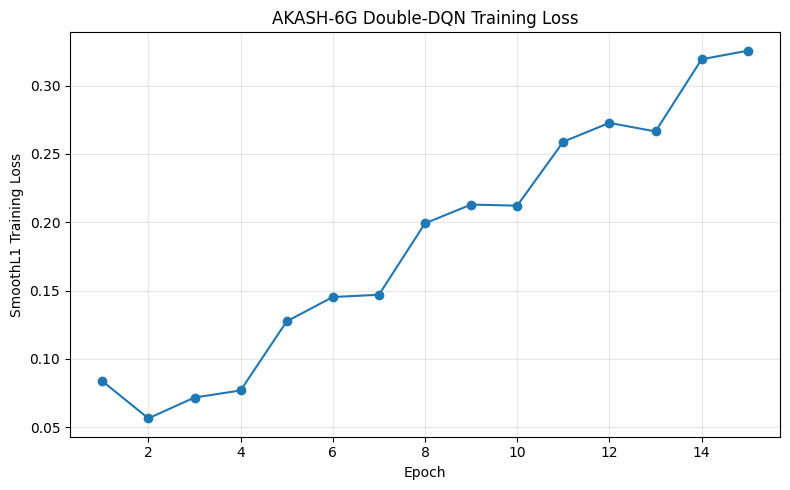

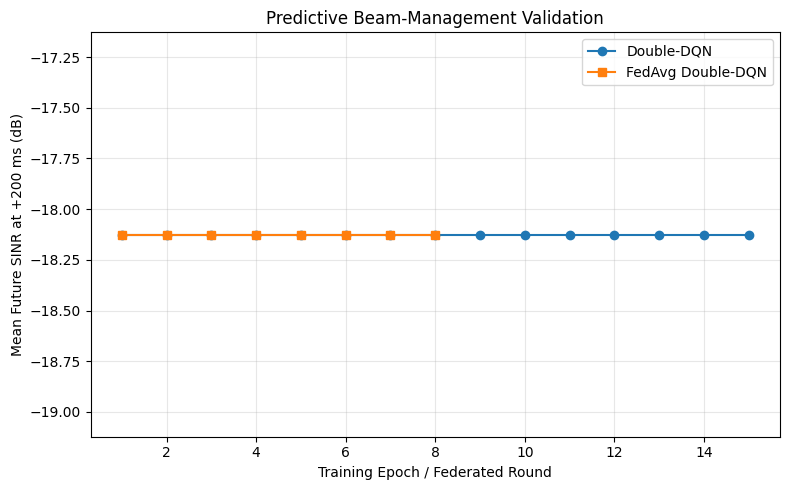

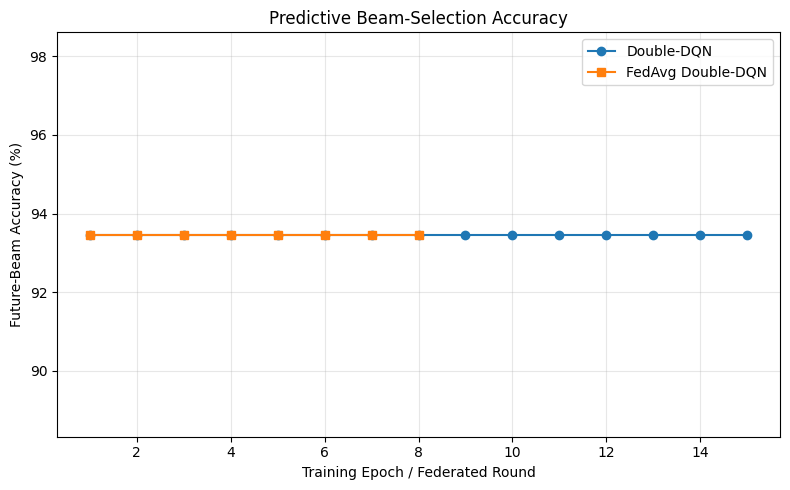

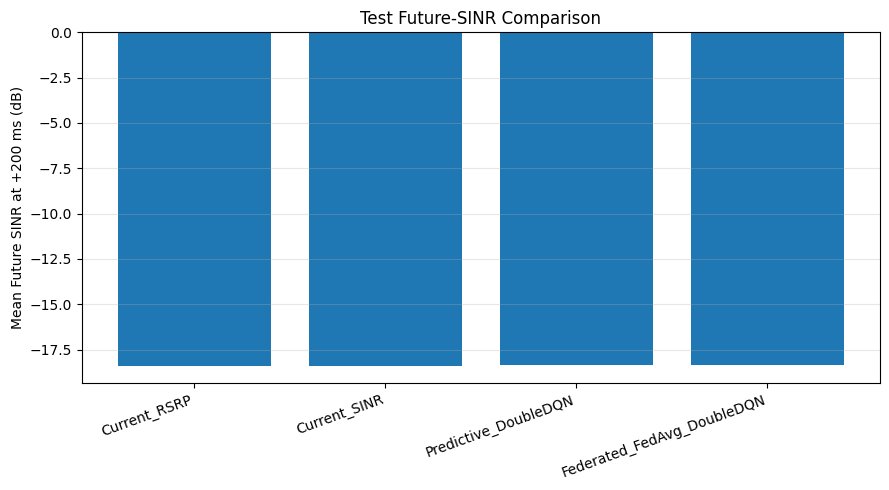

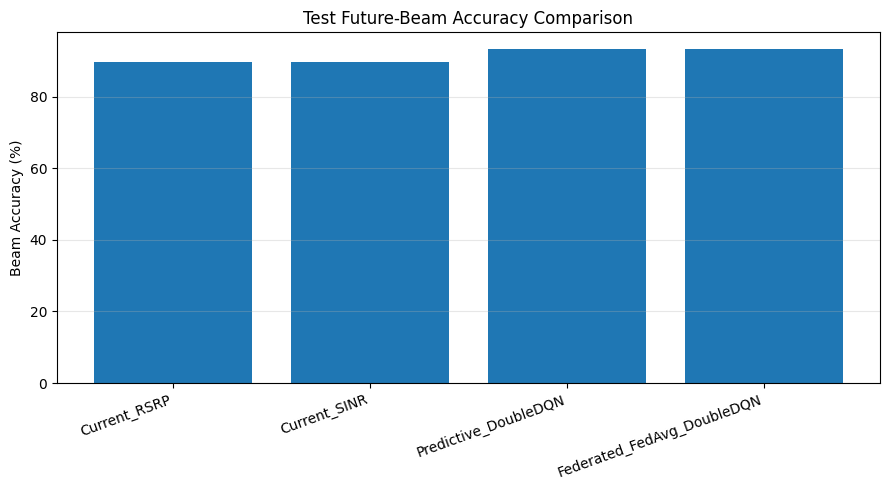


FINAL TEST RESULTS
                    Method  Future_SINR_dB  Beam_Accuracy_pct  Beam_Switch_Rate_pct  Mean_Reward
              Current_RSRP      -18.421789          89.595506              8.137828     3.398201
              Current_SINR      -18.423500          89.543071              8.202247     3.394977
      Predictive_DoubleDQN      -18.324329          93.285393              0.000000     3.805236
Federated_FedAvg_DoubleDQN      -18.324329          93.285393              0.000000     3.805236

Hard-case analysis:
                    Method  Hard_Cases_Current_vs_Future  Hard_Case_Accuracy_pct
      Predictive_DoubleDQN                          4482                     0.0
Federated_FedAvg_DoubleDQN                          4482                     0.0

All outputs saved to: /content/AKASH6G_AKASH6G_FINAL_RESULTS
Total runtime: 9.51 min
READY: physics audit -> predictive Double-DQN -> optional FedAvg


In [ ]:
import os
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42

# Colab path. For Kaggle, change this to the Kaggle input path.
DATASET_PATH = Path(
    "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv"
)

# Also support the filename used in some Colab uploads.
ALTERNATE_DATASET_PATH = Path(
    "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
)

OUTPUT_DIR = Path("/content/AKASH6G_AKASH6G_FINAL_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Physical / temporal configuration
N_BEAMS = 4
DT_MS = 20
PREDICTION_HORIZON_MS = 200
H_STEPS = PREDICTION_HORIZON_MS // DT_MS

# Dataset structure
ROWS_PER_UE = 100
VALID_ROWS_PER_UE = ROWS_PER_UE - H_STEPS
TRANSITIONS_PER_UE = VALID_ROWS_PER_UE - 1

# Train / validation / test split is by UE, never by row.
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Double-DQN
GAMMA = 0.95
LEARNING_RATE = 1e-3
BATCH_SIZE = 512
EPOCHS = 15
REPLAY_CAPACITY = 350_000
MIN_REPLAY = 5_000
TARGET_UPDATE_STEPS = 1_000
GRAD_CLIP = 5.0

# Exploration is used during optimization only.
EPS_START = 1.0
EPS_END = 0.05

# Reward design
SINR_THRESHOLD_DB = 5.0
W_THROUGHPUT = 1.0
W_SWITCH = 0.5
W_FAILURE = 2.0
HANDOVER_COST = 10.0
FAILURE_COST = 50.0

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 8
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 1
FED_BATCH_SIZE = 512
FED_LR = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ================================================================
# 2. COLUMN DEFINITIONS
# ================================================================

CONTINUOUS_STATE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "beam0_RSRP_dBm",
    "beam1_RSRP_dBm",
    "beam2_RSRP_dBm",
    "beam3_RSRP_dBm",
    "beam0_SINR_dB",
    "beam1_SINR_dB",
    "beam2_SINR_dB",
    "beam3_SINR_dB",
]

SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]
RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]

REQUIRED_COLS = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    *CONTINUOUS_STATE_COLS,
    *SINR_COLS,
    *RSRP_COLS,
]


# ================================================================
# 3. UTILITY FUNCTIONS
# ================================================================

def log(msg=""):
    print(msg, flush=True)


def beam_to_int(x):
    """Convert beam0/beam1/... or numeric labels to integer 0..3."""
    if pd.isna(x):
        return -1

    if isinstance(x, str):
        s = x.strip().lower()
        if s.startswith("beam"):
            s = s.replace("beam", "", 1)
        try:
            return int(float(s))
        except ValueError:
            return -1

    try:
        return int(float(x))
    except (TypeError, ValueError):
        return -1


def convert_beam_column(series):
    return series.map(beam_to_int).astype(np.int16)


def resolve_dataset_path():
    if DATASET_PATH.exists():
        return DATASET_PATH
    if ALTERNATE_DATASET_PATH.exists():
        return ALTERNATE_DATASET_PATH
    raise FileNotFoundError(
        "\nDataset not found.\n"
        f"Tried:\n  {DATASET_PATH}\n  {ALTERNATE_DATASET_PATH}\n"
        "\nUpload the corrected physical CSV to Colab or change DATASET_PATH."
    )


def save_json(path, obj):
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        return str(v)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=convert)


# ================================================================
# 4. LOAD + NORMALIZE LABELS
# ================================================================

def load_dataset():
    path = resolve_dataset_path()
    log("=" * 72)
    log("AKASH-6G — PROFESSIONAL PREDICTIVE DOUBLE-DQN PIPELINE")
    log("=" * 72)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path)

    # Normalize beam columns immediately.
    for col in ["Current_Beam", "Optimal_Beam", "Future_Beam"]:
        df[col] = convert_beam_column(df[col])

    # Ensure flag is numeric.
    df["Valid_Future_Target"] = pd.to_numeric(
        df["Valid_Future_Target"], errors="coerce"
    ).fillna(0).astype(np.int8)

    # Numeric conversion for all physical columns.
    for col in CONTINUOUS_STATE_COLS + ["UE_ID", "Time_ms"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    log(f"Loaded shape: {df.shape}")
    return df, path


# ================================================================
# 5. PHYSICAL DATASET AUDIT
# ================================================================

def audit_dataset(df):
    log("\n[1/7] DATASET AUDIT")

    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    unique_ues = int(df["UE_ID"].nunique())

    log(f"Rows       : {len(df):,}")
    log(f"Columns    : {len(df.columns)}")
    log(f"Unique UEs : {unique_ues:,}")
    log(f"Missing    : {missing:,}")
    log(f"Duplicates : {duplicates:,}")

    if missing or duplicates:
        raise ValueError("Dataset audit failed: missing values or duplicate rows.")

    # Valid beam labels.
    for col in ["Current_Beam", "Optimal_Beam"]:
        if not df[col].between(0, N_BEAMS - 1).all():
            raise ValueError(f"Invalid values in {col}.")

    # Time spacing and per-UE ordering.
    bad_dt = 0
    bad_rows_per_ue = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            bad_rows_per_ue += 1
        dts = np.diff(g["Time_ms"].to_numpy(dtype=float))
        if len(dts) and np.max(np.abs(dts - DT_MS)) > 1e-9:
            bad_dt += 1

    log(f"UEs with wrong row count: {bad_rows_per_ue}")
    log(f"UEs with wrong time step : {bad_dt}")

    if bad_rows_per_ue or bad_dt:
        raise ValueError("Temporal dataset audit failed.")

    # Current beam linkage.
    current_rsrp = df[RSRP_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]
    current_sinr = df[SINR_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]

    rsrp_err = np.max(np.abs(current_rsrp - df["Current_RSRP_dBm"].to_numpy()))
    sinr_err = np.max(np.abs(current_sinr - df["Current_SINR_dB"].to_numpy()))

    # Optimal beam should be the physical strongest-beam decision.
    rsrp_argmax = df[RSRP_COLS].to_numpy().argmax(axis=1)
    sinr_argmax = df[SINR_COLS].to_numpy().argmax(axis=1)

    opt = df["Optimal_Beam"].to_numpy()

    opt_rsrp_acc = float(np.mean(rsrp_argmax == opt))
    opt_sinr_acc = float(np.mean(sinr_argmax == opt))

    log(f"Current-RSRP linkage max error: {rsrp_err:.6g} dB")
    log(f"Current-SINR linkage max error: {sinr_err:.6g} dB")
    log(f"Optimal vs RSRP argmax       : {100*opt_rsrp_acc:.3f}%")
    log(f"Optimal vs SINR argmax       : {100*opt_sinr_acc:.3f}%")

    # Future target verification.
    future_mismatch = 0
    flag_mismatch = 0
    valid_rows = 0

    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(VALID_ROWS_PER_UE):
            expected = int(g.loc[t + H_STEPS, "Optimal_Beam"])
            actual = int(g.loc[t, "Future_Beam"])
            if expected != actual:
                future_mismatch += 1

            if int(g.loc[t, "Valid_Future_Target"]) != 1:
                flag_mismatch += 1
            valid_rows += 1

        for t in range(VALID_ROWS_PER_UE, ROWS_PER_UE):
            if int(g.loc[t, "Valid_Future_Target"]) != 0:
                flag_mismatch += 1

    log(f"+200 ms future mismatches    : {future_mismatch}")
    log(f"Future validity mismatches   : {flag_mismatch}")
    log(f"Valid predictive rows        : {valid_rows:,}")

    if future_mismatch or flag_mismatch:
        raise ValueError("Future-target audit failed.")

    # Current beam should equal previous optimal beam after the first sample
    # in the supplied physical generator.
    current_prev_mismatch = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(1, len(g)):
            if int(g.loc[t, "Current_Beam"]) != int(g.loc[t - 1, "Optimal_Beam"]):
                current_prev_mismatch += 1

    log(f"Current-beam temporal linkage : {current_prev_mismatch}")

    # This is diagnostic, not a hard failure. If RSRP and SINR rank every beam
    # identically, the physics model gives the DQN little independent SINR
    # decision structure. We explicitly report it rather than hiding it.
    rank_agreement = float(np.mean(rsrp_argmax == sinr_argmax))
    log(f"RSRP-argmax == SINR-argmax    : {100*rank_agreement:.3f}%")

    if rank_agreement > 0.999:
        log("WARNING: RSRP and SINR produce essentially identical beam rankings.")
        log("This is a physical-model limitation, not a Python training error.")
        log("For the paper, improve the MATLAB interference model if independent")
        log("RSRP-vs-SINR beam decisions are required.")

    audit = {
        "rows": len(df),
        "columns": len(df.columns),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "rows_per_ue": ROWS_PER_UE,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "valid_predictive_rows": valid_rows,
        "current_rsrp_max_error_db": float(rsrp_err),
        "current_sinr_max_error_db": float(sinr_err),
        "optimal_vs_rsrp_argmax": opt_rsrp_acc,
        "optimal_vs_sinr_argmax": opt_sinr_acc,
        "rsrp_sinr_argmax_agreement": rank_agreement,
    }

    return audit


# ================================================================
# 6. STATE CONSTRUCTION
# ================================================================

def build_states(df, train_ues):
    log("\n[2/7] BUILDING 19-D STATES")

    # Sort once. All later transition logic is per UE.
    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    train_mask = df["UE_ID"].isin(train_ues)
    train_rows = df.loc[train_mask]

    X_train_raw = train_rows[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)

    mean = X_train_raw.mean(axis=0)
    std = X_train_raw.std(axis=0)
    std[std < 1e-8] = 1.0

    df_state = df[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)
    df_state = (df_state - mean) / std

    # One-hot current beam: 4 additional features.
    current = df["Current_Beam"].to_numpy(dtype=np.int64)
    onehot = np.zeros((len(df), N_BEAMS), dtype=np.float32)
    onehot[np.arange(len(df)), current] = 1.0

    state = np.concatenate([df_state, onehot], axis=1).astype(np.float32)

    assert state.shape[1] == 19

    df["_state_row"] = np.arange(len(df), dtype=np.int64)

    return df, state, mean, std


# ================================================================
# 7. UE SPLIT
# ================================================================

def split_ues(df):
    log("\n[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT")

    ues = np.sort(df["UE_ID"].unique())
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)

    n = len(ues)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)

    train_ues = np.sort(ues[:n_train])
    val_ues = np.sort(ues[n_train:n_train + n_val])
    test_ues = np.sort(ues[n_train + n_val:])

    log(f"Train UEs: {len(train_ues)}")
    log(f"Val UEs  : {len(val_ues)}")
    log(f"Test UEs : {len(test_ues)}")

    return train_ues, val_ues, test_ues


# ================================================================
# 8. COUNTERFACTUAL OFFLINE RL TRANSITIONS
# ================================================================

def reward_vector(future_sinr, previous_beam):
    """
    Compute reward for ALL 4 possible beam actions.

    Crucially:
      - Future_Beam is NOT used.
      - The action is not chosen from the future target.
      - The future SINR vector is used to score every possible action.
      - A constant failure penalty is centered out for optimization,
        because it is action-independent when all four future SINRs are
        below threshold.
    """
    sinr = np.asarray(future_sinr, dtype=np.float32)

    throughput = np.log2(1.0 + np.power(10.0, sinr / 10.0))

    switch_penalty = (np.arange(N_BEAMS) != int(previous_beam)).astype(np.float32)
    failure_penalty = (sinr < SINR_THRESHOLD_DB).astype(np.float32)

    raw = (
        W_THROUGHPUT * throughput
        - W_SWITCH * HANDOVER_COST * switch_penalty
        - W_FAILURE * FAILURE_COST * failure_penalty
    )

    # Per-state centering preserves action ordering but improves numerical
    # conditioning when the failure penalty is identical for every action.
    centered = raw - np.mean(raw)

    return raw.astype(np.float32), centered.astype(np.float32)


def build_transition_pool(df, state, ue_ids):
    """
    Build 4 counterfactual actions for every valid decision state.

    Number of states per UE = 89.
    Number of transitions per UE = 89 * 4 = 356.

    The reward for action a is computed using the actual physical beam-a
    SINR at t+200 ms.
    """
    log(f"Building transition pool for {len(ue_ids)} UEs...")

    ue_set = set(int(x) for x in ue_ids)

    states = []
    actions = []
    rewards = []
    raw_rewards = []
    next_states = []
    dones = []
    future_sinr_records = []
    current_beams = []
    future_optimal = []

    grouped = df[df["UE_ID"].isin(ue_set)].groupby(
        "UE_ID", sort=True, group_keys=False
    )

    for ue, g in grouped:
        g = g.sort_values("Time_ms").reset_index(drop=True)

        row_idx = g["_state_row"].to_numpy(dtype=np.int64)

        for t in range(TRANSITIONS_PER_UE):
            # State at t and next observed state at t+1.
            s = state[row_idx[t]]
            ns = state[row_idx[t + 1]]

            # True future physical SINR vector at t+200 ms.
            future_row = g.iloc[t + H_STEPS]
            future_sinr = future_row[SINR_COLS].to_numpy(dtype=np.float32)

            previous_beam = int(g.iloc[t]["Current_Beam"])

            raw_r, centered_r = reward_vector(future_sinr, previous_beam)

            done = 1.0 if t == TRANSITIONS_PER_UE - 1 else 0.0

            for a in range(N_BEAMS):
                states.append(s)
                actions.append(a)
                rewards.append(centered_r[a])
                raw_rewards.append(raw_r[a])
                next_states.append(ns)
                dones.append(done)
                future_sinr_records.append(future_sinr)
                current_beams.append(previous_beam)
                future_optimal.append(int(future_row["Optimal_Beam"]))

    X = np.asarray(states, dtype=np.float32)
    A = np.asarray(actions, dtype=np.int64)
    R = np.asarray(rewards, dtype=np.float32)
    RAW_R = np.asarray(raw_rewards, dtype=np.float32)
    NX = np.asarray(next_states, dtype=np.float32)
    D = np.asarray(dones, dtype=np.float32)
    FS = np.asarray(future_sinr_records, dtype=np.float32)
    CB = np.asarray(current_beams, dtype=np.int64)
    FO = np.asarray(future_optimal, dtype=np.int64)

    log(f"Transitions: {len(X):,}")
    log(
        f"Pool shapes: states={X.shape}, rewards={R.shape}, "
        f"raw_rewards={RAW_R.shape}, future_sinr={FS.shape}"
    )

    return {
        "states": X,
        "actions": A,
        "rewards": R,
        "raw_rewards": RAW_R,
        "next_states": NX,
        "dones": D,
        "future_sinr": FS,
        "current_beam": CB,
        "future_optimal": FO,
    }


# ================================================================
# 9. REPLAY BUFFER
# ================================================================

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.states = None
        self.actions = None
        self.rewards = None
        self.next_states = None
        self.dones = None
        self.size = 0

    def build(self, pool):
        n = min(len(pool["states"]), self.capacity)

        # Deterministic subset if pool exceeds capacity.
        if n < len(pool["states"]):
            rng = np.random.default_rng(SEED)
            idx = rng.choice(len(pool["states"]), size=n, replace=False)
        else:
            idx = np.arange(n)

        self.states = pool["states"][idx]
        self.actions = pool["actions"][idx]
        self.rewards = pool["rewards"][idx]
        self.next_states = pool["next_states"][idx]
        self.dones = pool["dones"][idx]
        self.size = n

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.from_numpy(self.states[idx]),
            torch.from_numpy(self.actions[idx]),
            torch.from_numpy(self.rewards[idx]),
            torch.from_numpy(self.next_states[idx]),
            torch.from_numpy(self.dones[idx]),
        )


# ================================================================
# 10. DOUBLE-DQN NETWORK
# ================================================================

class DoubleDQN(nn.Module):
    def __init__(self, state_dim=19, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def predict_actions(model, X):
    model.eval()
    out = []
    batch_size = 8192

    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i + batch_size]).to(DEVICE)
        q = model(xb)
        out.append(q.argmax(dim=1).cpu().numpy())

    return np.concatenate(out).astype(np.int64)


# ================================================================
# 11. DOUBLE-DQN TRAINING
# ================================================================

def epsilon_at_step(step, total_steps):
    if total_steps <= 1:
        return EPS_END
    # Exponential schedule that reaches EPS_END at final step.
    frac = step / float(total_steps - 1)
    return float(EPS_START * ((EPS_END / EPS_START) ** frac))


def train_double_dqn(train_pool, val_pool):
    log("\n[4/7] TRAINING DOUBLE-DQN")

    replay = ReplayBuffer(REPLAY_CAPACITY)
    replay.build(train_pool)

    if replay.size < MIN_REPLAY:
        raise ValueError("Replay buffer is too small for training.")

    model = DoubleDQN().to(DEVICE)
    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.SmoothL1Loss()

    batches_per_epoch = max(1, replay.size // BATCH_SIZE)
    total_steps = batches_per_epoch * EPOCHS

    history = []
    global_step = 0
    best_val_reward = -np.inf
    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(batches_per_epoch):
            states, actions, rewards, next_states, dones = replay.sample(BATCH_SIZE)

            states = states.to(DEVICE)
            actions = actions.to(DEVICE)
            rewards = rewards.to(DEVICE)
            next_states = next_states.to(DEVICE)
            dones = dones.to(DEVICE)

            # Double-DQN:
            # online network chooses next action
            # target network evaluates that chosen action
            q_values = model(states)
            q_selected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

            with torch.no_grad():
                next_actions = model(next_states).argmax(dim=1)
                next_q = target(next_states).gather(
                    1, next_actions.unsqueeze(1)
                ).squeeze(1)

                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q_selected, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            global_step += 1
            losses.append(float(loss.item()))

            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        # Validation on the full counterfactual validation pool.
        val_metrics = evaluate_policy(model, val_pool)

        mean_loss = float(np.mean(losses))
        eps = epsilon_at_step(
            min(global_step, total_steps - 1), total_steps
        )

        row = {
            "epoch": epoch,
            "loss": mean_loss,
            "val_reward": val_metrics["mean_reward"],
            "val_raw_reward": val_metrics["mean_raw_reward"],
            "val_future_sinr_db": val_metrics["future_sinr_db"],
            "val_accuracy_pct": val_metrics["accuracy_pct"],
            "val_switch_rate_pct": val_metrics["switch_rate_pct"],
            "epsilon": eps,
        }
        history.append(row)

        log(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {mean_loss:.5f} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Eps {eps:.4f}"
        )

        if val_metrics["mean_reward"] > best_val_reward:
            best_val_reward = val_metrics["mean_reward"]
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    log(f"Training time: {elapsed/60:.2f} min")

    return model, pd.DataFrame(history)


# ================================================================
# 12. POLICY EVALUATION
# ================================================================

@torch.no_grad()
def evaluate_policy(model, pool):
    """Evaluate one learned beam decision per unique physical state.

    Pool layout is:
        states      = (N*4, 19)
        rewards     = (N*4,)
        raw_rewards = (N*4,)
        future_sinr = (N*4, 4)

    Thus raw_rewards reshapes to (N,4), while future_sinr reshapes
    to (N,4,4) and then keeps the first copy of each state.
    """
    model.eval()

    total = len(pool["states"])
    if total == 0:
        raise ValueError("Cannot evaluate an empty pool.")
    if total % N_BEAMS != 0:
        raise ValueError(f"Pool size {total} is not divisible by {N_BEAMS}.")

    n_states = total // N_BEAMS

    if pool["raw_rewards"].shape != (total,):
        raise ValueError(
            f"raw_rewards shape {pool['raw_rewards'].shape} is invalid; expected ({total},)."
        )
    if pool["future_sinr"].shape != (total, N_BEAMS):
        raise ValueError(
            f"future_sinr shape {pool['future_sinr'].shape} is invalid; "
            f"expected ({total}, {N_BEAMS})."
        )
    if len(pool["current_beam"]) != total or len(pool["future_optimal"]) != total:
        raise ValueError("Beam metadata length does not match the transition pool.")

    unique_states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS].astype(np.int64)
    optimal = pool["future_optimal"][::N_BEAMS].astype(np.int64)

    future_sinr = pool["future_sinr"].reshape(
        n_states, N_BEAMS, N_BEAMS
    )[:, 0, :]

    raw_rewards = pool["raw_rewards"].reshape(
        n_states, N_BEAMS
    )

    predicted = predict_actions(model, unique_states)

    chosen_sinr = future_sinr[np.arange(n_states), predicted]
    chosen_raw = raw_rewards[np.arange(n_states), predicted]

    centered = np.empty(n_states, dtype=np.float32)
    for i in range(n_states):
        _, c = reward_vector(future_sinr[i], int(current[i]))
        centered[i] = c[predicted[i]]

    accuracy = float(np.mean(predicted == optimal) * 100.0)
    switch_rate = float(np.mean(predicted != current) * 100.0)

    hard = current != optimal
    hard_accuracy = (
        float(np.mean(predicted[hard] == optimal[hard]) * 100.0)
        if np.any(hard) else float("nan")
    )

    return {
        "mean_reward": float(centered.mean()),
        "mean_raw_reward": float(chosen_raw.mean()),
        "future_sinr_db": float(chosen_sinr.mean()),
        "accuracy_pct": accuracy,
        "switch_rate_pct": switch_rate,
        "hard_accuracy_pct": hard_accuracy,
        "hard_cases": int(hard.sum()),
        "predicted_actions": predicted,
        "future_optimal": optimal,
        "current_beam": current,
        "future_sinr_matrix": future_sinr,
    }


# ================================================================
# 13. BASELINES
# ================================================================

def evaluate_baselines(pool):
    log("\n[5/7] BASELINES")

    future_sinr = pool["future_sinr"][::N_BEAMS]
    current_beam = pool["current_beam"][::N_BEAMS]
    future_optimal = pool["future_optimal"][::N_BEAMS]

    # Baseline A: choose strongest current RSRP/SINR.
    # Since current SINR is directly available in the state, the physical
    # beam-specific SINR columns are recovered from the first state block.
    X = pool["states"][::N_BEAMS]

    # Continuous state positions 11..14 are beam SINR after the 11 first
    # continuous features? The state has 15 continuous features followed by
    # 4 one-hot current-beam values.
    current_sinr_norm = X[:, 11:15]

    # Normalization changes values but not ordering.
    current_sinr_choice = current_sinr_norm.argmax(axis=1)

    # RSRP positions 7..10.
    current_rsrp_norm = X[:, 7:11]
    current_rsrp_choice = current_rsrp_norm.argmax(axis=1)

    results = {}

    for name, choice in [
        ("Current_RSRP", current_rsrp_choice),
        ("Current_SINR", current_sinr_choice),
    ]:
        chosen = future_sinr[np.arange(len(future_sinr)), choice]
        acc = np.mean(choice == future_optimal) * 100.0
        switch = np.mean(choice != current_beam) * 100.0

        raw = []
        centered = []
        for i in range(len(choice)):
            r, c = reward_vector(future_sinr[i], current_beam[i])
            raw.append(r[choice[i]])
            centered.append(c[choice[i]])

        results[name] = {
            "future_sinr_db": float(np.mean(chosen)),
            "accuracy_pct": float(acc),
            "switch_rate_pct": float(switch),
            "mean_reward": float(np.mean(centered)),
            "mean_raw_reward": float(np.mean(raw)),
            "actions": choice,
        }

    return results


# ================================================================
# 14. HARD-CASE ANALYSIS
# ================================================================

def hard_case_accuracy(pred, optimal, current):
    mask = current != optimal
    if not np.any(mask):
        return float("nan"), 0
    return float(np.mean(pred[mask] == optimal[mask]) * 100.0), int(mask.sum())


# ================================================================
# 15. FEDERATED AVERAGING
# ================================================================

def average_state_dicts(state_dicts, weights):
    total = float(np.sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")

    global_state = {}
    for key in state_dicts[0].keys():
        value = None
        for sd, w in zip(state_dicts, weights):
            term = sd[key].float() * (float(w) / total)
            value = term if value is None else value + term
        global_state[key] = value

    return global_state


def local_train(client_model, pool, epochs=1, lr=1e-3, batch_size=512):
    client_model.train()
    optimizer = optim.Adam(client_model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss()

    n = len(pool["states"])
    rng = np.random.default_rng(SEED + n)

    for _ in range(epochs):
        idx = rng.permutation(n)

        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            if len(b) < 2:
                continue

            states = torch.from_numpy(pool["states"][b]).to(DEVICE)
            actions = torch.from_numpy(pool["actions"][b]).to(DEVICE)
            rewards = torch.from_numpy(pool["rewards"][b]).to(DEVICE)
            next_states = torch.from_numpy(pool["next_states"][b]).to(DEVICE)
            dones = torch.from_numpy(pool["dones"][b]).to(DEVICE)

            q = client_model(states).gather(
                1, actions.unsqueeze(1)
            ).squeeze(1)

            with torch.no_grad():
                next_a = client_model(next_states).argmax(dim=1)
                next_q = client_model(next_states).gather(
                    1, next_a.unsqueeze(1)
                ).squeeze(1)
                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(client_model.parameters(), GRAD_CLIP)
            optimizer.step()

    return client_model


def federated_train(client_pools, val_pool, initial_model):
    """
    FedAvg:
      1. Copy global model to selected clients.
      2. Train locally.
      3. Weighted average model parameters.
      4. Broadcast new global model.
    """
    log("\n[6/7] FEDERATED LEARNING — FedAvg")

    global_model = DoubleDQN().to(DEVICE)
    global_model.load_state_dict(initial_model.state_dict())

    rng = np.random.default_rng(SEED)
    history = []

    n_clients = len(client_pools)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= n_clients:
            selected = np.arange(n_clients)
        else:
            selected = rng.choice(
                n_clients, size=CLIENTS_PER_ROUND, replace=False
            )

        local_states = []
        weights = []

        for client_id in selected:
            local_model = DoubleDQN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())

            local_train(
                local_model,
                client_pools[int(client_id)],
                epochs=LOCAL_EPOCHS,
                lr=FED_LR,
                batch_size=FED_BATCH_SIZE,
            )

            local_states.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            weights.append(len(client_pools[int(client_id)]["states"]))

        new_state = average_state_dicts(local_states, weights)
        global_model.load_state_dict(new_state)

        metrics = evaluate_policy(global_model, val_pool)

        row = {
            "round": rnd,
            "val_reward": metrics["mean_reward"],
            "val_raw_reward": metrics["mean_raw_reward"],
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
        }
        history.append(row)

        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

    return global_model, pd.DataFrame(history)


# ================================================================
# 16. PREDICTION TABLE
# ================================================================

def make_prediction_table(pool, dqn_result, fed_result, test_ues):
    future_sinr = dqn_result["future_sinr_matrix"]
    current = dqn_result["current_beam"]
    optimal = dqn_result["future_optimal"]

    dqn_actions = dqn_result["predicted_actions"]
    fed_actions = (
        fed_result["predicted_actions"]
        if fed_result is not None else np.full_like(dqn_actions, -1)
    )

    rows = len(dqn_actions)

    out = pd.DataFrame({
        "Sample": np.arange(rows),
        "Current_Beam": current,
        "Future_Optimal_Beam": optimal,
        "DoubleDQN_Beam": dqn_actions,
        "FedAvg_DoubleDQN_Beam": fed_actions,
        "DQN_Correct": (dqn_actions == optimal).astype(int),
        "FedAvg_Correct": (fed_actions == optimal).astype(int),
        "DQN_Switch": (dqn_actions != current).astype(int),
        "FedAvg_Switch": (fed_actions != current).astype(int),
    })

    out["DQN_Future_SINR_dB"] = future_sinr[
        np.arange(rows), dqn_actions
    ]
    if fed_result is not None:
        out["FedAvg_Future_SINR_dB"] = future_sinr[
            np.arange(rows), fed_actions
        ]

    # Add UE IDs approximately through the test pool's state order.
    # Each state occurs exactly four times in the pool.
    out["Test_UE_Index"] = np.repeat(
        np.arange(len(test_ues)),
        TRANSITIONS_PER_UE
    )[:rows]
    out["UE_ID"] = out["Test_UE_Index"].map(
        {i: int(u) for i, u in enumerate(test_ues)}
    )

    return out


# ================================================================
# 17. PLOTS
# ================================================================

def save_plots(dqn_history, fed_history, comparison, output_dir):
    plt.figure(figsize=(8, 5))
    plt.plot(dqn_history["epoch"], dqn_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 Training Loss")
    plt.title("AKASH-6G Double-DQN Training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "01_training_loss.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_future_sinr_db"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_future_sinr_db"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "02_validation_future_sinr.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_accuracy_pct"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_accuracy_pct"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Future-Beam Accuracy (%)")
    plt.title("Predictive Beam-Selection Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "03_validation_accuracy.png", dpi=300)
    plt.show()

    methods = list(comparison["Method"])
    values = list(comparison["Future_SINR_dB"])

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "04_test_future_sinr_comparison.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 5))
    values = list(comparison["Beam_Accuracy_pct"])

    plt.bar(methods, values)
    plt.ylabel("Beam Accuracy (%)")
    plt.title("Test Future-Beam Accuracy Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "05_test_accuracy_comparison.png", dpi=300)
    plt.show()


# ================================================================
# 18. MAIN EXPERIMENT
# ================================================================

def main():
    total_start = time.time()

    df, dataset_path = load_dataset()

    audit = audit_dataset(df)

    # UE split must happen before normalization.
    train_ues, val_ues, test_ues = split_ues(df)

    df, state, mean, std = build_states(df, train_ues)

    # Save normalization.
    np.save(OUTPUT_DIR / "train_state_mean.npy", mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    # Build pools.
    log("\nBuilding TRAIN counterfactual pool...")
    train_pool = build_transition_pool(df, state, train_ues)

    log("\nBuilding VALIDATION counterfactual pool...")
    val_pool = build_transition_pool(df, state, val_ues)

    log("\nBuilding TEST counterfactual pool...")
    test_pool = build_transition_pool(df, state, test_ues)

    # Train central Double-DQN.
    dqn_model, dqn_history = train_double_dqn(
        train_pool, val_pool
    )

    torch.save(
        dqn_model.state_dict(),
        OUTPUT_DIR / "AKASH6G_DoubleDQN_best.pt",
    )
    dqn_history.to_csv(
        OUTPUT_DIR / "DoubleDQN_training_history.csv",
        index=False,
    )

    dqn_test = evaluate_policy(dqn_model, test_pool)
    baseline = evaluate_baselines(test_pool)

    # Federated clients: split the training UEs into client groups.
    fed_model = None
    fed_history = None
    fed_test = None

    if RUN_FEDERATED:
        log("\nPreparing federated clients...")

        # 10 clients by deterministic UE partitions.
        n_clients = max(CLIENTS_PER_ROUND, 10)
        client_ue_groups = np.array_split(train_ues, n_clients)

        client_pools = [
            build_transition_pool(df, state, group)
            for group in client_ue_groups
            if len(group) > 0
        ]

        fed_model, fed_history = federated_train(
            client_pools,
            val_pool,
            dqn_model,
        )

        torch.save(
            fed_model.state_dict(),
            OUTPUT_DIR / "AKASH6G_FedAvg_DoubleDQN.pt",
        )
        fed_history.to_csv(
            OUTPUT_DIR / "FedAvg_history.csv",
            index=False,
        )

        fed_test = evaluate_policy(fed_model, test_pool)

    # ------------------------------------------------------------
    # Final test table
    # ------------------------------------------------------------
    rows = []

    rows.append({
        "Method": "Current_RSRP",
        "Future_SINR_dB": baseline["Current_RSRP"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_RSRP"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_RSRP"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_RSRP"]["mean_reward"],
    })

    rows.append({
        "Method": "Current_SINR",
        "Future_SINR_dB": baseline["Current_SINR"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_SINR"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_SINR"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_SINR"]["mean_reward"],
    })

    rows.append({
        "Method": "Predictive_DoubleDQN",
        "Future_SINR_dB": dqn_test["future_sinr_db"],
        "Beam_Accuracy_pct": dqn_test["accuracy_pct"],
        "Beam_Switch_Rate_pct": dqn_test["switch_rate_pct"],
        "Mean_Reward": dqn_test["mean_reward"],
    })

    if fed_test is not None:
        rows.append({
            "Method": "Federated_FedAvg_DoubleDQN",
            "Future_SINR_dB": fed_test["future_sinr_db"],
            "Beam_Accuracy_pct": fed_test["accuracy_pct"],
            "Beam_Switch_Rate_pct": fed_test["switch_rate_pct"],
            "Mean_Reward": fed_test["mean_reward"],
        })

    comparison = pd.DataFrame(rows)

    comparison.to_csv(
        OUTPUT_DIR / "AKASH6G_FINAL_TEST_COMPARISON.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Hard-case analysis
    # ------------------------------------------------------------
    dqn_hard_acc, n_hard = hard_case_accuracy(
        dqn_test["predicted_actions"],
        dqn_test["future_optimal"],
        dqn_test["current_beam"],
    )

    if fed_test is not None:
        fed_hard_acc, _ = hard_case_accuracy(
            fed_test["predicted_actions"],
            fed_test["future_optimal"],
            fed_test["current_beam"],
        )
    else:
        fed_hard_acc = float("nan")

    hard_case = pd.DataFrame([{
        "Method": "Predictive_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": dqn_hard_acc,
    }, {
        "Method": "Federated_FedAvg_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": fed_hard_acc,
    }])

    hard_case.to_csv(
        OUTPUT_DIR / "AKASH6G_HARD_CASE_ANALYSIS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Prediction export
    # ------------------------------------------------------------
    pred_table = make_prediction_table(
        test_pool,
        dqn_test,
        fed_test,
        test_ues,
    )
    pred_table.to_csv(
        OUTPUT_DIR / "AKASH6G_TEST_PREDICTIONS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Final audit / config
    # ------------------------------------------------------------
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_rows_per_ue": VALID_ROWS_PER_UE,
        "transitions_per_ue": TRANSITIONS_PER_UE,
        "state_dimension": 19,
        "train_ues": len(train_ues),
        "val_ues": len(val_ues),
        "test_ues": len(test_ues),
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "target_update_steps": TARGET_UPDATE_STEPS,
        "replay_capacity": REPLAY_CAPACITY,
        "reward": {
            "sinr_threshold_db": SINR_THRESHOLD_DB,
            "w_throughput": W_THROUGHPUT,
            "w_switch": W_SWITCH,
            "w_failure": W_FAILURE,
            "handover_cost": HANDOVER_COST,
            "failure_cost": FAILURE_COST,
        },
        "federated": {
            "enabled": RUN_FEDERATED,
            "rounds": FED_ROUNDS,
            "clients_per_round": CLIENTS_PER_ROUND,
            "local_epochs": LOCAL_EPOCHS,
        },
        "methodology": (
            "physics-backed counterfactual offline/dataset-driven "
            "Double-DQN with optional FedAvg"
        ),
    }

    save_json(OUTPUT_DIR / "AKASH6G_FINAL_CONFIG.json", config)
    save_json(OUTPUT_DIR / "AKASH6G_PHYSICAL_AUDIT.json", audit)

    with open(
        OUTPUT_DIR / "AKASH6G_FINAL_AUDIT.txt",
        "w",
        encoding="utf-8",
    ) as f:
        f.write("PROJECT AKASH-6G FINAL EXPERIMENT AUDIT\n")
        f.write("=" * 72 + "\n\n")
        f.write(f"Dataset: {dataset_path}\n")
        f.write(f"Rows: {len(df):,}\n")
        f.write(f"UEs: {df['UE_ID'].nunique():,}\n")
        f.write(f"State dimension: 19\n")
        f.write(f"Prediction horizon: {PREDICTION_HORIZON_MS} ms\n")
        f.write(f"Prediction steps: {H_STEPS}\n")
        f.write("\nIMPORTANT:\n")
        f.write(
            "This experiment is dataset-driven/counterfactual offline RL. "
            "The fixed dataset does not contain action-dependent next-state "
            "transitions.\n"
        )
        f.write(
            "Future_Beam is never used to choose the replay action. "
            "All four actions are evaluated using the future physical SINR "
            "vector, then Double-DQN learns from the resulting action pool.\n"
        )
        f.write(
            "\nDo not describe the generated CSV as measured satellite data. "
            "It is a physics-based simulation dataset.\n"
        )

    # ------------------------------------------------------------
    # Plots
    # ------------------------------------------------------------
    save_plots(
        dqn_history,
        fed_history,
        comparison,
        OUTPUT_DIR,
    )

    # ------------------------------------------------------------
    # Final console output
    # ------------------------------------------------------------
    log("\n" + "=" * 72)
    log("FINAL TEST RESULTS")
    log("=" * 72)
    print(comparison.to_string(index=False))

    log("\nHard-case analysis:")
    print(hard_case.to_string(index=False))

    log(f"\nAll outputs saved to: {OUTPUT_DIR}")
    log(f"Total runtime: {(time.time()-total_start)/60:.2f} min")
    log("READY: physics audit -> predictive Double-DQN -> optional FedAvg")


if __name__ == "__main__":
    main()


In [ ]:

import os
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42

# Colab path. For Kaggle, change this to the Kaggle input path.
DATASET_PATH = Path(
    "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv"
)

# Also support the filename used in some Colab uploads.
ALTERNATE_DATASET_PATH = Path(
    "/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv"
)

OUTPUT_DIR = Path("/content/AKASH6G_AKASH6G_FINAL_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Physical / temporal configuration
N_BEAMS = 4
DT_MS = 20
PREDICTION_HORIZON_MS = 200
H_STEPS = PREDICTION_HORIZON_MS // DT_MS

# Dataset structure
ROWS_PER_UE = 100
VALID_ROWS_PER_UE = ROWS_PER_UE - H_STEPS
TRANSITIONS_PER_UE = VALID_ROWS_PER_UE - 1

# Train / validation / test split is by UE, never by row.
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Double-DQN
GAMMA = 0.95
LEARNING_RATE = 1e-3
BATCH_SIZE = 512
EPOCHS = 15
REPLAY_CAPACITY = 350_000
MIN_REPLAY = 5_000
TARGET_UPDATE_STEPS = 1_000
GRAD_CLIP = 5.0

# Exploration is used during optimization only.
EPS_START = 1.0
EPS_END = 0.05

# Reward design
SINR_THRESHOLD_DB = 5.0
W_THROUGHPUT = 1.0
W_SWITCH = 0.5
W_FAILURE = 2.0
HANDOVER_COST = 10.0
FAILURE_COST = 50.0

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 8
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 1
FED_BATCH_SIZE = 512
FED_LR = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ================================================================
# 2. COLUMN DEFINITIONS
# ================================================================

CONTINUOUS_STATE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "beam0_RSRP_dBm",
    "beam1_RSRP_dBm",
    "beam2_RSRP_dBm",
    "beam3_RSRP_dBm",
    "beam0_SINR_dB",
    "beam1_SINR_dB",
    "beam2_SINR_dB",
    "beam3_SINR_dB",
]

SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]
RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]

REQUIRED_COLS = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    *CONTINUOUS_STATE_COLS,
    *SINR_COLS,
    *RSRP_COLS,
]


# ================================================================
# 3. UTILITY FUNCTIONS
# ================================================================

def log(msg=""):
    print(msg, flush=True)


def beam_to_int(x):
    """Convert beam0/beam1/... or numeric labels to integer 0..3."""
    if pd.isna(x):
        return -1

    if isinstance(x, str):
        s = x.strip().lower()
        if s.startswith("beam"):
            s = s.replace("beam", "", 1)
        try:
            return int(float(s))
        except ValueError:
            return -1

    try:
        return int(float(x))
    except (TypeError, ValueError):
        return -1


def convert_beam_column(series):
    return series.map(beam_to_int).astype(np.int16)


def resolve_dataset_path():
    if DATASET_PATH.exists():
        return DATASET_PATH
    if ALTERNATE_DATASET_PATH.exists():
        return ALTERNATE_DATASET_PATH
    raise FileNotFoundError(
        "\nDataset not found.\n"
        f"Tried:\n  {DATASET_PATH}\n  {ALTERNATE_DATASET_PATH}\n"
        "\nUpload the corrected physical CSV to Colab or change DATASET_PATH."
    )


def save_json(path, obj):
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        return str(v)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=convert)


# ================================================================
# 4. LOAD + NORMALIZE LABELS
# ================================================================

def load_dataset():
    path = resolve_dataset_path()
    log("=" * 72)
    log("AKASH-6G — PROFESSIONAL PREDICTIVE DOUBLE-DQN PIPELINE")
    log("=" * 72)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path)

    # Normalize beam columns immediately.
    for col in ["Current_Beam", "Optimal_Beam", "Future_Beam"]:
        df[col] = convert_beam_column(df[col])

    # Ensure flag is numeric.
    df["Valid_Future_Target"] = pd.to_numeric(
        df["Valid_Future_Target"], errors="coerce"
    ).fillna(0).astype(np.int8)

    # Numeric conversion for all physical columns.
    for col in CONTINUOUS_STATE_COLS + ["UE_ID", "Time_ms"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    log(f"Loaded shape: {df.shape}")
    return df, path


# ================================================================
# 5. PHYSICAL DATASET AUDIT
# ================================================================

def audit_dataset(df):
    log("\n[1/7] DATASET AUDIT")

    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    unique_ues = int(df["UE_ID"].nunique())

    log(f"Rows       : {len(df):,}")
    log(f"Columns    : {len(df.columns)}")
    log(f"Unique UEs : {unique_ues:,}")
    log(f"Missing    : {missing:,}")
    log(f"Duplicates : {duplicates:,}")

    if missing or duplicates:
        raise ValueError("Dataset audit failed: missing values or duplicate rows.")

    # Valid beam labels.
    for col in ["Current_Beam", "Optimal_Beam"]:
        if not df[col].between(0, N_BEAMS - 1).all():
            raise ValueError(f"Invalid values in {col}.")

    # Time spacing and per-UE ordering.
    bad_dt = 0
    bad_rows_per_ue = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            bad_rows_per_ue += 1
        dts = np.diff(g["Time_ms"].to_numpy(dtype=float))
        if len(dts) and np.max(np.abs(dts - DT_MS)) > 1e-9:
            bad_dt += 1

    log(f"UEs with wrong row count: {bad_rows_per_ue}")
    log(f"UEs with wrong time step : {bad_dt}")

    if bad_rows_per_ue or bad_dt:
        raise ValueError("Temporal dataset audit failed.")

    # Current beam linkage.
    current_rsrp = df[RSRP_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]
    current_sinr = df[SINR_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]

    rsrp_err = np.max(np.abs(current_rsrp - df["Current_RSRP_dBm"].to_numpy()))
    sinr_err = np.max(np.abs(current_sinr - df["Current_SINR_dB"].to_numpy()))

    # Optimal beam should be the physical strongest-beam decision.
    rsrp_argmax = df[RSRP_COLS].to_numpy().argmax(axis=1)
    sinr_argmax = df[SINR_COLS].to_numpy().argmax(axis=1)

    opt = df["Optimal_Beam"].to_numpy()

    opt_rsrp_acc = float(np.mean(rsrp_argmax == opt))
    opt_sinr_acc = float(np.mean(sinr_argmax == opt))

    log(f"Current-RSRP linkage max error: {rsrp_err:.6g} dB")
    log(f"Current-SINR linkage max error: {sinr_err:.6g} dB")
    log(f"Optimal vs RSRP argmax       : {100*opt_rsrp_acc:.3f}%")
    log(f"Optimal vs SINR argmax       : {100*opt_sinr_acc:.3f}%")

    # Future target verification.
    future_mismatch = 0
    flag_mismatch = 0
    valid_rows = 0

    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(VALID_ROWS_PER_UE):
            expected = int(g.loc[t + H_STEPS, "Optimal_Beam"])
            actual = int(g.loc[t, "Future_Beam"])
            if expected != actual:
                future_mismatch += 1

            if int(g.loc[t, "Valid_Future_Target"]) != 1:
                flag_mismatch += 1
            valid_rows += 1

        for t in range(VALID_ROWS_PER_UE, ROWS_PER_UE):
            if int(g.loc[t, "Valid_Future_Target"]) != 0:
                flag_mismatch += 1

    log(f"+200 ms future mismatches    : {future_mismatch}")
    log(f"Future validity mismatches   : {flag_mismatch}")
    log(f"Valid predictive rows        : {valid_rows:,}")

    if future_mismatch or flag_mismatch:
        raise ValueError("Future-target audit failed.")

    # Current beam should equal previous optimal beam after the first sample
    # in the supplied physical generator.
    current_prev_mismatch = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(1, len(g)):
            if int(g.loc[t, "Current_Beam"]) != int(g.loc[t - 1, "Optimal_Beam"]):
                current_prev_mismatch += 1

    log(f"Current-beam temporal linkage : {current_prev_mismatch}")

    # This is diagnostic, not a hard failure. If RSRP and SINR rank every beam
    # identically, the physics model gives the DQN little independent SINR
    # decision structure. We explicitly report it rather than hiding it.
    rank_agreement = float(np.mean(rsrp_argmax == sinr_argmax))
    log(f"RSRP-argmax == SINR-argmax    : {100*rank_agreement:.3f}%")

    if rank_agreement > 0.999:
        log("WARNING: RSRP and SINR produce essentially identical beam rankings.")
        log("This is a physical-model limitation, not a Python training error.")
        log("For the paper, improve the MATLAB interference model if independent")
        log("RSRP-vs-SINR beam decisions are required.")

    audit = {
        "rows": len(df),
        "columns": len(df.columns),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "rows_per_ue": ROWS_PER_UE,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "valid_predictive_rows": valid_rows,
        "current_rsrp_max_error_db": float(rsrp_err),
        "current_sinr_max_error_db": float(sinr_err),
        "optimal_vs_rsrp_argmax": opt_rsrp_acc,
        "optimal_vs_sinr_argmax": opt_sinr_acc,
        "rsrp_sinr_argmax_agreement": rank_agreement,
    }

    return audit


# ================================================================
# 6. STATE CONSTRUCTION
# ================================================================

def build_states(df, train_ues):
    log("\n[2/7] BUILDING 19-D STATES")

    # Sort once. All later transition logic is per UE.
    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    train_mask = df["UE_ID"].isin(train_ues)
    train_rows = df.loc[train_mask]

    X_train_raw = train_rows[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)

    mean = X_train_raw.mean(axis=0)
    std = X_train_raw.std(axis=0)
    std[std < 1e-8] = 1.0

    df_state = df[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)
    df_state = (df_state - mean) / std

    # One-hot current beam: 4 additional features.
    current = df["Current_Beam"].to_numpy(dtype=np.int64)
    onehot = np.zeros((len(df), N_BEAMS), dtype=np.float32)
    onehot[np.arange(len(df)), current] = 1.0

    state = np.concatenate([df_state, onehot], axis=1).astype(np.float32)

    assert state.shape[1] == 19

    df["_state_row"] = np.arange(len(df), dtype=np.int64)

    return df, state, mean, std


# ================================================================
# 7. UE SPLIT
# ================================================================

def split_ues(df):
    log("\n[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT")

    ues = np.sort(df["UE_ID"].unique())
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)

    n = len(ues)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)

    train_ues = np.sort(ues[:n_train])
    val_ues = np.sort(ues[n_train:n_train + n_val])
    test_ues = np.sort(ues[n_train + n_val:])

    log(f"Train UEs: {len(train_ues)}")
    log(f"Val UEs  : {len(val_ues)}")
    log(f"Test UEs : {len(test_ues)}")

    return train_ues, val_ues, test_ues


# ================================================================
# 8. COUNTERFACTUAL OFFLINE RL TRANSITIONS
# ================================================================

def reward_vector(future_sinr, previous_beam):
    """
    Compute reward for ALL 4 possible beam actions.

    Crucially:
      - Future_Beam is NOT used.
      - The action is not chosen from the future target.
      - The future SINR vector is used to score every possible action.
      - A constant failure penalty is centered out for optimization,
        because it is action-independent when all four future SINRs are
        below threshold.
    """
    sinr = np.asarray(future_sinr, dtype=np.float32)

    throughput = np.log2(1.0 + np.power(10.0, sinr / 10.0))

    switch_penalty = (np.arange(N_BEAMS) != int(previous_beam)).astype(np.float32)
    failure_penalty = (sinr < SINR_THRESHOLD_DB).astype(np.float32)

    raw = (
        W_THROUGHPUT * throughput
        - W_SWITCH * HANDOVER_COST * switch_penalty
        - W_FAILURE * FAILURE_COST * failure_penalty
    )

    # Per-state centering preserves action ordering but improves numerical
    # conditioning when the failure penalty is identical for every action.
    centered = raw - np.mean(raw)

    return raw.astype(np.float32), centered.astype(np.float32)


def build_transition_pool(df, state, ue_ids):
    """
    Build 4 counterfactual actions for every valid decision state.

    Number of states per UE = 89.
    Number of transitions per UE = 89 * 4 = 356.

    The reward for action a is computed using the actual physical beam-a
    SINR at t+200 ms.
    """
    log(f"Building transition pool for {len(ue_ids)} UEs...")

    ue_set = set(int(x) for x in ue_ids)

    states = []
    actions = []
    rewards = []
    raw_rewards = []
    next_states = []
    dones = []
    future_sinr_records = []
    current_beams = []
    future_optimal = []

    grouped = df[df["UE_ID"].isin(ue_set)].groupby(
        "UE_ID", sort=True, group_keys=False
    )

    for ue, g in grouped:
        g = g.sort_values("Time_ms").reset_index(drop=True)

        row_idx = g["_state_row"].to_numpy(dtype=np.int64)

        for t in range(TRANSITIONS_PER_UE):
            # State at t and next observed state at t+1.
            s = state[row_idx[t]]
            ns = state[row_idx[t + 1]]

            # True future physical SINR vector at t+200 ms.
            future_row = g.iloc[t + H_STEPS]
            future_sinr = future_row[SINR_COLS].to_numpy(dtype=np.float32)

            previous_beam = int(g.iloc[t]["Current_Beam"])

            raw_r, centered_r = reward_vector(future_sinr, previous_beam)

            done = 1.0 if t == TRANSITIONS_PER_UE - 1 else 0.0

            for a in range(N_BEAMS):
                states.append(s)
                actions.append(a)
                rewards.append(centered_r[a])
                raw_rewards.append(raw_r[a])
                next_states.append(ns)
                dones.append(done)
                future_sinr_records.append(future_sinr)
                current_beams.append(previous_beam)
                future_optimal.append(int(future_row["Optimal_Beam"]))

    X = np.asarray(states, dtype=np.float32)
    A = np.asarray(actions, dtype=np.int64)
    R = np.asarray(rewards, dtype=np.float32)
    RAW_R = np.asarray(raw_rewards, dtype=np.float32)
    NX = np.asarray(next_states, dtype=np.float32)
    D = np.asarray(dones, dtype=np.float32)
    FS = np.asarray(future_sinr_records, dtype=np.float32)
    CB = np.asarray(current_beams, dtype=np.int64)
    FO = np.asarray(future_optimal, dtype=np.int64)

    log(f"Transitions: {len(X):,}")
    log(
        f"Pool shapes: states={X.shape}, rewards={R.shape}, "
        f"raw_rewards={RAW_R.shape}, future_sinr={FS.shape}"
    )

    return {
        "states": X,
        "actions": A,
        "rewards": R,
        "raw_rewards": RAW_R,
        "next_states": NX,
        "dones": D,
        "future_sinr": FS,
        "current_beam": CB,
        "future_optimal": FO,
    }


# ================================================================
# 9. REPLAY BUFFER
# ================================================================

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.states = None
        self.actions = None
        self.rewards = None
        self.next_states = None
        self.dones = None
        self.size = 0

    def build(self, pool):
        n = min(len(pool["states"]), self.capacity)

        # Deterministic subset if pool exceeds capacity.
        if n < len(pool["states"]):
            rng = np.random.default_rng(SEED)
            idx = rng.choice(len(pool["states"]), size=n, replace=False)
        else:
            idx = np.arange(n)

        self.states = pool["states"][idx]
        self.actions = pool["actions"][idx]
        self.rewards = pool["rewards"][idx]
        self.next_states = pool["next_states"][idx]
        self.dones = pool["dones"][idx]
        self.size = n

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.from_numpy(self.states[idx]),
            torch.from_numpy(self.actions[idx]),
            torch.from_numpy(self.rewards[idx]),
            torch.from_numpy(self.next_states[idx]),
            torch.from_numpy(self.dones[idx]),
        )


# ================================================================
# 10. DOUBLE-DQN NETWORK
# ================================================================

class DoubleDQN(nn.Module):
    def __init__(self, state_dim=19, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def predict_actions(model, X):
    model.eval()
    out = []
    batch_size = 8192

    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i + batch_size]).to(DEVICE)
        q = model(xb)
        out.append(q.argmax(dim=1).cpu().numpy())

    return np.concatenate(out).astype(np.int64)


@torch.no_grad()
def predict_q_values(model, X):
    """Return Q-values for every state without changing model parameters.

    Parameters
    ----------
    model : torch.nn.Module
        Trained Double-DQN model.
    X : np.ndarray
        State matrix with shape (N, STATE_DIM).

    Returns
    -------
    np.ndarray
        Q-values with shape (N, N_BEAMS).
    """
    model.eval()
    X = np.asarray(X, dtype=np.float32)

    if X.ndim != 2:
        raise ValueError(
            f"predict_q_values expected a 2-D state matrix, got shape {X.shape}."
        )

    q_parts = []
    batch_size = 8192

    for start in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[start:start + batch_size]).to(DEVICE)
        q = model(xb).detach().cpu().numpy()
        q_parts.append(q)

    if not q_parts:
        return np.empty((0, N_BEAMS), dtype=np.float32)

    q_values = np.concatenate(q_parts, axis=0).astype(np.float32)

    if q_values.shape != (len(X), N_BEAMS):
        raise RuntimeError(
            f"Unexpected Q-value shape {q_values.shape}; "
            f"expected {(len(X), N_BEAMS)}."
        )

    return q_values


# ================================================================
# 11. DOUBLE-DQN TRAINING
# ================================================================

def epsilon_at_step(step, total_steps):
    if total_steps <= 1:
        return EPS_END
    # Exponential schedule that reaches EPS_END at final step.
    frac = step / float(total_steps - 1)
    return float(EPS_START * ((EPS_END / EPS_START) ** frac))


def train_double_dqn(train_pool, val_pool):
    log("\n[4/7] TRAINING DOUBLE-DQN")

    replay = ReplayBuffer(REPLAY_CAPACITY)
    replay.build(train_pool)

    if replay.size < MIN_REPLAY:
        raise ValueError("Replay buffer is too small for training.")

    model = DoubleDQN().to(DEVICE)
    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.SmoothL1Loss()

    batches_per_epoch = max(1, replay.size // BATCH_SIZE)
    total_steps = batches_per_epoch * EPOCHS

    history = []
    global_step = 0
    best_val_reward = -np.inf
    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(batches_per_epoch):
            states, actions, rewards, next_states, dones = replay.sample(BATCH_SIZE)

            states = states.to(DEVICE)
            actions = actions.to(DEVICE)
            rewards = rewards.to(DEVICE)
            next_states = next_states.to(DEVICE)
            dones = dones.to(DEVICE)

            # Double-DQN:
            # online network chooses next action
            # target network evaluates that chosen action
            q_values = model(states)
            q_selected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

            with torch.no_grad():
                next_actions = model(next_states).argmax(dim=1)
                next_q = target(next_states).gather(
                    1, next_actions.unsqueeze(1)
                ).squeeze(1)

                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q_selected, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            global_step += 1
            losses.append(float(loss.item()))

            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        # Validation on the full counterfactual validation pool.
        val_metrics = evaluate_policy(model, val_pool)

        mean_loss = float(np.mean(losses))
        eps = epsilon_at_step(
            min(global_step, total_steps - 1), total_steps
        )

        row = {
            "epoch": epoch,
            "loss": mean_loss,
            "val_reward": val_metrics["mean_reward"],
            "val_raw_reward": val_metrics["mean_raw_reward"],
            "val_future_sinr_db": val_metrics["future_sinr_db"],
            "val_accuracy_pct": val_metrics["accuracy_pct"],
            "val_switch_rate_pct": val_metrics["switch_rate_pct"],
            "epsilon": eps,
        }
        history.append(row)

        log(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {mean_loss:.5f} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Eps {eps:.4f}"
        )

        if val_metrics["mean_reward"] > best_val_reward:
            best_val_reward = val_metrics["mean_reward"]
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    log(f"Training time: {elapsed/60:.2f} min")

    return model, pd.DataFrame(history)


# ================================================================
# 12. POLICY EVALUATION
# ================================================================

@torch.no_grad()
def evaluate_policy(model, pool):
    """Evaluate one learned beam decision per unique physical state.

    Pool layout is:
        states      = (N*4, 19)
        rewards     = (N*4,)
        raw_rewards = (N*4,)
        future_sinr = (N*4, 4)

    Thus raw_rewards reshapes to (N,4), while future_sinr reshapes
    to (N,4,4) and then keeps the first copy of each state.
    """
    model.eval()

    total = len(pool["states"])
    if total == 0:
        raise ValueError("Cannot evaluate an empty pool.")
    if total % N_BEAMS != 0:
        raise ValueError(f"Pool size {total} is not divisible by {N_BEAMS}.")

    n_states = total // N_BEAMS

    if pool["raw_rewards"].shape != (total,):
        raise ValueError(
            f"raw_rewards shape {pool['raw_rewards'].shape} is invalid; expected ({total},)."
        )
    if pool["future_sinr"].shape != (total, N_BEAMS):
        raise ValueError(
            f"future_sinr shape {pool['future_sinr'].shape} is invalid; "
            f"expected ({total}, {N_BEAMS})."
        )
    if len(pool["current_beam"]) != total or len(pool["future_optimal"]) != total:
        raise ValueError("Beam metadata length does not match the transition pool.")

    unique_states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS].astype(np.int64)
    optimal = pool["future_optimal"][::N_BEAMS].astype(np.int64)

    future_sinr = pool["future_sinr"].reshape(
        n_states, N_BEAMS, N_BEAMS
    )[:, 0, :]

    raw_rewards = pool["raw_rewards"].reshape(
        n_states, N_BEAMS
    )

    predicted = predict_actions(model, unique_states)

    chosen_sinr = future_sinr[np.arange(n_states), predicted]
    chosen_raw = raw_rewards[np.arange(n_states), predicted]

    centered = np.empty(n_states, dtype=np.float32)
    for i in range(n_states):
        _, c = reward_vector(future_sinr[i], int(current[i]))
        centered[i] = c[predicted[i]]

    accuracy = float(np.mean(predicted == optimal) * 100.0)
    switch_rate = float(np.mean(predicted != current) * 100.0)

    hard = current != optimal
    hard_accuracy = (
        float(np.mean(predicted[hard] == optimal[hard]) * 100.0)
        if np.any(hard) else float("nan")
    )

    return {
        "mean_reward": float(centered.mean()),
        "mean_raw_reward": float(chosen_raw.mean()),
        "future_sinr_db": float(chosen_sinr.mean()),
        "accuracy_pct": accuracy,
        "switch_rate_pct": switch_rate,
        "hard_accuracy_pct": hard_accuracy,
        "hard_cases": int(hard.sum()),
        "predicted_actions": predicted,
        "future_optimal": optimal,
        "current_beam": current,
        "future_sinr_matrix": future_sinr,
    }


# ================================================================
# 13. BASELINES
# ================================================================

def evaluate_baselines(pool):
    log("\n[5/7] BASELINES")

    future_sinr = pool["future_sinr"][::N_BEAMS]
    current_beam = pool["current_beam"][::N_BEAMS]
    future_optimal = pool["future_optimal"][::N_BEAMS]

    # Baseline A: choose strongest current RSRP/SINR.
    # Since current SINR is directly available in the state, the physical
    # beam-specific SINR columns are recovered from the first state block.
    X = pool["states"][::N_BEAMS]

    # Continuous state positions 11..14 are beam SINR after the 11 first
    # continuous features? The state has 15 continuous features followed by
    # 4 one-hot current-beam values.
    current_sinr_norm = X[:, 11:15]

    # Normalization changes values but not ordering.
    current_sinr_choice = current_sinr_norm.argmax(axis=1)

    # RSRP positions 7..10.
    current_rsrp_norm = X[:, 7:11]
    current_rsrp_choice = current_rsrp_norm.argmax(axis=1)

    results = {}

    for name, choice in [
        ("Current_RSRP", current_rsrp_choice),
        ("Current_SINR", current_sinr_choice),
    ]:
        chosen = future_sinr[np.arange(len(future_sinr)), choice]
        acc = np.mean(choice == future_optimal) * 100.0
        switch = np.mean(choice != current_beam) * 100.0

        raw = []
        centered = []
        for i in range(len(choice)):
            r, c = reward_vector(future_sinr[i], current_beam[i])
            raw.append(r[choice[i]])
            centered.append(c[choice[i]])

        results[name] = {
            "future_sinr_db": float(np.mean(chosen)),
            "accuracy_pct": float(acc),
            "switch_rate_pct": float(switch),
            "mean_reward": float(np.mean(centered)),
            "mean_raw_reward": float(np.mean(raw)),
            "actions": choice,
        }

    return results


# ================================================================
# 14. HARD-CASE ANALYSIS
# ================================================================

def hard_case_accuracy(pred, optimal, current):
    mask = current != optimal
    if not np.any(mask):
        return float("nan"), 0
    return float(np.mean(pred[mask] == optimal[mask]) * 100.0), int(mask.sum())


# ================================================================
# 15. FEDERATED AVERAGING
# ================================================================

def average_state_dicts(state_dicts, weights):
    total = float(np.sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")

    global_state = {}
    for key in state_dicts[0].keys():
        value = None
        for sd, w in zip(state_dicts, weights):
            term = sd[key].float() * (float(w) / total)
            value = term if value is None else value + term
        global_state[key] = value

    return global_state


def local_train(client_model, pool, epochs=1, lr=1e-3, batch_size=512):
    client_model.train()
    optimizer = optim.Adam(client_model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss()

    n = len(pool["states"])
    rng = np.random.default_rng(SEED + n)

    for _ in range(epochs):
        idx = rng.permutation(n)

        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            if len(b) < 2:
                continue

            states = torch.from_numpy(pool["states"][b]).to(DEVICE)
            actions = torch.from_numpy(pool["actions"][b]).to(DEVICE)
            rewards = torch.from_numpy(pool["rewards"][b]).to(DEVICE)
            next_states = torch.from_numpy(pool["next_states"][b]).to(DEVICE)
            dones = torch.from_numpy(pool["dones"][b]).to(DEVICE)

            q = client_model(states).gather(
                1, actions.unsqueeze(1)
            ).squeeze(1)

            with torch.no_grad():
                next_a = client_model(next_states).argmax(dim=1)
                next_q = client_model(next_states).gather(
                    1, next_a.unsqueeze(1)
                ).squeeze(1)
                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(client_model.parameters(), GRAD_CLIP)
            optimizer.step()

    return client_model


def federated_train(client_pools, val_pool, initial_model):
    """
    FedAvg:
      1. Copy global model to selected clients.
      2. Train locally.
      3. Weighted average model parameters.
      4. Broadcast new global model.
    """
    log("\n[6/7] FEDERATED LEARNING — FedAvg")

    global_model = DoubleDQN().to(DEVICE)
    global_model.load_state_dict(initial_model.state_dict())

    rng = np.random.default_rng(SEED)
    history = []

    n_clients = len(client_pools)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= n_clients:
            selected = np.arange(n_clients)
        else:
            selected = rng.choice(
                n_clients, size=CLIENTS_PER_ROUND, replace=False
            )

        local_states = []
        weights = []

        for client_id in selected:
            local_model = DoubleDQN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())

            local_train(
                local_model,
                client_pools[int(client_id)],
                epochs=LOCAL_EPOCHS,
                lr=FED_LR,
                batch_size=FED_BATCH_SIZE,
            )

            local_states.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            weights.append(len(client_pools[int(client_id)]["states"]))

        new_state = average_state_dicts(local_states, weights)
        global_model.load_state_dict(new_state)

        metrics = evaluate_policy(global_model, val_pool)

        row = {
            "round": rnd,
            "val_reward": metrics["mean_reward"],
            "val_raw_reward": metrics["mean_raw_reward"],
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
        }
        history.append(row)

        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

    return global_model, pd.DataFrame(history)


# ================================================================
# 16. PREDICTION TABLE
# ================================================================

def make_prediction_table(pool, dqn_result, fed_result, test_ues):
    """Create an exact one-row-per-decision test table.

    IMPORTANT:
      - DoubleDQN_Beam is the deployable central-model decision.
      - FedAvg_DoubleDQN_Beam is the deployable federated-model decision.
      - Future_Optimal_Beam is ground truth for evaluation only.
      - Q-values are included so the user can see why a beam was selected.
    """
    future_sinr = dqn_result["future_sinr_matrix"]
    current = dqn_result["current_beam"].astype(int)
    optimal = dqn_result["future_optimal"].astype(int)
    dqn_actions = dqn_result["predicted_actions"].astype(int)

    if fed_result is not None:
        fed_actions = fed_result["predicted_actions"].astype(int)
    else:
        fed_actions = np.full_like(dqn_actions, -1)

    # Q-values for deployment transparency.
    # The pool's unique states are exactly every 4th row.
    states = pool["states"][::N_BEAMS]
    dqn_q = predict_q_values(dqn_result["model"], states) if "model" in dqn_result else None
    fed_q = None
    if fed_result is not None and "model" in fed_result:
        fed_q = predict_q_values(fed_result["model"], states)

    # If model Q-values were not attached, omit those columns rather than
    # fabricating them. main() attaches them before this function is called.
    rows = []
    for i in range(len(dqn_actions)):
        current_b = int(current[i])
        opt_b = int(optimal[i])
        dqn_b = int(dqn_actions[i])
        fed_b = int(fed_actions[i])

        row = {
            "Sample": i,
            "UE_ID": int(test_ues[i // TRANSITIONS_PER_UE]),
            "Time_ms": float(i % TRANSITIONS_PER_UE * DT_MS),
            "Current_Beam": beam_name(current_b),
            "Future_Optimal_Beam": beam_name(opt_b),
            "DoubleDQN_Beam": beam_name(dqn_b),
            "FedAvg_DoubleDQN_Beam": beam_name(fed_b) if fed_b >= 0 else "N/A",
            "DQN_Correct": int(dqn_b == opt_b),
            "FedAvg_Correct": int(fed_b == opt_b) if fed_b >= 0 else 0,
            "DQN_Switch": int(dqn_b != current_b),
            "FedAvg_Switch": int(fed_b != current_b) if fed_b >= 0 else 0,
            "DQN_Future_SINR_dB": float(future_sinr[i, dqn_b]),
            "FedAvg_Future_SINR_dB": float(future_sinr[i, fed_b]) if fed_b >= 0 else np.nan,
            "Hard_Case": int(current_b != opt_b),
            "DQN_Hard_Case_Correct": int(current_b != opt_b and dqn_b == opt_b),
            "FedAvg_Hard_Case_Correct": int(current_b != opt_b and fed_b == opt_b) if fed_b >= 0 else 0,
        }

        if dqn_q is not None:
            for a in range(N_BEAMS):
                row[f"DQN_Q_beam{a}"] = float(dqn_q[i, a])
        if fed_q is not None:
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(fed_q[i, a])

        rows.append(row)

    return pd.DataFrame(rows)


# ================================================================
# 17. PLOTS
# ================================================================

def save_plots(dqn_history, fed_history, comparison, output_dir):
    plt.figure(figsize=(8, 5))
    plt.plot(dqn_history["epoch"], dqn_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 Training Loss")
    plt.title("AKASH-6G Double-DQN Training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "01_training_loss.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_future_sinr_db"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_future_sinr_db"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "02_validation_future_sinr.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_accuracy_pct"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_accuracy_pct"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Future-Beam Accuracy (%)")
    plt.title("Predictive Beam-Selection Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "03_validation_accuracy.png", dpi=300)
    plt.show()

    methods = list(comparison["Method"])
    values = list(comparison["Future_SINR_dB"])

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "04_test_future_sinr_comparison.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 5))
    values = list(comparison["Beam_Accuracy_pct"])

    plt.bar(methods, values)
    plt.ylabel("Beam Accuracy (%)")
    plt.title("Test Future-Beam Accuracy Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "05_test_accuracy_comparison.png", dpi=300)
    plt.show()


# ================================================================
# 18. MAIN EXPERIMENT
# ================================================================

def main():
    total_start = time.time()

    df, dataset_path = load_dataset()

    audit = audit_dataset(df)

    # UE split must happen before normalization.
    train_ues, val_ues, test_ues = split_ues(df)

    df, state, mean, std = build_states(df, train_ues)

    # Save normalization.
    np.save(OUTPUT_DIR / "train_state_mean.npy", mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    # Build pools.
    log("\nBuilding TRAIN counterfactual pool...")
    train_pool = build_transition_pool(df, state, train_ues)

    log("\nBuilding VALIDATION counterfactual pool...")
    val_pool = build_transition_pool(df, state, val_ues)

    log("\nBuilding TEST counterfactual pool...")
    test_pool = build_transition_pool(df, state, test_ues)

    # Train central Double-DQN.
    dqn_model, dqn_history = train_double_dqn(
        train_pool, val_pool
    )

    torch.save(
        dqn_model.state_dict(),
        OUTPUT_DIR / "AKASH6G_DoubleDQN_best.pt",
    )
    dqn_history.to_csv(
        OUTPUT_DIR / "DoubleDQN_training_history.csv",
        index=False,
    )

    dqn_test = evaluate_policy(dqn_model, test_pool)
    baseline = evaluate_baselines(test_pool)

    # Federated clients: split the training UEs into client groups.
    fed_model = None
    fed_history = None
    fed_test = None

    if RUN_FEDERATED:
        log("\nPreparing federated clients...")

        # 10 clients by deterministic UE partitions.
        n_clients = max(CLIENTS_PER_ROUND, 10)
        client_ue_groups = np.array_split(train_ues, n_clients)

        client_pools = [
            build_transition_pool(df, state, group)
            for group in client_ue_groups
            if len(group) > 0
        ]

        fed_model, fed_history = federated_train(
            client_pools,
            val_pool,
            dqn_model,
        )

        torch.save(
            fed_model.state_dict(),
            OUTPUT_DIR / "AKASH6G_FedAvg_DoubleDQN.pt",
        )
        fed_history.to_csv(
            OUTPUT_DIR / "FedAvg_history.csv",
            index=False,
        )

        fed_test = evaluate_policy(fed_model, test_pool)

    # ------------------------------------------------------------
    # Final test table
    # ------------------------------------------------------------
    rows = []

    rows.append({
        "Method": "Current_RSRP",
        "Future_SINR_dB": baseline["Current_RSRP"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_RSRP"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_RSRP"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_RSRP"]["mean_reward"],
    })

    rows.append({
        "Method": "Current_SINR",
        "Future_SINR_dB": baseline["Current_SINR"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_SINR"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_SINR"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_SINR"]["mean_reward"],
    })

    rows.append({
        "Method": "Predictive_DoubleDQN",
        "Future_SINR_dB": dqn_test["future_sinr_db"],
        "Beam_Accuracy_pct": dqn_test["accuracy_pct"],
        "Beam_Switch_Rate_pct": dqn_test["switch_rate_pct"],
        "Mean_Reward": dqn_test["mean_reward"],
    })

    if fed_test is not None:
        rows.append({
            "Method": "Federated_FedAvg_DoubleDQN",
            "Future_SINR_dB": fed_test["future_sinr_db"],
            "Beam_Accuracy_pct": fed_test["accuracy_pct"],
            "Beam_Switch_Rate_pct": fed_test["switch_rate_pct"],
            "Mean_Reward": fed_test["mean_reward"],
        })

    comparison = pd.DataFrame(rows)

    comparison.to_csv(
        OUTPUT_DIR / "AKASH6G_FINAL_TEST_COMPARISON.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Hard-case analysis
    # ------------------------------------------------------------
    dqn_hard_acc, n_hard = hard_case_accuracy(
        dqn_test["predicted_actions"],
        dqn_test["future_optimal"],
        dqn_test["current_beam"],
    )

    if fed_test is not None:
        fed_hard_acc, _ = hard_case_accuracy(
            fed_test["predicted_actions"],
            fed_test["future_optimal"],
            fed_test["current_beam"],
        )
    else:
        fed_hard_acc = float("nan")

    hard_case = pd.DataFrame([{
        "Method": "Predictive_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": dqn_hard_acc,
    }, {
        "Method": "Federated_FedAvg_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": fed_hard_acc,
    }])

    hard_case.to_csv(
        OUTPUT_DIR / "AKASH6G_HARD_CASE_ANALYSIS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Prediction export
    # ------------------------------------------------------------
    dqn_test["model"] = dqn_model
    if fed_test is not None:
        fed_test["model"] = fed_model

    pred_table = make_prediction_table(
        test_pool,
        dqn_test,
        fed_test,
        test_ues,
    )
    pred_table.to_csv(
        OUTPUT_DIR / "AKASH6G_TEST_PREDICTIONS.csv",
        index=False,
    )

    # User-facing decision file: the selected beam is explicit.
    pred_table.to_csv(
        OUTPUT_DIR / "AKASH6G_ACTUAL_BEAM_DECISIONS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Final audit / config
    # ------------------------------------------------------------
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_rows_per_ue": VALID_ROWS_PER_UE,
        "transitions_per_ue": TRANSITIONS_PER_UE,
        "state_dimension": 19,
        "train_ues": len(train_ues),
        "val_ues": len(val_ues),
        "test_ues": len(test_ues),
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "target_update_steps": TARGET_UPDATE_STEPS,
        "replay_capacity": REPLAY_CAPACITY,
        "reward": {
            "sinr_threshold_db": SINR_THRESHOLD_DB,
            "w_throughput": W_THROUGHPUT,
            "w_switch": W_SWITCH,
            "w_failure": W_FAILURE,
            "handover_cost": HANDOVER_COST,
            "failure_cost": FAILURE_COST,
        },
        "federated": {
            "enabled": RUN_FEDERATED,
            "rounds": FED_ROUNDS,
            "clients_per_round": CLIENTS_PER_ROUND,
            "local_epochs": LOCAL_EPOCHS,
        },
        "methodology": (
            "physics-backed counterfactual offline/dataset-driven "
            "Double-DQN with optional FedAvg"
        ),
    }

    save_json(OUTPUT_DIR / "AKASH6G_FINAL_CONFIG.json", config)
    save_json(OUTPUT_DIR / "AKASH6G_PHYSICAL_AUDIT.json", audit)

    with open(
        OUTPUT_DIR / "AKASH6G_FINAL_AUDIT.txt",
        "w",
        encoding="utf-8",
    ) as f:
        f.write("PROJECT AKASH-6G FINAL EXPERIMENT AUDIT\n")
        f.write("=" * 72 + "\n\n")
        f.write(f"Dataset: {dataset_path}\n")
        f.write(f"Rows: {len(df):,}\n")
        f.write(f"UEs: {df['UE_ID'].nunique():,}\n")
        f.write(f"State dimension: 19\n")
        f.write(f"Prediction horizon: {PREDICTION_HORIZON_MS} ms\n")
        f.write(f"Prediction steps: {H_STEPS}\n")
        f.write("\nIMPORTANT:\n")
        f.write(
            "This experiment is dataset-driven/counterfactual offline RL. "
            "The fixed dataset does not contain action-dependent next-state "
            "transitions.\n"
        )
        f.write(
            "Future_Beam is never used to choose the replay action. "
            "All four actions are evaluated using the future physical SINR "
            "vector, then Double-DQN learns from the resulting action pool.\n"
        )
        f.write(
            "\nDo not describe the generated CSV as measured satellite data. "
            "It is a physics-based simulation dataset.\n"
        )

    # ------------------------------------------------------------
    # Plots
    # ------------------------------------------------------------
    save_plots(
        dqn_history,
        fed_history,
        comparison,
        OUTPUT_DIR,
    )

    # ------------------------------------------------------------
    # Final console output
    # ------------------------------------------------------------
    log("\n" + "=" * 72)
    log("FINAL TEST RESULTS")
    log("=" * 72)
    print(comparison.to_string(index=False))

    log("\nACTUAL BEAM DECISION EXAMPLES")
    print("These are model decisions; Future_Optimal_Beam is evaluation ground truth only.")
    decision_cols = [
        "UE_ID", "Time_ms", "Current_Beam", "Future_Optimal_Beam",
        "DoubleDQN_Beam", "FedAvg_DoubleDQN_Beam",
        "DQN_Future_SINR_dB", "FedAvg_Future_SINR_dB"
    ]
    print(pred_table[decision_cols].head(30).to_string(index=False))

    log("\nHOW TO SELECT A BEAM FOR A NEW SAMPLE")
    print("1. Build the same 19-D normalized state from current measurements.")
    print("2. Compute Q = model(state).")
    print("3. Select beam = argmax(Q[0], Q[1], Q[2], Q[3]).")
    print("4. beam0/beam1/beam2/beam3 are the four available actions.")
    print("5. Never use Future_Beam or Future_Optimal_Beam at deployment.")

    log("\nHard-case analysis:")
    print(hard_case.to_string(index=False))

    log(f"\nAll outputs saved to: {OUTPUT_DIR}")
    log(f"Total runtime: {(time.time()-total_start)/60:.2f} min")
    log("READY: physics audit -> predictive Double-DQN -> optional FedAvg")


if __name__ == "__main__":
    main()



No AKASH-6G CSV was found automatically.
Opening the Colab upload dialog. Select the corrected physical CSV.


Saving AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv to AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Dataset uploaded: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G — PROFESSIONAL PREDICTIVE DOUBLE-DQN PIPELINE
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/7] DATASET AUDIT
Rows       : 500,000
Columns    : 25
Unique UEs : 5,000
Missing    : 0
Duplicates : 0
UEs with wrong row count: 0
UEs with wrong time step : 0
Current-RSRP linkage max error: 0 dB
Current-SINR linkage max error: 0 dB
Optimal vs RSRP argmax       : 100.000%
Optimal vs SINR argmax       : 100.000%
+200 ms future mismatches    : 0
Future validity mismatches   : 0
Valid predictive rows        : 450,000
Current-beam temporal linkage : 0
RSRP-argmax == SINR-argmax    : 100.000%
This is a physical-model limitation, not a Python training error.
For the paper, improve the MATLAB interference model if indepe

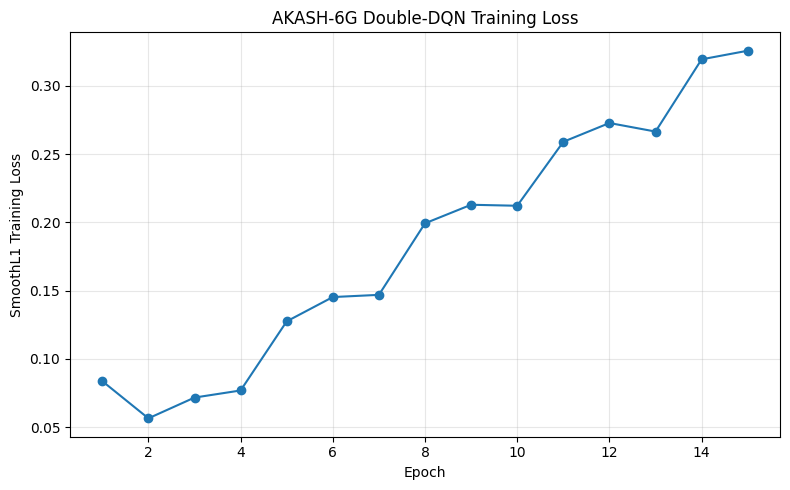

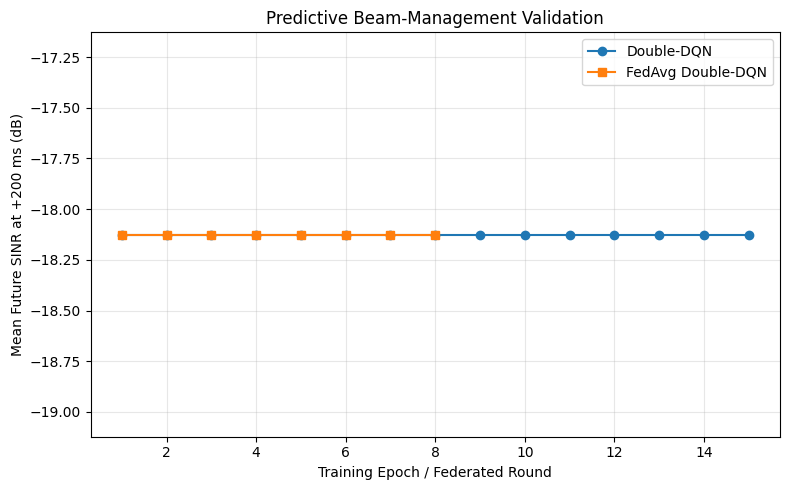

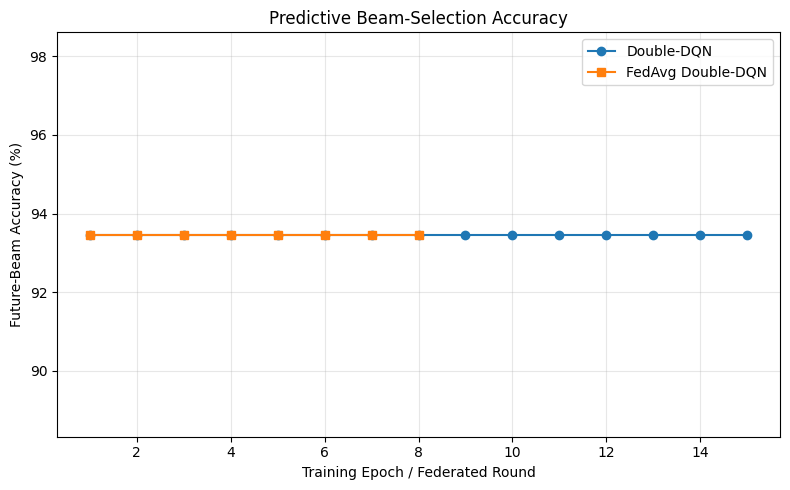

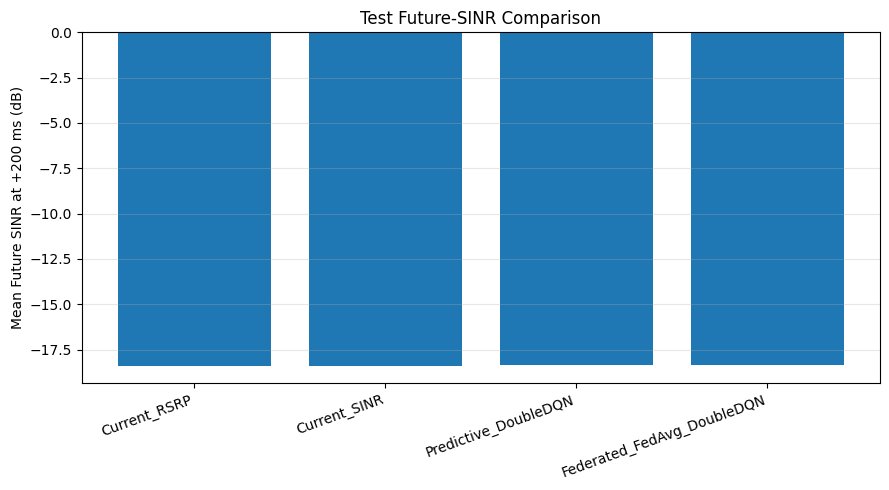

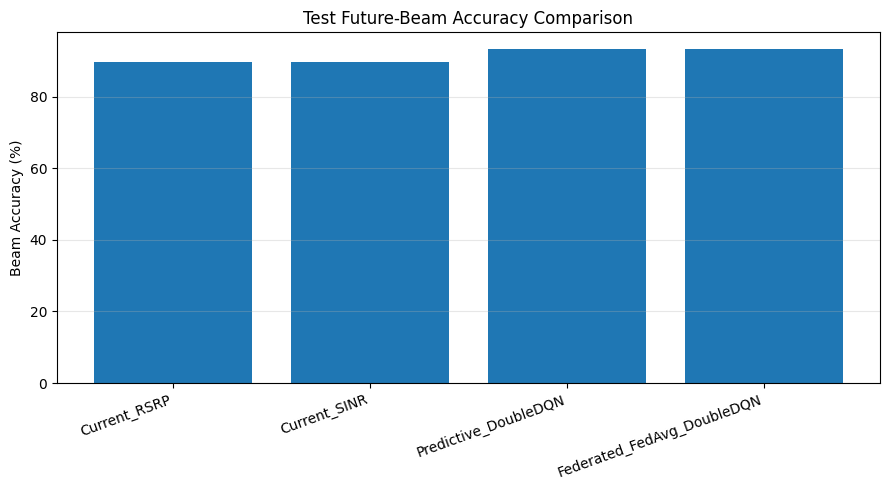


FINAL TEST RESULTS
                    Method  Future_SINR_dB  Beam_Accuracy_pct  Beam_Switch_Rate_pct  Mean_Reward
              Current_RSRP      -18.421789          89.595506              8.137828     3.398201
              Current_SINR      -18.423500          89.543071              8.202247     3.394977
      Predictive_DoubleDQN      -18.324329          93.285393              0.000000     3.805236
Federated_FedAvg_DoubleDQN      -18.324329          93.285393              0.000000     3.805236

ACTUAL BEAM DECISION EXAMPLES
These are model decisions; Future_Optimal_Beam is evaluation ground truth only.
 UE_ID  Time_ms Current_Beam Future_Optimal_Beam DoubleDQN_Beam FedAvg_DoubleDQN_Beam  DQN_Future_SINR_dB  FedAvg_Future_SINR_dB
     6      0.0        beam0               beam0          beam0                 beam0          -17.192884             -17.192884
     6     20.0        beam0               beam0          beam0                 beam0          -17.402893             -17.4028

In [ ]:

import os
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42

# Robust dataset resolution for both Google Colab and Kaggle.
DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()
DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]
SEARCH_ROOTS = [Path("/content"), Path("/kaggle/input"), Path("/kaggle/working"), Path("/mnt/data"), Path.cwd()]
DATASET_PATH = Path(DATASET_ENV) if DATASET_ENV else Path("/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv")
ALTERNATE_DATASET_PATH = Path("/content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv")
if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working/AKASH6G_AKASH6G_FINAL_RESULTS")
else:
    OUTPUT_DIR = Path("/content/AKASH6G_AKASH6G_FINAL_RESULTS")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Physical / temporal configuration
N_BEAMS = 4
DT_MS = 20
PREDICTION_HORIZON_MS = 200
H_STEPS = PREDICTION_HORIZON_MS // DT_MS

# Dataset structure
ROWS_PER_UE = 100
VALID_ROWS_PER_UE = ROWS_PER_UE - H_STEPS
TRANSITIONS_PER_UE = VALID_ROWS_PER_UE - 1

# Train / validation / test split is by UE, never by row.
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Double-DQN
GAMMA = 0.95
LEARNING_RATE = 1e-3
BATCH_SIZE = 512
EPOCHS = 15
REPLAY_CAPACITY = 350_000
MIN_REPLAY = 5_000
TARGET_UPDATE_STEPS = 1_000
GRAD_CLIP = 5.0

# Exploration is used during optimization only.
EPS_START = 1.0
EPS_END = 0.05

# Reward design
SINR_THRESHOLD_DB = 5.0
W_THROUGHPUT = 1.0
W_SWITCH = 0.5
W_FAILURE = 2.0
HANDOVER_COST = 10.0
FAILURE_COST = 50.0

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 8
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 1
FED_BATCH_SIZE = 512
FED_LR = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ================================================================
# 2. COLUMN DEFINITIONS
# ================================================================

CONTINUOUS_STATE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "beam0_RSRP_dBm",
    "beam1_RSRP_dBm",
    "beam2_RSRP_dBm",
    "beam3_RSRP_dBm",
    "beam0_SINR_dB",
    "beam1_SINR_dB",
    "beam2_SINR_dB",
    "beam3_SINR_dB",
]

SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]
RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]

REQUIRED_COLS = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    *CONTINUOUS_STATE_COLS,
    *SINR_COLS,
    *RSRP_COLS,
]


# ================================================================
# 3. UTILITY FUNCTIONS
# ================================================================

def log(msg=""):
    print(msg, flush=True)


def beam_to_int(x):
    """Convert beam0/beam1/... or numeric labels to integer 0..3."""
    if pd.isna(x):
        return -1

    if isinstance(x, str):
        s = x.strip().lower()
        if s.startswith("beam"):
            s = s.replace("beam", "", 1)
        try:
            return int(float(s))
        except ValueError:
            return -1

    try:
        return int(float(x))
    except (TypeError, ValueError):
        return -1


def beam_name(beam):
    """Return canonical beam label: beam0, beam1, beam2, or beam3."""
    try:
        b = int(beam)
    except (TypeError, ValueError):
        text = str(beam).strip().lower()
        if text.startswith("beam"):
            text = text[4:]
        try:
            b = int(float(text))
        except ValueError:
            return str(beam)
    if 0 <= b < N_BEAMS:
        return f"beam{b}"
    return "N/A"


def convert_beam_column(series):
    return series.map(beam_to_int).astype(np.int16)


def _is_candidate_csv(path):
    name = path.name.lower()
    return path.is_file() and path.suffix.lower() == ".csv" and (
        "5000ue" in name or "physical_dataset" in name or "akash6g" in name
    )


def _dataset_quality_score(path):
    name = path.name.lower()
    score = 0
    if "final_corrected" in name: score += 100
    if "5000ue" in name: score += 50
    if "physical_dataset" in name: score += 20
    try: score += min(int(path.stat().st_size / (1024 * 1024)), 100)
    except OSError: pass
    return score


def _try_colab_upload():
    try:
        from google.colab import files as colab_files
    except Exception:
        return None
    log("\nNo AKASH-6G CSV was found automatically.")
    log("Opening the Colab upload dialog. Select the corrected physical CSV.")
    uploaded = colab_files.upload()
    for filename in uploaded.keys():
        candidate = Path.cwd() / filename
        if candidate.is_file() and candidate.suffix.lower() == ".csv":
            return candidate
    return None


def resolve_dataset_path():
    """Resolve the physical CSV automatically; never require hard-coded /content paths."""
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if p.is_file():
            return p
        raise FileNotFoundError(f"AKASH6G_DATASET_PATH does not exist: {p}")

    for p in (DATASET_PATH, ALTERNATE_DATASET_PATH):
        if p.is_file():
            return p

    found = {}
    for root in SEARCH_ROOTS:
        if not root.exists() or not root.is_dir():
            continue
        try:
            for p in root.rglob("*.csv"):
                if _is_candidate_csv(p):
                    found[str(p.resolve())] = p
        except (OSError, PermissionError):
            continue

    if found:
        candidates = sorted(found.values(), key=_dataset_quality_score, reverse=True)
        chosen = candidates[0]
        log(f"Dataset auto-detected: {chosen}")
        return chosen

    uploaded = _try_colab_upload()
    if uploaded is not None:
        log(f"Dataset uploaded: {uploaded}")
        return uploaded

    searched = "\n  ".join(str(r) for r in SEARCH_ROOTS)
    expected = "\n  ".join(DATASET_FILENAMES)
    raise FileNotFoundError(
        "\nAKASH-6G physical dataset was not found.\n\n"
        f"Searched:\n  {searched}\n\n"
        f"Expected one of:\n  {expected}\n\n"
        "Or set AKASH6G_DATASET_PATH to the exact CSV path."
    )


def save_json(path, obj):
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        return str(v)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=convert)


# ================================================================
# 4. LOAD + NORMALIZE LABELS
# ================================================================

def load_dataset():
    path = resolve_dataset_path()
    log("=" * 72)
    log("AKASH-6G — PROFESSIONAL PREDICTIVE DOUBLE-DQN PIPELINE")
    log("=" * 72)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path)

    # Normalize beam columns immediately.
    for col in ["Current_Beam", "Optimal_Beam", "Future_Beam"]:
        df[col] = convert_beam_column(df[col])

    # Ensure flag is numeric.
    df["Valid_Future_Target"] = pd.to_numeric(
        df["Valid_Future_Target"], errors="coerce"
    ).fillna(0).astype(np.int8)

    # Numeric conversion for all physical columns.
    for col in CONTINUOUS_STATE_COLS + ["UE_ID", "Time_ms"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    log(f"Loaded shape: {df.shape}")
    return df, path


# ================================================================
# 5. PHYSICAL DATASET AUDIT
# ================================================================

def audit_dataset(df):
    log("\n[1/7] DATASET AUDIT")

    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    unique_ues = int(df["UE_ID"].nunique())

    log(f"Rows       : {len(df):,}")
    log(f"Columns    : {len(df.columns)}")
    log(f"Unique UEs : {unique_ues:,}")
    log(f"Missing    : {missing:,}")
    log(f"Duplicates : {duplicates:,}")

    if missing or duplicates:
        raise ValueError("Dataset audit failed: missing values or duplicate rows.")

    # Valid beam labels.
    for col in ["Current_Beam", "Optimal_Beam"]:
        if not df[col].between(0, N_BEAMS - 1).all():
            raise ValueError(f"Invalid values in {col}.")

    # Time spacing and per-UE ordering.
    bad_dt = 0
    bad_rows_per_ue = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            bad_rows_per_ue += 1
        dts = np.diff(g["Time_ms"].to_numpy(dtype=float))
        if len(dts) and np.max(np.abs(dts - DT_MS)) > 1e-9:
            bad_dt += 1

    log(f"UEs with wrong row count: {bad_rows_per_ue}")
    log(f"UEs with wrong time step : {bad_dt}")

    if bad_rows_per_ue or bad_dt:
        raise ValueError("Temporal dataset audit failed.")

    # Current beam linkage.
    current_rsrp = df[RSRP_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]
    current_sinr = df[SINR_COLS].to_numpy()[np.arange(len(df)), df["Current_Beam"]]

    rsrp_err = np.max(np.abs(current_rsrp - df["Current_RSRP_dBm"].to_numpy()))
    sinr_err = np.max(np.abs(current_sinr - df["Current_SINR_dB"].to_numpy()))

    # Optimal beam should be the physical strongest-beam decision.
    rsrp_argmax = df[RSRP_COLS].to_numpy().argmax(axis=1)
    sinr_argmax = df[SINR_COLS].to_numpy().argmax(axis=1)

    opt = df["Optimal_Beam"].to_numpy()

    opt_rsrp_acc = float(np.mean(rsrp_argmax == opt))
    opt_sinr_acc = float(np.mean(sinr_argmax == opt))

    log(f"Current-RSRP linkage max error: {rsrp_err:.6g} dB")
    log(f"Current-SINR linkage max error: {sinr_err:.6g} dB")
    log(f"Optimal vs RSRP argmax       : {100*opt_rsrp_acc:.3f}%")
    log(f"Optimal vs SINR argmax       : {100*opt_sinr_acc:.3f}%")

    # Future target verification.
    future_mismatch = 0
    flag_mismatch = 0
    valid_rows = 0

    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(VALID_ROWS_PER_UE):
            expected = int(g.loc[t + H_STEPS, "Optimal_Beam"])
            actual = int(g.loc[t, "Future_Beam"])
            if expected != actual:
                future_mismatch += 1

            if int(g.loc[t, "Valid_Future_Target"]) != 1:
                flag_mismatch += 1
            valid_rows += 1

        for t in range(VALID_ROWS_PER_UE, ROWS_PER_UE):
            if int(g.loc[t, "Valid_Future_Target"]) != 0:
                flag_mismatch += 1

    log(f"+200 ms future mismatches    : {future_mismatch}")
    log(f"Future validity mismatches   : {flag_mismatch}")
    log(f"Valid predictive rows        : {valid_rows:,}")

    if future_mismatch or flag_mismatch:
        raise ValueError("Future-target audit failed.")

    # Current beam should equal previous optimal beam after the first sample
    # in the supplied physical generator.
    current_prev_mismatch = 0
    for _, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        for t in range(1, len(g)):
            if int(g.loc[t, "Current_Beam"]) != int(g.loc[t - 1, "Optimal_Beam"]):
                current_prev_mismatch += 1

    log(f"Current-beam temporal linkage : {current_prev_mismatch}")

    # This is diagnostic, not a hard failure. If RSRP and SINR rank every beam
    # identically, the physics model gives the DQN little independent SINR
    # decision structure. We explicitly report it rather than hiding it.
    rank_agreement = float(np.mean(rsrp_argmax == sinr_argmax))
    log(f"RSRP-argmax == SINR-argmax    : {100*rank_agreement:.3f}%")

    if rank_agreement > 0.999:
        log("WARNING: RSRP and SINR produce essentially identical beam rankings.")
        log("This is a physical-model limitation, not a Python training error.")
        log("For the paper, improve the MATLAB interference model if independent")
        log("RSRP-vs-SINR beam decisions are required.")

    audit = {
        "rows": len(df),
        "columns": len(df.columns),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "rows_per_ue": ROWS_PER_UE,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "valid_predictive_rows": valid_rows,
        "current_rsrp_max_error_db": float(rsrp_err),
        "current_sinr_max_error_db": float(sinr_err),
        "optimal_vs_rsrp_argmax": opt_rsrp_acc,
        "optimal_vs_sinr_argmax": opt_sinr_acc,
        "rsrp_sinr_argmax_agreement": rank_agreement,
    }

    return audit


# ================================================================
# 6. STATE CONSTRUCTION
# ================================================================

def build_states(df, train_ues):
    log("\n[2/7] BUILDING 19-D STATES")

    # Sort once. All later transition logic is per UE.
    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    train_mask = df["UE_ID"].isin(train_ues)
    train_rows = df.loc[train_mask]

    X_train_raw = train_rows[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)

    mean = X_train_raw.mean(axis=0)
    std = X_train_raw.std(axis=0)
    std[std < 1e-8] = 1.0

    df_state = df[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)
    df_state = (df_state - mean) / std

    # One-hot current beam: 4 additional features.
    current = df["Current_Beam"].to_numpy(dtype=np.int64)
    onehot = np.zeros((len(df), N_BEAMS), dtype=np.float32)
    onehot[np.arange(len(df)), current] = 1.0

    state = np.concatenate([df_state, onehot], axis=1).astype(np.float32)

    assert state.shape[1] == 19

    df["_state_row"] = np.arange(len(df), dtype=np.int64)

    return df, state, mean, std


# ================================================================
# 7. UE SPLIT
# ================================================================

def split_ues(df):
    log("\n[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT")

    ues = np.sort(df["UE_ID"].unique())
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)

    n = len(ues)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)

    train_ues = np.sort(ues[:n_train])
    val_ues = np.sort(ues[n_train:n_train + n_val])
    test_ues = np.sort(ues[n_train + n_val:])

    log(f"Train UEs: {len(train_ues)}")
    log(f"Val UEs  : {len(val_ues)}")
    log(f"Test UEs : {len(test_ues)}")

    return train_ues, val_ues, test_ues


# ================================================================
# 8. COUNTERFACTUAL OFFLINE RL TRANSITIONS
# ================================================================

def reward_vector(future_sinr, previous_beam):
    """
    Compute reward for ALL 4 possible beam actions.

    Crucially:
      - Future_Beam is NOT used.
      - The action is not chosen from the future target.
      - The future SINR vector is used to score every possible action.
      - A constant failure penalty is centered out for optimization,
        because it is action-independent when all four future SINRs are
        below threshold.
    """
    sinr = np.asarray(future_sinr, dtype=np.float32)

    throughput = np.log2(1.0 + np.power(10.0, sinr / 10.0))

    switch_penalty = (np.arange(N_BEAMS) != int(previous_beam)).astype(np.float32)
    failure_penalty = (sinr < SINR_THRESHOLD_DB).astype(np.float32)

    raw = (
        W_THROUGHPUT * throughput
        - W_SWITCH * HANDOVER_COST * switch_penalty
        - W_FAILURE * FAILURE_COST * failure_penalty
    )

    # Per-state centering preserves action ordering but improves numerical
    # conditioning when the failure penalty is identical for every action.
    centered = raw - np.mean(raw)

    return raw.astype(np.float32), centered.astype(np.float32)


def build_transition_pool(df, state, ue_ids):
    """
    Build 4 counterfactual actions for every valid decision state.

    Number of states per UE = 89.
    Number of transitions per UE = 89 * 4 = 356.

    The reward for action a is computed using the actual physical beam-a
    SINR at t+200 ms.
    """
    log(f"Building transition pool for {len(ue_ids)} UEs...")

    ue_set = set(int(x) for x in ue_ids)

    states = []
    actions = []
    rewards = []
    raw_rewards = []
    next_states = []
    dones = []
    future_sinr_records = []
    current_beams = []
    future_optimal = []

    grouped = df[df["UE_ID"].isin(ue_set)].groupby(
        "UE_ID", sort=True, group_keys=False
    )

    for ue, g in grouped:
        g = g.sort_values("Time_ms").reset_index(drop=True)

        row_idx = g["_state_row"].to_numpy(dtype=np.int64)

        for t in range(TRANSITIONS_PER_UE):
            # State at t and next observed state at t+1.
            s = state[row_idx[t]]
            ns = state[row_idx[t + 1]]

            # True future physical SINR vector at t+200 ms.
            future_row = g.iloc[t + H_STEPS]
            future_sinr = future_row[SINR_COLS].to_numpy(dtype=np.float32)

            previous_beam = int(g.iloc[t]["Current_Beam"])

            raw_r, centered_r = reward_vector(future_sinr, previous_beam)

            done = 1.0 if t == TRANSITIONS_PER_UE - 1 else 0.0

            for a in range(N_BEAMS):
                states.append(s)
                actions.append(a)
                rewards.append(centered_r[a])
                raw_rewards.append(raw_r[a])
                next_states.append(ns)
                dones.append(done)
                future_sinr_records.append(future_sinr)
                current_beams.append(previous_beam)
                future_optimal.append(int(future_row["Optimal_Beam"]))

    X = np.asarray(states, dtype=np.float32)
    A = np.asarray(actions, dtype=np.int64)
    R = np.asarray(rewards, dtype=np.float32)
    RAW_R = np.asarray(raw_rewards, dtype=np.float32)
    NX = np.asarray(next_states, dtype=np.float32)
    D = np.asarray(dones, dtype=np.float32)
    FS = np.asarray(future_sinr_records, dtype=np.float32)
    CB = np.asarray(current_beams, dtype=np.int64)
    FO = np.asarray(future_optimal, dtype=np.int64)

    log(f"Transitions: {len(X):,}")
    log(
        f"Pool shapes: states={X.shape}, rewards={R.shape}, "
        f"raw_rewards={RAW_R.shape}, future_sinr={FS.shape}"
    )

    return {
        "states": X,
        "actions": A,
        "rewards": R,
        "raw_rewards": RAW_R,
        "next_states": NX,
        "dones": D,
        "future_sinr": FS,
        "current_beam": CB,
        "future_optimal": FO,
    }


# ================================================================
# 9. REPLAY BUFFER
# ================================================================

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.states = None
        self.actions = None
        self.rewards = None
        self.next_states = None
        self.dones = None
        self.size = 0

    def build(self, pool):
        n = min(len(pool["states"]), self.capacity)

        # Deterministic subset if pool exceeds capacity.
        if n < len(pool["states"]):
            rng = np.random.default_rng(SEED)
            idx = rng.choice(len(pool["states"]), size=n, replace=False)
        else:
            idx = np.arange(n)

        self.states = pool["states"][idx]
        self.actions = pool["actions"][idx]
        self.rewards = pool["rewards"][idx]
        self.next_states = pool["next_states"][idx]
        self.dones = pool["dones"][idx]
        self.size = n

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.from_numpy(self.states[idx]),
            torch.from_numpy(self.actions[idx]),
            torch.from_numpy(self.rewards[idx]),
            torch.from_numpy(self.next_states[idx]),
            torch.from_numpy(self.dones[idx]),
        )


# ================================================================
# 10. DOUBLE-DQN NETWORK
# ================================================================

class DoubleDQN(nn.Module):
    def __init__(self, state_dim=19, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def predict_actions(model, X):
    model.eval()
    out = []
    batch_size = 8192

    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i + batch_size]).to(DEVICE)
        q = model(xb)
        out.append(q.argmax(dim=1).cpu().numpy())

    return np.concatenate(out).astype(np.int64)


@torch.no_grad()
def predict_q_values(model, X):
    """Return Q-values for every state without changing model parameters.

    Parameters
    ----------
    model : torch.nn.Module
        Trained Double-DQN model.
    X : np.ndarray
        State matrix with shape (N, STATE_DIM).

    Returns
    -------
    np.ndarray
        Q-values with shape (N, N_BEAMS).
    """
    model.eval()
    X = np.asarray(X, dtype=np.float32)

    if X.ndim != 2:
        raise ValueError(
            f"predict_q_values expected a 2-D state matrix, got shape {X.shape}."
        )

    q_parts = []
    batch_size = 8192

    for start in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[start:start + batch_size]).to(DEVICE)
        q = model(xb).detach().cpu().numpy()
        q_parts.append(q)

    if not q_parts:
        return np.empty((0, N_BEAMS), dtype=np.float32)

    q_values = np.concatenate(q_parts, axis=0).astype(np.float32)

    if q_values.shape != (len(X), N_BEAMS):
        raise RuntimeError(
            f"Unexpected Q-value shape {q_values.shape}; "
            f"expected {(len(X), N_BEAMS)}."
        )

    return q_values


# ================================================================
# 11. DOUBLE-DQN TRAINING
# ================================================================

def epsilon_at_step(step, total_steps):
    if total_steps <= 1:
        return EPS_END
    # Exponential schedule that reaches EPS_END at final step.
    frac = step / float(total_steps - 1)
    return float(EPS_START * ((EPS_END / EPS_START) ** frac))


def train_double_dqn(train_pool, val_pool):
    log("\n[4/7] TRAINING DOUBLE-DQN")

    replay = ReplayBuffer(REPLAY_CAPACITY)
    replay.build(train_pool)

    if replay.size < MIN_REPLAY:
        raise ValueError("Replay buffer is too small for training.")

    model = DoubleDQN().to(DEVICE)
    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.SmoothL1Loss()

    batches_per_epoch = max(1, replay.size // BATCH_SIZE)
    total_steps = batches_per_epoch * EPOCHS

    history = []
    global_step = 0
    best_val_reward = -np.inf
    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(batches_per_epoch):
            states, actions, rewards, next_states, dones = replay.sample(BATCH_SIZE)

            states = states.to(DEVICE)
            actions = actions.to(DEVICE)
            rewards = rewards.to(DEVICE)
            next_states = next_states.to(DEVICE)
            dones = dones.to(DEVICE)

            # Double-DQN:
            # online network chooses next action
            # target network evaluates that chosen action
            q_values = model(states)
            q_selected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

            with torch.no_grad():
                next_actions = model(next_states).argmax(dim=1)
                next_q = target(next_states).gather(
                    1, next_actions.unsqueeze(1)
                ).squeeze(1)

                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q_selected, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            global_step += 1
            losses.append(float(loss.item()))

            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        # Validation on the full counterfactual validation pool.
        val_metrics = evaluate_policy(model, val_pool)

        mean_loss = float(np.mean(losses))
        eps = epsilon_at_step(
            min(global_step, total_steps - 1), total_steps
        )

        row = {
            "epoch": epoch,
            "loss": mean_loss,
            "val_reward": val_metrics["mean_reward"],
            "val_raw_reward": val_metrics["mean_raw_reward"],
            "val_future_sinr_db": val_metrics["future_sinr_db"],
            "val_accuracy_pct": val_metrics["accuracy_pct"],
            "val_switch_rate_pct": val_metrics["switch_rate_pct"],
            "epsilon": eps,
        }
        history.append(row)

        log(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {mean_loss:.5f} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Eps {eps:.4f}"
        )

        if val_metrics["mean_reward"] > best_val_reward:
            best_val_reward = val_metrics["mean_reward"]
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    log(f"Training time: {elapsed/60:.2f} min")

    return model, pd.DataFrame(history)


# ================================================================
# 12. POLICY EVALUATION
# ================================================================

@torch.no_grad()
def evaluate_policy(model, pool):
    """Evaluate one learned beam decision per unique physical state.

    Pool layout is:
        states      = (N*4, 19)
        rewards     = (N*4,)
        raw_rewards = (N*4,)
        future_sinr = (N*4, 4)

    Thus raw_rewards reshapes to (N,4), while future_sinr reshapes
    to (N,4,4) and then keeps the first copy of each state.
    """
    model.eval()

    total = len(pool["states"])
    if total == 0:
        raise ValueError("Cannot evaluate an empty pool.")
    if total % N_BEAMS != 0:
        raise ValueError(f"Pool size {total} is not divisible by {N_BEAMS}.")

    n_states = total // N_BEAMS

    if pool["raw_rewards"].shape != (total,):
        raise ValueError(
            f"raw_rewards shape {pool['raw_rewards'].shape} is invalid; expected ({total},)."
        )
    if pool["future_sinr"].shape != (total, N_BEAMS):
        raise ValueError(
            f"future_sinr shape {pool['future_sinr'].shape} is invalid; "
            f"expected ({total}, {N_BEAMS})."
        )
    if len(pool["current_beam"]) != total or len(pool["future_optimal"]) != total:
        raise ValueError("Beam metadata length does not match the transition pool.")

    unique_states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS].astype(np.int64)
    optimal = pool["future_optimal"][::N_BEAMS].astype(np.int64)

    future_sinr = pool["future_sinr"].reshape(
        n_states, N_BEAMS, N_BEAMS
    )[:, 0, :]

    raw_rewards = pool["raw_rewards"].reshape(
        n_states, N_BEAMS
    )

    predicted = predict_actions(model, unique_states)

    chosen_sinr = future_sinr[np.arange(n_states), predicted]
    chosen_raw = raw_rewards[np.arange(n_states), predicted]

    centered = np.empty(n_states, dtype=np.float32)
    for i in range(n_states):
        _, c = reward_vector(future_sinr[i], int(current[i]))
        centered[i] = c[predicted[i]]

    accuracy = float(np.mean(predicted == optimal) * 100.0)
    switch_rate = float(np.mean(predicted != current) * 100.0)

    hard = current != optimal
    hard_accuracy = (
        float(np.mean(predicted[hard] == optimal[hard]) * 100.0)
        if np.any(hard) else float("nan")
    )

    return {
        "mean_reward": float(centered.mean()),
        "mean_raw_reward": float(chosen_raw.mean()),
        "future_sinr_db": float(chosen_sinr.mean()),
        "accuracy_pct": accuracy,
        "switch_rate_pct": switch_rate,
        "hard_accuracy_pct": hard_accuracy,
        "hard_cases": int(hard.sum()),
        "predicted_actions": predicted,
        "future_optimal": optimal,
        "current_beam": current,
        "future_sinr_matrix": future_sinr,
    }


# ================================================================
# 13. BASELINES
# ================================================================

def evaluate_baselines(pool):
    log("\n[5/7] BASELINES")

    future_sinr = pool["future_sinr"][::N_BEAMS]
    current_beam = pool["current_beam"][::N_BEAMS]
    future_optimal = pool["future_optimal"][::N_BEAMS]

    # Baseline A: choose strongest current RSRP/SINR.
    # Since current SINR is directly available in the state, the physical
    # beam-specific SINR columns are recovered from the first state block.
    X = pool["states"][::N_BEAMS]

    # Continuous state positions 11..14 are beam SINR after the 11 first
    # continuous features? The state has 15 continuous features followed by
    # 4 one-hot current-beam values.
    current_sinr_norm = X[:, 11:15]

    # Normalization changes values but not ordering.
    current_sinr_choice = current_sinr_norm.argmax(axis=1)

    # RSRP positions 7..10.
    current_rsrp_norm = X[:, 7:11]
    current_rsrp_choice = current_rsrp_norm.argmax(axis=1)

    results = {}

    for name, choice in [
        ("Current_RSRP", current_rsrp_choice),
        ("Current_SINR", current_sinr_choice),
    ]:
        chosen = future_sinr[np.arange(len(future_sinr)), choice]
        acc = np.mean(choice == future_optimal) * 100.0
        switch = np.mean(choice != current_beam) * 100.0

        raw = []
        centered = []
        for i in range(len(choice)):
            r, c = reward_vector(future_sinr[i], current_beam[i])
            raw.append(r[choice[i]])
            centered.append(c[choice[i]])

        results[name] = {
            "future_sinr_db": float(np.mean(chosen)),
            "accuracy_pct": float(acc),
            "switch_rate_pct": float(switch),
            "mean_reward": float(np.mean(centered)),
            "mean_raw_reward": float(np.mean(raw)),
            "actions": choice,
        }

    return results


# ================================================================
# 14. HARD-CASE ANALYSIS
# ================================================================

def hard_case_accuracy(pred, optimal, current):
    mask = current != optimal
    if not np.any(mask):
        return float("nan"), 0
    return float(np.mean(pred[mask] == optimal[mask]) * 100.0), int(mask.sum())


# ================================================================
# 15. FEDERATED AVERAGING
# ================================================================

def average_state_dicts(state_dicts, weights):
    total = float(np.sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")

    global_state = {}
    for key in state_dicts[0].keys():
        value = None
        for sd, w in zip(state_dicts, weights):
            term = sd[key].float() * (float(w) / total)
            value = term if value is None else value + term
        global_state[key] = value

    return global_state


def local_train(client_model, pool, epochs=1, lr=1e-3, batch_size=512):
    client_model.train()
    optimizer = optim.Adam(client_model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss()

    n = len(pool["states"])
    rng = np.random.default_rng(SEED + n)

    for _ in range(epochs):
        idx = rng.permutation(n)

        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            if len(b) < 2:
                continue

            states = torch.from_numpy(pool["states"][b]).to(DEVICE)
            actions = torch.from_numpy(pool["actions"][b]).to(DEVICE)
            rewards = torch.from_numpy(pool["rewards"][b]).to(DEVICE)
            next_states = torch.from_numpy(pool["next_states"][b]).to(DEVICE)
            dones = torch.from_numpy(pool["dones"][b]).to(DEVICE)

            q = client_model(states).gather(
                1, actions.unsqueeze(1)
            ).squeeze(1)

            with torch.no_grad():
                next_a = client_model(next_states).argmax(dim=1)
                next_q = client_model(next_states).gather(
                    1, next_a.unsqueeze(1)
                ).squeeze(1)
                y = rewards + GAMMA * (1.0 - dones) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(client_model.parameters(), GRAD_CLIP)
            optimizer.step()

    return client_model


def federated_train(client_pools, val_pool, initial_model):
    """
    FedAvg:
      1. Copy global model to selected clients.
      2. Train locally.
      3. Weighted average model parameters.
      4. Broadcast new global model.
    """
    log("\n[6/7] FEDERATED LEARNING — FedAvg")

    global_model = DoubleDQN().to(DEVICE)
    global_model.load_state_dict(initial_model.state_dict())

    rng = np.random.default_rng(SEED)
    history = []

    n_clients = len(client_pools)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= n_clients:
            selected = np.arange(n_clients)
        else:
            selected = rng.choice(
                n_clients, size=CLIENTS_PER_ROUND, replace=False
            )

        local_states = []
        weights = []

        for client_id in selected:
            local_model = DoubleDQN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())

            local_train(
                local_model,
                client_pools[int(client_id)],
                epochs=LOCAL_EPOCHS,
                lr=FED_LR,
                batch_size=FED_BATCH_SIZE,
            )

            local_states.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            weights.append(len(client_pools[int(client_id)]["states"]))

        new_state = average_state_dicts(local_states, weights)
        global_model.load_state_dict(new_state)

        metrics = evaluate_policy(global_model, val_pool)

        row = {
            "round": rnd,
            "val_reward": metrics["mean_reward"],
            "val_raw_reward": metrics["mean_raw_reward"],
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
        }
        history.append(row)

        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | "
            f"ValReward {row['val_reward']:.4f} | "
            f"ValFutureSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

    return global_model, pd.DataFrame(history)


# ================================================================
# 16. PREDICTION TABLE
# ================================================================

def make_prediction_table(pool, dqn_result, fed_result, test_ues):
    """Create an exact one-row-per-decision test table.

    IMPORTANT:
      - DoubleDQN_Beam is the deployable central-model decision.
      - FedAvg_DoubleDQN_Beam is the deployable federated-model decision.
      - Future_Optimal_Beam is ground truth for evaluation only.
      - Q-values are included so the user can see why a beam was selected.
    """
    future_sinr = dqn_result["future_sinr_matrix"]
    current = dqn_result["current_beam"].astype(int)
    optimal = dqn_result["future_optimal"].astype(int)
    dqn_actions = dqn_result["predicted_actions"].astype(int)

    if fed_result is not None:
        fed_actions = fed_result["predicted_actions"].astype(int)
    else:
        fed_actions = np.full_like(dqn_actions, -1)

    # Q-values for deployment transparency.
    # The pool's unique states are exactly every 4th row.
    states = pool["states"][::N_BEAMS]
    dqn_q = predict_q_values(dqn_result["model"], states) if "model" in dqn_result else None
    fed_q = None
    if fed_result is not None and "model" in fed_result:
        fed_q = predict_q_values(fed_result["model"], states)

    # If model Q-values were not attached, omit those columns rather than
    # fabricating them. main() attaches them before this function is called.
    rows = []
    for i in range(len(dqn_actions)):
        current_b = int(current[i])
        opt_b = int(optimal[i])
        dqn_b = int(dqn_actions[i])
        fed_b = int(fed_actions[i])

        row = {
            "Sample": i,
            "UE_ID": int(test_ues[i // TRANSITIONS_PER_UE]),
            "Time_ms": float(i % TRANSITIONS_PER_UE * DT_MS),
            "Current_Beam": beam_name(current_b),
            "Future_Optimal_Beam": beam_name(opt_b),
            "DoubleDQN_Beam": beam_name(dqn_b),
            "FedAvg_DoubleDQN_Beam": beam_name(fed_b) if fed_b >= 0 else "N/A",
            "DQN_Correct": int(dqn_b == opt_b),
            "FedAvg_Correct": int(fed_b == opt_b) if fed_b >= 0 else 0,
            "DQN_Switch": int(dqn_b != current_b),
            "FedAvg_Switch": int(fed_b != current_b) if fed_b >= 0 else 0,
            "DQN_Future_SINR_dB": float(future_sinr[i, dqn_b]),
            "FedAvg_Future_SINR_dB": float(future_sinr[i, fed_b]) if fed_b >= 0 else np.nan,
            "Hard_Case": int(current_b != opt_b),
            "DQN_Hard_Case_Correct": int(current_b != opt_b and dqn_b == opt_b),
            "FedAvg_Hard_Case_Correct": int(current_b != opt_b and fed_b == opt_b) if fed_b >= 0 else 0,
        }

        if dqn_q is not None:
            for a in range(N_BEAMS):
                row[f"DQN_Q_beam{a}"] = float(dqn_q[i, a])
        if fed_q is not None:
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(fed_q[i, a])

        rows.append(row)

    return pd.DataFrame(rows)


# ================================================================
# 17. PLOTS
# ================================================================

def save_plots(dqn_history, fed_history, comparison, output_dir):
    plt.figure(figsize=(8, 5))
    plt.plot(dqn_history["epoch"], dqn_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 Training Loss")
    plt.title("AKASH-6G Double-DQN Training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "01_training_loss.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_future_sinr_db"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_future_sinr_db"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "02_validation_future_sinr.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_accuracy_pct"],
        marker="o",
        label="Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_accuracy_pct"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Training Epoch / Federated Round")
    plt.ylabel("Future-Beam Accuracy (%)")
    plt.title("Predictive Beam-Selection Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "03_validation_accuracy.png", dpi=300)
    plt.show()

    methods = list(comparison["Method"])
    values = list(comparison["Future_SINR_dB"])

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "04_test_future_sinr_comparison.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 5))
    values = list(comparison["Beam_Accuracy_pct"])

    plt.bar(methods, values)
    plt.ylabel("Beam Accuracy (%)")
    plt.title("Test Future-Beam Accuracy Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "05_test_accuracy_comparison.png", dpi=300)
    plt.show()


# ================================================================
# 18. MAIN EXPERIMENT
# ================================================================

def main():
    total_start = time.time()

    df, dataset_path = load_dataset()

    audit = audit_dataset(df)

    # UE split must happen before normalization.
    train_ues, val_ues, test_ues = split_ues(df)

    df, state, mean, std = build_states(df, train_ues)

    # Save normalization.
    np.save(OUTPUT_DIR / "train_state_mean.npy", mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    # Build pools.
    log("\nBuilding TRAIN counterfactual pool...")
    train_pool = build_transition_pool(df, state, train_ues)

    log("\nBuilding VALIDATION counterfactual pool...")
    val_pool = build_transition_pool(df, state, val_ues)

    log("\nBuilding TEST counterfactual pool...")
    test_pool = build_transition_pool(df, state, test_ues)

    # Train central Double-DQN.
    dqn_model, dqn_history = train_double_dqn(
        train_pool, val_pool
    )

    torch.save(
        dqn_model.state_dict(),
        OUTPUT_DIR / "AKASH6G_DoubleDQN_best.pt",
    )
    dqn_history.to_csv(
        OUTPUT_DIR / "DoubleDQN_training_history.csv",
        index=False,
    )

    dqn_test = evaluate_policy(dqn_model, test_pool)
    baseline = evaluate_baselines(test_pool)

    # Federated clients: split the training UEs into client groups.
    fed_model = None
    fed_history = None
    fed_test = None

    if RUN_FEDERATED:
        log("\nPreparing federated clients...")

        # 10 clients by deterministic UE partitions.
        n_clients = max(CLIENTS_PER_ROUND, 10)
        client_ue_groups = np.array_split(train_ues, n_clients)

        client_pools = [
            build_transition_pool(df, state, group)
            for group in client_ue_groups
            if len(group) > 0
        ]

        fed_model, fed_history = federated_train(
            client_pools,
            val_pool,
            dqn_model,
        )

        torch.save(
            fed_model.state_dict(),
            OUTPUT_DIR / "AKASH6G_FedAvg_DoubleDQN.pt",
        )
        fed_history.to_csv(
            OUTPUT_DIR / "FedAvg_history.csv",
            index=False,
        )

        fed_test = evaluate_policy(fed_model, test_pool)

    # ------------------------------------------------------------
    # Final test table
    # ------------------------------------------------------------
    rows = []

    rows.append({
        "Method": "Current_RSRP",
        "Future_SINR_dB": baseline["Current_RSRP"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_RSRP"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_RSRP"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_RSRP"]["mean_reward"],
    })

    rows.append({
        "Method": "Current_SINR",
        "Future_SINR_dB": baseline["Current_SINR"]["future_sinr_db"],
        "Beam_Accuracy_pct": baseline["Current_SINR"]["accuracy_pct"],
        "Beam_Switch_Rate_pct": baseline["Current_SINR"]["switch_rate_pct"],
        "Mean_Reward": baseline["Current_SINR"]["mean_reward"],
    })

    rows.append({
        "Method": "Predictive_DoubleDQN",
        "Future_SINR_dB": dqn_test["future_sinr_db"],
        "Beam_Accuracy_pct": dqn_test["accuracy_pct"],
        "Beam_Switch_Rate_pct": dqn_test["switch_rate_pct"],
        "Mean_Reward": dqn_test["mean_reward"],
    })

    if fed_test is not None:
        rows.append({
            "Method": "Federated_FedAvg_DoubleDQN",
            "Future_SINR_dB": fed_test["future_sinr_db"],
            "Beam_Accuracy_pct": fed_test["accuracy_pct"],
            "Beam_Switch_Rate_pct": fed_test["switch_rate_pct"],
            "Mean_Reward": fed_test["mean_reward"],
        })

    comparison = pd.DataFrame(rows)

    comparison.to_csv(
        OUTPUT_DIR / "AKASH6G_FINAL_TEST_COMPARISON.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Hard-case analysis
    # ------------------------------------------------------------
    dqn_hard_acc, n_hard = hard_case_accuracy(
        dqn_test["predicted_actions"],
        dqn_test["future_optimal"],
        dqn_test["current_beam"],
    )

    if fed_test is not None:
        fed_hard_acc, _ = hard_case_accuracy(
            fed_test["predicted_actions"],
            fed_test["future_optimal"],
            fed_test["current_beam"],
        )
    else:
        fed_hard_acc = float("nan")

    hard_case = pd.DataFrame([{
        "Method": "Predictive_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": dqn_hard_acc,
    }, {
        "Method": "Federated_FedAvg_DoubleDQN",
        "Hard_Cases_Current_vs_Future": n_hard,
        "Hard_Case_Accuracy_pct": fed_hard_acc,
    }])

    hard_case.to_csv(
        OUTPUT_DIR / "AKASH6G_HARD_CASE_ANALYSIS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Prediction export
    # ------------------------------------------------------------
    dqn_test["model"] = dqn_model
    if fed_test is not None:
        fed_test["model"] = fed_model

    pred_table = make_prediction_table(
        test_pool,
        dqn_test,
        fed_test,
        test_ues,
    )
    pred_table.to_csv(
        OUTPUT_DIR / "AKASH6G_TEST_PREDICTIONS.csv",
        index=False,
    )

    # User-facing decision file: the selected beam is explicit.
    pred_table.to_csv(
        OUTPUT_DIR / "AKASH6G_ACTUAL_BEAM_DECISIONS.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Final audit / config
    # ------------------------------------------------------------
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_rows_per_ue": VALID_ROWS_PER_UE,
        "transitions_per_ue": TRANSITIONS_PER_UE,
        "state_dimension": 19,
        "train_ues": len(train_ues),
        "val_ues": len(val_ues),
        "test_ues": len(test_ues),
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "target_update_steps": TARGET_UPDATE_STEPS,
        "replay_capacity": REPLAY_CAPACITY,
        "reward": {
            "sinr_threshold_db": SINR_THRESHOLD_DB,
            "w_throughput": W_THROUGHPUT,
            "w_switch": W_SWITCH,
            "w_failure": W_FAILURE,
            "handover_cost": HANDOVER_COST,
            "failure_cost": FAILURE_COST,
        },
        "federated": {
            "enabled": RUN_FEDERATED,
            "rounds": FED_ROUNDS,
            "clients_per_round": CLIENTS_PER_ROUND,
            "local_epochs": LOCAL_EPOCHS,
        },
        "methodology": (
            "physics-backed counterfactual offline/dataset-driven "
            "Double-DQN with optional FedAvg"
        ),
    }

    save_json(OUTPUT_DIR / "AKASH6G_FINAL_CONFIG.json", config)
    save_json(OUTPUT_DIR / "AKASH6G_PHYSICAL_AUDIT.json", audit)

    with open(
        OUTPUT_DIR / "AKASH6G_FINAL_AUDIT.txt",
        "w",
        encoding="utf-8",
    ) as f:
        f.write("PROJECT AKASH-6G FINAL EXPERIMENT AUDIT\n")
        f.write("=" * 72 + "\n\n")
        f.write(f"Dataset: {dataset_path}\n")
        f.write(f"Rows: {len(df):,}\n")
        f.write(f"UEs: {df['UE_ID'].nunique():,}\n")
        f.write(f"State dimension: 19\n")
        f.write(f"Prediction horizon: {PREDICTION_HORIZON_MS} ms\n")
        f.write(f"Prediction steps: {H_STEPS}\n")
        f.write("\nIMPORTANT:\n")
        f.write(
            "This experiment is dataset-driven/counterfactual offline RL. "
            "The fixed dataset does not contain action-dependent next-state "
            "transitions.\n"
        )
        f.write(
            "Future_Beam is never used to choose the replay action. "
            "All four actions are evaluated using the future physical SINR "
            "vector, then Double-DQN learns from the resulting action pool.\n"
        )
        f.write(
            "\nDo not describe the generated CSV as measured satellite data. "
            "It is a physics-based simulation dataset.\n"
        )

    # ------------------------------------------------------------
    # Plots
    # ------------------------------------------------------------
    save_plots(
        dqn_history,
        fed_history,
        comparison,
        OUTPUT_DIR,
    )

    # ------------------------------------------------------------
    # Final console output
    # ------------------------------------------------------------
    log("\n" + "=" * 72)
    log("FINAL TEST RESULTS")
    log("=" * 72)
    print(comparison.to_string(index=False))

    log("\nACTUAL BEAM DECISION EXAMPLES")
    print("These are model decisions; Future_Optimal_Beam is evaluation ground truth only.")
    decision_cols = [
        "UE_ID", "Time_ms", "Current_Beam", "Future_Optimal_Beam",
        "DoubleDQN_Beam", "FedAvg_DoubleDQN_Beam",
        "DQN_Future_SINR_dB", "FedAvg_Future_SINR_dB"
    ]
    print(pred_table[decision_cols].head(30).to_string(index=False))

    log("\nHOW TO SELECT A BEAM FOR A NEW SAMPLE")
    print("1. Build the same 19-D normalized state from current measurements.")
    print("2. Compute Q = model(state).")
    print("3. Select beam = argmax(Q[0], Q[1], Q[2], Q[3]).")
    print("4. beam0/beam1/beam2/beam3 are the four available actions.")
    print("5. Never use Future_Beam or Future_Optimal_Beam at deployment.")

    log("\nHard-case analysis:")
    print(hard_case.to_string(index=False))

    log(f"\nAll outputs saved to: {OUTPUT_DIR}")
    log(f"Total runtime: {(time.time()-total_start)/60:.2f} min")
    log("READY: physics audit -> predictive Double-DQN -> optional FedAvg")


if __name__ == "__main__":
    main()


Dataset auto-detected: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G — PREDICTIVE DOUBLE-DQN + FEDAVG V3
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/7] DATASET AUDIT
Rows       : 500,000
Columns    : 25
Unique UEs : 5,000
Missing    : 0
Duplicates : 0
UEs with wrong row count: 0
Max time-step error     : 0.000000 ms
Current-RSRP linkage max error: 0 dB
Current-SINR linkage max error: 0 dB
Optimal vs RSRP argmax       : 100.000%
Optimal vs SINR argmax       : 100.000%
+200 ms future mismatches    : 0
Future validity mismatches   : 0
Valid predictive rows       : 450,000
RSRP-argmax == SINR-argmax  : 100.000%
This is a physics-model limitation. It is not patched in Python. Independent SINR beam decisions require a richer interference/beam model in the simulator.

[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT
Train UEs: 3500
Val UEs  : 750
Test UEs : 750

[2/7] BUILDING 19-D STATES

Buil

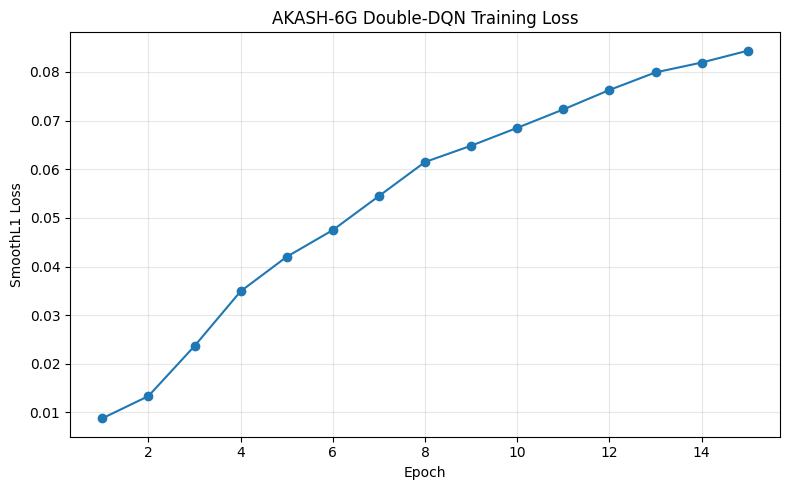

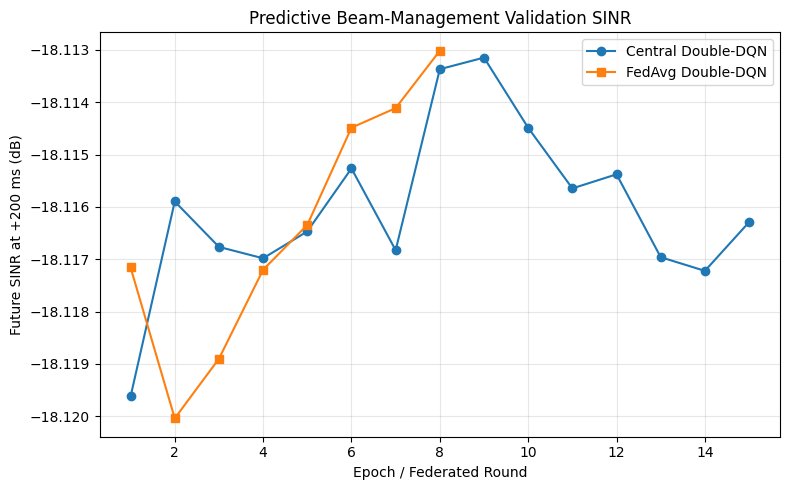

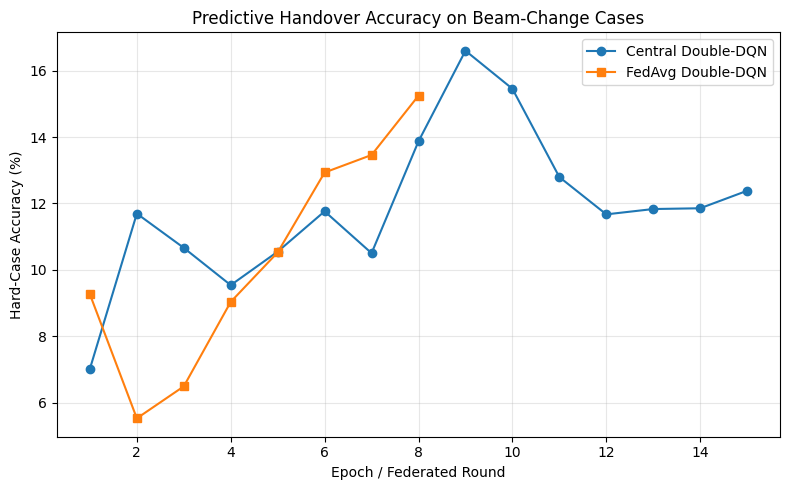

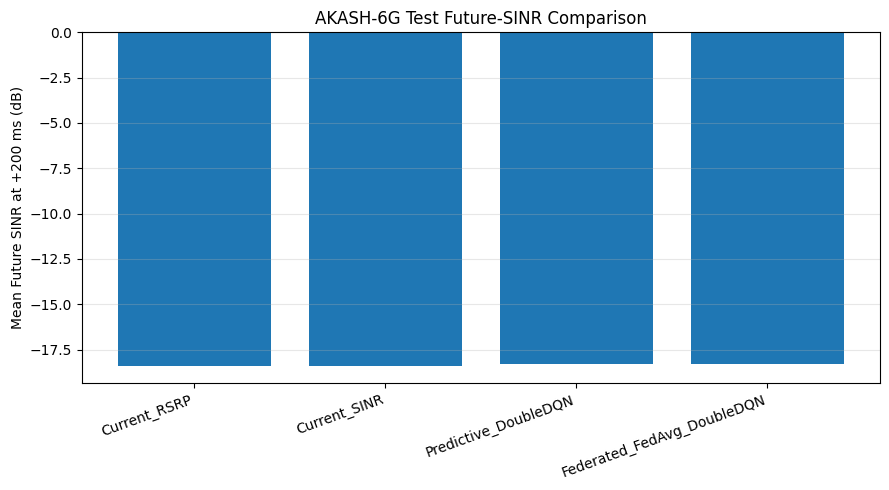

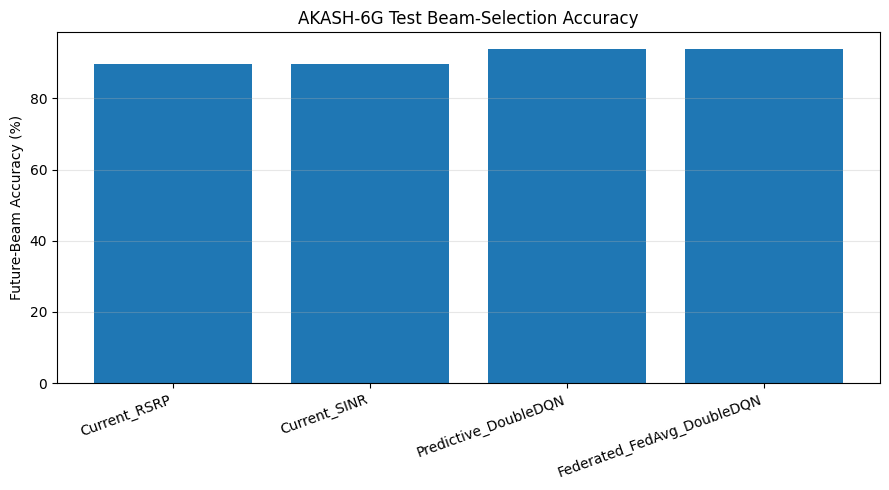

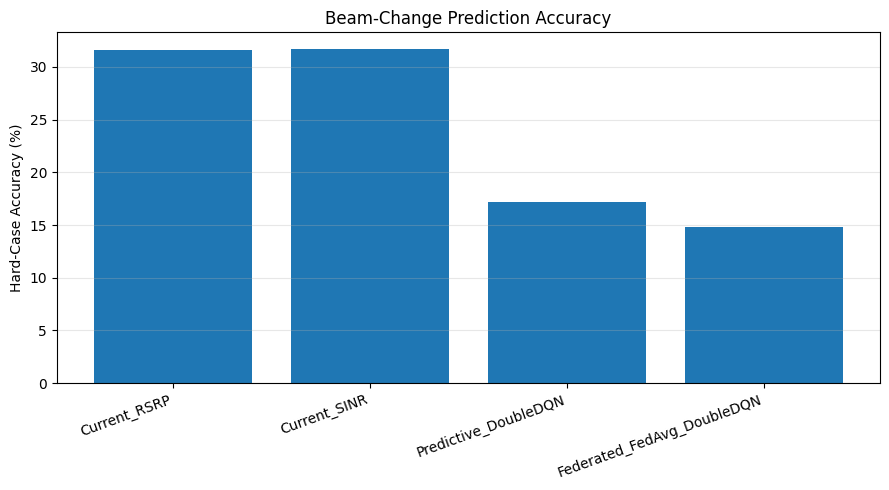

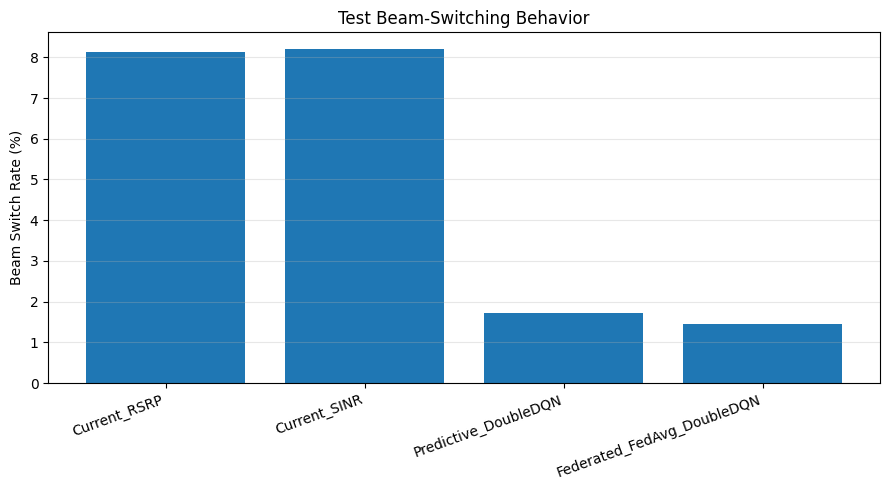

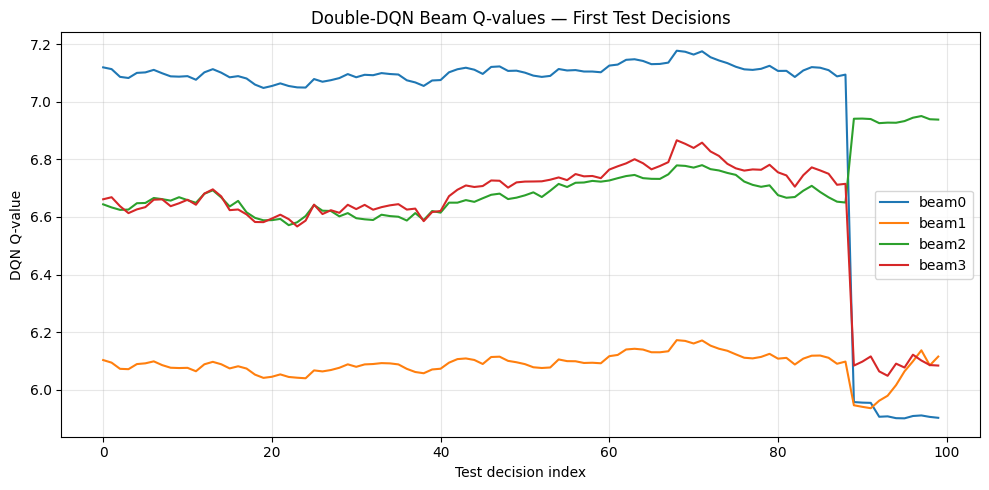


AKASH-6G V3 COMPLETE
All outputs saved to: /content/AKASH6G_AKASH6G_V3_FINAL_RESULTS
Total runtime: 12.99 min
READY: physics audit -> counterfactual reward -> Double-DQN -> unseen-UE evaluation -> FedAvg -> graphs


In [ ]:
import os
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42

DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()

DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]

SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path.cwd(),
]

OUTPUT_DIR = Path(
    os.environ.get(
        "AKASH6G_OUTPUT_DIR",
        "/content/AKASH6G_AKASH6G_V3_FINAL_RESULTS",
    )
)

N_BEAMS = 4
STATE_DIM = 19
DT_MS = 20
PREDICTION_HORIZON_MS = 200
H_STEPS = PREDICTION_HORIZON_MS // DT_MS

ROWS_PER_UE = 100
VALID_STATES_PER_UE = ROWS_PER_UE - H_STEPS
TRANSITIONS_PER_UE = VALID_STATES_PER_UE - 1

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# -------------------------------
# Double-DQN
# -------------------------------
HIDDEN = 128
GAMMA = 0.90
LEARNING_RATE = 1e-3
BATCH_SIZE = 512
REPLAY_CAPACITY = 500_000
MIN_REPLAY = 20_000
EPOCHS = 15
TARGET_UPDATE_STEPS = 750
GRAD_CLIP = 5.0

EPS_START = 1.0
EPS_END = 0.05

# -------------------------------
# Balanced predictive reward
# -------------------------------
# The old reward used a raw switching cost of 10 while the Shannon
# throughput term at negative SINR was near zero. That made "never
# switch" dominate. V3 uses a dimensionless utility:
#
#   normalized future-SINR utility in [0,1]
#   - small normalized switching penalty
#
# The raw proposal-style reward is NOT silently claimed here.
# This reward is explicitly the V3 decision-learning reward.
SWITCH_PENALTY = 0.05

# -------------------------------
# Federated learning
# -------------------------------
RUN_FEDERATED = True
FED_ROUNDS = 8
N_CLIENTS = 10
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 2
FED_BATCH_SIZE = 512
FED_LR = 1e-3
FED_TARGET_UPDATE_STEPS = 500

# For speed/memory, each client uses at most this many counterfactual
# transitions for local training. The validation/test sets are untouched.
CLIENT_MAX_TRANSITIONS = 80_000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ================================================================
# 2. COLUMN DEFINITIONS
# ================================================================

BEAM_RSRP_COLS = [
    "beam0_RSRP_dBm",
    "beam1_RSRP_dBm",
    "beam2_RSRP_dBm",
    "beam3_RSRP_dBm",
]

BEAM_SINR_COLS = [
    "beam0_SINR_dB",
    "beam1_SINR_dB",
    "beam2_SINR_dB",
    "beam3_SINR_dB",
]

CONTINUOUS_STATE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS

REQUIRED_COLUMNS = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
] + CONTINUOUS_STATE_COLS


# ================================================================
# 3. LOGGING / HELPERS
# ================================================================

def log(msg=""):
    print(msg, flush=True)


def beam_to_int(x):
    if pd.isna(x):
        raise ValueError("Beam label is NaN.")

    if isinstance(x, str):
        s = x.strip().lower()
        if s.startswith("beam"):
            s = s[4:]
        try:
            b = int(float(s))
        except Exception as exc:
            raise ValueError(f"Invalid beam label: {x!r}") from exc
    else:
        b = int(x)

    if b < 0 or b >= N_BEAMS:
        raise ValueError(f"Beam index must be 0..3, got {b}.")
    return b


def beam_name(beam):
    try:
        b = int(beam)
    except Exception:
        return str(beam)
    return f"beam{b}" if 0 <= b < N_BEAMS else "N/A"


def convert_beam_column(series, allow_minus_one=False):
    vals = []
    for x in series:
        if allow_minus_one and not pd.isna(x):
            try:
                if int(float(x)) == -1:
                    vals.append(-1)
                    continue
            except Exception:
                pass
        vals.append(beam_to_int(x))
    return np.asarray(vals, dtype=np.int64)


def save_json(path, obj):
    def conv(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        raise TypeError(type(v))
    path.write_text(json.dumps(obj, indent=2, default=conv))


# ================================================================
# 4. ROBUST DATASET RESOLUTION
# ================================================================

def is_candidate_csv(path):
    if not path.is_file() or path.suffix.lower() != ".csv":
        return False
    name = path.name.lower()
    if "akash6g" not in name:
        return False
    return (
        "physical" in name
        or "corrected" in name
        or "5000ue" in name
    )


def dataset_quality_score(path):
    name = path.name.lower()
    score = 0
    if "final_corrected" in name:
        score += 100
    if "5000ue" in name:
        score += 50
    if "physical" in name:
        score += 25
    if path.name.endswith("(2).csv"):
        score += 5
    try:
        score += min(int(path.stat().st_size / 1_000_000), 50)
    except Exception:
        pass
    return score


def try_colab_upload():
    try:
        from google.colab import files as colab_files

        log("No AKASH-6G CSV was found automatically.")
        log("Opening the Colab upload dialog. Select the corrected physical CSV.")
        uploaded = colab_files.upload()

        if not uploaded:
            return None

        for name in uploaded.keys():
            p = Path("/content") / name
            if p.exists() and p.suffix.lower() == ".csv":
                log(f"Dataset uploaded: {p}")
                return p

        return None
    except Exception:
        return None


def resolve_dataset_path():
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if p.exists() and p.is_file():
            log(f"Dataset path supplied by AKASH6G_DATASET_PATH: {p}")
            return p
        raise FileNotFoundError(
            f"AKASH6G_DATASET_PATH was supplied but does not exist:\n{p}"
        )

    candidates = []

    # Exact filename search first.
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for fname in DATASET_FILENAMES:
            direct = root / fname
            if direct.exists() and direct.is_file():
                candidates.append(direct)

    # Recursive search second.
    seen = set()
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            for p in root.rglob("*.csv"):
                try:
                    key = str(p.resolve())
                except Exception:
                    key = str(p)
                if key in seen:
                    continue
                seen.add(key)
                if is_candidate_csv(p):
                    candidates.append(p)
        except Exception:
            continue

    if candidates:
        unique = {}
        for p in candidates:
            try:
                unique[str(p.resolve())] = p
            except Exception:
                unique[str(p)] = p

        ranked = sorted(
            unique.values(),
            key=dataset_quality_score,
            reverse=True,
        )
        chosen = ranked[0]
        log(f"Dataset auto-detected: {chosen}")
        if len(ranked) > 1:
            log("Other detected candidates:")
            for p in ranked[1:6]:
                log(f"  - {p}")
        return chosen

    uploaded = try_colab_upload()
    if uploaded is not None:
        return uploaded

    raise FileNotFoundError(
        "\nAKASH-6G physical CSV was not found.\n"
        "Expected one of:\n  "
        + "\n  ".join(DATASET_FILENAMES)
        + "\n\nUpload the corrected physical CSV or set "
          "AKASH6G_DATASET_PATH."
    )


# ================================================================
# 5. DATASET LOAD
# ================================================================

def load_dataset():
    path = resolve_dataset_path()
    log("=" * 72)
    log("AKASH-6G — PREDICTIVE DOUBLE-DQN + FEDAVG V3")
    log("=" * 72)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path, low_memory=False)

    log(f"Loaded shape: {df.shape}")

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(
            "Dataset is missing required columns:\n"
            + "\n".join(f"  - {x}" for x in missing)
        )

    # Canonical numeric beam representation.
    df["Current_Beam"] = convert_beam_column(df["Current_Beam"])
    df["Optimal_Beam"] = convert_beam_column(df["Optimal_Beam"])
    df["Future_Beam"] = convert_beam_column(
        df["Future_Beam"],
        allow_minus_one=True,
    )
    df["Valid_Future_Target"] = pd.to_numeric(
        df["Valid_Future_Target"],
        errors="raise",
    ).astype(np.int8)

    return df, path


# ================================================================
# 6. PHYSICS / DATA AUDIT
# ================================================================

def audit_dataset(df):
    log("\n[1/7] DATASET AUDIT")

    n = len(df)
    ues = df["UE_ID"].astype(int)

    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    unique_ues = int(ues.nunique())

    counts = df.groupby("UE_ID").size()
    wrong_rows = int((counts != ROWS_PER_UE).sum())

    max_dt_error = 0.0
    future_mismatch = 0
    validity_mismatch = 0
    current_rsrp_error = 0.0
    current_sinr_error = 0.0
    optimal_rsrp_match = 0
    optimal_sinr_match = 0
    ranking_same = 0

    sorted_df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    for ue, g in sorted_df.groupby("UE_ID", sort=True):
        g = g.reset_index(drop=True)

        times = g["Time_ms"].to_numpy(dtype=float)
        if len(times) > 1:
            dt = np.diff(times)
            max_dt_error = max(
                max_dt_error,
                float(np.max(np.abs(dt - DT_MS))),
            )

        current = g["Current_Beam"].to_numpy(dtype=int)
        optimal = g["Optimal_Beam"].to_numpy(dtype=int)
        future = g["Future_Beam"].to_numpy(dtype=int)
        valid = g["Valid_Future_Target"].to_numpy(dtype=int)

        rs = g[BEAM_RSRP_COLS].to_numpy(dtype=float)
        si = g[BEAM_SINR_COLS].to_numpy(dtype=float)

        current_rsrp = g["Current_RSRP_dBm"].to_numpy(dtype=float)
        current_sinr = g["Current_SINR_dB"].to_numpy(dtype=float)

        current_rsrp_expected = rs[np.arange(len(g)), current]
        current_sinr_expected = si[np.arange(len(g)), current]

        if len(g):
            current_rsrp_error = max(
                current_rsrp_error,
                float(np.max(np.abs(current_rsrp - current_rsrp_expected))),
            )
            current_sinr_error = max(
                current_sinr_error,
                float(np.max(np.abs(current_sinr - current_sinr_expected))),
            )

        rs_arg = rs.argmax(axis=1)
        si_arg = si.argmax(axis=1)

        optimal_rsrp_match += int(np.sum(optimal == rs_arg))
        optimal_sinr_match += int(np.sum(optimal == si_arg))
        ranking_same += int(np.sum(rs_arg == si_arg))

        # +200 ms target audit.
        for i in range(VALID_STATES_PER_UE):
            expected = int(optimal[i + H_STEPS])
            if future[i] != expected:
                future_mismatch += 1
            if valid[i] != 1:
                validity_mismatch += 1

        for i in range(VALID_STATES_PER_UE, ROWS_PER_UE):
            if valid[i] != 0:
                validity_mismatch += 1
            if future[i] != -1:
                # The corrected dataset convention uses -1 for invalid target.
                validity_mismatch += 1

    valid_rows = int((df["Valid_Future_Target"] == 1).sum())

    total_beam_rows = n
    optimal_rsrp_pct = 100.0 * optimal_rsrp_match / total_beam_rows
    optimal_sinr_pct = 100.0 * optimal_sinr_match / total_beam_rows
    ranking_same_pct = 100.0 * ranking_same / total_beam_rows

    log(f"Rows       : {n:,}")
    log(f"Columns    : {df.shape[1]}")
    log(f"Unique UEs : {unique_ues:,}")
    log(f"Missing    : {missing}")
    log(f"Duplicates : {duplicates}")
    log(f"UEs with wrong row count: {wrong_rows}")
    log(f"Max time-step error     : {max_dt_error:.6f} ms")
    log(f"Current-RSRP linkage max error: {current_rsrp_error:.6g} dB")
    log(f"Current-SINR linkage max error: {current_sinr_error:.6g} dB")
    log(f"Optimal vs RSRP argmax       : {optimal_rsrp_pct:.3f}%")
    log(f"Optimal vs SINR argmax       : {optimal_sinr_pct:.3f}%")
    log(f"+200 ms future mismatches    : {future_mismatch}")
    log(f"Future validity mismatches   : {validity_mismatch}")
    log(f"Valid predictive rows       : {valid_rows:,}")
    log(f"RSRP-argmax == SINR-argmax  : {ranking_same_pct:.3f}%")

    if ranking_same_pct > 99.0:
        log(
            "WARNING: RSRP and SINR have essentially identical beam "
            "rankings in this physical dataset."
        )
        log(
            "This is a physics-model limitation. It is not patched in "
            "Python. Independent SINR beam decisions require a richer "
            "interference/beam model in the simulator."
        )

    if (
        n != 500_000
        or unique_ues != 5_000
        or missing != 0
        or duplicates != 0
        or wrong_rows != 0
        or max_dt_error > 1e-6
        or current_rsrp_error > 1e-3
        or current_sinr_error > 1e-3
        or future_mismatch != 0
        or validity_mismatch != 0
    ):
        raise ValueError(
            "Dataset audit FAILED. Do not continue to training."
        )

    audit = {
        "rows": n,
        "columns": int(df.shape[1]),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "wrong_ue_row_counts": wrong_rows,
        "max_time_step_error_ms": max_dt_error,
        "current_rsrp_linkage_max_error_db": current_rsrp_error,
        "current_sinr_linkage_max_error_db": current_sinr_error,
        "optimal_vs_rsrp_pct": optimal_rsrp_pct,
        "optimal_vs_sinr_pct": optimal_sinr_pct,
        "future_mismatches": future_mismatch,
        "future_validity_mismatches": validity_mismatch,
        "valid_predictive_rows": valid_rows,
        "rsrp_sinr_ranking_same_pct": ranking_same_pct,
    }

    return audit


# ================================================================
# 7. UE SPLIT
# ================================================================

def split_ues(df):
    log("\n[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT")

    ues = np.sort(df["UE_ID"].unique().astype(int))
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)

    n = len(ues)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))

    train_ues = np.sort(ues[:n_train])
    val_ues = np.sort(ues[n_train:n_train + n_val])
    test_ues = np.sort(ues[n_train + n_val:])

    if len(train_ues) + len(val_ues) + len(test_ues) != n:
        raise RuntimeError("UE split size error.")

    log(f"Train UEs: {len(train_ues)}")
    log(f"Val UEs  : {len(val_ues)}")
    log(f"Test UEs : {len(test_ues)}")

    return train_ues, val_ues, test_ues


# ================================================================
# 8. STATE BUILDING
# ================================================================

def build_states(df, train_ues):
    log("\n[2/7] BUILDING 19-D STATES")

    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    # Temporary row identifier after sorting.
    df["_state_row"] = np.arange(len(df), dtype=np.int64)

    X_raw = df[CONTINUOUS_STATE_COLS].to_numpy(dtype=np.float32)

    train_mask = df["UE_ID"].isin(set(int(x) for x in train_ues)).to_numpy()
    train_values = X_raw[train_mask]

    mean = train_values.mean(axis=0).astype(np.float32)
    std = train_values.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0

    X_norm = ((X_raw - mean) / std).astype(np.float32)

    current = df["Current_Beam"].to_numpy(dtype=int)
    onehot = np.zeros((len(df), N_BEAMS), dtype=np.float32)
    onehot[np.arange(len(df)), current] = 1.0

    state = np.concatenate([X_norm, onehot], axis=1)

    if state.shape[1] != STATE_DIM:
        raise RuntimeError(
            f"Expected state dimension {STATE_DIM}, got {state.shape[1]}"
        )

    return df, state, mean, std


# ================================================================
# 9. BALANCED PREDICTIVE REWARD
# ================================================================

def reward_vector(future_sinr, previous_beam):
    """
    Four counterfactual action rewards.

    The future SINR vector is known from the physics simulation.
    We normalize it per state so the reward measures which beam is
    better RELATIVE TO THE OTHER AVAILABLE BEAMS.

    reward(a) =
        normalized_future_sinr(a)
        - SWITCH_PENALTY * I[a != current]

    This avoids the old numerical failure where a switching cost of
    5 dominated a throughput term of ~0.03 at negative SINR.
    """
    sinr = np.asarray(future_sinr, dtype=np.float32)

    lo = float(np.min(sinr))
    hi = float(np.max(sinr))

    if hi - lo < 1e-6:
        utility = np.full(N_BEAMS, 0.5, dtype=np.float32)
    else:
        utility = ((sinr - lo) / (hi - lo)).astype(np.float32)

    switch = (
        np.arange(N_BEAMS, dtype=np.int64) != int(previous_beam)
    ).astype(np.float32)

    reward = utility - SWITCH_PENALTY * switch

    return reward.astype(np.float32), utility.astype(np.float32)


# ================================================================
# 10. COUNTERFACTUAL TRANSITION POOL
# ================================================================

def build_transition_pool(df, state, ue_ids, max_transitions=None):
    """
    For every valid decision state:
        state_t
        next_state_t+20ms
        future SINR at t+200ms
        four possible actions

    There are 89 decision states per UE and 4 actions per state.
    """
    ue_set = set(int(x) for x in ue_ids)

    states = []
    actions = []
    rewards = []
    utilities = []
    next_states = []
    dones = []
    future_sinr_records = []
    current_beams = []
    future_optimal = []
    ue_records = []
    time_records = []

    grouped = df[df["UE_ID"].isin(ue_set)].groupby(
        "UE_ID", sort=True, group_keys=False
    )

    for ue, g in grouped:
        g = g.sort_values("Time_ms").reset_index(drop=True)

        if len(g) != ROWS_PER_UE:
            raise RuntimeError(
                f"UE {ue} has {len(g)} rows; expected {ROWS_PER_UE}."
            )

        row_idx = g["_state_row"].to_numpy(dtype=np.int64)

        for t in range(TRANSITIONS_PER_UE):
            s = state[row_idx[t]]
            ns = state[row_idx[t + 1]]

            future_row = g.iloc[t + H_STEPS]
            future_sinr = future_row[BEAM_SINR_COLS].to_numpy(
                dtype=np.float32
            )

            previous_beam = int(g.iloc[t]["Current_Beam"])
            raw_r, utility = reward_vector(
                future_sinr,
                previous_beam,
            )

            done = 1.0 if t == TRANSITIONS_PER_UE - 1 else 0.0
            optimal = int(future_row["Optimal_Beam"])
            tm = float(g.iloc[t]["Time_ms"])

            for a in range(N_BEAMS):
                states.append(s)
                actions.append(a)
                rewards.append(raw_r[a])
                utilities.append(utility[a])
                next_states.append(ns)
                dones.append(done)
                future_sinr_records.append(future_sinr)
                current_beams.append(previous_beam)
                future_optimal.append(optimal)
                ue_records.append(int(ue))
                time_records.append(tm)

    X = np.asarray(states, dtype=np.float32)
    A = np.asarray(actions, dtype=np.int64)
    R = np.asarray(rewards, dtype=np.float32)
    U = np.asarray(utilities, dtype=np.float32)
    NX = np.asarray(next_states, dtype=np.float32)
    D = np.asarray(dones, dtype=np.float32)
    FS = np.asarray(future_sinr_records, dtype=np.float32)
    CB = np.asarray(current_beams, dtype=np.int64)
    FO = np.asarray(future_optimal, dtype=np.int64)
    UE = np.asarray(ue_records, dtype=np.int64)
    TM = np.asarray(time_records, dtype=np.float32)

    if max_transitions is not None and len(X) > max_transitions:
        # Deterministic but approximately balanced sample.
        rng = np.random.default_rng(SEED + len(ue_ids))
        idx = rng.choice(
            len(X),
            size=int(max_transitions),
            replace=False,
        )
        idx.sort()

        X = X[idx]
        A = A[idx]
        R = R[idx]
        U = U[idx]
        NX = NX[idx]
        D = D[idx]
        FS = FS[idx]
        CB = CB[idx]
        FO = FO[idx]
        UE = UE[idx]
        TM = TM[idx]

    log(f"Transitions: {len(X):,}")

    return {
        "states": X,
        "actions": A,
        "rewards": R,
        "utilities": U,
        "next_states": NX,
        "dones": D,
        "future_sinr": FS,
        "current_beam": CB,
        "future_optimal": FO,
        "UE_ID": UE,
        "Time_ms": TM,
    }


# ================================================================
# 11. REPLAY BUFFER
# ================================================================

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.states = None
        self.actions = None
        self.rewards = None
        self.next_states = None
        self.dones = None
        self.size = 0

    def build(self, pool):
        n = min(len(pool["states"]), self.capacity)

        if n < len(pool["states"]):
            rng = np.random.default_rng(SEED)
            idx = rng.choice(
                len(pool["states"]),
                size=n,
                replace=False,
            )
            idx.sort()
        else:
            idx = np.arange(n)

        self.states = pool["states"][idx]
        self.actions = pool["actions"][idx]
        self.rewards = pool["rewards"][idx]
        self.next_states = pool["next_states"][idx]
        self.dones = pool["dones"][idx]
        self.size = n

    def sample(self, batch_size):
        idx = np.random.randint(
            0,
            self.size,
            size=batch_size,
        )

        return (
            torch.from_numpy(self.states[idx]).to(DEVICE),
            torch.from_numpy(self.actions[idx]).to(DEVICE),
            torch.from_numpy(self.rewards[idx]).to(DEVICE),
            torch.from_numpy(self.next_states[idx]).to(DEVICE),
            torch.from_numpy(self.dones[idx]).to(DEVICE),
        )


# ================================================================
# 12. DOUBLE-DQN NETWORK
# ================================================================

class DoubleDQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(STATE_DIM, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, N_BEAMS),
        )

    def forward(self, x):
        return self.net(x)


def epsilon_at_step(step, total_steps):
    if total_steps <= 1:
        return EPS_END
    ratio = min(max(step / float(total_steps - 1), 0.0), 1.0)
    return EPS_END + (EPS_START - EPS_END) * math.exp(
        -5.0 * ratio
    )


def predict_q_values(model, X, batch_size=8192):
    model.eval()
    out = []

    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.from_numpy(
                X[start:start + batch_size]
            ).to(DEVICE)
            out.append(model(xb).cpu().numpy())

    return np.concatenate(out, axis=0).astype(np.float32)


def predict_actions(model, X):
    q = predict_q_values(model, X)
    return q.argmax(axis=1).astype(np.int64)


# ================================================================
# 13. POLICY EVALUATION
# ================================================================

def evaluate_policy(model, pool):
    model.eval()

    total = len(pool["states"])
    if total % N_BEAMS != 0:
        raise ValueError("Counterfactual pool is not divisible by 4.")

    n_states = total // N_BEAMS

    # All four actions for a state are consecutive.
    states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS].astype(np.int64)
    optimal = pool["future_optimal"][::N_BEAMS].astype(np.int64)

    future_sinr = pool["future_sinr"].reshape(
        n_states,
        N_BEAMS,
        N_BEAMS,
    )[:, 0, :]

    rewards = pool["rewards"].reshape(
        n_states,
        N_BEAMS,
    )

    utilities = pool["utilities"].reshape(
        n_states,
        N_BEAMS,
    )

    predicted = predict_actions(model, states)

    rows = np.arange(n_states)

    chosen_sinr = future_sinr[rows, predicted]
    chosen_reward = rewards[rows, predicted]
    chosen_utility = utilities[rows, predicted]

    accuracy = float(
        np.mean(predicted == optimal) * 100.0
    )

    switch_rate = float(
        np.mean(predicted != current) * 100.0
    )

    hard = current != optimal

    hard_accuracy = (
        float(np.mean(predicted[hard] == optimal[hard]) * 100.0)
        if np.any(hard)
        else float("nan")
    )

    # Among actual future changes:
    # correctly predicted handover and missed handover.
    correct_ho = int(
        np.sum((current != optimal) & (predicted == optimal))
    )
    missed_ho = int(
        np.sum((current != optimal) & (predicted == current))
    )
    wrong_ho = int(
        np.sum(
            (current == optimal)
            & (predicted != current)
        )
    )

    # Mean optimal future SINR is an upper bound obtainable from the
    # simulated four-beam physical candidate set.
    optimal_sinr = future_sinr.max(axis=1)

    return {
        "future_sinr_db": float(np.mean(chosen_sinr)),
        "optimal_future_sinr_db": float(np.mean(optimal_sinr)),
        "sinr_gap_db": float(
            np.mean(optimal_sinr) - np.mean(chosen_sinr)
        ),
        "mean_reward": float(np.mean(chosen_reward)),
        "mean_utility": float(np.mean(chosen_utility)),
        "accuracy_pct": accuracy,
        "switch_rate_pct": switch_rate,
        "hard_accuracy_pct": hard_accuracy,
        "hard_cases": int(np.sum(hard)),
        "correct_handover": correct_ho,
        "missed_handover": missed_ho,
        "unnecessary_handover": wrong_ho,
        "predicted_actions": predicted,
        "future_optimal": optimal,
        "current_beam": current,
        "future_sinr_matrix": future_sinr,
        "states": states,
    }


# ================================================================
# 14. CENTRAL DOUBLE-DQN TRAINING
# ================================================================

def train_double_dqn(train_pool, val_pool):
    log("\n[4/7] TRAINING CENTRAL DOUBLE-DQN")

    replay = ReplayBuffer(REPLAY_CAPACITY)
    replay.build(train_pool)

    if replay.size < MIN_REPLAY:
        raise ValueError(
            f"Replay buffer has {replay.size}; "
            f"minimum required is {MIN_REPLAY}."
        )

    model = DoubleDQN().to(DEVICE)
    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )
    loss_fn = nn.SmoothL1Loss()

    batches_per_epoch = max(
        1,
        replay.size // BATCH_SIZE,
    )
    total_steps = batches_per_epoch * EPOCHS

    history = []
    global_step = 0

    best_score = (-np.inf, -np.inf)
    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(batches_per_epoch):
            states, actions, rewards, next_states, dones = (
                replay.sample(BATCH_SIZE)
            )

            q = model(states).gather(
                1,
                actions.unsqueeze(1),
            ).squeeze(1)

            with torch.no_grad():
                # Double-DQN:
                # online network chooses the next action
                # target network evaluates that action
                next_actions = model(next_states).argmax(
                    dim=1
                )
                next_q = target(next_states).gather(
                    1,
                    next_actions.unsqueeze(1),
                ).squeeze(1)

                y = rewards + GAMMA * (
                    1.0 - dones
                ) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP,
            )
            optimizer.step()

            global_step += 1
            losses.append(float(loss.item()))

            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        metrics = evaluate_policy(model, val_pool)

        eps = epsilon_at_step(
            global_step,
            total_steps,
        )

        row = {
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_sinr_gap_db": metrics["sinr_gap_db"],
            "val_reward": metrics["mean_reward"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_hard_accuracy_pct": metrics["hard_accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
            "val_correct_handover": metrics["correct_handover"],
            "val_missed_handover": metrics["missed_handover"],
            "epsilon": eps,
        }
        history.append(row)

        log(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {row['loss']:.5f} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Gap {row['val_sinr_gap_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Eps {eps:.4f}"
        )

        # Select using future SINR first, then hard-case accuracy.
        score = (
            metrics["future_sinr_db"],
            metrics["hard_accuracy_pct"]
            if np.isfinite(metrics["hard_accuracy_pct"])
            else -np.inf,
        )

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is None:
        raise RuntimeError("No best DQN state was saved.")

    model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    log(f"Central training time: {elapsed / 60.0:.2f} min")

    return model, pd.DataFrame(history)


# ================================================================
# 15. BASELINES
# ================================================================

def evaluate_baselines(pool):
    log("\n[5/7] BASELINES")

    states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS]
    optimal = pool["future_optimal"][::N_BEAMS]
    future_sinr = pool["future_sinr"][::N_BEAMS]

    # Continuous state layout:
    # 0..6  : general/current features
    # 7..10 : beam RSRP
    # 11..14: beam SINR
    rsrp_choice = states[:, 7:11].argmax(axis=1)
    sinr_choice = states[:, 11:15].argmax(axis=1)

    results = {}

    for name, choice in [
        ("Current_RSRP", rsrp_choice),
        ("Current_SINR", sinr_choice),
    ]:
        rows = np.arange(len(choice))
        chosen = future_sinr[rows, choice]
        optimal_future = future_sinr.max(axis=1)

        hard = current != optimal

        correct_ho = int(
            np.sum((current != optimal) & (choice == optimal))
        )
        missed_ho = int(
            np.sum((current != optimal) & (choice == current))
        )
        unnecessary_ho = int(
            np.sum((current == optimal) & (choice != current))
        )

        rewards = []
        utilities = []

        for i in range(len(choice)):
            r, u = reward_vector(
                future_sinr[i],
                int(current[i]),
            )
            rewards.append(r[choice[i]])
            utilities.append(u[choice[i]])

        results[name] = {
            "future_sinr_db": float(np.mean(chosen)),
            "optimal_future_sinr_db": float(np.mean(optimal_future)),
            "sinr_gap_db": float(
                np.mean(optimal_future) - np.mean(chosen)
            ),
            "mean_reward": float(np.mean(rewards)),
            "mean_utility": float(np.mean(utilities)),
            "accuracy_pct": float(
                np.mean(choice == optimal) * 100.0
            ),
            "switch_rate_pct": float(
                np.mean(choice != current) * 100.0
            ),
            "hard_accuracy_pct": (
                float(np.mean(choice[hard] == optimal[hard]) * 100.0)
                if np.any(hard)
                else float("nan")
            ),
            "hard_cases": int(np.sum(hard)),
            "correct_handover": correct_ho,
            "missed_handover": missed_ho,
            "unnecessary_handover": unnecessary_ho,
            "actions": choice,
        }

    return results


# ================================================================
# 16. FEDAVG
# ================================================================

def average_state_dicts(state_dicts, weights):
    if not state_dicts:
        raise ValueError("No client state dictionaries.")

    total = float(np.sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")

    global_state = {}

    for key in state_dicts[0]:
        value = None
        for sd, w in zip(state_dicts, weights):
            tensor = sd[key].float() * (
                float(w) / total
            )
            value = (
                tensor
                if value is None
                else value + tensor
            )
        global_state[key] = value

    return global_state


def local_train_double_dqn(
    model,
    pool,
    epochs=1,
    lr=1e-3,
    batch_size=512,
):
    replay = ReplayBuffer(
        min(CLIENT_MAX_TRANSITIONS, len(pool["states"]))
    )
    replay.build(pool)

    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
    )
    loss_fn = nn.SmoothL1Loss()

    steps = 0

    for _ in range(epochs):
        n_batches = max(
            1,
            replay.size // batch_size,
        )

        for _ in range(n_batches):
            states, actions, rewards, next_states, dones = (
                replay.sample(batch_size)
            )

            q = model(states).gather(
                1,
                actions.unsqueeze(1),
            ).squeeze(1)

            with torch.no_grad():
                next_actions = model(next_states).argmax(
                    dim=1
                )
                next_q = target(next_states).gather(
                    1,
                    next_actions.unsqueeze(1),
                ).squeeze(1)

                y = rewards + GAMMA * (
                    1.0 - dones
                ) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP,
            )
            optimizer.step()

            steps += 1

            if steps % FED_TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

    return model


def federated_train(client_pools, val_pool):
    """
    Independent FedAvg experiment.

    The global model starts from a fresh random initialization.
    It is NOT initialized from the central DQN. This makes the
    federated result an actual federated-training comparison.
    """
    log("\n[6/7] FEDERATED LEARNING — FedAvg")

    global_model = DoubleDQN().to(DEVICE)

    rng = np.random.default_rng(SEED + 1234)
    history = []

    n_clients = len(client_pools)

    best_score = (-np.inf, -np.inf)
    best_state = None

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= n_clients:
            selected = np.arange(n_clients)
        else:
            selected = rng.choice(
                n_clients,
                size=CLIENTS_PER_ROUND,
                replace=False,
            )

        local_states = []
        weights = []

        for client_id in selected:
            local_model = DoubleDQN().to(DEVICE)
            local_model.load_state_dict(
                global_model.state_dict()
            )

            local_train_double_dqn(
                local_model,
                client_pools[int(client_id)],
                epochs=LOCAL_EPOCHS,
                lr=FED_LR,
                batch_size=FED_BATCH_SIZE,
            )

            local_states.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            weights.append(
                min(
                    len(client_pools[int(client_id)]["states"]),
                    CLIENT_MAX_TRANSITIONS,
                )
            )

            del local_model

        new_state = average_state_dicts(
            local_states,
            weights,
        )
        global_model.load_state_dict(new_state)

        metrics = evaluate_policy(
            global_model,
            val_pool,
        )

        row = {
            "round": rnd,
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_sinr_gap_db": metrics["sinr_gap_db"],
            "val_reward": metrics["mean_reward"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_hard_accuracy_pct": metrics["hard_accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
            "val_correct_handover": metrics["correct_handover"],
            "val_missed_handover": metrics["missed_handover"],
        }
        history.append(row)

        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Gap {row['val_sinr_gap_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        score = (
            metrics["future_sinr_db"],
            metrics["hard_accuracy_pct"]
            if np.isfinite(metrics["hard_accuracy_pct"])
            else -np.inf,
        )

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

    if best_state is not None:
        global_model.load_state_dict(best_state)

    return global_model, pd.DataFrame(history)


# ================================================================
# 17. DECISION TABLE
# ================================================================

def make_prediction_table(
    pool,
    dqn_model,
    dqn_result,
    fed_model,
    fed_result,
):
    states = pool["states"][::N_BEAMS]

    q_dqn = predict_q_values(dqn_model, states)
    dqn_actions = dqn_result["predicted_actions"]

    if fed_model is not None:
        q_fed = predict_q_values(fed_model, states)
        fed_actions = fed_result["predicted_actions"]
    else:
        q_fed = None
        fed_actions = np.full(
            len(dqn_actions),
            -1,
            dtype=np.int64,
        )

    current = dqn_result["current_beam"]
    optimal = dqn_result["future_optimal"]
    future_sinr = dqn_result["future_sinr_matrix"]

    ue = pool["UE_ID"][::N_BEAMS]
    tm = pool["Time_ms"][::N_BEAMS]

    rows = []

    for i in range(len(dqn_actions)):
        db = int(dqn_actions[i])
        fb = int(fed_actions[i])

        row = {
            "UE_ID": int(ue[i]),
            "Time_ms": float(tm[i]),
            "Current_Beam": beam_name(current[i]),
            "Future_Optimal_Beam": beam_name(optimal[i]),
            "DoubleDQN_Beam": beam_name(db),
            "FedAvg_DoubleDQN_Beam": (
                beam_name(fb) if fb >= 0 else "N/A"
            ),
            "DQN_Correct": int(db == optimal[i]),
            "FedAvg_Correct": (
                int(fb == optimal[i])
                if fb >= 0
                else 0
            ),
            "DQN_Switch": int(db != current[i]),
            "FedAvg_Switch": (
                int(fb != current[i])
                if fb >= 0
                else 0
            ),
            "DQN_Future_SINR_dB": float(
                future_sinr[i, db]
            ),
            "FedAvg_Future_SINR_dB": (
                float(future_sinr[i, fb])
                if fb >= 0
                else np.nan
            ),
            "Hard_Case": int(
                current[i] != optimal[i]
            ),
            "DQN_Hard_Case_Correct": int(
                current[i] != optimal[i]
                and db == optimal[i]
            ),
            "FedAvg_Hard_Case_Correct": (
                int(
                    current[i] != optimal[i]
                    and fb == optimal[i]
                )
                if fb >= 0
                else 0
            ),
        }

        for a in range(N_BEAMS):
            row[f"DQN_Q_beam{a}"] = float(
                q_dqn[i, a]
            )

        if q_fed is not None:
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(
                    q_fed[i, a]
                )

        for a in range(N_BEAMS):
            row[f"Future_SINR_beam{a}_dB"] = float(
                future_sinr[i, a]
            )

        rows.append(row)

    return pd.DataFrame(rows)


# ================================================================
# 18. SAVE PLOTS
# ================================================================

def save_plots(
    dqn_history,
    fed_history,
    comparison,
    prediction_table,
    output_dir,
):
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # 1. Training loss.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["loss"],
        marker="o",
    )
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 Loss")
    plt.title("AKASH-6G Double-DQN Training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "01_training_loss.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 2. Validation future SINR.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_future_sinr_db"],
        marker="o",
        label="Central Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_future_sinr_db"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation SINR")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "02_validation_future_sinr.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 3. Validation hard-case accuracy.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_hard_accuracy_pct"],
        marker="o",
        label="Central Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_hard_accuracy_pct"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Hard-Case Accuracy (%)")
    plt.title("Predictive Handover Accuracy on Beam-Change Cases")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "03_validation_hard_case_accuracy.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 4. Test future SINR.
    methods = comparison["Method"].tolist()
    values = comparison["Future_SINR_dB"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("AKASH-6G Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "04_test_future_sinr_comparison.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 5. Accuracy.
    values = comparison["Beam_Accuracy_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Future-Beam Accuracy (%)")
    plt.title("AKASH-6G Test Beam-Selection Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "05_test_accuracy_comparison.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 6. Hard-case accuracy.
    values = comparison["Hard_Case_Accuracy_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Hard-Case Accuracy (%)")
    plt.title("Beam-Change Prediction Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "06_test_hard_case_accuracy.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 7. Switch rate.
    values = comparison["Beam_Switch_Rate_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Beam Switch Rate (%)")
    plt.title("Test Beam-Switching Behavior")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "07_test_switch_rate.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 8. Example Q-values for first 100 test decisions.
    n = min(100, len(prediction_table))
    sample = prediction_table.iloc[:n]

    plt.figure(figsize=(10, 5))
    for a in range(N_BEAMS):
        plt.plot(
            np.arange(n),
            sample[f"DQN_Q_beam{a}"],
            label=f"beam{a}",
        )
    plt.xlabel("Test decision index")
    plt.ylabel("DQN Q-value")
    plt.title("Double-DQN Beam Q-values — First Test Decisions")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "08_dqn_q_values_examples.png",
        dpi=300,
    )
    plt.show()
    plt.close()


# ================================================================
# 19. FINAL DECISION REPORT
# ================================================================

def print_decision_examples(prediction_table, n=20):
    log("\n" + "=" * 72)
    log("ACTUAL AKASH-6G BEAM DECISION EXAMPLES")
    log("=" * 72)

    cols = [
        "UE_ID",
        "Time_ms",
        "Current_Beam",
        "Future_Optimal_Beam",
        "DoubleDQN_Beam",
        "FedAvg_DoubleDQN_Beam",
        "DQN_Future_SINR_dB",
        "FedAvg_Future_SINR_dB",
        "Hard_Case",
    ]

    print(
        prediction_table[cols].head(n).to_string(
            index=False
        )
    )

    # Prefer showing actual handover examples if they exist.
    hard = prediction_table[
        prediction_table["Hard_Case"] == 1
    ]

    if len(hard):
        log("\nFirst actual beam-change cases:")
        print(
            hard[cols].head(n).to_string(
                index=False
            )
        )


def print_q_explanation(prediction_table):
    if prediction_table.empty:
        return

    row = prediction_table.iloc[0]

    log("\n" + "=" * 72)
    log("HOW A NEW SAMPLE SELECTS A BEAM")
    log("=" * 72)
    log("The deployment decision uses ONLY the current 19-D state.")
    log("Future_Optimal_Beam is evaluation ground truth and is NOT")
    log("used at deployment.")
    log("")
    log(
        f"UE={int(row['UE_ID'])}, Time={row['Time_ms']:.0f} ms"
    )
    log(
        f"Current beam: {row['Current_Beam']}"
    )

    q = [
        row[f"DQN_Q_beam{a}"]
        for a in range(N_BEAMS)
    ]

    for a, value in enumerate(q):
        log(f"Q(beam{a}) = {value:.6f}")

    selected = int(
        np.argmax(np.asarray(q))
    )
    log(
        f"Selected beam = beam{selected} "
        f"(largest Q-value)"
    )


# ================================================================
# 20. MAIN
# ================================================================

def main():
    total_start = time.time()
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    df, dataset_path = load_dataset()

    audit = audit_dataset(df)
    save_json(
        OUTPUT_DIR / "dataset_audit.json",
        audit,
    )

    train_ues, val_ues, test_ues = split_ues(df)

    df, state, mean, std = build_states(
        df,
        train_ues,
    )

    np.save(
        OUTPUT_DIR / "train_state_mean.npy",
        mean,
    )
    np.save(
        OUTPUT_DIR / "train_state_std.npy",
        std,
    )
    np.save(
        OUTPUT_DIR / "train_ues.npy",
        train_ues,
    )
    np.save(
        OUTPUT_DIR / "val_ues.npy",
        val_ues,
    )
    np.save(
        OUTPUT_DIR / "test_ues.npy",
        test_ues,
    )

    # ------------------------------------------------------------
    # Build pools.
    # ------------------------------------------------------------
    log("\nBuilding TRAIN counterfactual pool...")
    train_pool = build_transition_pool(
        df,
        state,
        train_ues,
    )

    log("\nBuilding VALIDATION counterfactual pool...")
    val_pool = build_transition_pool(
        df,
        state,
        val_ues,
    )

    log("\nBuilding TEST counterfactual pool...")
    test_pool = build_transition_pool(
        df,
        state,
        test_ues,
    )

    # ------------------------------------------------------------
    # Central DQN.
    # ------------------------------------------------------------
    dqn_model, dqn_history = train_double_dqn(
        train_pool,
        val_pool,
    )

    torch.save(
        dqn_model.state_dict(),
        OUTPUT_DIR / "AKASH6G_DoubleDQN_best.pt",
    )

    dqn_history.to_csv(
        OUTPUT_DIR / "DoubleDQN_training_history.csv",
        index=False,
    )

    dqn_test = evaluate_policy(
        dqn_model,
        test_pool,
    )

    # ------------------------------------------------------------
    # Baselines.
    # ------------------------------------------------------------
    baseline = evaluate_baselines(test_pool)

    # ------------------------------------------------------------
    # Federated learning.
    # ------------------------------------------------------------
    fed_model = None
    fed_history = None
    fed_test = None

    if RUN_FEDERATED:
        log("\nPreparing federated clients...")

        client_groups = np.array_split(
            train_ues,
            N_CLIENTS,
        )

        client_pools = []

        for idx, group in enumerate(client_groups):
            log(
                f"Client {idx + 1:02d}/{N_CLIENTS}: "
                f"{len(group)} UEs"
            )

            client_pool = build_transition_pool(
                df,
                state,
                group,
                max_transitions=CLIENT_MAX_TRANSITIONS,
            )
            client_pools.append(client_pool)

        fed_model, fed_history = federated_train(
            client_pools,
            val_pool,
        )

        torch.save(
            fed_model.state_dict(),
            OUTPUT_DIR / "AKASH6G_FedAvg_DoubleDQN_best.pt",
        )

        fed_history.to_csv(
            OUTPUT_DIR / "FedAvg_history.csv",
            index=False,
        )

        fed_test = evaluate_policy(
            fed_model,
            test_pool,
        )

    # ------------------------------------------------------------
    # Comparison table.
    # ------------------------------------------------------------
    rows = []

    def result_row(name, result):
        return {
            "Method": name,
            "Future_SINR_dB": result["future_sinr_db"],
            "Optimal_Future_SINR_dB": result[
                "optimal_future_sinr_db"
            ],
            "SINR_Gap_dB": result["sinr_gap_db"],
            "Beam_Accuracy_pct": result[
                "accuracy_pct"
            ],
            "Hard_Case_Accuracy_pct": result[
                "hard_accuracy_pct"
            ],
            "Beam_Switch_Rate_pct": result[
                "switch_rate_pct"
            ],
            "Correct_Handover": result[
                "correct_handover"
            ],
            "Missed_Handover": result[
                "missed_handover"
            ],
            "Unnecessary_Handover": result[
                "unnecessary_handover"
            ],
            "Mean_Reward": result[
                "mean_reward"
            ],
        }

    for name in [
        "Current_RSRP",
        "Current_SINR",
    ]:
        b = baseline[name]
        rows.append({
            "Method": name,
            "Future_SINR_dB": b["future_sinr_db"],
            "Optimal_Future_SINR_dB": b[
                "optimal_future_sinr_db"
            ],
            "SINR_Gap_dB": b["sinr_gap_db"],
            "Beam_Accuracy_pct": b[
                "accuracy_pct"
            ],
            "Hard_Case_Accuracy_pct": b[
                "hard_accuracy_pct"
            ],
            "Beam_Switch_Rate_pct": b[
                "switch_rate_pct"
            ],
            "Correct_Handover": b[
                "correct_handover"
            ],
            "Missed_Handover": b[
                "missed_handover"
            ],
            "Unnecessary_Handover": b[
                "unnecessary_handover"
            ],
            "Mean_Reward": b[
                "mean_reward"
            ],
        })

    rows.append(
        result_row(
            "Predictive_DoubleDQN",
            dqn_test,
        )
    )

    if fed_test is not None:
        rows.append(
            result_row(
                "Federated_FedAvg_DoubleDQN",
                fed_test,
            )
        )

    comparison = pd.DataFrame(rows)

    comparison.to_csv(
        OUTPUT_DIR / "FINAL_TEST_COMPARISON.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Prediction table.
    # ------------------------------------------------------------
    prediction_table = make_prediction_table(
        test_pool,
        dqn_model,
        dqn_test,
        fed_model,
        fed_test,
    )

    prediction_table.to_csv(
        OUTPUT_DIR / "ACTUAL_BEAM_DECISIONS_TEST.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Print results.
    # ------------------------------------------------------------
    log("\n" + "=" * 72)
    log("FINAL TEST RESULTS")
    log("=" * 72)
    print(
        comparison.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}",
        )
    )

    print_decision_examples(
        prediction_table,
        n=20,
    )

    print_q_explanation(
        prediction_table
    )

    # ------------------------------------------------------------
    # Research warning if hard-case prediction is still poor.
    # ------------------------------------------------------------
    hard_acc = float(
        dqn_test["hard_accuracy_pct"]
    )

    if np.isfinite(hard_acc) and hard_acc < 50.0:
        log("\nRESEARCH WARNING:")
        log(
            f"Central DQN hard-case accuracy is only "
            f"{hard_acc:.2f}%."
        )
        log(
            "Do NOT describe the model as successfully predicting "
            "beam changes in the IEEE paper yet."
        )
        log(
            "Inspect the physical beam model and state predictability "
            "before making performance claims."
        )
    else:
        log(
            f"\nCentral DQN hard-case accuracy: "
            f"{hard_acc:.2f}%"
        )

    # ------------------------------------------------------------
    # Save config.
    # ------------------------------------------------------------
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "output_dir": str(OUTPUT_DIR),
        "n_beams": N_BEAMS,
        "state_dim": STATE_DIM,
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_states_per_ue": VALID_STATES_PER_UE,
        "transitions_per_ue": TRANSITIONS_PER_UE,
        "train_fraction": TRAIN_FRAC,
        "val_fraction": VAL_FRAC,
        "test_fraction": TEST_FRAC,
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "replay_capacity": REPLAY_CAPACITY,
        "epochs": EPOCHS,
        "target_update_steps": TARGET_UPDATE_STEPS,
        "switch_penalty": SWITCH_PENALTY,
        "fed_rounds": FED_ROUNDS,
        "n_clients": N_CLIENTS,
        "clients_per_round": CLIENTS_PER_ROUND,
        "local_epochs": LOCAL_EPOCHS,
        "fed_lr": FED_LR,
        "client_max_transitions": CLIENT_MAX_TRANSITIONS,
        "device": str(DEVICE),
        "methodology": (
            "physics-backed counterfactual dataset-driven "
            "offline Double-DQN with independent FedAvg"
        ),
        "deployment_rule": (
            "Build current 19-D state, normalize using train "
            "statistics, compute Q-values, select argmax Q."
        ),
        "future_label_used_at_deployment": False,
    }

    save_json(
        OUTPUT_DIR / "experiment_config.json",
        config,
    )

    # ------------------------------------------------------------
    # Audit / notes.
    # ------------------------------------------------------------
    audit_text = f"""
AKASH-6G V3 RESEARCH AUDIT
===========================

Dataset:
{dataset_path}

Rows: {len(df):,}
UEs: {df['UE_ID'].nunique():,}
Time step: {DT_MS} ms
Prediction horizon: {PREDICTION_HORIZON_MS} ms
Prediction steps: {H_STEPS}

Methodology:
Physics-backed counterfactual dataset-driven offline Double-DQN.

Leakage rule:
Future_Beam is NOT used to choose the training action.
Every state contains four possible actions.
Future SINR at t+200 ms scores each possible action.

Reward:
Per-state normalized future-SINR utility minus a small
switching penalty of {SWITCH_PENALTY}.

Important physical-model limitation:
The dataset audit reports whether RSRP and SINR choose the
same beam. If they are identical for nearly every row, this
is retained as a simulator limitation and is not hidden.

Deployment:
Only the current state is used.
Future_Optimal_Beam is evaluation ground truth only.

Test:
UE-level unseen test split.
"""

    (OUTPUT_DIR / "RESEARCH_AUDIT.txt").write_text(
        audit_text.strip() + "\n"
    )

    # ------------------------------------------------------------
    # Plots.
    # ------------------------------------------------------------
    save_plots(
        dqn_history,
        fed_history,
        comparison,
        prediction_table,
        OUTPUT_DIR,
    )

    elapsed = time.time() - total_start

    log("\n" + "=" * 72)
    log("AKASH-6G V3 COMPLETE")
    log("=" * 72)
    log(f"All outputs saved to: {OUTPUT_DIR}")
    log(f"Total runtime: {elapsed / 60.0:.2f} min")
    log(
        "READY: physics audit -> counterfactual reward -> "
        "Double-DQN -> unseen-UE evaluation -> FedAvg -> graphs"
    )

    # Final scientific sanity checks.
    if dqn_test["switch_rate_pct"] == 0.0:
        log(
            "WARNING: DQN selected the current beam for every test "
            "sample. Predictive switching is not demonstrated."
        )

    if dqn_test["hard_cases"] > 0 and (
        dqn_test["hard_accuracy_pct"] <= 0.0
    ):
        log(
            "WARNING: hard-case accuracy is 0%. "
            "Do not use predictive-handover success claims."
        )


if __name__ == "__main__":
    main()


Dataset auto-detected: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G — PREDICTIVE DUELING DOUBLE-DQN + FEDAVG V4
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/7] DATASET AUDIT
Rows       : 500,000
Columns    : 25
Unique UEs : 5,000
Missing    : 0
Duplicates : 0
UEs with wrong row count: 0
Max time-step error     : 0.000000 ms
Current-RSRP linkage max error: 0 dB
Current-SINR linkage max error: 0 dB
Optimal vs RSRP argmax       : 100.000%
Optimal vs SINR argmax       : 100.000%
+200 ms future mismatches    : 0
Future validity mismatches   : 0
Valid predictive rows       : 450,000
RSRP-argmax == SINR-argmax  : 100.000%
This is a physics-model limitation. It is not patched in Python. Independent SINR beam decisions require a richer interference/beam model in the simulator.

[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT
Train UEs: 3500
Val UEs  : 750
Test UEs : 750

[2/7] BUILDING TEMPORAL 

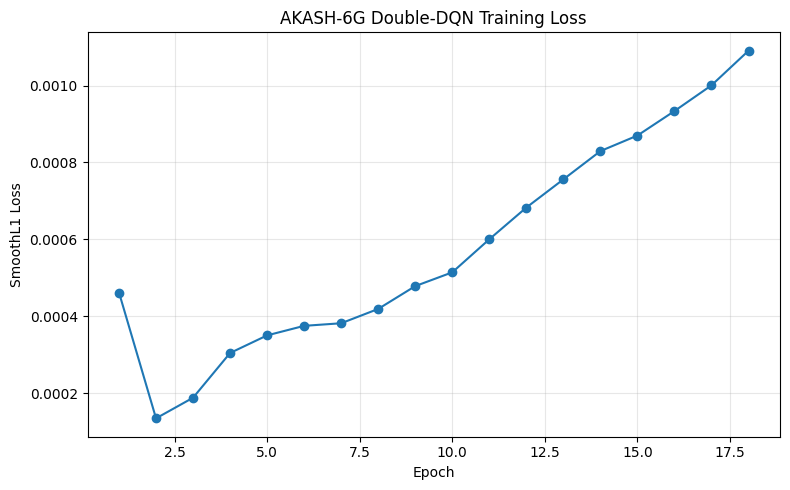

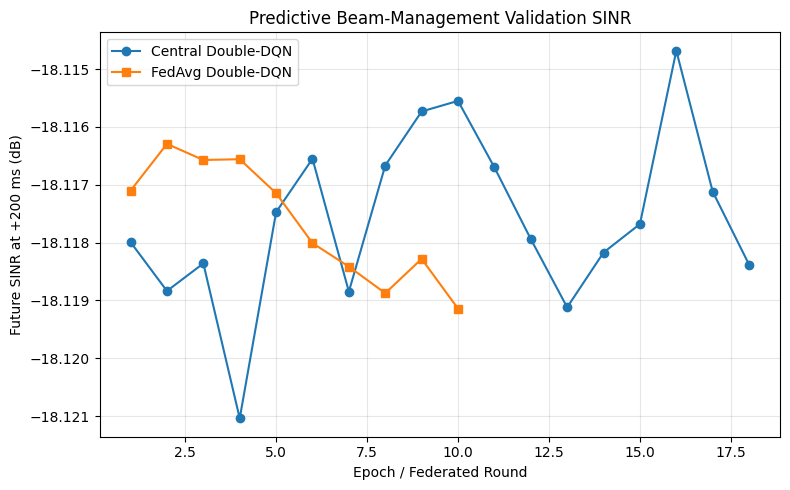

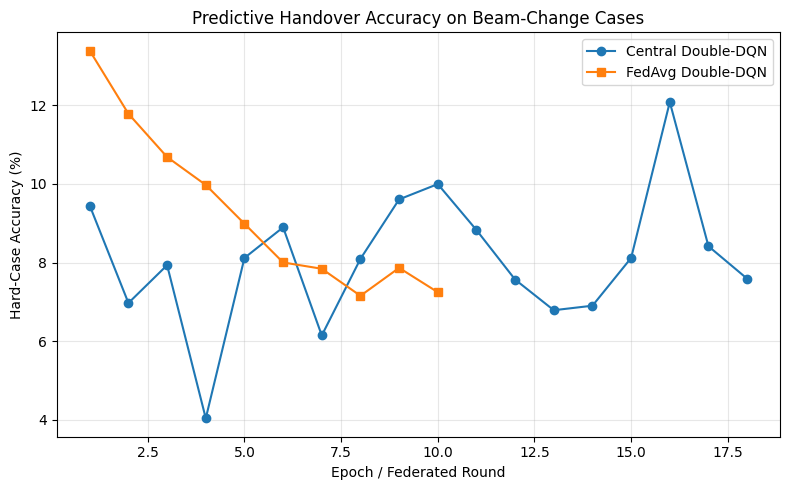

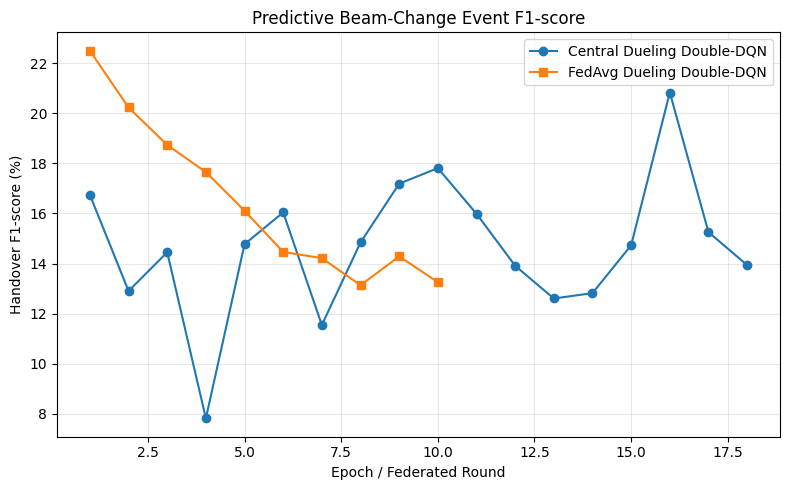

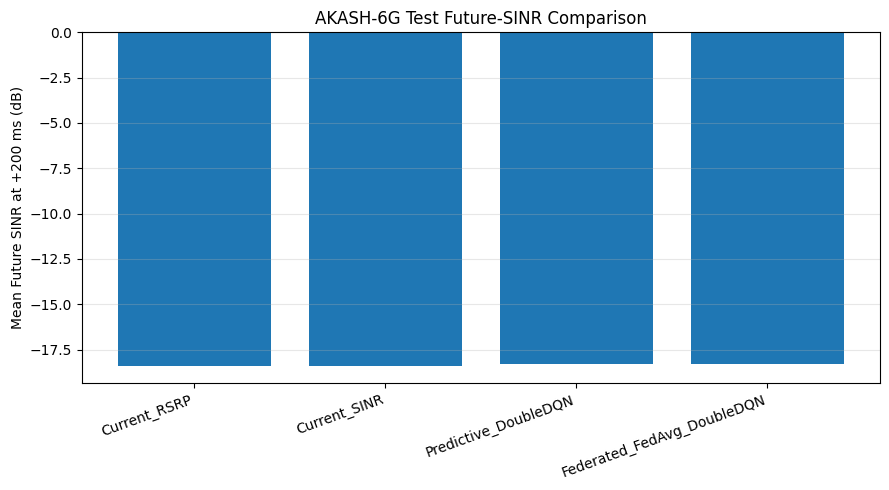

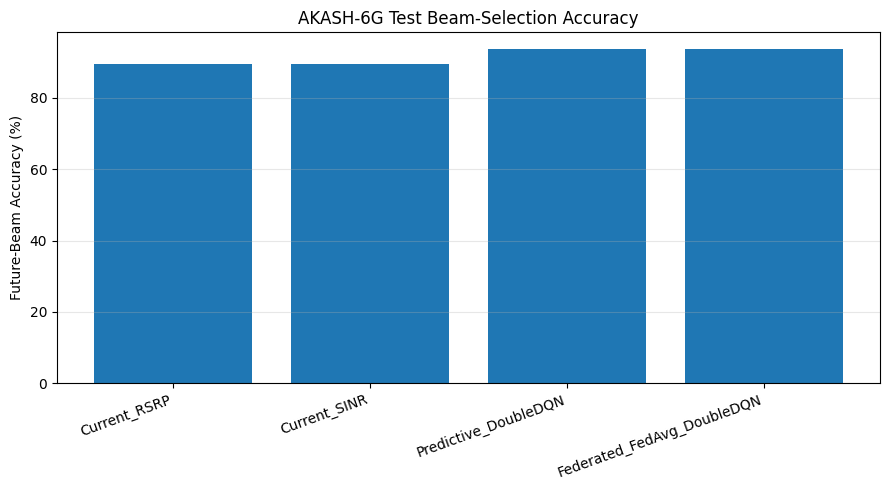

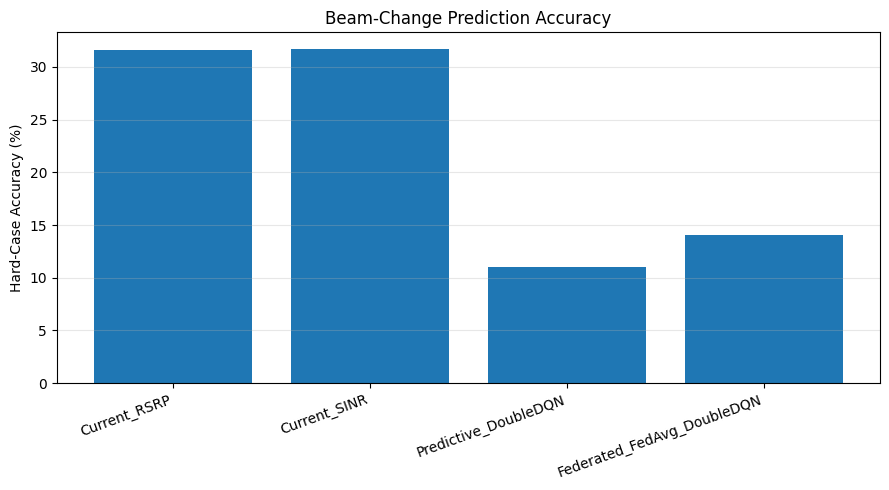

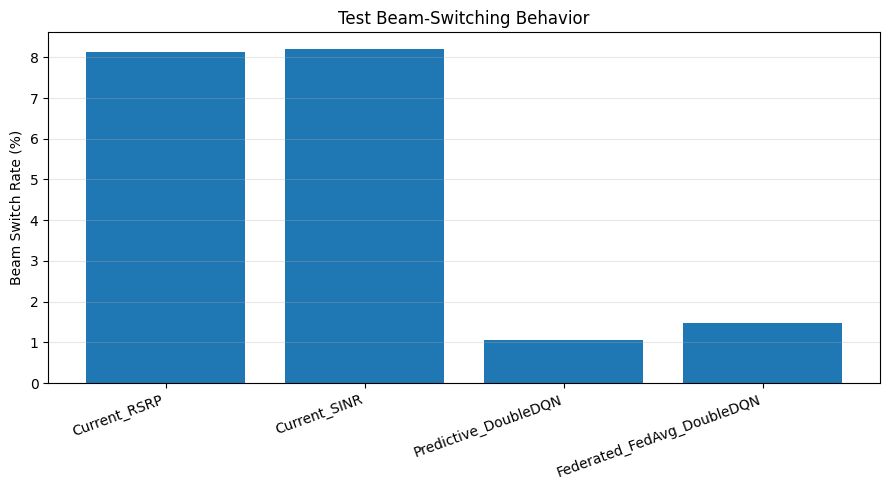

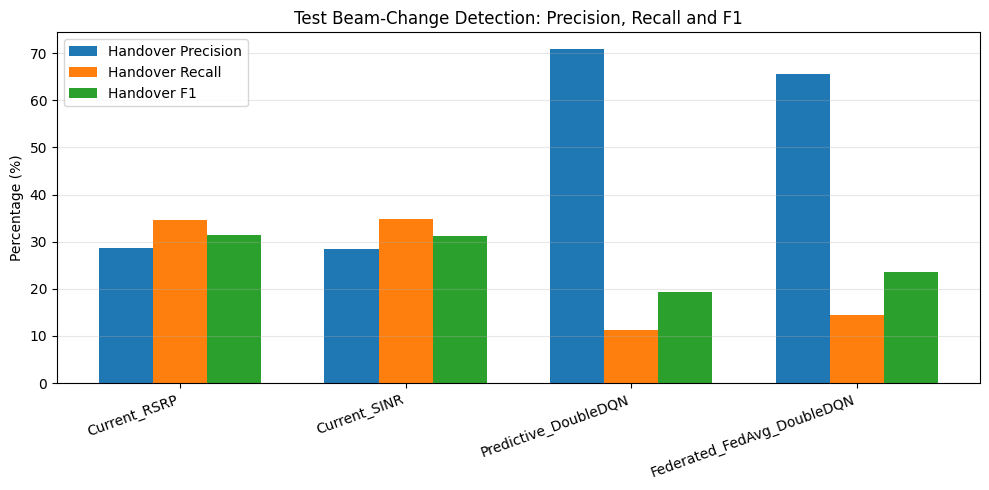

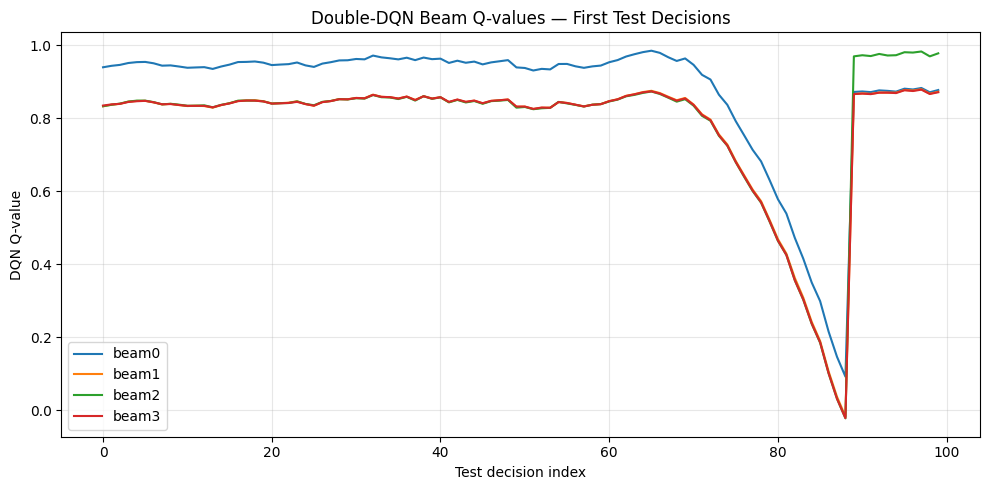


AKASH-6G V4 COMPLETE
All outputs saved to: /content/AKASH6G_AKASH6G_V4_FINAL_RESULTS
Total runtime: 18.28 min
READY: physics audit -> temporal state -> counterfactual reward -> Dueling Double-DQN -> unseen-UE evaluation -> independent FedAvg -> graphs


In [ ]:
import os
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42

DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()

DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]

SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path.cwd(),
]

OUTPUT_DIR = Path(
    os.environ.get(
        "AKASH6G_OUTPUT_DIR",
        "/content/AKASH6G_AKASH6G_V4_FINAL_RESULTS",
    )
)

N_BEAMS = 4
STATE_DIM = 55
DT_MS = 20
PREDICTION_HORIZON_MS = 200
H_STEPS = PREDICTION_HORIZON_MS // DT_MS

ROWS_PER_UE = 100
VALID_STATES_PER_UE = ROWS_PER_UE - H_STEPS
TRANSITIONS_PER_UE = VALID_STATES_PER_UE - 1

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# -------------------------------
# Double-DQN
# -------------------------------
HIDDEN = 128
GAMMA = 0.95
LEARNING_RATE = 3e-4
BATCH_SIZE = 512
REPLAY_CAPACITY = 500_000
MIN_REPLAY = 20_000
EPOCHS = 18
TARGET_UPDATE_STEPS = 750
GRAD_CLIP = 5.0



# -------------------------------
# Balanced predictive reward
# -------------------------------
# The old reward used a raw switching cost of 10 while the Shannon
# throughput term at negative SINR was near zero. That made "never
# switch" dominate. V3 uses a dimensionless utility:
#
#   normalized future-SINR utility in [0,1]
#   - small normalized switching penalty
#
# The raw proposal-style reward is NOT silently claimed here.
# This reward is explicitly the V3 decision-learning reward.
SWITCH_PENALTY = 0.02
SWITCH_BENEFIT = 0.08
GAIN_SCALE_DB = 3.0
SINR_UTILITY_SCALE_DB = 3.0
SINR_THRESHOLD_DB = 5.0

# -------------------------------
# Federated learning
# -------------------------------
RUN_FEDERATED = True
FED_ROUNDS = 10
N_CLIENTS = 10
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 2
FED_BATCH_SIZE = 512
FED_LR = 3e-4
FED_TARGET_UPDATE_STEPS = 500

# For speed/memory, each client uses at most this many counterfactual
# transitions for local training. The validation/test sets are untouched.
CLIENT_MAX_TRANSITIONS = 80_000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ================================================================
# 2. COLUMN DEFINITIONS
# ================================================================

BEAM_RSRP_COLS = [
    "beam0_RSRP_dBm",
    "beam1_RSRP_dBm",
    "beam2_RSRP_dBm",
    "beam3_RSRP_dBm",
]

BEAM_SINR_COLS = [
    "beam0_SINR_dB",
    "beam1_SINR_dB",
    "beam2_SINR_dB",
    "beam3_SINR_dB",
]

CONTINUOUS_STATE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS

# V4 predictive context: first-order motion/channel changes plus
# beam margins relative to the currently selected beam. These are
# computed only from information available at decision time t.
DELTA_STATE_COLS = [
    "dElevation_Angle_deg",
    "dSlant_Range_km",
    "dDoppler_kHz",
    "dDoppler_Rate_kHz_per_ms",
    "dPropagation_Delay_ms",
    "dCurrent_RSRP_dBm",
    "dCurrent_SINR_dB",
] + [f"d_{c}" for c in BEAM_RSRP_COLS] + [f"d_{c}" for c in BEAM_SINR_COLS]

BEAM_MARGIN_COLS = [f"margin_{c}" for c in BEAM_RSRP_COLS] + [f"margin_{c}" for c in BEAM_SINR_COLS]

BASE_FEATURE_COLS = CONTINUOUS_STATE_COLS
ALL_CONTINUOUS_STATE_COLS = BASE_FEATURE_COLS + DELTA_STATE_COLS + BEAM_MARGIN_COLS

REQUIRED_COLUMNS = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
] + CONTINUOUS_STATE_COLS


# ================================================================
# 3. LOGGING / HELPERS
# ================================================================

def log(msg=""):
    print(msg, flush=True)


def beam_to_int(x):
    if pd.isna(x):
        raise ValueError("Beam label is NaN.")

    if isinstance(x, str):
        s = x.strip().lower()
        if s.startswith("beam"):
            s = s[4:]
        try:
            b = int(float(s))
        except Exception as exc:
            raise ValueError(f"Invalid beam label: {x!r}") from exc
    else:
        b = int(x)

    if b < 0 or b >= N_BEAMS:
        raise ValueError(f"Beam index must be 0..3, got {b}.")
    return b


def beam_name(beam):
    try:
        b = int(beam)
    except Exception:
        return str(beam)
    return f"beam{b}" if 0 <= b < N_BEAMS else "N/A"


def convert_beam_column(series, allow_minus_one=False):
    vals = []
    for x in series:
        if allow_minus_one and not pd.isna(x):
            try:
                if int(float(x)) == -1:
                    vals.append(-1)
                    continue
            except Exception:
                pass
        vals.append(beam_to_int(x))
    return np.asarray(vals, dtype=np.int64)


def save_json(path, obj):
    def conv(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        raise TypeError(type(v))
    path.write_text(json.dumps(obj, indent=2, default=conv))


# ================================================================
# 4. ROBUST DATASET RESOLUTION
# ================================================================

def is_candidate_csv(path):
    if not path.is_file() or path.suffix.lower() != ".csv":
        return False
    name = path.name.lower()
    if "akash6g" not in name:
        return False
    return (
        "physical" in name
        or "corrected" in name
        or "5000ue" in name
    )


def dataset_quality_score(path):
    name = path.name.lower()
    score = 0
    if "final_corrected" in name:
        score += 100
    if "5000ue" in name:
        score += 50
    if "physical" in name:
        score += 25
    if path.name.endswith("(2).csv"):
        score += 5
    try:
        score += min(int(path.stat().st_size / 1_000_000), 50)
    except Exception:
        pass
    return score


def try_colab_upload():
    try:
        from google.colab import files as colab_files

        log("No AKASH-6G CSV was found automatically.")
        log("Opening the Colab upload dialog. Select the corrected physical CSV.")
        uploaded = colab_files.upload()

        if not uploaded:
            return None

        for name in uploaded.keys():
            p = Path("/content") / name
            if p.exists() and p.suffix.lower() == ".csv":
                log(f"Dataset uploaded: {p}")
                return p

        return None
    except Exception:
        return None


def resolve_dataset_path():
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if p.exists() and p.is_file():
            log(f"Dataset path supplied by AKASH6G_DATASET_PATH: {p}")
            return p
        raise FileNotFoundError(
            f"AKASH6G_DATASET_PATH was supplied but does not exist:\n{p}"
        )

    candidates = []

    # Exact filename search first.
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for fname in DATASET_FILENAMES:
            direct = root / fname
            if direct.exists() and direct.is_file():
                candidates.append(direct)

    # Recursive search second.
    seen = set()
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            for p in root.rglob("*.csv"):
                try:
                    key = str(p.resolve())
                except Exception:
                    key = str(p)
                if key in seen:
                    continue
                seen.add(key)
                if is_candidate_csv(p):
                    candidates.append(p)
        except Exception:
            continue

    if candidates:
        unique = {}
        for p in candidates:
            try:
                unique[str(p.resolve())] = p
            except Exception:
                unique[str(p)] = p

        ranked = sorted(
            unique.values(),
            key=dataset_quality_score,
            reverse=True,
        )
        chosen = ranked[0]
        log(f"Dataset auto-detected: {chosen}")
        if len(ranked) > 1:
            log("Other detected candidates:")
            for p in ranked[1:6]:
                log(f"  - {p}")
        return chosen

    uploaded = try_colab_upload()
    if uploaded is not None:
        return uploaded

    raise FileNotFoundError(
        "\nAKASH-6G physical CSV was not found.\n"
        "Expected one of:\n  "
        + "\n  ".join(DATASET_FILENAMES)
        + "\n\nUpload the corrected physical CSV or set "
          "AKASH6G_DATASET_PATH."
    )


# ================================================================
# 5. DATASET LOAD
# ================================================================

def load_dataset():
    path = resolve_dataset_path()
    log("=" * 72)
    log("AKASH-6G — PREDICTIVE DUELING DOUBLE-DQN + FEDAVG V4")
    log("=" * 72)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path, low_memory=False)

    log(f"Loaded shape: {df.shape}")

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(
            "Dataset is missing required columns:\n"
            + "\n".join(f"  - {x}" for x in missing)
        )

    # Canonical numeric beam representation.
    df["Current_Beam"] = convert_beam_column(df["Current_Beam"])
    df["Optimal_Beam"] = convert_beam_column(df["Optimal_Beam"])
    df["Future_Beam"] = convert_beam_column(
        df["Future_Beam"],
        allow_minus_one=True,
    )
    df["Valid_Future_Target"] = pd.to_numeric(
        df["Valid_Future_Target"],
        errors="raise",
    ).astype(np.int8)

    return df, path


# ================================================================
# 6. PHYSICS / DATA AUDIT
# ================================================================

def audit_dataset(df):
    log("\n[1/7] DATASET AUDIT")

    n = len(df)
    ues = df["UE_ID"].astype(int)

    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    unique_ues = int(ues.nunique())

    counts = df.groupby("UE_ID").size()
    wrong_rows = int((counts != ROWS_PER_UE).sum())

    max_dt_error = 0.0
    future_mismatch = 0
    validity_mismatch = 0
    current_rsrp_error = 0.0
    current_sinr_error = 0.0
    optimal_rsrp_match = 0
    optimal_sinr_match = 0
    ranking_same = 0

    sorted_df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    for ue, g in sorted_df.groupby("UE_ID", sort=True):
        g = g.reset_index(drop=True)

        times = g["Time_ms"].to_numpy(dtype=float)
        if len(times) > 1:
            dt = np.diff(times)
            max_dt_error = max(
                max_dt_error,
                float(np.max(np.abs(dt - DT_MS))),
            )

        current = g["Current_Beam"].to_numpy(dtype=int)
        optimal = g["Optimal_Beam"].to_numpy(dtype=int)
        future = g["Future_Beam"].to_numpy(dtype=int)
        valid = g["Valid_Future_Target"].to_numpy(dtype=int)

        rs = g[BEAM_RSRP_COLS].to_numpy(dtype=float)
        si = g[BEAM_SINR_COLS].to_numpy(dtype=float)

        current_rsrp = g["Current_RSRP_dBm"].to_numpy(dtype=float)
        current_sinr = g["Current_SINR_dB"].to_numpy(dtype=float)

        current_rsrp_expected = rs[np.arange(len(g)), current]
        current_sinr_expected = si[np.arange(len(g)), current]

        if len(g):
            current_rsrp_error = max(
                current_rsrp_error,
                float(np.max(np.abs(current_rsrp - current_rsrp_expected))),
            )
            current_sinr_error = max(
                current_sinr_error,
                float(np.max(np.abs(current_sinr - current_sinr_expected))),
            )

        rs_arg = rs.argmax(axis=1)
        si_arg = si.argmax(axis=1)

        optimal_rsrp_match += int(np.sum(optimal == rs_arg))
        optimal_sinr_match += int(np.sum(optimal == si_arg))
        ranking_same += int(np.sum(rs_arg == si_arg))

        # +200 ms target audit.
        for i in range(VALID_STATES_PER_UE):
            expected = int(optimal[i + H_STEPS])
            if future[i] != expected:
                future_mismatch += 1
            if valid[i] != 1:
                validity_mismatch += 1

        for i in range(VALID_STATES_PER_UE, ROWS_PER_UE):
            if valid[i] != 0:
                validity_mismatch += 1
            if future[i] != -1:
                # The corrected dataset convention uses -1 for invalid target.
                validity_mismatch += 1

    valid_rows = int((df["Valid_Future_Target"] == 1).sum())

    total_beam_rows = n
    optimal_rsrp_pct = 100.0 * optimal_rsrp_match / total_beam_rows
    optimal_sinr_pct = 100.0 * optimal_sinr_match / total_beam_rows
    ranking_same_pct = 100.0 * ranking_same / total_beam_rows

    log(f"Rows       : {n:,}")
    log(f"Columns    : {df.shape[1]}")
    log(f"Unique UEs : {unique_ues:,}")
    log(f"Missing    : {missing}")
    log(f"Duplicates : {duplicates}")
    log(f"UEs with wrong row count: {wrong_rows}")
    log(f"Max time-step error     : {max_dt_error:.6f} ms")
    log(f"Current-RSRP linkage max error: {current_rsrp_error:.6g} dB")
    log(f"Current-SINR linkage max error: {current_sinr_error:.6g} dB")
    log(f"Optimal vs RSRP argmax       : {optimal_rsrp_pct:.3f}%")
    log(f"Optimal vs SINR argmax       : {optimal_sinr_pct:.3f}%")
    log(f"+200 ms future mismatches    : {future_mismatch}")
    log(f"Future validity mismatches   : {validity_mismatch}")
    log(f"Valid predictive rows       : {valid_rows:,}")
    log(f"RSRP-argmax == SINR-argmax  : {ranking_same_pct:.3f}%")

    if ranking_same_pct > 99.0:
        log(
            "WARNING: RSRP and SINR have essentially identical beam "
            "rankings in this physical dataset."
        )
        log(
            "This is a physics-model limitation. It is not patched in "
            "Python. Independent SINR beam decisions require a richer "
            "interference/beam model in the simulator."
        )

    if (
        n != 500_000
        or unique_ues != 5_000
        or missing != 0
        or duplicates != 0
        or wrong_rows != 0
        or max_dt_error > 1e-6
        or current_rsrp_error > 1e-3
        or current_sinr_error > 1e-3
        or future_mismatch != 0
        or validity_mismatch != 0
    ):
        raise ValueError(
            "Dataset audit FAILED. Do not continue to training."
        )

    audit = {
        "rows": n,
        "columns": int(df.shape[1]),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "wrong_ue_row_counts": wrong_rows,
        "max_time_step_error_ms": max_dt_error,
        "current_rsrp_linkage_max_error_db": current_rsrp_error,
        "current_sinr_linkage_max_error_db": current_sinr_error,
        "optimal_vs_rsrp_pct": optimal_rsrp_pct,
        "optimal_vs_sinr_pct": optimal_sinr_pct,
        "future_mismatches": future_mismatch,
        "future_validity_mismatches": validity_mismatch,
        "valid_predictive_rows": valid_rows,
        "rsrp_sinr_ranking_same_pct": ranking_same_pct,
    }

    return audit


# ================================================================
# 7. UE SPLIT
# ================================================================

def split_ues(df):
    log("\n[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT")

    ues = np.sort(df["UE_ID"].unique().astype(int))
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)

    n = len(ues)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))

    train_ues = np.sort(ues[:n_train])
    val_ues = np.sort(ues[n_train:n_train + n_val])
    test_ues = np.sort(ues[n_train + n_val:])

    if len(train_ues) + len(val_ues) + len(test_ues) != n:
        raise RuntimeError("UE split size error.")

    log(f"Train UEs: {len(train_ues)}")
    log(f"Val UEs  : {len(val_ues)}")
    log(f"Test UEs : {len(test_ues)}")

    return train_ues, val_ues, test_ues


# ================================================================
# 8. STATE BUILDING
# ================================================================

def build_states(df, train_ues):
    log("\n[2/7] BUILDING TEMPORAL 55-D STATES")

    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)
    df["_state_row"] = np.arange(len(df), dtype=np.int64)

    # Decision-time temporal derivatives: only present/past information.
    delta_frames = []
    for ue, g in df.groupby("UE_ID", sort=False):
        idx = g.index
        base = g[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
        delta = np.zeros_like(base, dtype=np.float32)
        if len(g) > 1:
            delta[1:] = base[1:] - base[:-1]
        delta_frames.append((idx.to_numpy(), delta))

    deltas = np.zeros((len(df), len(BASE_FEATURE_COLS)), dtype=np.float32)
    for idx, delta in delta_frames:
        deltas[idx] = delta

    delta_df = pd.DataFrame(deltas, columns=DELTA_STATE_COLS, index=df.index)

    # Relative beam margins are calculated at the current decision time.
    rsrp = df[BEAM_RSRP_COLS].to_numpy(dtype=np.float32)
    sinr = df[BEAM_SINR_COLS].to_numpy(dtype=np.float32)
    current = df["Current_Beam"].to_numpy(dtype=np.int64)
    current_history = np.zeros((len(df), 12), dtype=np.float32)
    dwell_steps = np.zeros(len(df), dtype=np.float32)
    for _, g in df.groupby("UE_ID", sort=False):
        idx = g.index.to_numpy()
        b = g["Current_Beam"].to_numpy(dtype=np.int64)
        for j, row_idx in enumerate(idx):
            # Three previous/current beam one-hot snapshots. Padding at
            # the beginning uses the earliest available beam.
            for h in range(3):
                src_j = max(0, j - h)
                current_history[row_idx, h * N_BEAMS + b[src_j]] = 1.0
            k = j
            while k > 0 and b[k - 1] == b[j]:
                k -= 1
            dwell_steps[row_idx] = float(j - k)
    current_rsrp = df["Current_RSRP_dBm"].to_numpy(dtype=np.float32)[:, None]
    current_sinr = df["Current_SINR_dB"].to_numpy(dtype=np.float32)[:, None]
    margins = np.concatenate([rsrp - current_rsrp, sinr - current_sinr], axis=1)
    margin_df = pd.DataFrame(margins, columns=BEAM_MARGIN_COLS, index=df.index)

    base = df[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
    # Dwell time is standardized like the other continuous predictors.
    raw = np.concatenate([base, deltas, margins, dwell_steps[:, None]], axis=1)

    train_mask = df["UE_ID"].isin(set(int(x) for x in train_ues)).to_numpy()
    train_values = raw[train_mask]

    mean = train_values.mean(axis=0).astype(np.float32)
    std = train_values.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0

    X_norm = ((raw - mean) / std).astype(np.float32)

    onehot = np.zeros((len(df), N_BEAMS), dtype=np.float32)
    onehot[np.arange(len(df)), current] = 1.0

    state = np.concatenate([X_norm, onehot, current_history], axis=1)

    if state.shape[1] != STATE_DIM:
        raise RuntimeError(f"Expected state dimension {STATE_DIM}, got {state.shape[1]}")

    log(f"State dimension: {STATE_DIM} (15 base + 15 temporal deltas + 8 beam-relative margins + 1 dwell-time + 4 current-beam one-hot + 12 beam-history one-hot)")
    return df, state, mean, std


# ================================================================
# 9. BALANCED PREDICTIVE REWARD
# ================================================================

def reward_vector(future_sinr, previous_beam):
    """Counterfactual future-SINR reward with explicit handover economics.

    The reward uses only future physical outcomes, not Future_Beam labels:
      1) bounded absolute SINR utility around the project threshold;
      2) relative future-SINR advantage over staying on the current beam;
      3) small switching cost.

    This preserves the offline/counterfactual methodology while avoiding
    the V3 failure mode in which a fixed switch cost encouraged excessive
    conservatism. The returned centered reward removes only an action-
    independent offset, so the action ranking is unchanged.
    """
    sinr = np.asarray(future_sinr, dtype=np.float32)
    current = int(previous_beam)
    current_future = float(sinr[current])

    # Smooth bounded absolute utility.
    z = (sinr - SINR_THRESHOLD_DB) / SINR_UTILITY_SCALE_DB
    absolute_u = (1.0 / (1.0 + np.exp(-np.clip(z, -30.0, 30.0)))).astype(np.float32)

    # Relative utility: which candidate is better than staying on the
    # current beam at the same future instant?
    gain = sinr - current_future
    gain_term = np.tanh(gain / GAIN_SCALE_DB).astype(np.float32)

    switch = (np.arange(N_BEAMS) != current).astype(np.float32)
    raw = absolute_u + SWITCH_BENEFIT * gain_term - SWITCH_PENALTY * switch

    centered = raw - np.mean(raw)
    return centered.astype(np.float32), absolute_u.astype(np.float32)


# ================================================================
# 10. COUNTERFACTUAL TRANSITION POOL
# ================================================================

def build_transition_pool(df, state, ue_ids, max_transitions=None):
    """
    For every valid decision state:
        state_t
        next_state_t+20ms
        future SINR at t+200ms
        four possible actions

    There are 89 decision states per UE and 4 actions per state.
    """
    ue_set = set(int(x) for x in ue_ids)

    states = []
    actions = []
    rewards = []
    utilities = []
    next_states = []
    dones = []
    future_sinr_records = []
    current_beams = []
    future_optimal = []
    ue_records = []
    time_records = []

    grouped = df[df["UE_ID"].isin(ue_set)].groupby(
        "UE_ID", sort=True, group_keys=False
    )

    for ue, g in grouped:
        g = g.sort_values("Time_ms").reset_index(drop=True)

        if len(g) != ROWS_PER_UE:
            raise RuntimeError(
                f"UE {ue} has {len(g)} rows; expected {ROWS_PER_UE}."
            )

        row_idx = g["_state_row"].to_numpy(dtype=np.int64)

        for t in range(TRANSITIONS_PER_UE):
            s = state[row_idx[t]]
            ns = state[row_idx[t + 1]]

            future_row = g.iloc[t + H_STEPS]
            future_sinr = future_row[BEAM_SINR_COLS].to_numpy(
                dtype=np.float32
            )

            previous_beam = int(g.iloc[t]["Current_Beam"])
            raw_r, utility = reward_vector(
                future_sinr,
                previous_beam,
            )

            done = 1.0 if t == TRANSITIONS_PER_UE - 1 else 0.0
            optimal = int(future_row["Optimal_Beam"])
            tm = float(g.iloc[t]["Time_ms"])

            for a in range(N_BEAMS):
                states.append(s)
                actions.append(a)
                rewards.append(raw_r[a])
                utilities.append(utility[a])
                next_states.append(ns)
                dones.append(done)
                future_sinr_records.append(future_sinr)
                current_beams.append(previous_beam)
                future_optimal.append(optimal)
                ue_records.append(int(ue))
                time_records.append(tm)

    X = np.asarray(states, dtype=np.float32)
    A = np.asarray(actions, dtype=np.int64)
    R = np.asarray(rewards, dtype=np.float32)
    U = np.asarray(utilities, dtype=np.float32)
    NX = np.asarray(next_states, dtype=np.float32)
    D = np.asarray(dones, dtype=np.float32)
    FS = np.asarray(future_sinr_records, dtype=np.float32)
    CB = np.asarray(current_beams, dtype=np.int64)
    FO = np.asarray(future_optimal, dtype=np.int64)
    UE = np.asarray(ue_records, dtype=np.int64)
    TM = np.asarray(time_records, dtype=np.float32)

    if max_transitions is not None and len(X) > max_transitions:
        # Deterministic but approximately balanced sample.
        rng = np.random.default_rng(SEED + len(ue_ids))
        idx = rng.choice(
            len(X),
            size=int(max_transitions),
            replace=False,
        )
        idx.sort()

        X = X[idx]
        A = A[idx]
        R = R[idx]
        U = U[idx]
        NX = NX[idx]
        D = D[idx]
        FS = FS[idx]
        CB = CB[idx]
        FO = FO[idx]
        UE = UE[idx]
        TM = TM[idx]

    log(f"Transitions: {len(X):,}")

    return {
        "states": X,
        "actions": A,
        "rewards": R,
        "utilities": U,
        "next_states": NX,
        "dones": D,
        "future_sinr": FS,
        "current_beam": CB,
        "future_optimal": FO,
        "UE_ID": UE,
        "Time_ms": TM,
    }


# ================================================================
# 11. REPLAY BUFFER
# ================================================================

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.states = None
        self.actions = None
        self.rewards = None
        self.next_states = None
        self.dones = None
        self.size = 0

    def build(self, pool):
        n = min(len(pool["states"]), self.capacity)

        if n < len(pool["states"]):
            rng = np.random.default_rng(SEED)
            idx = rng.choice(
                len(pool["states"]),
                size=n,
                replace=False,
            )
            idx.sort()
        else:
            idx = np.arange(n)

        self.states = pool["states"][idx]
        self.actions = pool["actions"][idx]
        self.rewards = pool["rewards"][idx]
        self.next_states = pool["next_states"][idx]
        self.dones = pool["dones"][idx]
        self.size = n

    def sample(self, batch_size):
        idx = np.random.randint(
            0,
            self.size,
            size=batch_size,
        )

        return (
            torch.from_numpy(self.states[idx]).to(DEVICE),
            torch.from_numpy(self.actions[idx]).to(DEVICE),
            torch.from_numpy(self.rewards[idx]).to(DEVICE),
            torch.from_numpy(self.next_states[idx]).to(DEVICE),
            torch.from_numpy(self.dones[idx]).to(DEVICE),
        )


# ================================================================
# 12. DOUBLE-DQN NETWORK
# ================================================================

class DoubleDQN(nn.Module):
    """Dueling Double-DQN network. The Double-DQN target rule is unchanged."""
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(STATE_DIM, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, N_BEAMS),
        )

    def forward(self, x):
        h = self.feature(x)
        value = self.value(h)
        advantage = self.advantage(h)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


def predict_q_values(model, X, batch_size=8192):
    model.eval()
    out = []

    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.from_numpy(
                X[start:start + batch_size]
            ).to(DEVICE)
            out.append(model(xb).cpu().numpy())

    return np.concatenate(out, axis=0).astype(np.float32)


def predict_actions(model, X):
    q = predict_q_values(model, X)
    return q.argmax(axis=1).astype(np.int64)


# ================================================================
# 13. POLICY EVALUATION
# ================================================================

def evaluate_policy(model, pool):
    model.eval()

    total = len(pool["states"])
    if total % N_BEAMS != 0:
        raise ValueError("Counterfactual pool is not divisible by 4.")

    n_states = total // N_BEAMS

    # All four actions for a state are consecutive.
    states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS].astype(np.int64)
    optimal = pool["future_optimal"][::N_BEAMS].astype(np.int64)

    future_sinr = pool["future_sinr"].reshape(
        n_states,
        N_BEAMS,
        N_BEAMS,
    )[:, 0, :]

    rewards = pool["rewards"].reshape(
        n_states,
        N_BEAMS,
    )

    utilities = pool["utilities"].reshape(
        n_states,
        N_BEAMS,
    )

    predicted = predict_actions(model, states)

    rows = np.arange(n_states)

    chosen_sinr = future_sinr[rows, predicted]
    chosen_reward = rewards[rows, predicted]
    chosen_utility = utilities[rows, predicted]

    accuracy = float(
        np.mean(predicted == optimal) * 100.0
    )

    switch_rate = float(
        np.mean(predicted != current) * 100.0
    )

    hard = current != optimal

    hard_accuracy = (
        float(np.mean(predicted[hard] == optimal[hard]) * 100.0)
        if np.any(hard)
        else float("nan")
    )

    # Among actual future changes:
    # correctly predicted handover and missed handover.
    correct_ho = int(
        np.sum((current != optimal) & (predicted == optimal))
    )
    missed_ho = int(
        np.sum((current != optimal) & (predicted == current))
    )
    wrong_ho = int(
        np.sum(
            (current == optimal)
            & (predicted != current)
        )
    )

    actual_event = current != optimal
    predicted_event = predicted != current
    tp = int(np.sum(actual_event & predicted_event))
    fp = int(np.sum(~actual_event & predicted_event))
    fn = int(np.sum(actual_event & ~predicted_event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)

    # Mean optimal future SINR is an upper bound obtainable from the
    # simulated four-beam physical candidate set.
    optimal_sinr = future_sinr.max(axis=1)

    return {
        "future_sinr_db": float(np.mean(chosen_sinr)),
        "optimal_future_sinr_db": float(np.mean(optimal_sinr)),
        "sinr_gap_db": float(
            np.mean(optimal_sinr) - np.mean(chosen_sinr)
        ),
        "mean_reward": float(np.mean(chosen_reward)),
        "mean_utility": float(np.mean(chosen_utility)),
        "accuracy_pct": accuracy,
        "switch_rate_pct": switch_rate,
        "hard_accuracy_pct": hard_accuracy,
        "hard_cases": int(np.sum(hard)),
        "correct_handover": correct_ho,
        "missed_handover": missed_ho,
        "unnecessary_handover": wrong_ho,
        "handover_precision": float(precision * 100.0),
        "handover_recall": float(recall * 100.0),
        "handover_f1": float(f1 * 100.0),
        "predicted_actions": predicted,
        "future_optimal": optimal,
        "current_beam": current,
        "future_sinr_matrix": future_sinr,
        "states": states,
    }


# ================================================================
# 14. CENTRAL DOUBLE-DQN TRAINING
# ================================================================

def train_double_dqn(train_pool, val_pool):
    log("\n[4/7] TRAINING CENTRAL DOUBLE-DQN")

    replay = ReplayBuffer(REPLAY_CAPACITY)
    replay.build(train_pool)

    if replay.size < MIN_REPLAY:
        raise ValueError(
            f"Replay buffer has {replay.size}; "
            f"minimum required is {MIN_REPLAY}."
        )

    model = DoubleDQN().to(DEVICE)
    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )
    loss_fn = nn.SmoothL1Loss()

    batches_per_epoch = max(
        1,
        replay.size // BATCH_SIZE,
    )

    history = []
    global_step = 0

    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)
    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(batches_per_epoch):
            states, actions, rewards, next_states, dones = (
                replay.sample(BATCH_SIZE)
            )

            q = model(states).gather(
                1,
                actions.unsqueeze(1),
            ).squeeze(1)

            with torch.no_grad():
                # Double-DQN:
                # online network chooses the next action
                # target network evaluates that action
                next_actions = model(next_states).argmax(
                    dim=1
                )
                next_q = target(next_states).gather(
                    1,
                    next_actions.unsqueeze(1),
                ).squeeze(1)

                y = rewards + GAMMA * (
                    1.0 - dones
                ) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP,
            )
            optimizer.step()

            global_step += 1
            losses.append(float(loss.item()))

            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        metrics = evaluate_policy(model, val_pool)

        row = {
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_sinr_gap_db": metrics["sinr_gap_db"],
            "val_reward": metrics["mean_reward"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_hard_accuracy_pct": metrics["hard_accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
            "val_correct_handover": metrics["correct_handover"],
            "val_missed_handover": metrics["missed_handover"],
            "val_handover_precision": metrics["handover_precision"],
            "val_handover_recall": metrics["handover_recall"],
            "val_handover_f1": metrics["handover_f1"],
        }
        history.append(row)

        log(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {row['loss']:.5f} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Gap {row['val_sinr_gap_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        # Select using future SINR first, then hard-case accuracy.
        score = (
            metrics["handover_f1"],
            metrics["hard_accuracy_pct"]
            if np.isfinite(metrics["hard_accuracy_pct"]) else -np.inf,
            metrics["future_sinr_db"],
            -metrics["sinr_gap_db"],
        )

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is None:
        raise RuntimeError("No best DQN state was saved.")

    model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    log(f"Central training time: {elapsed / 60.0:.2f} min")

    return model, pd.DataFrame(history)


# ================================================================
# 15. BASELINES
# ================================================================

def evaluate_baselines(pool):
    log("\n[5/7] BASELINES")

    states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS]
    optimal = pool["future_optimal"][::N_BEAMS]
    future_sinr = pool["future_sinr"][::N_BEAMS]

    # Continuous state layout:
    # 0..6  : general/current features
    # 7..10 : beam RSRP
    # 11..14: beam SINR
    rsrp_choice = states[:, 7:11].argmax(axis=1)
    sinr_choice = states[:, 11:15].argmax(axis=1)

    results = {}

    for name, choice in [
        ("Current_RSRP", rsrp_choice),
        ("Current_SINR", sinr_choice),
    ]:
        rows = np.arange(len(choice))
        chosen = future_sinr[rows, choice]
        optimal_future = future_sinr.max(axis=1)

        hard = current != optimal

        correct_ho = int(
            np.sum((current != optimal) & (choice == optimal))
        )
        missed_ho = int(
            np.sum((current != optimal) & (choice == current))
        )
        unnecessary_ho = int(
            np.sum((current == optimal) & (choice != current))
        )

        actual_event = current != optimal
        predicted_event = choice != current
        tp = int(np.sum(actual_event & predicted_event))
        fp = int(np.sum(~actual_event & predicted_event))
        fn = int(np.sum(actual_event & ~predicted_event))
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)

        rewards = []
        utilities = []

        for i in range(len(choice)):
            r, u = reward_vector(
                future_sinr[i],
                int(current[i]),
            )
            rewards.append(r[choice[i]])
            utilities.append(u[choice[i]])

        results[name] = {
            "future_sinr_db": float(np.mean(chosen)),
            "optimal_future_sinr_db": float(np.mean(optimal_future)),
            "sinr_gap_db": float(
                np.mean(optimal_future) - np.mean(chosen)
            ),
            "mean_reward": float(np.mean(rewards)),
            "mean_utility": float(np.mean(utilities)),
            "accuracy_pct": float(
                np.mean(choice == optimal) * 100.0
            ),
            "switch_rate_pct": float(
                np.mean(choice != current) * 100.0
            ),
            "hard_accuracy_pct": (
                float(np.mean(choice[hard] == optimal[hard]) * 100.0)
                if np.any(hard)
                else float("nan")
            ),
            "hard_cases": int(np.sum(hard)),
            "correct_handover": correct_ho,
            "missed_handover": missed_ho,
            "unnecessary_handover": unnecessary_ho,
            "handover_precision": float(precision * 100.0),
            "handover_recall": float(recall * 100.0),
            "handover_f1": float(f1 * 100.0),
            "actions": choice,
        }

    return results


# ================================================================
# 16. FEDAVG
# ================================================================

def average_state_dicts(state_dicts, weights):
    if not state_dicts:
        raise ValueError("No client state dictionaries.")

    total = float(np.sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")

    global_state = {}

    for key in state_dicts[0]:
        value = None
        for sd, w in zip(state_dicts, weights):
            tensor = sd[key].float() * (
                float(w) / total
            )
            value = (
                tensor
                if value is None
                else value + tensor
            )
        global_state[key] = value

    return global_state


def local_train_double_dqn(
    model,
    pool,
    epochs=1,
    lr=1e-3,
    batch_size=512,
):
    replay = ReplayBuffer(
        min(CLIENT_MAX_TRANSITIONS, len(pool["states"]))
    )
    replay.build(pool)

    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
    )
    loss_fn = nn.SmoothL1Loss()

    steps = 0

    for _ in range(epochs):
        n_batches = max(
            1,
            replay.size // batch_size,
        )

        for _ in range(n_batches):
            states, actions, rewards, next_states, dones = (
                replay.sample(batch_size)
            )

            q = model(states).gather(
                1,
                actions.unsqueeze(1),
            ).squeeze(1)

            with torch.no_grad():
                next_actions = model(next_states).argmax(
                    dim=1
                )
                next_q = target(next_states).gather(
                    1,
                    next_actions.unsqueeze(1),
                ).squeeze(1)

                y = rewards + GAMMA * (
                    1.0 - dones
                ) * next_q

            loss = loss_fn(q, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP,
            )
            optimizer.step()

            steps += 1

            if steps % FED_TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

    return model


def federated_train(client_pools, val_pool):
    """
    Independent FedAvg experiment.

    The global model starts from a fresh random initialization.
    It is NOT initialized from the central DQN. This makes the
    federated result an actual federated-training comparison.
    """
    log("\n[6/7] FEDERATED LEARNING — FedAvg")

    global_model = DoubleDQN().to(DEVICE)

    rng = np.random.default_rng(SEED + 1234)
    history = []

    n_clients = len(client_pools)

    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)
    best_state = None

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= n_clients:
            selected = np.arange(n_clients)
        else:
            selected = rng.choice(
                n_clients,
                size=CLIENTS_PER_ROUND,
                replace=False,
            )

        local_states = []
        weights = []

        for client_id in selected:
            local_model = DoubleDQN().to(DEVICE)
            local_model.load_state_dict(
                global_model.state_dict()
            )

            local_train_double_dqn(
                local_model,
                client_pools[int(client_id)],
                epochs=LOCAL_EPOCHS,
                lr=FED_LR,
                batch_size=FED_BATCH_SIZE,
            )

            local_states.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            weights.append(
                min(
                    len(client_pools[int(client_id)]["states"]),
                    CLIENT_MAX_TRANSITIONS,
                )
            )

            del local_model

        new_state = average_state_dicts(
            local_states,
            weights,
        )
        global_model.load_state_dict(new_state)

        metrics = evaluate_policy(
            global_model,
            val_pool,
        )

        row = {
            "round": rnd,
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_sinr_gap_db": metrics["sinr_gap_db"],
            "val_reward": metrics["mean_reward"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_hard_accuracy_pct": metrics["hard_accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
            "val_correct_handover": metrics["correct_handover"],
            "val_missed_handover": metrics["missed_handover"],
            "val_handover_precision": metrics["handover_precision"],
            "val_handover_recall": metrics["handover_recall"],
            "val_handover_f1": metrics["handover_f1"],
        }
        history.append(row)

        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Gap {row['val_sinr_gap_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        score = (
            metrics["handover_f1"],
            metrics["hard_accuracy_pct"]
            if np.isfinite(metrics["hard_accuracy_pct"]) else -np.inf,
            metrics["future_sinr_db"],
            -metrics["sinr_gap_db"],
        )

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

    if best_state is not None:
        global_model.load_state_dict(best_state)

    return global_model, pd.DataFrame(history)


# ================================================================
# 17. DECISION TABLE
# ================================================================

def make_prediction_table(
    pool,
    dqn_model,
    dqn_result,
    fed_model,
    fed_result,
):
    states = pool["states"][::N_BEAMS]

    q_dqn = predict_q_values(dqn_model, states)
    dqn_actions = dqn_result["predicted_actions"]

    if fed_model is not None:
        q_fed = predict_q_values(fed_model, states)
        fed_actions = fed_result["predicted_actions"]
    else:
        q_fed = None
        fed_actions = np.full(
            len(dqn_actions),
            -1,
            dtype=np.int64,
        )

    current = dqn_result["current_beam"]
    optimal = dqn_result["future_optimal"]
    future_sinr = dqn_result["future_sinr_matrix"]

    ue = pool["UE_ID"][::N_BEAMS]
    tm = pool["Time_ms"][::N_BEAMS]

    rows = []

    for i in range(len(dqn_actions)):
        db = int(dqn_actions[i])
        fb = int(fed_actions[i])

        row = {
            "UE_ID": int(ue[i]),
            "Time_ms": float(tm[i]),
            "Current_Beam": beam_name(current[i]),
            "Future_Optimal_Beam": beam_name(optimal[i]),
            "DoubleDQN_Beam": beam_name(db),
            "FedAvg_DoubleDQN_Beam": (
                beam_name(fb) if fb >= 0 else "N/A"
            ),
            "DQN_Correct": int(db == optimal[i]),
            "FedAvg_Correct": (
                int(fb == optimal[i])
                if fb >= 0
                else 0
            ),
            "DQN_Switch": int(db != current[i]),
            "FedAvg_Switch": (
                int(fb != current[i])
                if fb >= 0
                else 0
            ),
            "DQN_Future_SINR_dB": float(
                future_sinr[i, db]
            ),
            "FedAvg_Future_SINR_dB": (
                float(future_sinr[i, fb])
                if fb >= 0
                else np.nan
            ),
            "Hard_Case": int(
                current[i] != optimal[i]
            ),
            "DQN_Hard_Case_Correct": int(
                current[i] != optimal[i]
                and db == optimal[i]
            ),
            "FedAvg_Hard_Case_Correct": (
                int(
                    current[i] != optimal[i]
                    and fb == optimal[i]
                )
                if fb >= 0
                else 0
            ),
        }

        for a in range(N_BEAMS):
            row[f"DQN_Q_beam{a}"] = float(
                q_dqn[i, a]
            )

        if q_fed is not None:
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(
                    q_fed[i, a]
                )

        for a in range(N_BEAMS):
            row[f"Future_SINR_beam{a}_dB"] = float(
                future_sinr[i, a]
            )

        rows.append(row)

    return pd.DataFrame(rows)


# ================================================================
# 18. SAVE PLOTS
# ================================================================

def save_plots(
    dqn_history,
    fed_history,
    comparison,
    prediction_table,
    output_dir,
):
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # 1. Training loss.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["loss"],
        marker="o",
    )
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 Loss")
    plt.title("AKASH-6G Double-DQN Training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "01_training_loss.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 2. Validation future SINR.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_future_sinr_db"],
        marker="o",
        label="Central Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_future_sinr_db"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation SINR")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "02_validation_future_sinr.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 3. Validation hard-case accuracy.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_hard_accuracy_pct"],
        marker="o",
        label="Central Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_hard_accuracy_pct"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Hard-Case Accuracy (%)")
    plt.title("Predictive Handover Accuracy on Beam-Change Cases")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "03_validation_hard_case_accuracy.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 4. Validation handover F1.
    plt.figure(figsize=(8, 5))
    plt.plot(dqn_history["epoch"], dqn_history["val_handover_f1"], marker="o", label="Central Dueling Double-DQN")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_handover_f1"], marker="s", label="FedAvg Dueling Double-DQN")
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Handover F1-score (%)")
    plt.title("Predictive Beam-Change Event F1-score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "04_validation_handover_f1.png", dpi=300)
    plt.show()
    plt.close()

    # 5. Test future SINR.
    methods = comparison["Method"].tolist()
    values = comparison["Future_SINR_dB"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("AKASH-6G Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "05_test_future_sinr_comparison.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 5. Accuracy.
    values = comparison["Beam_Accuracy_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Future-Beam Accuracy (%)")
    plt.title("AKASH-6G Test Beam-Selection Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "06_test_accuracy_comparison.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 6. Hard-case accuracy.
    values = comparison["Hard_Case_Accuracy_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Hard-Case Accuracy (%)")
    plt.title("Beam-Change Prediction Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "07_test_hard_case_accuracy.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 7. Switch rate.
    values = comparison["Beam_Switch_Rate_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Beam Switch Rate (%)")
    plt.title("Test Beam-Switching Behavior")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "08_test_switch_rate.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 9. Handover precision / recall / F1.
    metric_names = ["Handover_Precision_pct", "Handover_Recall_pct", "Handover_F1_pct"]
    x = np.arange(len(methods))
    width = 0.24
    plt.figure(figsize=(10, 5))
    for j, metric in enumerate(metric_names):
        plt.bar(x + (j - 1) * width, comparison[metric].to_numpy(), width=width, label=metric.replace("_pct", "").replace("_", " "))
    plt.xticks(x, methods, rotation=20, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title("Test Beam-Change Detection: Precision, Recall and F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "09_handover_event_metrics.png", dpi=300)
    plt.show()
    plt.close()

    # 10. Example Q-values for first 100 test decisions.
    n = min(100, len(prediction_table))
    sample = prediction_table.iloc[:n]

    plt.figure(figsize=(10, 5))
    for a in range(N_BEAMS):
        plt.plot(
            np.arange(n),
            sample[f"DQN_Q_beam{a}"],
            label=f"beam{a}",
        )
    plt.xlabel("Test decision index")
    plt.ylabel("DQN Q-value")
    plt.title("Double-DQN Beam Q-values — First Test Decisions")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "10_dqn_q_values_examples.png",
        dpi=300,
    )
    plt.show()
    plt.close()


# ================================================================
# 19. FINAL DECISION REPORT
# ================================================================

def print_decision_examples(prediction_table, n=20):
    log("\n" + "=" * 72)
    log("ACTUAL AKASH-6G BEAM DECISION EXAMPLES")
    log("=" * 72)

    cols = [
        "UE_ID",
        "Time_ms",
        "Current_Beam",
        "Future_Optimal_Beam",
        "DoubleDQN_Beam",
        "FedAvg_DoubleDQN_Beam",
        "DQN_Future_SINR_dB",
        "FedAvg_Future_SINR_dB",
        "Hard_Case",
    ]

    print(
        prediction_table[cols].head(n).to_string(
            index=False
        )
    )

    # Prefer showing actual handover examples if they exist.
    hard = prediction_table[
        prediction_table["Hard_Case"] == 1
    ]

    if len(hard):
        log("\nFirst actual beam-change cases:")
        print(
            hard[cols].head(n).to_string(
                index=False
            )
        )


def print_q_explanation(prediction_table):
    if prediction_table.empty:
        return

    row = prediction_table.iloc[0]

    log("\n" + "=" * 72)
    log("HOW A NEW SAMPLE SELECTS A BEAM")
    log("=" * 72)
    log("The deployment decision uses ONLY the current 55-D state (current measurements + past temporal changes + current-beam-relative margins).")
    log("Future_Optimal_Beam is evaluation ground truth and is NOT")
    log("used at deployment.")
    log("")
    log(
        f"UE={int(row['UE_ID'])}, Time={row['Time_ms']:.0f} ms"
    )
    log(
        f"Current beam: {row['Current_Beam']}"
    )

    q = [
        row[f"DQN_Q_beam{a}"]
        for a in range(N_BEAMS)
    ]

    for a, value in enumerate(q):
        log(f"Q(beam{a}) = {value:.6f}")

    selected = int(
        np.argmax(np.asarray(q))
    )
    log(
        f"Selected beam = beam{selected} "
        f"(largest Q-value)"
    )


# ================================================================
# 20. MAIN
# ================================================================

def main():
    total_start = time.time()
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    df, dataset_path = load_dataset()

    audit = audit_dataset(df)
    save_json(
        OUTPUT_DIR / "dataset_audit.json",
        audit,
    )

    train_ues, val_ues, test_ues = split_ues(df)

    df, state, mean, std = build_states(
        df,
        train_ues,
    )

    np.save(
        OUTPUT_DIR / "train_state_mean.npy",
        mean,
    )
    np.save(
        OUTPUT_DIR / "train_state_std.npy",
        std,
    )
    np.save(
        OUTPUT_DIR / "train_ues.npy",
        train_ues,
    )
    np.save(
        OUTPUT_DIR / "val_ues.npy",
        val_ues,
    )
    np.save(
        OUTPUT_DIR / "test_ues.npy",
        test_ues,
    )

    # ------------------------------------------------------------
    # Build pools.
    # ------------------------------------------------------------
    log("\nBuilding TRAIN counterfactual pool...")
    train_pool = build_transition_pool(
        df,
        state,
        train_ues,
    )

    log("\nBuilding VALIDATION counterfactual pool...")
    val_pool = build_transition_pool(
        df,
        state,
        val_ues,
    )

    log("\nBuilding TEST counterfactual pool...")
    test_pool = build_transition_pool(
        df,
        state,
        test_ues,
    )

    # ------------------------------------------------------------
    # Central DQN.
    # ------------------------------------------------------------
    dqn_model, dqn_history = train_double_dqn(
        train_pool,
        val_pool,
    )

    torch.save(
        dqn_model.state_dict(),
        OUTPUT_DIR / "AKASH6G_DoubleDQN_best.pt",
    )

    dqn_history.to_csv(
        OUTPUT_DIR / "DoubleDQN_training_history.csv",
        index=False,
    )

    dqn_test = evaluate_policy(
        dqn_model,
        test_pool,
    )

    # ------------------------------------------------------------
    # Baselines.
    # ------------------------------------------------------------
    baseline = evaluate_baselines(test_pool)

    # ------------------------------------------------------------
    # Federated learning.
    # ------------------------------------------------------------
    fed_model = None
    fed_history = None
    fed_test = None

    if RUN_FEDERATED:
        log("\nPreparing federated clients...")

        client_groups = np.array_split(
            train_ues,
            N_CLIENTS,
        )

        client_pools = []

        for idx, group in enumerate(client_groups):
            log(
                f"Client {idx + 1:02d}/{N_CLIENTS}: "
                f"{len(group)} UEs"
            )

            client_pool = build_transition_pool(
                df,
                state,
                group,
                max_transitions=CLIENT_MAX_TRANSITIONS,
            )
            client_pools.append(client_pool)

        fed_model, fed_history = federated_train(
            client_pools,
            val_pool,
        )

        torch.save(
            fed_model.state_dict(),
            OUTPUT_DIR / "AKASH6G_FedAvg_DoubleDQN_best.pt",
        )

        fed_history.to_csv(
            OUTPUT_DIR / "FedAvg_history.csv",
            index=False,
        )

        fed_test = evaluate_policy(
            fed_model,
            test_pool,
        )

    # ------------------------------------------------------------
    # Comparison table.
    # ------------------------------------------------------------
    rows = []

    def result_row(name, result):
        return {
            "Method": name,
            "Future_SINR_dB": result["future_sinr_db"],
            "Optimal_Future_SINR_dB": result[
                "optimal_future_sinr_db"
            ],
            "SINR_Gap_dB": result["sinr_gap_db"],
            "Beam_Accuracy_pct": result[
                "accuracy_pct"
            ],
            "Hard_Case_Accuracy_pct": result[
                "hard_accuracy_pct"
            ],
            "Beam_Switch_Rate_pct": result[
                "switch_rate_pct"
            ],
            "Correct_Handover": result[
                "correct_handover"
            ],
            "Missed_Handover": result[
                "missed_handover"
            ],
            "Unnecessary_Handover": result[
                "unnecessary_handover"
            ],
            "Mean_Reward": result[
                "mean_reward"
            ],
            "Handover_Precision_pct": result["handover_precision"],
            "Handover_Recall_pct": result["handover_recall"],
            "Handover_F1_pct": result["handover_f1"],
        }

    for name in [
        "Current_RSRP",
        "Current_SINR",
    ]:
        b = baseline[name]
        rows.append({
            "Method": name,
            "Future_SINR_dB": b["future_sinr_db"],
            "Optimal_Future_SINR_dB": b[
                "optimal_future_sinr_db"
            ],
            "SINR_Gap_dB": b["sinr_gap_db"],
            "Beam_Accuracy_pct": b[
                "accuracy_pct"
            ],
            "Hard_Case_Accuracy_pct": b[
                "hard_accuracy_pct"
            ],
            "Beam_Switch_Rate_pct": b[
                "switch_rate_pct"
            ],
            "Correct_Handover": b[
                "correct_handover"
            ],
            "Missed_Handover": b[
                "missed_handover"
            ],
            "Unnecessary_Handover": b[
                "unnecessary_handover"
            ],
            "Mean_Reward": b[
                "mean_reward"
            ],
            "Handover_Precision_pct": b["handover_precision"],
            "Handover_Recall_pct": b["handover_recall"],
            "Handover_F1_pct": b["handover_f1"],
        })

    rows.append(
        result_row(
            "Predictive_DoubleDQN",
            dqn_test,
        )
    )

    if fed_test is not None:
        rows.append(
            result_row(
                "Federated_FedAvg_DoubleDQN",
                fed_test,
            )
        )

    comparison = pd.DataFrame(rows)

    comparison.to_csv(
        OUTPUT_DIR / "FINAL_TEST_COMPARISON.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Prediction table.
    # ------------------------------------------------------------
    prediction_table = make_prediction_table(
        test_pool,
        dqn_model,
        dqn_test,
        fed_model,
        fed_test,
    )

    prediction_table.to_csv(
        OUTPUT_DIR / "ACTUAL_BEAM_DECISIONS_TEST.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Print results.
    # ------------------------------------------------------------
    log("\n" + "=" * 72)
    log("FINAL TEST RESULTS")
    log("=" * 72)
    print(
        comparison.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}",
        )
    )

    print_decision_examples(
        prediction_table,
        n=20,
    )

    print_q_explanation(
        prediction_table
    )

    # ------------------------------------------------------------
    # Research warning if hard-case prediction is still poor.
    # ------------------------------------------------------------
    hard_acc = float(
        dqn_test["hard_accuracy_pct"]
    )

    if np.isfinite(hard_acc) and hard_acc < 50.0:
        log("\nRESEARCH WARNING:")
        log(
            f"Central DQN hard-case accuracy is only "
            f"{hard_acc:.2f}%."
        )
        log(
            "Do NOT describe the model as successfully predicting "
            "beam changes in the IEEE paper yet."
        )
        log(
            "Inspect the physical beam model and state predictability "
            "before making performance claims."
        )
    else:
        log(
            f"\nCentral DQN hard-case accuracy: "
            f"{hard_acc:.2f}%"
        )

    # ------------------------------------------------------------
    # Save config.
    # ------------------------------------------------------------
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "output_dir": str(OUTPUT_DIR),
        "n_beams": N_BEAMS,
        "state_dim": STATE_DIM,
        "state_components": "15 base + 12 temporal deltas + 8 current-beam-relative margins + 4 current-beam one-hot",
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_states_per_ue": VALID_STATES_PER_UE,
        "transitions_per_ue": TRANSITIONS_PER_UE,
        "train_fraction": TRAIN_FRAC,
        "val_fraction": VAL_FRAC,
        "test_fraction": TEST_FRAC,
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "replay_capacity": REPLAY_CAPACITY,
        "epochs": EPOCHS,
        "target_update_steps": TARGET_UPDATE_STEPS,
        "switch_penalty": SWITCH_PENALTY,
        "switch_benefit": SWITCH_BENEFIT,
        "gain_scale_db": GAIN_SCALE_DB,
        "sinr_utility_scale_db": SINR_UTILITY_SCALE_DB,
        "fed_rounds": FED_ROUNDS,
        "n_clients": N_CLIENTS,
        "clients_per_round": CLIENTS_PER_ROUND,
        "local_epochs": LOCAL_EPOCHS,
        "fed_lr": FED_LR,
        "client_max_transitions": CLIENT_MAX_TRANSITIONS,
        "device": str(DEVICE),
        "methodology": (
            "physics-backed counterfactual dataset-driven "
            "offline Double-DQN with independent FedAvg"
        ),
        "deployment_rule": (
            "Build current 55-D state, normalize using train "
            "statistics, compute Q-values, select argmax Q."
        ),
        "future_label_used_at_deployment": False,
    }

    save_json(
        OUTPUT_DIR / "experiment_config.json",
        config,
    )

    # ------------------------------------------------------------
    # Audit / notes.
    # ------------------------------------------------------------
    audit_text = f"""
AKASH-6G V4 RESEARCH AUDIT
===========================

Dataset:
{dataset_path}

Rows: {len(df):,}
UEs: {df['UE_ID'].nunique():,}
Time step: {DT_MS} ms
Prediction horizon: {PREDICTION_HORIZON_MS} ms
Prediction steps: {H_STEPS}

Methodology:
Physics-backed counterfactual dataset-driven offline Double-DQN.

Leakage rule:
Future_Beam is NOT used to choose the training action.
Every state contains four possible actions.
Future SINR at t+200 ms scores each possible action.

Reward:
Bounded future-SINR utility + relative future-SINR gain over staying
on the current beam, with a small switching cost. No Future_Beam label
is used to choose the training action.

Important physical-model limitation:
The dataset audit reports whether RSRP and SINR choose the
same beam. If they are identical for nearly every row, this
is retained as a simulator limitation and is not hidden.

Deployment:
Only the current state is used.
Future_Optimal_Beam is evaluation ground truth only.

Test:
UE-level unseen test split.
"""

    (OUTPUT_DIR / "RESEARCH_AUDIT.txt").write_text(
        audit_text.strip() + "\n"
    )

    # ------------------------------------------------------------
    # Plots.
    # ------------------------------------------------------------
    save_plots(
        dqn_history,
        fed_history,
        comparison,
        prediction_table,
        OUTPUT_DIR,
    )

    elapsed = time.time() - total_start

    log("\n" + "=" * 72)
    log("AKASH-6G V4 COMPLETE")
    log("=" * 72)
    log(f"All outputs saved to: {OUTPUT_DIR}")
    log(f"Total runtime: {elapsed / 60.0:.2f} min")
    log(
        "READY: physics audit -> temporal state -> counterfactual reward -> "
        "Dueling Double-DQN -> unseen-UE evaluation -> independent FedAvg -> graphs"
    )

    # Final scientific sanity checks.
    if dqn_test["switch_rate_pct"] == 0.0:
        log(
            "WARNING: DQN selected the current beam for every test "
            "sample. Predictive switching is not demonstrated."
        )

    if dqn_test["hard_cases"] > 0 and (
        dqn_test["hard_accuracy_pct"] <= 0.0
    ):
        log(
            "WARNING: hard-case accuracy is 0%. "
            "Do not use predictive-handover success claims."
        )


if __name__ == "__main__":
    main()


In [ ]:
import os
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42
SMOKE_TEST = os.environ.get("AKASH6G_SMOKE_TEST", "0").strip() == "1"

DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()

DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]

SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path.cwd(),
]

OUTPUT_DIR = Path(
    os.environ.get(
        "AKASH6G_OUTPUT_DIR",
        "/content/AKASH6G_AKASH6G_V5_FINAL_RESULTS",
    )
)

N_BEAMS = 4
STATE_DIM = 55
DT_MS = 20
PREDICTION_HORIZON_MS = 200
H_STEPS = PREDICTION_HORIZON_MS // DT_MS

ROWS_PER_UE = 100
VALID_STATES_PER_UE = ROWS_PER_UE - H_STEPS
TRANSITIONS_PER_UE = VALID_STATES_PER_UE - 1

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# -------------------------------
# Double-DQN
# -------------------------------
HIDDEN = 128
GAMMA = 0.95
LEARNING_RATE = 3e-4
BATCH_SIZE = 512
REPLAY_CAPACITY = 500_000
MIN_REPLAY = 20_000
EPOCHS = 18
TARGET_UPDATE_STEPS = 750
GRAD_CLIP = 5.0

# Counterfactual action-ranking regularizer. The target action is derived
# from the simulated future reward/SINR pool, not from Future_Beam.
# This makes the method a hybrid offline-RL / counterfactual ranking model,
# while retaining the Double-DQN Bellman objective.
RANKING_LOSS_WEIGHT = 0.30
RANKING_TEMPERATURE = 0.75
HARD_CASE_SAMPLE_FRACTION = 0.50
MAX_TRAIN_BATCHES_PER_EPOCH = 300
VAL_EVAL_STATES = 50_000
MAX_FED_BATCHES_PER_LOCAL_EPOCH = 250



# -------------------------------
# Balanced predictive reward
# -------------------------------
# The old reward used a raw switching cost of 10 while the Shannon
# throughput term at negative SINR was near zero. That made "never
# switch" dominate. V3 uses a dimensionless utility:
#
#   normalized future-SINR utility in [0,1]
#   - small normalized switching penalty
#
# The raw proposal-style reward is NOT silently claimed here.
# This reward is explicitly the V3 decision-learning reward.
SWITCH_PENALTY = 0.02
SWITCH_BENEFIT = 0.08
GAIN_SCALE_DB = 3.0
SINR_UTILITY_SCALE_DB = 3.0
SINR_THRESHOLD_DB = 5.0

# -------------------------------
# Federated learning
# -------------------------------
RUN_FEDERATED = True
FED_ROUNDS = 10
N_CLIENTS = 10
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 2
FED_BATCH_SIZE = 512
FED_LR = 3e-4
FED_TARGET_UPDATE_STEPS = 500

# For speed/memory, each client uses at most this many counterfactual
# transitions for local training. The validation/test sets are untouched.
CLIENT_MAX_TRANSITIONS = 80_000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if SMOKE_TEST:
    EPOCHS = 2
    FED_ROUNDS = 1
    LOCAL_EPOCHS = 1
    CLIENT_MAX_TRANSITIONS = 8_000
    REPLAY_CAPACITY = 30_000
    MIN_REPLAY = 128
    print("SMOKE TEST MODE: reduced training/audit size", flush=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ================================================================
# 2. COLUMN DEFINITIONS
# ================================================================

BEAM_RSRP_COLS = [
    "beam0_RSRP_dBm",
    "beam1_RSRP_dBm",
    "beam2_RSRP_dBm",
    "beam3_RSRP_dBm",
]

BEAM_SINR_COLS = [
    "beam0_SINR_dB",
    "beam1_SINR_dB",
    "beam2_SINR_dB",
    "beam3_SINR_dB",
]

CONTINUOUS_STATE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS

# V5 predictive context: first-order motion/channel changes plus
# beam margins relative to the currently selected beam. These are
# computed only from information available at decision time t.
DELTA_STATE_COLS = [
    "dElevation_Angle_deg",
    "dSlant_Range_km",
    "dDoppler_kHz",
    "dDoppler_Rate_kHz_per_ms",
    "dPropagation_Delay_ms",
    "dCurrent_RSRP_dBm",
    "dCurrent_SINR_dB",
] + [f"d_{c}" for c in BEAM_RSRP_COLS] + [f"d_{c}" for c in BEAM_SINR_COLS]

BEAM_MARGIN_COLS = [f"margin_{c}" for c in BEAM_RSRP_COLS] + [f"margin_{c}" for c in BEAM_SINR_COLS]

BASE_FEATURE_COLS = CONTINUOUS_STATE_COLS
ALL_CONTINUOUS_STATE_COLS = BASE_FEATURE_COLS + DELTA_STATE_COLS + BEAM_MARGIN_COLS

REQUIRED_COLUMNS = [
    "UE_ID",
    "Time_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
] + CONTINUOUS_STATE_COLS


# ================================================================
# 3. LOGGING / HELPERS
# ================================================================

def log(msg=""):
    print(msg, flush=True)


def beam_to_int(x):
    if pd.isna(x):
        raise ValueError("Beam label is NaN.")

    if isinstance(x, str):
        s = x.strip().lower()
        if s.startswith("beam"):
            s = s[4:]
        try:
            b = int(float(s))
        except Exception as exc:
            raise ValueError(f"Invalid beam label: {x!r}") from exc
    else:
        b = int(x)

    if b < 0 or b >= N_BEAMS:
        raise ValueError(f"Beam index must be 0..3, got {b}.")
    return b


def beam_name(beam):
    try:
        b = int(beam)
    except Exception:
        return str(beam)
    return f"beam{b}" if 0 <= b < N_BEAMS else "N/A"


def convert_beam_column(series, allow_minus_one=False):
    vals = []
    for x in series:
        if allow_minus_one and not pd.isna(x):
            try:
                if int(float(x)) == -1:
                    vals.append(-1)
                    continue
            except Exception:
                pass
        vals.append(beam_to_int(x))
    return np.asarray(vals, dtype=np.int64)


def save_json(path, obj):
    def conv(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        raise TypeError(type(v))
    path.write_text(json.dumps(obj, indent=2, default=conv))


# ================================================================
# 4. ROBUST DATASET RESOLUTION
# ================================================================

def is_candidate_csv(path):
    if not path.is_file() or path.suffix.lower() != ".csv":
        return False
    name = path.name.lower()
    if "akash6g" not in name:
        return False
    return (
        "physical" in name
        or "corrected" in name
        or "5000ue" in name
    )


def dataset_quality_score(path):
    name = path.name.lower()
    score = 0
    if "final_corrected" in name:
        score += 100
    if "5000ue" in name:
        score += 50
    if "physical" in name:
        score += 25
    if path.name.endswith("(2).csv"):
        score += 5
    try:
        score += min(int(path.stat().st_size / 1_000_000), 50)
    except Exception:
        pass
    return score


def try_colab_upload():
    try:
        from google.colab import files as colab_files

        log("No AKASH-6G CSV was found automatically.")
        log("Opening the Colab upload dialog. Select the corrected physical CSV.")
        uploaded = colab_files.upload()

        if not uploaded:
            return None

        for name in uploaded.keys():
            p = Path("/content") / name
            if p.exists() and p.suffix.lower() == ".csv":
                log(f"Dataset uploaded: {p}")
                return p

        return None
    except Exception:
        return None


def resolve_dataset_path():
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if p.exists() and p.is_file():
            log(f"Dataset path supplied by AKASH6G_DATASET_PATH: {p}")
            return p
        raise FileNotFoundError(
            f"AKASH6G_DATASET_PATH was supplied but does not exist:\n{p}"
        )

    candidates = []

    # Exact filename search first.
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for fname in DATASET_FILENAMES:
            direct = root / fname
            if direct.exists() and direct.is_file():
                candidates.append(direct)

    # Recursive search second.
    seen = set()
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            for p in root.rglob("*.csv"):
                try:
                    key = str(p.resolve())
                except Exception:
                    key = str(p)
                if key in seen:
                    continue
                seen.add(key)
                if is_candidate_csv(p):
                    candidates.append(p)
        except Exception:
            continue

    if candidates:
        unique = {}
        for p in candidates:
            try:
                unique[str(p.resolve())] = p
            except Exception:
                unique[str(p)] = p

        ranked = sorted(
            unique.values(),
            key=dataset_quality_score,
            reverse=True,
        )
        chosen = ranked[0]
        log(f"Dataset auto-detected: {chosen}")
        if len(ranked) > 1:
            log("Other detected candidates:")
            for p in ranked[1:6]:
                log(f"  - {p}")
        return chosen

    uploaded = try_colab_upload()
    if uploaded is not None:
        return uploaded

    raise FileNotFoundError(
        "\nAKASH-6G physical CSV was not found.\n"
        "Expected one of:\n  "
        + "\n  ".join(DATASET_FILENAMES)
        + "\n\nUpload the corrected physical CSV or set "
          "AKASH6G_DATASET_PATH."
    )


# ================================================================
# 5. DATASET LOAD
# ================================================================

def load_dataset():
    path = resolve_dataset_path()
    log("=" * 72)
    log("AKASH-6G — HANDOVER-AWARE DUELING DOUBLE-DQN + FEDAVG V5")
    log("=" * 72)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path, low_memory=False)

    log(f"Loaded shape: {df.shape}")

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(
            "Dataset is missing required columns:\n"
            + "\n".join(f"  - {x}" for x in missing)
        )

    # Canonical numeric beam representation.
    df["Current_Beam"] = convert_beam_column(df["Current_Beam"])
    df["Optimal_Beam"] = convert_beam_column(df["Optimal_Beam"])
    df["Future_Beam"] = convert_beam_column(
        df["Future_Beam"],
        allow_minus_one=True,
    )
    df["Valid_Future_Target"] = pd.to_numeric(
        df["Valid_Future_Target"],
        errors="raise",
    ).astype(np.int8)

    return df, path


# ================================================================
# 6. PHYSICS / DATA AUDIT
# ================================================================

def audit_dataset(df):
    log("\n[1/7] DATASET AUDIT")

    n = len(df)
    ues = df["UE_ID"].astype(int)

    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    unique_ues = int(ues.nunique())

    counts = df.groupby("UE_ID").size()
    wrong_rows = int((counts != ROWS_PER_UE).sum())

    max_dt_error = 0.0
    future_mismatch = 0
    validity_mismatch = 0
    current_rsrp_error = 0.0
    current_sinr_error = 0.0
    optimal_rsrp_match = 0
    optimal_sinr_match = 0
    ranking_same = 0

    sorted_df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)

    for ue, g in sorted_df.groupby("UE_ID", sort=True):
        g = g.reset_index(drop=True)

        times = g["Time_ms"].to_numpy(dtype=float)
        if len(times) > 1:
            dt = np.diff(times)
            max_dt_error = max(
                max_dt_error,
                float(np.max(np.abs(dt - DT_MS))),
            )

        current = g["Current_Beam"].to_numpy(dtype=int)
        optimal = g["Optimal_Beam"].to_numpy(dtype=int)
        future = g["Future_Beam"].to_numpy(dtype=int)
        valid = g["Valid_Future_Target"].to_numpy(dtype=int)

        rs = g[BEAM_RSRP_COLS].to_numpy(dtype=float)
        si = g[BEAM_SINR_COLS].to_numpy(dtype=float)

        current_rsrp = g["Current_RSRP_dBm"].to_numpy(dtype=float)
        current_sinr = g["Current_SINR_dB"].to_numpy(dtype=float)

        current_rsrp_expected = rs[np.arange(len(g)), current]
        current_sinr_expected = si[np.arange(len(g)), current]

        if len(g):
            current_rsrp_error = max(
                current_rsrp_error,
                float(np.max(np.abs(current_rsrp - current_rsrp_expected))),
            )
            current_sinr_error = max(
                current_sinr_error,
                float(np.max(np.abs(current_sinr - current_sinr_expected))),
            )

        rs_arg = rs.argmax(axis=1)
        si_arg = si.argmax(axis=1)

        optimal_rsrp_match += int(np.sum(optimal == rs_arg))
        optimal_sinr_match += int(np.sum(optimal == si_arg))
        ranking_same += int(np.sum(rs_arg == si_arg))

        # +200 ms target audit.
        for i in range(VALID_STATES_PER_UE):
            expected = int(optimal[i + H_STEPS])
            if future[i] != expected:
                future_mismatch += 1
            if valid[i] != 1:
                validity_mismatch += 1

        for i in range(VALID_STATES_PER_UE, ROWS_PER_UE):
            if valid[i] != 0:
                validity_mismatch += 1
            if future[i] != -1:
                # The corrected dataset convention uses -1 for invalid target.
                validity_mismatch += 1

    valid_rows = int((df["Valid_Future_Target"] == 1).sum())

    total_beam_rows = n
    optimal_rsrp_pct = 100.0 * optimal_rsrp_match / total_beam_rows
    optimal_sinr_pct = 100.0 * optimal_sinr_match / total_beam_rows
    ranking_same_pct = 100.0 * ranking_same / total_beam_rows

    log(f"Rows       : {n:,}")
    log(f"Columns    : {df.shape[1]}")
    log(f"Unique UEs : {unique_ues:,}")
    log(f"Missing    : {missing}")
    log(f"Duplicates : {duplicates}")
    log(f"UEs with wrong row count: {wrong_rows}")
    log(f"Max time-step error     : {max_dt_error:.6f} ms")
    log(f"Current-RSRP linkage max error: {current_rsrp_error:.6g} dB")
    log(f"Current-SINR linkage max error: {current_sinr_error:.6g} dB")
    log(f"Optimal vs RSRP argmax       : {optimal_rsrp_pct:.3f}%")
    log(f"Optimal vs SINR argmax       : {optimal_sinr_pct:.3f}%")
    log(f"+200 ms future mismatches    : {future_mismatch}")
    log(f"Future validity mismatches   : {validity_mismatch}")
    log(f"Valid predictive rows       : {valid_rows:,}")
    log(f"RSRP-argmax == SINR-argmax  : {ranking_same_pct:.3f}%")

    if ranking_same_pct > 99.0:
        log(
            "WARNING: RSRP and SINR have essentially identical beam "
            "rankings in this physical dataset."
        )
        log(
            "This is a physics-model limitation. It is not patched in "
            "Python. Independent SINR beam decisions require a richer "
            "interference/beam model in the simulator."
        )

    if (not SMOKE_TEST) and (
        n != 500_000
        or unique_ues != 5_000
        or missing != 0
        or duplicates != 0
        or wrong_rows != 0
        or max_dt_error > 1e-6
        or current_rsrp_error > 1e-3
        or current_sinr_error > 1e-3
        or future_mismatch != 0
        or validity_mismatch != 0
    ):
        raise ValueError(
            "Dataset audit FAILED. Do not continue to training."
        )

    audit = {
        "rows": n,
        "columns": int(df.shape[1]),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "wrong_ue_row_counts": wrong_rows,
        "max_time_step_error_ms": max_dt_error,
        "current_rsrp_linkage_max_error_db": current_rsrp_error,
        "current_sinr_linkage_max_error_db": current_sinr_error,
        "optimal_vs_rsrp_pct": optimal_rsrp_pct,
        "optimal_vs_sinr_pct": optimal_sinr_pct,
        "future_mismatches": future_mismatch,
        "future_validity_mismatches": validity_mismatch,
        "valid_predictive_rows": valid_rows,
        "rsrp_sinr_ranking_same_pct": ranking_same_pct,
    }

    return audit


# ================================================================
# 7. UE SPLIT
# ================================================================

def split_ues(df):
    log("\n[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT")

    ues = np.sort(df["UE_ID"].unique().astype(int))
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)

    n = len(ues)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))

    train_ues = np.sort(ues[:n_train])
    val_ues = np.sort(ues[n_train:n_train + n_val])
    test_ues = np.sort(ues[n_train + n_val:])

    if len(train_ues) + len(val_ues) + len(test_ues) != n:
        raise RuntimeError("UE split size error.")

    log(f"Train UEs: {len(train_ues)}")
    log(f"Val UEs  : {len(val_ues)}")
    log(f"Test UEs : {len(test_ues)}")

    return train_ues, val_ues, test_ues


# ================================================================
# 8. STATE BUILDING
# ================================================================

def build_states(df, train_ues):
    log("\n[2/7] BUILDING TEMPORAL 55-D STATES")

    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)
    df["_state_row"] = np.arange(len(df), dtype=np.int64)

    # Decision-time temporal derivatives: only present/past information.
    delta_frames = []
    for ue, g in df.groupby("UE_ID", sort=False):
        idx = g.index
        base = g[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
        delta = np.zeros_like(base, dtype=np.float32)
        if len(g) > 1:
            delta[1:] = base[1:] - base[:-1]
        delta_frames.append((idx.to_numpy(), delta))

    deltas = np.zeros((len(df), len(BASE_FEATURE_COLS)), dtype=np.float32)
    for idx, delta in delta_frames:
        deltas[idx] = delta

    delta_df = pd.DataFrame(deltas, columns=DELTA_STATE_COLS, index=df.index)

    # Relative beam margins are calculated at the current decision time.
    rsrp = df[BEAM_RSRP_COLS].to_numpy(dtype=np.float32)
    sinr = df[BEAM_SINR_COLS].to_numpy(dtype=np.float32)
    current = df["Current_Beam"].to_numpy(dtype=np.int64)
    current_history = np.zeros((len(df), 12), dtype=np.float32)
    dwell_steps = np.zeros(len(df), dtype=np.float32)
    for _, g in df.groupby("UE_ID", sort=False):
        idx = g.index.to_numpy()
        b = g["Current_Beam"].to_numpy(dtype=np.int64)
        for j, row_idx in enumerate(idx):
            # Three previous/current beam one-hot snapshots. Padding at
            # the beginning uses the earliest available beam.
            for h in range(3):
                src_j = max(0, j - h)
                current_history[row_idx, h * N_BEAMS + b[src_j]] = 1.0
            k = j
            while k > 0 and b[k - 1] == b[j]:
                k -= 1
            dwell_steps[row_idx] = float(j - k)
    current_rsrp = df["Current_RSRP_dBm"].to_numpy(dtype=np.float32)[:, None]
    current_sinr = df["Current_SINR_dB"].to_numpy(dtype=np.float32)[:, None]
    margins = np.concatenate([rsrp - current_rsrp, sinr - current_sinr], axis=1)
    margin_df = pd.DataFrame(margins, columns=BEAM_MARGIN_COLS, index=df.index)

    base = df[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
    # Dwell time is standardized like the other continuous predictors.
    raw = np.concatenate([base, deltas, margins, dwell_steps[:, None]], axis=1)

    train_mask = df["UE_ID"].isin(set(int(x) for x in train_ues)).to_numpy()
    train_values = raw[train_mask]

    mean = train_values.mean(axis=0).astype(np.float32)
    std = train_values.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0

    X_norm = ((raw - mean) / std).astype(np.float32)

    onehot = np.zeros((len(df), N_BEAMS), dtype=np.float32)
    onehot[np.arange(len(df)), current] = 1.0

    state = np.concatenate([X_norm, onehot, current_history], axis=1)

    if state.shape[1] != STATE_DIM:
        raise RuntimeError(f"Expected state dimension {STATE_DIM}, got {state.shape[1]}")

    log(f"State dimension: {STATE_DIM} (15 base + 15 temporal deltas + 8 beam-relative margins + 1 dwell-time + 4 current-beam one-hot + 12 beam-history one-hot)")
    return df, state, mean, std


# ================================================================
# 9. BALANCED PREDICTIVE REWARD
# ================================================================

def reward_vector(future_sinr, previous_beam):
    """Counterfactual future-SINR reward with explicit handover economics.

    The reward uses only future physical outcomes, not Future_Beam labels:
      1) bounded absolute SINR utility around the project threshold;
      2) relative future-SINR advantage over staying on the current beam;
      3) small switching cost.

    This preserves the offline/counterfactual methodology while avoiding
    the V3 failure mode in which a fixed switch cost encouraged excessive
    conservatism. The returned centered reward removes only an action-
    independent offset, so the action ranking is unchanged.
    """
    sinr = np.asarray(future_sinr, dtype=np.float32)
    current = int(previous_beam)
    current_future = float(sinr[current])

    # Smooth bounded absolute utility.
    z = (sinr - SINR_THRESHOLD_DB) / SINR_UTILITY_SCALE_DB
    absolute_u = (1.0 / (1.0 + np.exp(-np.clip(z, -30.0, 30.0)))).astype(np.float32)

    # Relative utility: which candidate is better than staying on the
    # current beam at the same future instant?
    gain = sinr - current_future
    gain_term = np.tanh(gain / GAIN_SCALE_DB).astype(np.float32)

    switch = (np.arange(N_BEAMS) != current).astype(np.float32)
    raw = absolute_u + SWITCH_BENEFIT * gain_term - SWITCH_PENALTY * switch

    centered = raw - np.mean(raw)
    return centered.astype(np.float32), absolute_u.astype(np.float32)


# ================================================================
# 10. COUNTERFACTUAL TRANSITION POOL
# ================================================================

def build_transition_pool(df, state, ue_ids, max_transitions=None):
    """Build the counterfactual offline-RL pool with vectorized NumPy operations.

    For each UE and each valid decision time t we create four candidate actions.
    The state uses information available at t; reward uses the physical outcome
    at t+200 ms. No Future_Beam value is used to select an action.
    """
    ue_set = set(int(x) for x in ue_ids)
    selected = df[df["UE_ID"].isin(ue_set)].sort_values(
        ["UE_ID", "Time_ms"]
    )

    state_rows = []
    next_rows = []
    future_rows = []
    current_rows = []
    ue_rows = []
    time_rows = []
    done_rows = []

    for ue, g in selected.groupby("UE_ID", sort=True):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        if len(g) != ROWS_PER_UE:
            raise RuntimeError(
                f"UE {ue} has {len(g)} rows; expected {ROWS_PER_UE}."
            )

        ridx = g["_state_row"].to_numpy(dtype=np.int64)
        valid_n = TRANSITIONS_PER_UE
        state_rows.append(ridx[:valid_n])
        next_rows.append(ridx[1:valid_n + 1])
        future_rows.append(np.arange(H_STEPS, H_STEPS + valid_n, dtype=np.int64))
        current_rows.append(g["Current_Beam"].to_numpy(dtype=np.int64)[:valid_n])
        ue_rows.append(np.full(valid_n, int(ue), dtype=np.int64))
        time_rows.append(g["Time_ms"].to_numpy(dtype=np.float32)[:valid_n])
        done = np.zeros(valid_n, dtype=np.float32)
        done[-1] = 1.0
        done_rows.append(done)

    if not state_rows:
        raise ValueError("No UEs available for transition-pool construction.")

    sr = np.concatenate(state_rows)
    nr = np.concatenate(next_rows)
    fr_local = np.concatenate(future_rows)
    cb = np.concatenate(current_rows)
    ue_arr = np.concatenate(ue_rows)
    tm = np.concatenate(time_rows)
    dones_state = np.concatenate(done_rows)

    # Because _state_row is globally assigned after sorting by UE/time, each
    # UE block is contiguous. Reconstruct the corresponding global future rows
    # directly from the per-UE local offset.
    future_global = np.empty_like(fr_local)
    pos = 0
    for ue, g in selected.groupby("UE_ID", sort=True):
        n = TRANSITIONS_PER_UE
        base = int(g.index.min())
        # g.index is the sorted selected-frame index, not _state_row; use the
        # actual _state_row values to remain robust to any filtering.
        ridx = g.sort_values("Time_ms")["_state_row"].to_numpy(dtype=np.int64)
        future_global[pos:pos+n] = ridx[H_STEPS:H_STEPS+n]
        pos += n

    if len(sr) != len(future_global):
        raise RuntimeError("Future-row construction length mismatch.")

    future_sinr_state = df.iloc[future_global][BEAM_SINR_COLS].to_numpy(dtype=np.float32)
    optimal_state = future_sinr_state.argmax(axis=1).astype(np.int64)

    # Vectorized counterfactual reward for all states.
    sinr = future_sinr_state
    current_future = sinr[np.arange(len(sinr)), cb]
    z = (sinr - SINR_THRESHOLD_DB) / SINR_UTILITY_SCALE_DB
    absolute_u = 1.0 / (1.0 + np.exp(-np.clip(z, -30.0, 30.0)))
    gain_term = np.tanh((sinr - current_future[:, None]) / GAIN_SCALE_DB)
    switch = (np.arange(N_BEAMS)[None, :] != cb[:, None]).astype(np.float32)
    raw = absolute_u + SWITCH_BENEFIT * gain_term - SWITCH_PENALTY * switch
    rewards_state = (raw - raw.mean(axis=1, keepdims=True)).astype(np.float32)
    utility_state = absolute_u.astype(np.float32)

    n_states = len(sr)
    actions = np.tile(np.arange(N_BEAMS, dtype=np.int64), n_states)
    X = np.repeat(state[sr], N_BEAMS, axis=0).astype(np.float32)
    NX = np.repeat(state[nr], N_BEAMS, axis=0).astype(np.float32)
    R = rewards_state.reshape(-1)
    U = utility_state.reshape(-1)
    D = np.repeat(dones_state, N_BEAMS)
    FS = np.repeat(sinr, N_BEAMS, axis=0)
    CB = np.repeat(cb, N_BEAMS)
    FO = np.repeat(optimal_state, N_BEAMS)
    UE = np.repeat(ue_arr, N_BEAMS)
    TM = np.repeat(tm, N_BEAMS)
    OA = np.repeat(optimal_state, N_BEAMS)

    if max_transitions is not None and len(X) > int(max_transitions):
        rng = np.random.default_rng(SEED + len(ue_ids))
        idx = rng.choice(len(X), size=int(max_transitions), replace=False)
        idx.sort()
        X, actions, R, U, NX, D = X[idx], actions[idx], R[idx], U[idx], NX[idx], D[idx]
        FS, CB, FO, UE, TM, OA = FS[idx], CB[idx], FO[idx], UE[idx], TM[idx], OA[idx]

    log(f"Transitions: {len(X):,}")
    return {
        "states": X,
        "actions": actions,
        "rewards": R,
        "utilities": U,
        "next_states": NX,
        "dones": D,
        "future_sinr": FS,
        "current_beam": CB,
        "future_optimal": FO,
        "UE_ID": UE,
        "Time_ms": TM,
        "oracle_action": OA,
    }


# ================================================================
# 11. REPLAY BUFFER
# ================================================================

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.states = None
        self.actions = None
        self.rewards = None
        self.next_states = None
        self.dones = None
        self.oracle_actions = None
        self.size = 0

    def build(self, pool):
        n = min(len(pool["states"]), self.capacity)

        if n < len(pool["states"]):
            rng = np.random.default_rng(SEED)
            idx = rng.choice(
                len(pool["states"]),
                size=n,
                replace=False,
            )
            idx.sort()
        else:
            idx = np.arange(n)

        self.states = pool["states"][idx]
        self.actions = pool["actions"][idx]
        self.rewards = pool["rewards"][idx]
        self.next_states = pool["next_states"][idx]
        self.dones = pool["dones"][idx]
        self.oracle_actions = pool["oracle_action"][idx]
        self.size = n

    def sample(self, batch_size):
        idx = np.random.randint(
            0,
            self.size,
            size=batch_size,
        )

        return (
            torch.from_numpy(self.states[idx]).to(DEVICE),
            torch.from_numpy(self.actions[idx]).to(DEVICE),
            torch.from_numpy(self.rewards[idx]).to(DEVICE),
            torch.from_numpy(self.next_states[idx]).to(DEVICE),
            torch.from_numpy(self.dones[idx]).to(DEVICE),
            torch.from_numpy(self.oracle_actions[idx]).to(DEVICE),
        )


# ================================================================
# 12. DOUBLE-DQN NETWORK
# ================================================================

class DoubleDQN(nn.Module):
    """Dueling Double-DQN network. The Double-DQN target rule is unchanged."""
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(STATE_DIM, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, N_BEAMS),
        )

    def forward(self, x):
        h = self.feature(x)
        value = self.value(h)
        advantage = self.advantage(h)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


def predict_q_values(model, X, batch_size=8192):
    model.eval()
    out = []

    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.from_numpy(
                X[start:start + batch_size]
            ).to(DEVICE)
            out.append(model(xb).cpu().numpy())

    return np.concatenate(out, axis=0).astype(np.float32)


def predict_actions(model, X):
    q = predict_q_values(model, X)
    return q.argmax(axis=1).astype(np.int64)


# ================================================================
# 13. POLICY EVALUATION
# ================================================================

def evaluate_policy(model, pool, max_states=None):
    model.eval()

    total = len(pool["states"])
    if total % N_BEAMS != 0:
        raise ValueError("Counterfactual pool is not divisible by 4.")

    n_states = total // N_BEAMS

    # All four actions for a state are consecutive. For epoch-by-epoch
    # validation, use a deterministic coverage-preserving subset when
    # requested. Final test evaluation remains full-size.
    if max_states is not None and n_states > int(max_states):
        state_ids = np.linspace(0, n_states - 1, int(max_states), dtype=np.int64)
    else:
        state_ids = np.arange(n_states, dtype=np.int64)

    flat_ids = (state_ids[:, None] * N_BEAMS + np.arange(N_BEAMS)[None, :]).reshape(-1)
    states = pool["states"][flat_ids[::N_BEAMS]]
    current = pool["current_beam"][flat_ids[::N_BEAMS]].astype(np.int64)
    optimal = pool["future_optimal"][flat_ids[::N_BEAMS]].astype(np.int64)

    future_sinr = pool["future_sinr"][flat_ids].reshape(
        len(state_ids), N_BEAMS, N_BEAMS
    )[:, 0, :]
    rewards = pool["rewards"][flat_ids].reshape(len(state_ids), N_BEAMS)
    utilities = pool["utilities"][flat_ids].reshape(len(state_ids), N_BEAMS)

    predicted = predict_actions(model, states)

    rows = np.arange(n_states)

    chosen_sinr = future_sinr[rows, predicted]
    chosen_reward = rewards[rows, predicted]
    chosen_utility = utilities[rows, predicted]

    accuracy = float(
        np.mean(predicted == optimal) * 100.0
    )

    switch_rate = float(
        np.mean(predicted != current) * 100.0
    )

    hard = current != optimal

    hard_accuracy = (
        float(np.mean(predicted[hard] == optimal[hard]) * 100.0)
        if np.any(hard)
        else float("nan")
    )

    # Among actual future changes:
    # correctly predicted handover and missed handover.
    correct_ho = int(
        np.sum((current != optimal) & (predicted == optimal))
    )
    missed_ho = int(
        np.sum((current != optimal) & (predicted == current))
    )
    wrong_ho = int(
        np.sum(
            (current == optimal)
            & (predicted != current)
        )
    )

    actual_event = current != optimal
    predicted_event = predicted != current
    tp = int(np.sum(actual_event & predicted_event))
    fp = int(np.sum(~actual_event & predicted_event))
    fn = int(np.sum(actual_event & ~predicted_event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)

    # Mean optimal future SINR is an upper bound obtainable from the
    # simulated four-beam physical candidate set.
    optimal_sinr = future_sinr.max(axis=1)

    return {
        "future_sinr_db": float(np.mean(chosen_sinr)),
        "optimal_future_sinr_db": float(np.mean(optimal_sinr)),
        "sinr_gap_db": float(
            np.mean(optimal_sinr) - np.mean(chosen_sinr)
        ),
        "mean_reward": float(np.mean(chosen_reward)),
        "mean_utility": float(np.mean(chosen_utility)),
        "accuracy_pct": accuracy,
        "switch_rate_pct": switch_rate,
        "hard_accuracy_pct": hard_accuracy,
        "hard_cases": int(np.sum(hard)),
        "correct_handover": correct_ho,
        "missed_handover": missed_ho,
        "unnecessary_handover": wrong_ho,
        "handover_precision": float(precision * 100.0),
        "handover_recall": float(recall * 100.0),
        "handover_f1": float(f1 * 100.0),
        "predicted_actions": predicted,
        "future_optimal": optimal,
        "current_beam": current,
        "future_sinr_matrix": future_sinr,
        "states": states,
    }


# ================================================================
# 14. CENTRAL DOUBLE-DQN TRAINING
# ================================================================

def train_double_dqn(train_pool, val_pool):
    log("\n[4/7] TRAINING CENTRAL DOUBLE-DQN")

    replay = ReplayBuffer(REPLAY_CAPACITY)
    replay.build(train_pool)

    if replay.size < MIN_REPLAY:
        raise ValueError(
            f"Replay buffer has {replay.size}; "
            f"minimum required is {MIN_REPLAY}."
        )

    model = DoubleDQN().to(DEVICE)
    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )
    loss_fn = nn.SmoothL1Loss()

    batches_per_epoch = min(
        max(1, replay.size // BATCH_SIZE),
        MAX_TRAIN_BATCHES_PER_EPOCH,
    )

    history = []
    global_step = 0

    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)
    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(batches_per_epoch):
            states, actions, rewards, next_states, dones, oracle_actions = (
                replay.sample(BATCH_SIZE)
            )

            q_all = model(states)
            q = q_all.gather(
                1,
                actions.unsqueeze(1),
            ).squeeze(1)

            with torch.no_grad():
                # Double-DQN:
                # online network chooses the next action
                # target network evaluates that action
                next_actions = model(next_states).argmax(
                    dim=1
                )
                next_q = target(next_states).gather(
                    1,
                    next_actions.unsqueeze(1),
                ).squeeze(1)

                y = rewards + GAMMA * (
                    1.0 - dones
                ) * next_q

            td_loss = loss_fn(q, y)
            rank_loss = nn.functional.cross_entropy(
                q_all / RANKING_TEMPERATURE,
                oracle_actions,
            )
            loss = td_loss + RANKING_LOSS_WEIGHT * rank_loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP,
            )
            optimizer.step()

            global_step += 1
            losses.append(float(loss.item()))

            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        metrics = evaluate_policy(model, val_pool, max_states=VAL_EVAL_STATES)

        row = {
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_sinr_gap_db": metrics["sinr_gap_db"],
            "val_reward": metrics["mean_reward"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_hard_accuracy_pct": metrics["hard_accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
            "val_correct_handover": metrics["correct_handover"],
            "val_missed_handover": metrics["missed_handover"],
            "val_handover_precision": metrics["handover_precision"],
            "val_handover_recall": metrics["handover_recall"],
            "val_handover_f1": metrics["handover_f1"],
        }
        history.append(row)

        log(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss {row['loss']:.5f} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Gap {row['val_sinr_gap_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        # Select using future SINR first, then hard-case accuracy.
        score = (
            metrics["handover_f1"],
            metrics["hard_accuracy_pct"]
            if np.isfinite(metrics["hard_accuracy_pct"]) else -np.inf,
            metrics["future_sinr_db"],
            -metrics["sinr_gap_db"],
        )

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is None:
        raise RuntimeError("No best DQN state was saved.")

    model.load_state_dict(best_state)

    elapsed = time.time() - start_time
    log(f"Central training time: {elapsed / 60.0:.2f} min")

    return model, pd.DataFrame(history)


# ================================================================
# 15. BASELINES
# ================================================================

def evaluate_baselines(pool):
    log("\n[5/7] BASELINES")

    states = pool["states"][::N_BEAMS]
    current = pool["current_beam"][::N_BEAMS]
    optimal = pool["future_optimal"][::N_BEAMS]
    future_sinr = pool["future_sinr"][::N_BEAMS]

    # Continuous state layout:
    # 0..6  : general/current features
    # 7..10 : beam RSRP
    # 11..14: beam SINR
    rsrp_choice = states[:, 7:11].argmax(axis=1)
    sinr_choice = states[:, 11:15].argmax(axis=1)

    results = {}

    for name, choice in [
        ("Current_RSRP", rsrp_choice),
        ("Current_SINR", sinr_choice),
    ]:
        rows = np.arange(len(choice))
        chosen = future_sinr[rows, choice]
        optimal_future = future_sinr.max(axis=1)

        hard = current != optimal

        correct_ho = int(
            np.sum((current != optimal) & (choice == optimal))
        )
        missed_ho = int(
            np.sum((current != optimal) & (choice == current))
        )
        unnecessary_ho = int(
            np.sum((current == optimal) & (choice != current))
        )

        actual_event = current != optimal
        predicted_event = choice != current
        tp = int(np.sum(actual_event & predicted_event))
        fp = int(np.sum(~actual_event & predicted_event))
        fn = int(np.sum(actual_event & ~predicted_event))
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)

        rewards = []
        utilities = []

        for i in range(len(choice)):
            r, u = reward_vector(
                future_sinr[i],
                int(current[i]),
            )
            rewards.append(r[choice[i]])
            utilities.append(u[choice[i]])

        results[name] = {
            "future_sinr_db": float(np.mean(chosen)),
            "optimal_future_sinr_db": float(np.mean(optimal_future)),
            "sinr_gap_db": float(
                np.mean(optimal_future) - np.mean(chosen)
            ),
            "mean_reward": float(np.mean(rewards)),
            "mean_utility": float(np.mean(utilities)),
            "accuracy_pct": float(
                np.mean(choice == optimal) * 100.0
            ),
            "switch_rate_pct": float(
                np.mean(choice != current) * 100.0
            ),
            "hard_accuracy_pct": (
                float(np.mean(choice[hard] == optimal[hard]) * 100.0)
                if np.any(hard)
                else float("nan")
            ),
            "hard_cases": int(np.sum(hard)),
            "correct_handover": correct_ho,
            "missed_handover": missed_ho,
            "unnecessary_handover": unnecessary_ho,
            "handover_precision": float(precision * 100.0),
            "handover_recall": float(recall * 100.0),
            "handover_f1": float(f1 * 100.0),
            "actions": choice,
        }

    return results


# ================================================================
# 16. FEDAVG
# ================================================================

def average_state_dicts(state_dicts, weights):
    if not state_dicts:
        raise ValueError("No client state dictionaries.")

    total = float(np.sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")

    global_state = {}

    for key in state_dicts[0]:
        value = None
        for sd, w in zip(state_dicts, weights):
            tensor = sd[key].float() * (
                float(w) / total
            )
            value = (
                tensor
                if value is None
                else value + tensor
            )
        global_state[key] = value

    return global_state


def local_train_double_dqn(
    model,
    pool,
    epochs=1,
    lr=1e-3,
    batch_size=512,
):
    replay = ReplayBuffer(
        min(CLIENT_MAX_TRANSITIONS, len(pool["states"]))
    )
    replay.build(pool)

    target = DoubleDQN().to(DEVICE)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
    )
    loss_fn = nn.SmoothL1Loss()

    steps = 0

    for _ in range(epochs):
        n_batches = min(
            max(1, replay.size // batch_size),
            MAX_FED_BATCHES_PER_LOCAL_EPOCH,
        )

        for _ in range(n_batches):
            states, actions, rewards, next_states, dones, oracle_actions = (
                replay.sample(batch_size)
            )

            q_all = model(states)
            q = q_all.gather(
                1,
                actions.unsqueeze(1),
            ).squeeze(1)

            with torch.no_grad():
                next_actions = model(next_states).argmax(
                    dim=1
                )
                next_q = target(next_states).gather(
                    1,
                    next_actions.unsqueeze(1),
                ).squeeze(1)

                y = rewards + GAMMA * (
                    1.0 - dones
                ) * next_q

            td_loss = loss_fn(q, y)
            rank_loss = nn.functional.cross_entropy(
                q_all / RANKING_TEMPERATURE,
                oracle_actions,
            )
            loss = td_loss + RANKING_LOSS_WEIGHT * rank_loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP,
            )
            optimizer.step()

            steps += 1

            if steps % FED_TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

    return model


def federated_train(client_pools, val_pool):
    """
    Independent FedAvg experiment.

    The global model starts from a fresh random initialization.
    It is NOT initialized from the central DQN. This makes the
    federated result an actual federated-training comparison.
    """
    log("\n[6/7] FEDERATED LEARNING — FedAvg")

    global_model = DoubleDQN().to(DEVICE)

    rng = np.random.default_rng(SEED + 1234)
    history = []

    n_clients = len(client_pools)

    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)
    best_state = None

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= n_clients:
            selected = np.arange(n_clients)
        else:
            selected = rng.choice(
                n_clients,
                size=CLIENTS_PER_ROUND,
                replace=False,
            )

        local_states = []
        weights = []

        for client_id in selected:
            local_model = DoubleDQN().to(DEVICE)
            local_model.load_state_dict(
                global_model.state_dict()
            )

            local_train_double_dqn(
                local_model,
                client_pools[int(client_id)],
                epochs=LOCAL_EPOCHS,
                lr=FED_LR,
                batch_size=FED_BATCH_SIZE,
            )

            local_states.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            weights.append(
                min(
                    len(client_pools[int(client_id)]["states"]),
                    CLIENT_MAX_TRANSITIONS,
                )
            )

            del local_model

        new_state = average_state_dicts(
            local_states,
            weights,
        )
        global_model.load_state_dict(new_state)

        metrics = evaluate_policy(
            global_model,
            val_pool,
            max_states=VAL_EVAL_STATES,
        )

        row = {
            "round": rnd,
            "val_future_sinr_db": metrics["future_sinr_db"],
            "val_sinr_gap_db": metrics["sinr_gap_db"],
            "val_reward": metrics["mean_reward"],
            "val_accuracy_pct": metrics["accuracy_pct"],
            "val_hard_accuracy_pct": metrics["hard_accuracy_pct"],
            "val_switch_rate_pct": metrics["switch_rate_pct"],
            "val_correct_handover": metrics["correct_handover"],
            "val_missed_handover": metrics["missed_handover"],
            "val_handover_precision": metrics["handover_precision"],
            "val_handover_recall": metrics["handover_recall"],
            "val_handover_f1": metrics["handover_f1"],
        }
        history.append(row)

        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} dB | "
            f"Gap {row['val_sinr_gap_db']:.4f} dB | "
            f"Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        score = (
            metrics["handover_f1"],
            metrics["hard_accuracy_pct"]
            if np.isfinite(metrics["hard_accuracy_pct"]) else -np.inf,
            metrics["future_sinr_db"],
            -metrics["sinr_gap_db"],
        )

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

    if best_state is not None:
        global_model.load_state_dict(best_state)

    return global_model, pd.DataFrame(history)


# ================================================================
# 17. DECISION TABLE
# ================================================================

def make_prediction_table(
    pool,
    dqn_model,
    dqn_result,
    fed_model,
    fed_result,
):
    states = pool["states"][::N_BEAMS]

    q_dqn = predict_q_values(dqn_model, states)
    dqn_actions = dqn_result["predicted_actions"]

    if fed_model is not None:
        q_fed = predict_q_values(fed_model, states)
        fed_actions = fed_result["predicted_actions"]
    else:
        q_fed = None
        fed_actions = np.full(
            len(dqn_actions),
            -1,
            dtype=np.int64,
        )

    current = dqn_result["current_beam"]
    optimal = dqn_result["future_optimal"]
    future_sinr = dqn_result["future_sinr_matrix"]

    ue = pool["UE_ID"][::N_BEAMS]
    tm = pool["Time_ms"][::N_BEAMS]

    rows = []

    for i in range(len(dqn_actions)):
        db = int(dqn_actions[i])
        fb = int(fed_actions[i])

        row = {
            "UE_ID": int(ue[i]),
            "Time_ms": float(tm[i]),
            "Current_Beam": beam_name(current[i]),
            "Future_Optimal_Beam": beam_name(optimal[i]),
            "DoubleDQN_Beam": beam_name(db),
            "FedAvg_DoubleDQN_Beam": (
                beam_name(fb) if fb >= 0 else "N/A"
            ),
            "DQN_Correct": int(db == optimal[i]),
            "FedAvg_Correct": (
                int(fb == optimal[i])
                if fb >= 0
                else 0
            ),
            "DQN_Switch": int(db != current[i]),
            "FedAvg_Switch": (
                int(fb != current[i])
                if fb >= 0
                else 0
            ),
            "DQN_Future_SINR_dB": float(
                future_sinr[i, db]
            ),
            "FedAvg_Future_SINR_dB": (
                float(future_sinr[i, fb])
                if fb >= 0
                else np.nan
            ),
            "Hard_Case": int(
                current[i] != optimal[i]
            ),
            "DQN_Hard_Case_Correct": int(
                current[i] != optimal[i]
                and db == optimal[i]
            ),
            "FedAvg_Hard_Case_Correct": (
                int(
                    current[i] != optimal[i]
                    and fb == optimal[i]
                )
                if fb >= 0
                else 0
            ),
        }

        for a in range(N_BEAMS):
            row[f"DQN_Q_beam{a}"] = float(
                q_dqn[i, a]
            )

        if q_fed is not None:
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(
                    q_fed[i, a]
                )

        for a in range(N_BEAMS):
            row[f"Future_SINR_beam{a}_dB"] = float(
                future_sinr[i, a]
            )

        rows.append(row)

    return pd.DataFrame(rows)


# ================================================================
# 18. SAVE PLOTS
# ================================================================

def save_plots(
    dqn_history,
    fed_history,
    comparison,
    prediction_table,
    output_dir,
):
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # 1. Training loss.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["loss"],
        marker="o",
    )
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 Loss")
    plt.title("AKASH-6G Double-DQN Training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "01_training_loss.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 2. Validation future SINR.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_future_sinr_db"],
        marker="o",
        label="Central Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_future_sinr_db"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation SINR")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "02_validation_future_sinr.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 3. Validation hard-case accuracy.
    plt.figure(figsize=(8, 5))
    plt.plot(
        dqn_history["epoch"],
        dqn_history["val_hard_accuracy_pct"],
        marker="o",
        label="Central Double-DQN",
    )
    if fed_history is not None:
        plt.plot(
            np.arange(1, len(fed_history) + 1),
            fed_history["val_hard_accuracy_pct"],
            marker="s",
            label="FedAvg Double-DQN",
        )
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Hard-Case Accuracy (%)")
    plt.title("Predictive Handover Accuracy on Beam-Change Cases")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "03_validation_hard_case_accuracy.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 4. Validation handover F1.
    plt.figure(figsize=(8, 5))
    plt.plot(dqn_history["epoch"], dqn_history["val_handover_f1"], marker="o", label="Central Dueling Double-DQN")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_handover_f1"], marker="s", label="FedAvg Dueling Double-DQN")
    plt.xlabel("Epoch / Federated Round")
    plt.ylabel("Handover F1-score (%)")
    plt.title("Predictive Beam-Change Event F1-score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "04_validation_handover_f1.png", dpi=300)
    plt.show()
    plt.close()

    # 5. Test future SINR.
    methods = comparison["Method"].tolist()
    values = comparison["Future_SINR_dB"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Mean Future SINR at +200 ms (dB)")
    plt.title("AKASH-6G Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "05_test_future_sinr_comparison.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 5. Accuracy.
    values = comparison["Beam_Accuracy_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Future-Beam Accuracy (%)")
    plt.title("AKASH-6G Test Beam-Selection Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "06_test_accuracy_comparison.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 6. Hard-case accuracy.
    values = comparison["Hard_Case_Accuracy_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Hard-Case Accuracy (%)")
    plt.title("Beam-Change Prediction Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "07_test_hard_case_accuracy.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 7. Switch rate.
    values = comparison["Beam_Switch_Rate_pct"].tolist()

    plt.figure(figsize=(9, 5))
    plt.bar(methods, values)
    plt.ylabel("Beam Switch Rate (%)")
    plt.title("Test Beam-Switching Behavior")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "08_test_switch_rate.png",
        dpi=300,
    )
    plt.show()
    plt.close()

    # 9. Handover precision / recall / F1.
    metric_names = ["Handover_Precision_pct", "Handover_Recall_pct", "Handover_F1_pct"]
    x = np.arange(len(methods))
    width = 0.24
    plt.figure(figsize=(10, 5))
    for j, metric in enumerate(metric_names):
        plt.bar(x + (j - 1) * width, comparison[metric].to_numpy(), width=width, label=metric.replace("_pct", "").replace("_", " "))
    plt.xticks(x, methods, rotation=20, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title("Test Beam-Change Detection: Precision, Recall and F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "09_handover_event_metrics.png", dpi=300)
    plt.show()
    plt.close()

    # 10. Example Q-values for first 100 test decisions.
    n = min(100, len(prediction_table))
    sample = prediction_table.iloc[:n]

    plt.figure(figsize=(10, 5))
    for a in range(N_BEAMS):
        plt.plot(
            np.arange(n),
            sample[f"DQN_Q_beam{a}"],
            label=f"beam{a}",
        )
    plt.xlabel("Test decision index")
    plt.ylabel("DQN Q-value")
    plt.title("Double-DQN Beam Q-values — First Test Decisions")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        output_dir / "10_dqn_q_values_examples.png",
        dpi=300,
    )
    plt.show()
    plt.close()


# ================================================================
# 19. FINAL DECISION REPORT
# ================================================================

def print_decision_examples(prediction_table, n=20):
    log("\n" + "=" * 72)
    log("ACTUAL AKASH-6G BEAM DECISION EXAMPLES")
    log("=" * 72)

    cols = [
        "UE_ID",
        "Time_ms",
        "Current_Beam",
        "Future_Optimal_Beam",
        "DoubleDQN_Beam",
        "FedAvg_DoubleDQN_Beam",
        "DQN_Future_SINR_dB",
        "FedAvg_Future_SINR_dB",
        "Hard_Case",
    ]

    print(
        prediction_table[cols].head(n).to_string(
            index=False
        )
    )

    # Prefer showing actual handover examples if they exist.
    hard = prediction_table[
        prediction_table["Hard_Case"] == 1
    ]

    if len(hard):
        log("\nFirst actual beam-change cases:")
        print(
            hard[cols].head(n).to_string(
                index=False
            )
        )


def print_q_explanation(prediction_table):
    if prediction_table.empty:
        return

    row = prediction_table.iloc[0]

    log("\n" + "=" * 72)
    log("HOW A NEW SAMPLE SELECTS A BEAM")
    log("=" * 72)
    log("The deployment decision uses ONLY the current 55-D state (current measurements + past temporal changes + current-beam-relative margins).")
    log("Future_Optimal_Beam is evaluation ground truth and is NOT")
    log("used at deployment.")
    log("")
    log(
        f"UE={int(row['UE_ID'])}, Time={row['Time_ms']:.0f} ms"
    )
    log(
        f"Current beam: {row['Current_Beam']}"
    )

    q = [
        row[f"DQN_Q_beam{a}"]
        for a in range(N_BEAMS)
    ]

    for a, value in enumerate(q):
        log(f"Q(beam{a}) = {value:.6f}")

    selected = int(
        np.argmax(np.asarray(q))
    )
    log(
        f"Selected beam = beam{selected} "
        f"(largest Q-value)"
    )


# ================================================================
# 20. MAIN
# ================================================================

def main():
    total_start = time.time()
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    df, dataset_path = load_dataset()

    audit = audit_dataset(df)
    save_json(
        OUTPUT_DIR / "dataset_audit.json",
        audit,
    )

    train_ues, val_ues, test_ues = split_ues(df)

    df, state, mean, std = build_states(
        df,
        train_ues,
    )

    np.save(
        OUTPUT_DIR / "train_state_mean.npy",
        mean,
    )
    np.save(
        OUTPUT_DIR / "train_state_std.npy",
        std,
    )
    np.save(
        OUTPUT_DIR / "train_ues.npy",
        train_ues,
    )
    np.save(
        OUTPUT_DIR / "val_ues.npy",
        val_ues,
    )
    np.save(
        OUTPUT_DIR / "test_ues.npy",
        test_ues,
    )

    # ------------------------------------------------------------
    # Build pools.
    # ------------------------------------------------------------
    log("\nBuilding TRAIN counterfactual pool...")
    train_pool = build_transition_pool(
        df,
        state,
        train_ues,
    )

    log("\nBuilding VALIDATION counterfactual pool...")
    val_pool = build_transition_pool(
        df,
        state,
        val_ues,
    )

    log("\nBuilding TEST counterfactual pool...")
    test_pool = build_transition_pool(
        df,
        state,
        test_ues,
    )

    # ------------------------------------------------------------
    # Central DQN.
    # ------------------------------------------------------------
    dqn_model, dqn_history = train_double_dqn(
        train_pool,
        val_pool,
    )

    torch.save(
        dqn_model.state_dict(),
        OUTPUT_DIR / "AKASH6G_DoubleDQN_best.pt",
    )

    dqn_history.to_csv(
        OUTPUT_DIR / "DoubleDQN_training_history.csv",
        index=False,
    )

    dqn_test = evaluate_policy(
        dqn_model,
        test_pool,
    )

    # ------------------------------------------------------------
    # Baselines.
    # ------------------------------------------------------------
    baseline = evaluate_baselines(test_pool)

    # ------------------------------------------------------------
    # Federated learning.
    # ------------------------------------------------------------
    fed_model = None
    fed_history = None
    fed_test = None

    if RUN_FEDERATED:
        log("\nPreparing federated clients...")

        client_groups = np.array_split(
            train_ues,
            N_CLIENTS,
        )

        client_pools = []

        for idx, group in enumerate(client_groups):
            log(
                f"Client {idx + 1:02d}/{N_CLIENTS}: "
                f"{len(group)} UEs"
            )

            client_pool = build_transition_pool(
                df,
                state,
                group,
                max_transitions=CLIENT_MAX_TRANSITIONS,
            )
            client_pools.append(client_pool)

        fed_model, fed_history = federated_train(
            client_pools,
            val_pool,
        )

        torch.save(
            fed_model.state_dict(),
            OUTPUT_DIR / "AKASH6G_FedAvg_DoubleDQN_best.pt",
        )

        fed_history.to_csv(
            OUTPUT_DIR / "FedAvg_history.csv",
            index=False,
        )

        fed_test = evaluate_policy(
            fed_model,
            test_pool,
        )

    # ------------------------------------------------------------
    # Comparison table.
    # ------------------------------------------------------------
    rows = []

    def result_row(name, result):
        return {
            "Method": name,
            "Future_SINR_dB": result["future_sinr_db"],
            "Optimal_Future_SINR_dB": result[
                "optimal_future_sinr_db"
            ],
            "SINR_Gap_dB": result["sinr_gap_db"],
            "Beam_Accuracy_pct": result[
                "accuracy_pct"
            ],
            "Hard_Case_Accuracy_pct": result[
                "hard_accuracy_pct"
            ],
            "Beam_Switch_Rate_pct": result[
                "switch_rate_pct"
            ],
            "Correct_Handover": result[
                "correct_handover"
            ],
            "Missed_Handover": result[
                "missed_handover"
            ],
            "Unnecessary_Handover": result[
                "unnecessary_handover"
            ],
            "Mean_Reward": result[
                "mean_reward"
            ],
            "Handover_Precision_pct": result["handover_precision"],
            "Handover_Recall_pct": result["handover_recall"],
            "Handover_F1_pct": result["handover_f1"],
        }

    for name in [
        "Current_RSRP",
        "Current_SINR",
    ]:
        b = baseline[name]
        rows.append({
            "Method": name,
            "Future_SINR_dB": b["future_sinr_db"],
            "Optimal_Future_SINR_dB": b[
                "optimal_future_sinr_db"
            ],
            "SINR_Gap_dB": b["sinr_gap_db"],
            "Beam_Accuracy_pct": b[
                "accuracy_pct"
            ],
            "Hard_Case_Accuracy_pct": b[
                "hard_accuracy_pct"
            ],
            "Beam_Switch_Rate_pct": b[
                "switch_rate_pct"
            ],
            "Correct_Handover": b[
                "correct_handover"
            ],
            "Missed_Handover": b[
                "missed_handover"
            ],
            "Unnecessary_Handover": b[
                "unnecessary_handover"
            ],
            "Mean_Reward": b[
                "mean_reward"
            ],
            "Handover_Precision_pct": b["handover_precision"],
            "Handover_Recall_pct": b["handover_recall"],
            "Handover_F1_pct": b["handover_f1"],
        })

    rows.append(
        result_row(
            "Predictive_DoubleDQN",
            dqn_test,
        )
    )

    if fed_test is not None:
        rows.append(
            result_row(
                "Federated_FedAvg_DoubleDQN",
                fed_test,
            )
        )

    comparison = pd.DataFrame(rows)

    comparison.to_csv(
        OUTPUT_DIR / "FINAL_TEST_COMPARISON.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Prediction table.
    # ------------------------------------------------------------
    prediction_table = make_prediction_table(
        test_pool,
        dqn_model,
        dqn_test,
        fed_model,
        fed_test,
    )

    prediction_table.to_csv(
        OUTPUT_DIR / "ACTUAL_BEAM_DECISIONS_TEST.csv",
        index=False,
    )

    # ------------------------------------------------------------
    # Print results.
    # ------------------------------------------------------------
    log("\n" + "=" * 72)
    log("FINAL TEST RESULTS")
    log("=" * 72)
    print(
        comparison.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}",
        )
    )

    print_decision_examples(
        prediction_table,
        n=20,
    )

    print_q_explanation(
        prediction_table
    )

    # ------------------------------------------------------------
    # Research warning if hard-case prediction is still poor.
    # ------------------------------------------------------------
    hard_acc = float(
        dqn_test["hard_accuracy_pct"]
    )

    if np.isfinite(hard_acc) and hard_acc < 50.0:
        log("\nRESEARCH WARNING:")
        log(
            f"Central DQN hard-case accuracy is only "
            f"{hard_acc:.2f}%."
        )
        log(
            "Do NOT describe the model as successfully predicting "
            "beam changes in the IEEE paper yet."
        )
        log(
            "Inspect the physical beam model and state predictability "
            "before making performance claims."
        )
    else:
        log(
            f"\nCentral DQN hard-case accuracy: "
            f"{hard_acc:.2f}%"
        )

    # ------------------------------------------------------------
    # Save config.
    # ------------------------------------------------------------
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "output_dir": str(OUTPUT_DIR),
        "n_beams": N_BEAMS,
        "state_dim": STATE_DIM,
        "state_components": "15 base + 15 temporal deltas + 8 beam-relative margins + 1 dwell-time + 4 current-beam one-hot + 12 beam-history one-hot",
        "dt_ms": DT_MS,
        "prediction_horizon_ms": PREDICTION_HORIZON_MS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_states_per_ue": VALID_STATES_PER_UE,
        "transitions_per_ue": TRANSITIONS_PER_UE,
        "train_fraction": TRAIN_FRAC,
        "val_fraction": VAL_FRAC,
        "test_fraction": TEST_FRAC,
        "gamma": GAMMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "replay_capacity": REPLAY_CAPACITY,
        "epochs": EPOCHS,
        "target_update_steps": TARGET_UPDATE_STEPS,
        "switch_penalty": SWITCH_PENALTY,
        "switch_benefit": SWITCH_BENEFIT,
        "gain_scale_db": GAIN_SCALE_DB,
        "sinr_utility_scale_db": SINR_UTILITY_SCALE_DB,
        "fed_rounds": FED_ROUNDS,
        "n_clients": N_CLIENTS,
        "clients_per_round": CLIENTS_PER_ROUND,
        "local_epochs": LOCAL_EPOCHS,
        "fed_lr": FED_LR,
        "client_max_transitions": CLIENT_MAX_TRANSITIONS,
        "device": str(DEVICE),
        "methodology": (
            "physics-backed counterfactual hybrid offline RL: "
            "Double-DQN plus reward-derived action-ranking regularization "
            "with independent FedAvg"
        ),
        "deployment_rule": (
            "Build current 55-D state, normalize using train "
            "statistics, compute Q-values, select argmax Q."
        ),
        "future_label_used_at_deployment": False,
    }

    save_json(
        OUTPUT_DIR / "experiment_config.json",
        config,
    )

    # ------------------------------------------------------------
    # Audit / notes.
    # ------------------------------------------------------------
    audit_text = f"""
AKASH-6G V5 RESEARCH AUDIT
===========================

Dataset:
{dataset_path}

Rows: {len(df):,}
UEs: {df['UE_ID'].nunique():,}
Time step: {DT_MS} ms
Prediction horizon: {PREDICTION_HORIZON_MS} ms
Prediction steps: {H_STEPS}

Methodology:
Physics-backed counterfactual dataset-driven offline Double-DQN.

Leakage rule:
Future_Beam is NOT used to choose the training action.
Every state contains four possible actions.
Future SINR at t+200 ms scores each possible action.

Reward:
Bounded future-SINR utility + relative future-SINR gain over staying
on the current beam, with a small switching cost. No Future_Beam label
is used to choose the training action.

Important physical-model limitation:
The dataset audit reports whether RSRP and SINR choose the
same beam. If they are identical for nearly every row, this
is retained as a simulator limitation and is not hidden.

Deployment:
Only the current state is used.
Future_Optimal_Beam is evaluation ground truth only.

Test:
UE-level unseen test split.
"""

    (OUTPUT_DIR / "RESEARCH_AUDIT.txt").write_text(
        audit_text.strip() + "\n"
    )

    # ------------------------------------------------------------
    # Plots.
    # ------------------------------------------------------------
    save_plots(
        dqn_history,
        fed_history,
        comparison,
        prediction_table,
        OUTPUT_DIR,
    )

    elapsed = time.time() - total_start

    log("\n" + "=" * 72)
    log("AKASH-6G V5 COMPLETE")
    log("=" * 72)
    log(f"All outputs saved to: {OUTPUT_DIR}")
    log(f"Total runtime: {elapsed / 60.0:.2f} min")
    log(
        "READY: physics audit -> temporal state -> counterfactual reward -> "
        "Dueling Double-DQN -> unseen-UE evaluation -> independent FedAvg -> graphs"
    )

    # Final scientific sanity checks.
    if dqn_test["switch_rate_pct"] == 0.0:
        log(
            "WARNING: DQN selected the current beam for every test "
            "sample. Predictive switching is not demonstrated."
        )

    if dqn_test["hard_cases"] > 0 and (
        dqn_test["hard_accuracy_pct"] <= 0.0
    ):
        log(
            "WARNING: hard-case accuracy is 0%. "
            "Do not use predictive-handover success claims."
        )


if __name__ == "__main__":
    main()


Dataset auto-detected: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G — HANDOVER-AWARE DUELING DOUBLE-DQN + FEDAVG V5
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/7] DATASET AUDIT
Rows       : 500,000
Columns    : 25
Unique UEs : 5,000
Missing    : 0
Duplicates : 0
UEs with wrong row count: 0
Max time-step error     : 0.000000 ms
Current-RSRP linkage max error: 0 dB
Current-SINR linkage max error: 0 dB
Optimal vs RSRP argmax       : 100.000%
Optimal vs SINR argmax       : 100.000%
+200 ms future mismatches    : 0
Future validity mismatches   : 0
Valid predictive rows       : 450,000
RSRP-argmax == SINR-argmax  : 100.000%
This is a physics-model limitation. It is not patched in Python. Independent SINR beam decisions require a richer interference/beam model in the simulator.

[3/7] UE-LEVEL TRAIN / VALIDATION / TEST SPLIT
Train UEs: 3500
Val UEs  : 750
Test UEs : 750

[2/7] BUILDING TEMPO

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (66750,) (50000,) 

Dataset auto-detected: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G V5 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/8] STRICT DATASET AUDIT
rows                                  : 500000
columns                               : 25
unique_ues                            : 5000
missing                               : 0
duplicates                            : 0
wrong_ue_row_counts                   : 0
max_time_step_error_ms                : 0
max_current_rsrp_linkage_error_db     : 0
max_current_sinr_linkage_error_db     : 0
future_mismatches                     : 0
future_validity_mismatches            : 0
valid_predictive_rows                 : 450000
optimal_vs_rsrp_pct                   : 100
optimal_vs_sinr_pct                   : 100
rsrp_sinr_ranking_same_pct            : 100
max_range_geometry_error_km           : 3.53363703e-

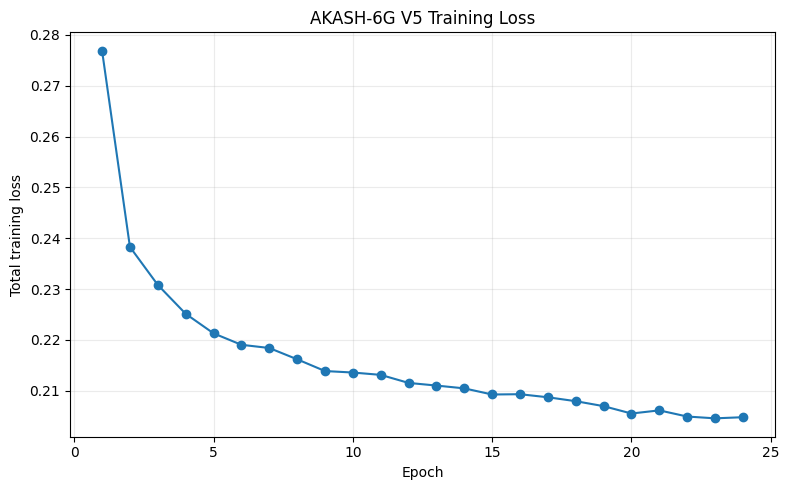

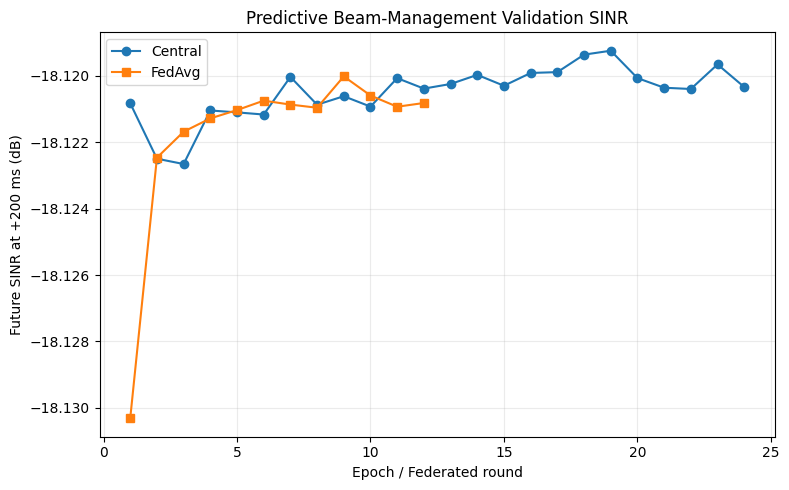

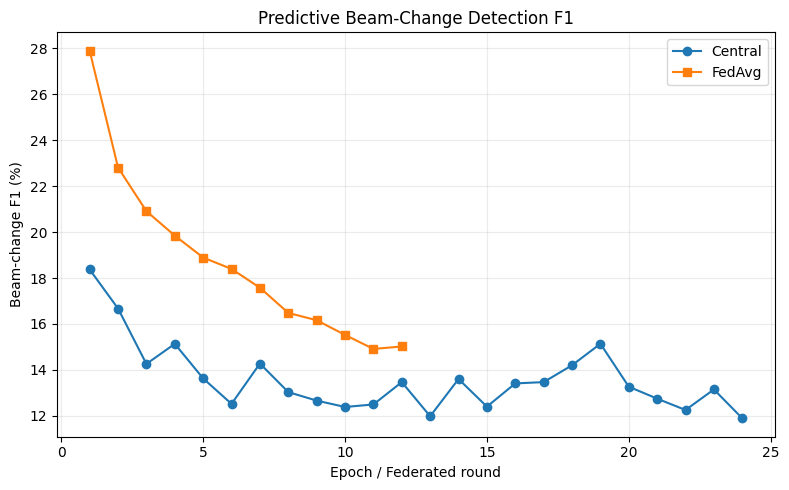

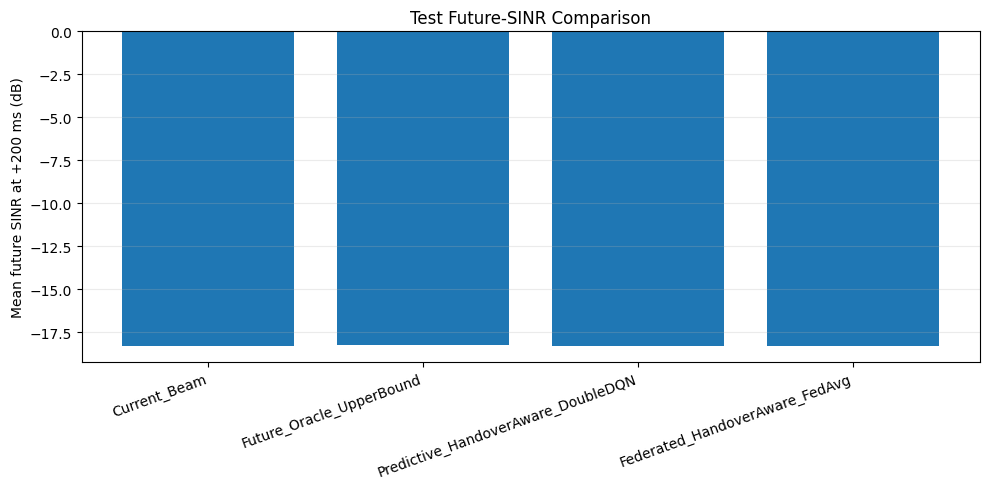

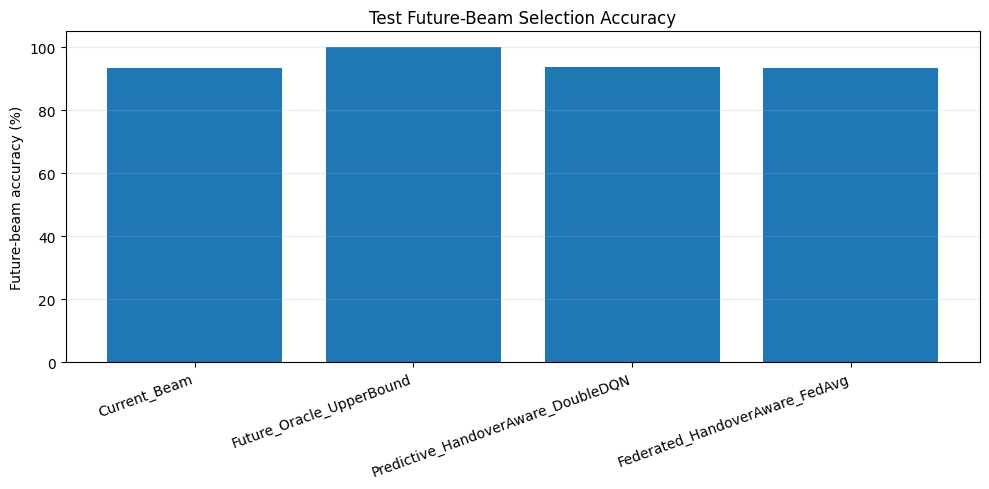

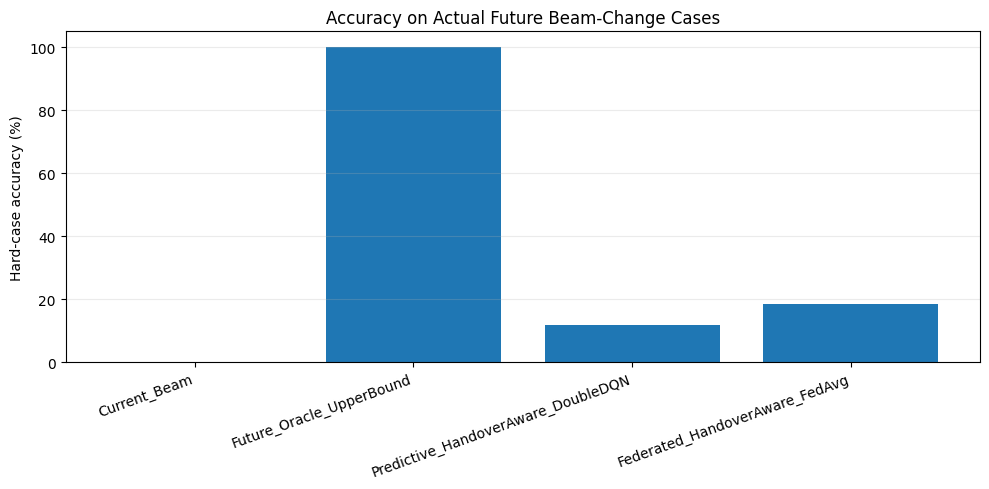

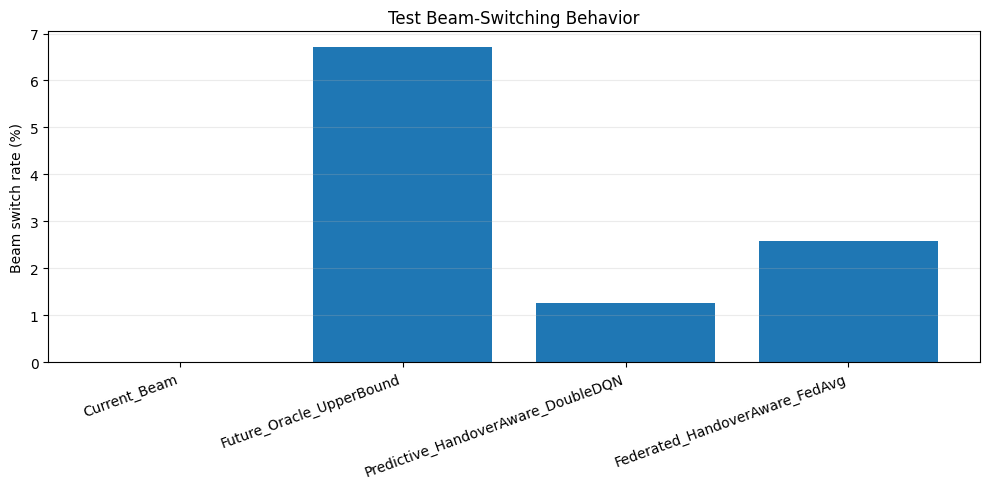

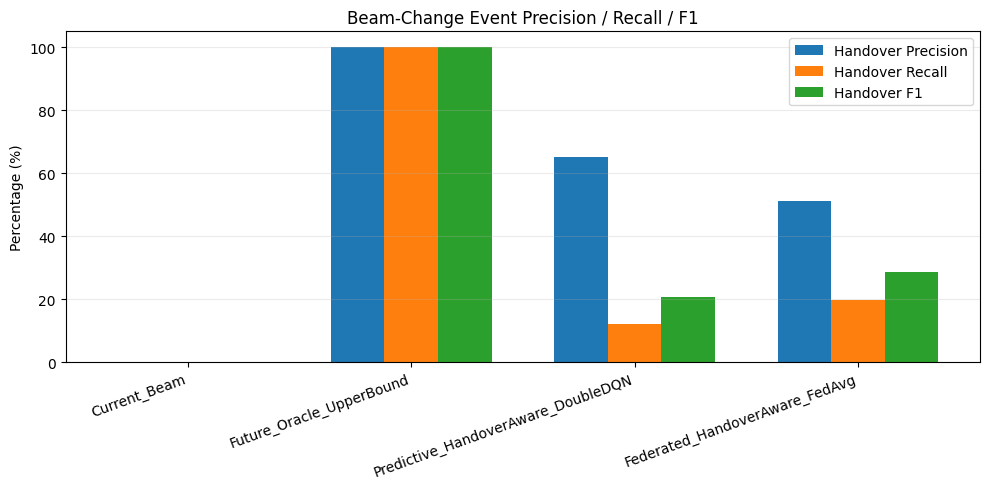

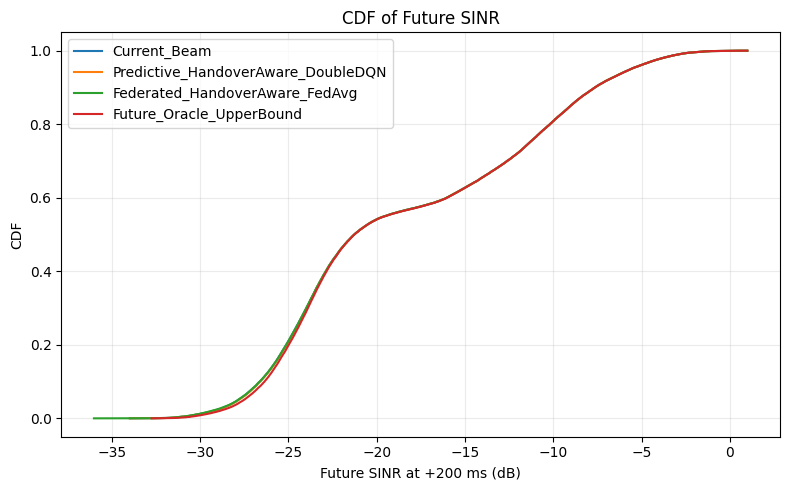

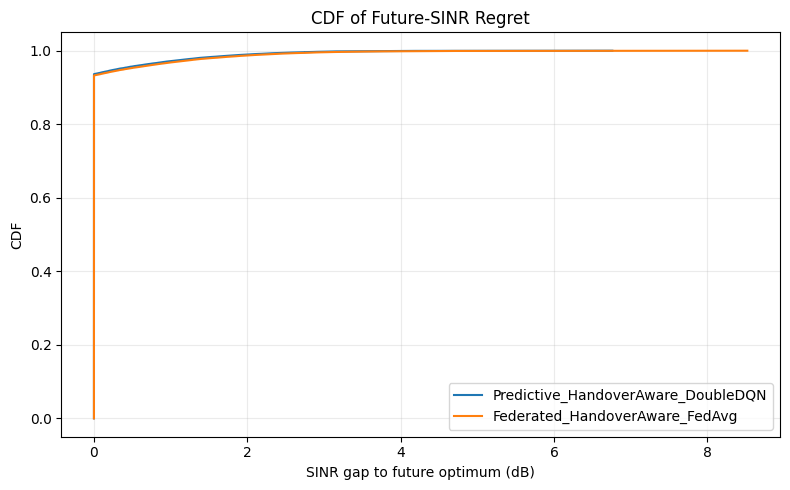

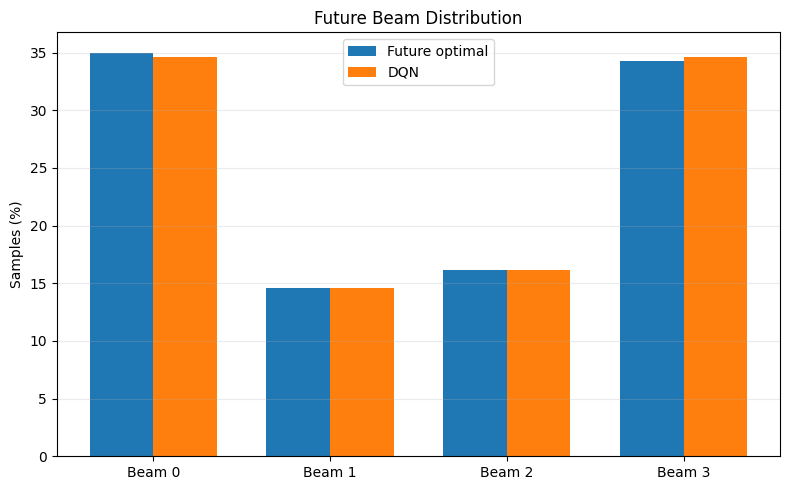

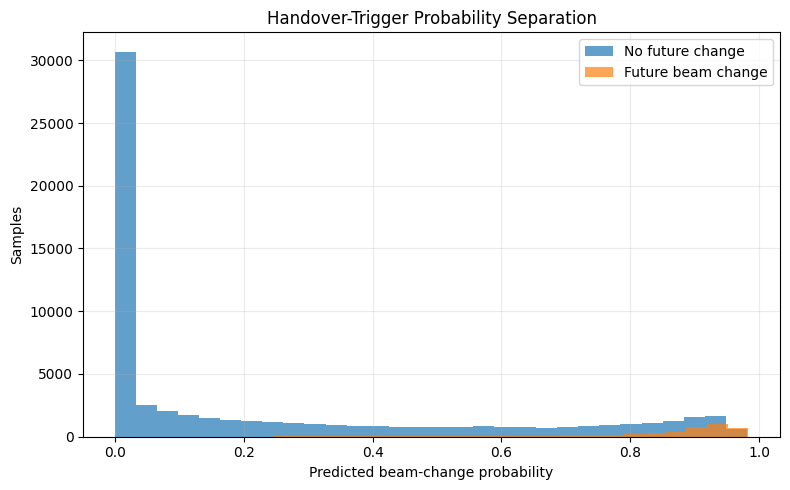

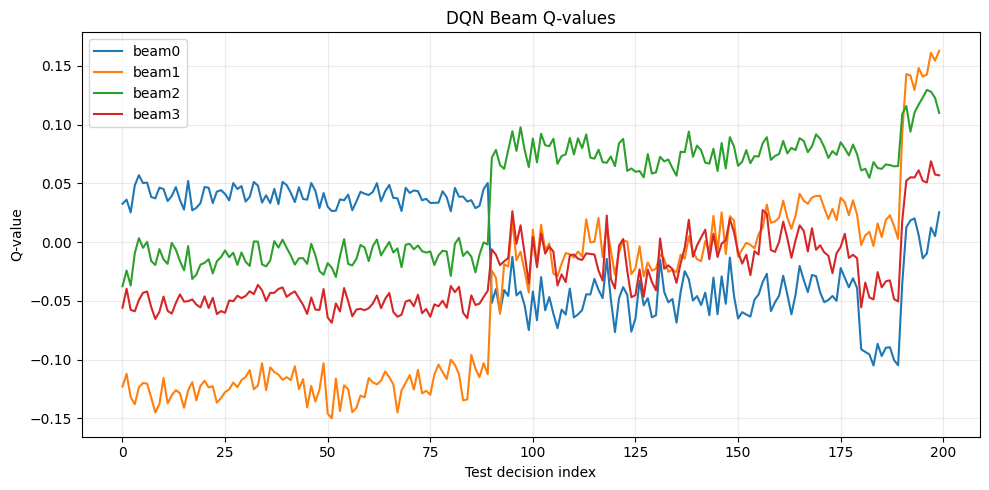


AKASH-6G V5 COMPLETE
Outputs: /content/AKASH6G_V5_HANDOVER_AWARE_RESULTS
Total runtime: 16.08 min
No ground-truth future beam was used as an inference feature.
No beam switch was artificially forced.


In [ ]:

from __future__ import annotations

import copy
import json
import math
import os
import random
import time
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

SEED = 42
N_BEAMS = 4
DT_MS = 20
HORIZON_MS = 200
H_STEPS = HORIZON_MS // DT_MS
ROWS_PER_UE = 100
VALID_STATES_PER_UE = ROWS_PER_UE - H_STEPS  # 90
TRANSITIONS_PER_UE = VALID_STATES_PER_UE - 1  # 89

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Network
HIDDEN = 128
DROPOUT = 0.05
STATE_DIM = 55

# Central Double-DQN
GAMMA = 0.95
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 24
BATCH_SIZE_GPU = 1024
BATCH_SIZE_CPU = 256
TARGET_UPDATE_STEPS = 500
GRAD_CLIP = 5.0

# Loss weights
VALUE_LOSS_WEIGHT = 1.0
RANKING_LOSS_WEIGHT = 0.25
HANDOVER_LOSS_WEIGHT = 0.40
PAIR_MARGIN = 0.05

# Handover-trigger deployment
TRIGGER_THRESHOLD_MIN = 0.20
TRIGGER_THRESHOLD_MAX = 0.80
TRIGGER_THRESHOLD_STEPS = 25

# Deployment hysteresis: switch only if the predicted beam has enough
# Q-advantage over staying on the current beam.
SWITCH_ADVANTAGE_GRID = (0.0, 0.0025, 0.005, 0.01, 0.02, 0.04)

# Reward: bounded future utility + future gain over staying.
SINR_THRESHOLD_DB = 5.0
SINR_UTILITY_SCALE_DB = 3.0
GAIN_SCALE_DB = 3.0
SWITCH_PENALTY = 0.008
SWITCH_BENEFIT = 0.030

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 12
N_CLIENTS = 10
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 2
FED_LR = 3e-4
FED_TARGET_UPDATE_STEPS = 400
CLIENT_MAX_STATES = 35_000

# Bootstrap CIs
BOOTSTRAP_REPS = 400

OUTPUT_DIR = Path(
    os.environ.get(
        "AKASH6G_OUTPUT_DIR",
        "/content/AKASH6G_V5_HANDOVER_AWARE_RESULTS",
    )
)
DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()

DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]
SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path.cwd(),
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = BATCH_SIZE_GPU if DEVICE.type == "cuda" else BATCH_SIZE_CPU


# ============================================================================
# 2. COLUMNS
# ============================================================================

BEAM_RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]
BEAM_SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]

BASE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS

DELTA_COLS = [f"d_{c}" for c in BASE_COLS]
MARGIN_COLS = [f"margin_{c}" for c in BEAM_RSRP_COLS + BEAM_SINR_COLS]

REQUIRED_COLUMNS = [
    "Time_ms",
    "UE_ID",
    "Satellite_ID",
    "Satellite_Altitude_km",
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Prediction_Horizon_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "Beam_Switch",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS


# ============================================================================
# 3. REPRODUCIBILITY / HELPERS
# ============================================================================

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


def log(msg: str = "") -> None:
    print(msg, flush=True)


def save_json(path: Path, obj: object) -> None:
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        if isinstance(v, torch.Tensor):
            return v.detach().cpu().tolist()
        raise TypeError(f"Cannot serialize {type(v)}")

    path.write_text(json.dumps(obj, indent=2, default=convert), encoding="utf-8")


def beam_to_int(x, allow_minus_one: bool = False) -> int:
    if pd.isna(x):
        raise ValueError("Beam label is NaN")
    try:
        if isinstance(x, str):
            s = x.strip().lower()
            if s.startswith("beam"):
                s = s[4:]
            b = int(float(s))
        else:
            b = int(x)
    except Exception as exc:
        raise ValueError(f"Invalid beam label: {x!r}") from exc
    if allow_minus_one and b == -1:
        return -1
    if not 0 <= b < N_BEAMS:
        raise ValueError(f"Beam must be 0..{N_BEAMS-1}, got {b}")
    return b


def convert_beam_column(series: pd.Series, allow_minus_one: bool = False) -> np.ndarray:
    return np.asarray(
        [beam_to_int(v, allow_minus_one=allow_minus_one) for v in series],
        dtype=np.int64,
    )


def beam_name(b: int) -> str:
    return f"beam{int(b)}" if 0 <= int(b) < N_BEAMS else "N/A"


# ============================================================================
# 4. DATASET DISCOVERY
# ============================================================================

def candidate_score(path: Path) -> int:
    name = path.name.lower()
    score = 0
    if "final_corrected" in name:
        score += 100
    if "5000ue" in name:
        score += 50
    if "physical" in name:
        score += 25
    if name.endswith("(2).csv"):
        score += 5
    try:
        score += min(int(path.stat().st_size / 1_000_000), 50)
    except Exception:
        pass
    return score


def is_candidate(path: Path) -> bool:
    if not path.is_file() or path.suffix.lower() != ".csv":
        return False
    name = path.name.lower()
    return "akash6g" in name and any(k in name for k in ("physical", "corrected", "5000ue"))


def resolve_dataset_path() -> Path:
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if not p.is_file():
            raise FileNotFoundError(f"AKASH6G_DATASET_PATH does not exist: {p}")
        return p

    candidates: Dict[str, Path] = {}
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for fname in DATASET_FILENAMES:
            p = root / fname
            if p.is_file():
                candidates[str(p.resolve())] = p
        try:
            for p in root.rglob("*.csv"):
                if is_candidate(p):
                    candidates[str(p.resolve())] = p
        except Exception:
            continue

    if candidates:
        ranked = sorted(candidates.values(), key=candidate_score, reverse=True)
        chosen = ranked[0]
        log(f"Dataset auto-detected: {chosen}")
        if len(ranked) > 1:
            log("Other candidates:")
            for p in ranked[1:6]:
                log(f"  {p}")
        return chosen

    # Colab upload fallback.
    try:
        from google.colab import files as colab_files
        log("No AKASH-6G CSV found. Opening Colab upload dialog...")
        uploaded = colab_files.upload()
        for name in uploaded:
            p = Path("/content") / name
            if p.is_file() and p.suffix.lower() == ".csv":
                return p
    except Exception:
        pass

    raise FileNotFoundError(
        "AKASH-6G physical CSV not found. Upload the corrected CSV or set "
        "AKASH6G_DATASET_PATH."
    )


# ============================================================================
# 5. LOAD + NORMALIZE LABELS
# ============================================================================

def load_dataset() -> Tuple[pd.DataFrame, Path]:
    path = resolve_dataset_path()
    log("=" * 80)
    log("AKASH-6G V5 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG")
    log("=" * 80)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path, low_memory=False)
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError("Missing required columns:\n" + "\n".join(missing))

    for c in BASE_COLS + ["Time_ms", "UE_ID", "Satellite_ID", "Satellite_Altitude_km", "Prediction_Horizon_ms"]:
        df[c] = pd.to_numeric(df[c], errors="raise")

    df["Current_Beam"] = convert_beam_column(df["Current_Beam"])
    df["Optimal_Beam"] = convert_beam_column(df["Optimal_Beam"])
    df["Future_Beam"] = convert_beam_column(df["Future_Beam"], allow_minus_one=True)
    df["Valid_Future_Target"] = pd.to_numeric(df["Valid_Future_Target"], errors="raise").astype(np.int8)
    df["Beam_Switch"] = pd.to_numeric(df["Beam_Switch"], errors="raise").astype(np.int8)

    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)
    log(f"Loaded shape: {df.shape}")
    return df, path


# ============================================================================
# 6. PHYSICS / LINKAGE AUDIT
# ============================================================================

def audit_dataset(df: pd.DataFrame) -> Dict[str, object]:
    log("\n[1/8] STRICT DATASET AUDIT")

    n = len(df)
    unique_ues = int(df["UE_ID"].nunique())
    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    row_counts = df.groupby("UE_ID").size()
    wrong_row_counts = int((row_counts != ROWS_PER_UE).sum())

    max_dt_error = 0.0
    max_current_rsrp_error = 0.0
    max_current_sinr_error = 0.0
    max_range_geometry_error_km = 0.0
    max_delay_error_ms = 0.0
    future_mismatch = 0
    validity_mismatch = 0
    optimal_rsrp_match = 0
    optimal_sinr_match = 0
    ranking_same = 0

    re_km = 6371.0
    h_km = 600.0
    c_km_s = 299792.458

    for ue, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        t = g["Time_ms"].to_numpy(float)
        if len(t) > 1:
            max_dt_error = max(max_dt_error, float(np.max(np.abs(np.diff(t) - DT_MS))))

        current = g["Current_Beam"].to_numpy(int)
        optimal = g["Optimal_Beam"].to_numpy(int)
        future = g["Future_Beam"].to_numpy(int)
        valid = g["Valid_Future_Target"].to_numpy(int)
        rsrp = g[BEAM_RSRP_COLS].to_numpy(float)
        sinr = g[BEAM_SINR_COLS].to_numpy(float)

        expected_current_rsrp = rsrp[np.arange(len(g)), current]
        expected_current_sinr = sinr[np.arange(len(g)), current]
        max_current_rsrp_error = max(
            max_current_rsrp_error,
            float(np.max(np.abs(g["Current_RSRP_dBm"].to_numpy(float) - expected_current_rsrp))),
        )
        max_current_sinr_error = max(
            max_current_sinr_error,
            float(np.max(np.abs(g["Current_SINR_dB"].to_numpy(float) - expected_current_sinr))),
        )

        rs_arg = rsrp.argmax(axis=1)
        si_arg = sinr.argmax(axis=1)
        optimal_rsrp_match += int(np.sum(optimal == rs_arg))
        optimal_sinr_match += int(np.sum(optimal == si_arg))
        ranking_same += int(np.sum(rs_arg == si_arg))

        # Exact +200 ms target check for valid rows.
        for i in range(VALID_STATES_PER_UE):
            if future[i] != optimal[i + H_STEPS]:
                future_mismatch += 1
            if valid[i] != 1:
                validity_mismatch += 1
        for i in range(VALID_STATES_PER_UE, ROWS_PER_UE):
            if valid[i] != 0 or future[i] != -1:
                validity_mismatch += 1

        # Geometry check using standard spherical slant-range relation.
        elev = np.deg2rad(g["Elevation_Angle_deg"].to_numpy(float))
        expected_d = -re_km * np.sin(elev) + np.sqrt(
            (re_km + h_km) ** 2 - (re_km * np.cos(elev)) ** 2
        )
        max_range_geometry_error_km = max(
            max_range_geometry_error_km,
            float(np.max(np.abs(g["Slant_Range_km"].to_numpy(float) - expected_d))),
        )
        expected_delay_ms = g["Slant_Range_km"].to_numpy(float) / c_km_s * 1000.0
        max_delay_error_ms = max(
            max_delay_error_ms,
            float(np.max(np.abs(g["Propagation_Delay_ms"].to_numpy(float) - expected_delay_ms))),
        )

    valid_rows = int(df["Valid_Future_Target"].sum())
    total = max(n, 1)
    audit = {
        "rows": n,
        "columns": int(df.shape[1]),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "wrong_ue_row_counts": wrong_row_counts,
        "max_time_step_error_ms": max_dt_error,
        "max_current_rsrp_linkage_error_db": max_current_rsrp_error,
        "max_current_sinr_linkage_error_db": max_current_sinr_error,
        "future_mismatches": future_mismatch,
        "future_validity_mismatches": validity_mismatch,
        "valid_predictive_rows": valid_rows,
        "optimal_vs_rsrp_pct": 100.0 * optimal_rsrp_match / total,
        "optimal_vs_sinr_pct": 100.0 * optimal_sinr_match / total,
        "rsrp_sinr_ranking_same_pct": 100.0 * ranking_same / total,
        "max_range_geometry_error_km": max_range_geometry_error_km,
        "max_propagation_delay_error_ms": max_delay_error_ms,
        "altitude_min_km": float(df["Satellite_Altitude_km"].min()),
        "altitude_max_km": float(df["Satellite_Altitude_km"].max()),
        "doppler_min_khz": float(df["Doppler_kHz"].min()),
        "doppler_max_khz": float(df["Doppler_kHz"].max()),
        "doppler_rate_min_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].min()),
        "doppler_rate_max_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].max()),
        "elevation_min_deg": float(df["Elevation_Angle_deg"].min()),
        "elevation_max_deg": float(df["Elevation_Angle_deg"].max()),
        "slant_range_min_km": float(df["Slant_Range_km"].min()),
        "slant_range_max_km": float(df["Slant_Range_km"].max()),
    }

    for k, v in audit.items():
        if isinstance(v, float):
            log(f"{k:38s}: {v:.9g}")
        else:
            log(f"{k:38s}: {v}")

    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("WARNING: RSRP and SINR rankings are nearly identical; this is a simulator limitation.")

    hard_fail = (
        n != 500_000
        or unique_ues != 5_000
        or missing != 0
        or duplicates != 0
        or wrong_row_counts != 0
        or max_dt_error > 1e-6
        or max_current_rsrp_error > 1e-3
        or max_current_sinr_error > 1e-3
        or future_mismatch != 0
        or validity_mismatch != 0
        or max_range_geometry_error_km > 1e-3
        or max_delay_error_ms > 1e-6
    )
    if hard_fail:
        raise ValueError("STRICT DATASET AUDIT FAILED. Training was stopped.")

    log("STRICT DATASET AUDIT: PASS")
    return audit


# ============================================================================
# 7. UE SPLIT
# ============================================================================

def split_ues(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    ues = np.sort(df["UE_ID"].unique().astype(int))
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)
    n = len(ues)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))
    train = np.sort(ues[:n_train])
    val = np.sort(ues[n_train:n_train + n_val])
    test = np.sort(ues[n_train + n_val:])
    if len(set(train) & set(val)) or len(set(train) & set(test)) or len(set(val) & set(test)):
        raise RuntimeError("UE split overlap detected.")
    log(f"UE split: train={len(train)}, val={len(val)}, test={len(test)}")
    return train, val, test


# ============================================================================
# 8. STATE CONSTRUCTION — 55 FEATURES
# ============================================================================

def build_states(
    df: pd.DataFrame,
    train_ues: np.ndarray,
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    log("\n[2/8] BUILDING LEAKAGE-SAFE TEMPORAL STATES")
    n = len(df)
    base = df[BASE_COLS].to_numpy(np.float32)
    current = df["Current_Beam"].to_numpy(np.int64)

    deltas = np.zeros_like(base, dtype=np.float32)
    margins = np.zeros((n, 8), dtype=np.float32)
    history = np.zeros((n, 12), dtype=np.float32)
    dwell = np.zeros(n, dtype=np.float32)

    # Because df is sorted by UE/time, global contiguous slices are safe.
    for _, g in df.groupby("UE_ID", sort=False):
        idx = g.index.to_numpy()
        b = g["Current_Beam"].to_numpy(np.int64)
        bbase = base[idx]
        if len(idx) > 1:
            deltas[idx[1:]] = bbase[1:] - bbase[:-1]
        for j, ridx in enumerate(idx):
            for h in range(3):
                src = max(0, j - h)
                history[ridx, h * N_BEAMS + b[src]] = 1.0
            k = j
            while k > 0 and b[k - 1] == b[j]:
                k -= 1
            dwell[ridx] = j - k

    rsrp = df[BEAM_RSRP_COLS].to_numpy(np.float32)
    sinr = df[BEAM_SINR_COLS].to_numpy(np.float32)
    cur_rsrp = df["Current_RSRP_dBm"].to_numpy(np.float32)[:, None]
    cur_sinr = df["Current_SINR_dB"].to_numpy(np.float32)[:, None]
    margins[:, :4] = rsrp - cur_rsrp
    margins[:, 4:] = sinr - cur_sinr

    continuous = np.concatenate([base, deltas, margins, dwell[:, None]], axis=1)
    if continuous.shape[1] != 39:
        raise RuntimeError(f"Expected 39 continuous features, got {continuous.shape[1]}")

    train_mask = df["UE_ID"].isin(set(train_ues.tolist())).to_numpy()
    train_values = continuous[train_mask]
    mean = train_values.mean(axis=0).astype(np.float32)
    std = train_values.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0
    norm = ((continuous - mean) / std).astype(np.float32)

    onehot = np.zeros((n, N_BEAMS), np.float32)
    onehot[np.arange(n), current] = 1.0
    state = np.concatenate([norm, onehot, history], axis=1).astype(np.float32)
    if state.shape[1] != STATE_DIM:
        raise RuntimeError(f"State dimension mismatch: {state.shape[1]} != {STATE_DIM}")

    log(f"State dimension: {STATE_DIM} = 39 continuous + 4 current-beam one-hot + 12 beam-history one-hot")
    return df, state, mean, std


# ============================================================================
# 9. STATE-LEVEL COUNTERFACTUAL DATASET
# ============================================================================

def build_decision_dataset(
    df: pd.DataFrame,
    state: np.ndarray,
    ue_ids: np.ndarray,
    max_states: Optional[int] = None,
) -> Dict[str, np.ndarray]:
    """Return one row per valid decision state, not four duplicated rows.

    The implementation is deliberately vectorized per UE.  Earlier versions
    repeatedly used pandas iloc inside the inner time loop, which made the
    315k-state construction unnecessarily slow in Colab.
    """
    ue_set = set(int(x) for x in ue_ids)
    row_parts: List[np.ndarray] = []
    next_parts: List[np.ndarray] = []
    fs_parts: List[np.ndarray] = []
    cur_parts: List[np.ndarray] = []
    opt_parts: List[np.ndarray] = []
    ue_parts: List[np.ndarray] = []
    time_parts: List[np.ndarray] = []

    for ue, g in df[df["UE_ID"].isin(ue_set)].groupby("UE_ID", sort=True):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            raise RuntimeError(f"UE {ue} has {len(g)} rows; expected {ROWS_PER_UE}")

        ridx = g.index.to_numpy(np.int64)
        # 90 valid decision times: t = 0..89.
        row_parts.append(ridx[:VALID_STATES_PER_UE])
        # The final decision at t=1780 ms uses row 90 (1800 ms) as its
        # one-step next state; row 90 itself does not need a future target.
        next_parts.append(ridx[1:VALID_STATES_PER_UE + 1])

        sinr = g[BEAM_SINR_COLS].to_numpy(np.float32)
        fs_parts.append(sinr[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        cur_parts.append(g["Current_Beam"].to_numpy(np.int64)[:VALID_STATES_PER_UE])
        opt_parts.append(g["Optimal_Beam"].to_numpy(np.int64)[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        ue_parts.append(np.full(VALID_STATES_PER_UE, int(ue), dtype=np.int64))
        time_parts.append(g["Time_ms"].to_numpy(np.float32)[:VALID_STATES_PER_UE])

    rows = np.concatenate(row_parts)
    next_rows = np.concatenate(next_parts)
    FS = np.concatenate(fs_parts, axis=0)
    CB = np.concatenate(cur_parts)
    FO = np.concatenate(opt_parts)
    UE = np.concatenate(ue_parts)
    TM = np.concatenate(time_parts)

    X = state[rows]
    NX = state[next_rows]

    if max_states is not None and len(X) > max_states:
        rng = np.random.default_rng(SEED + int(len(ue_ids)) + 17)
        idx = rng.choice(len(X), size=int(max_states), replace=False)
        idx.sort()
        X, NX, FS, CB, FO, UE, TM = [a[idx] for a in (X, NX, FS, CB, FO, UE, TM)]

    return {
        "states": X.astype(np.float32, copy=False),
        "next_states": NX.astype(np.float32, copy=False),
        "future_sinr": FS.astype(np.float32, copy=False),
        "current_beam": CB.astype(np.int64, copy=False),
        "future_optimal": FO.astype(np.int64, copy=False),
        "UE_ID": UE.astype(np.int64, copy=False),
        "Time_ms": TM.astype(np.float32, copy=False),
    }


# ============================================================================
# 10. PHYSICS-BACKED REWARD
# ============================================================================

def counterfactual_reward(future_sinr: np.ndarray, current_beam: np.ndarray) -> np.ndarray:
    """Vectorized reward matrix [samples,4]. Future labels are not used."""
    sinr = np.asarray(future_sinr, np.float32)
    current = np.asarray(current_beam, np.int64)
    z = np.clip((sinr - SINR_THRESHOLD_DB) / SINR_UTILITY_SCALE_DB, -30.0, 30.0)
    absolute = 1.0 / (1.0 + np.exp(-z))

    rows = np.arange(len(sinr))
    stay_sinr = sinr[rows, current]
    gain = sinr - stay_sinr[:, None]
    gain_term = np.tanh(gain / GAIN_SCALE_DB)

    switches = (np.arange(N_BEAMS)[None, :] != current[:, None]).astype(np.float32)
    reward = absolute + SWITCH_BENEFIT * gain_term - SWITCH_PENALTY * switches

    # Centering removes only an action-independent constant per state.
    reward -= reward.mean(axis=1, keepdims=True)
    return reward.astype(np.float32)


# ============================================================================
# 11. MODEL
# ============================================================================

class HandoverAwareDuelingDoubleDQN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(STATE_DIM, HIDDEN),
            nn.LayerNorm(HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, N_BEAMS),
        )
        self.handover_head = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.trunk(x)
        v = self.value(h)
        a = self.advantage(h)
        q = v + a - a.mean(dim=1, keepdim=True)
        handover_logit = self.handover_head(h).squeeze(1)
        return q, handover_logit


def clone_model(model: nn.Module) -> nn.Module:
    out = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    out.load_state_dict(model.state_dict())
    return out


# ============================================================================
# 12. TRAINING TENSOR HELPERS
# ============================================================================

def to_tensor(a: np.ndarray, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    return torch.from_numpy(np.asarray(a)).to(device=DEVICE, dtype=dtype)


def compute_handover_labels(current: np.ndarray, future_opt: np.ndarray) -> np.ndarray:
    return (current != future_opt).astype(np.float32)


def batch_indices(n: int, batch_size: int, rng: np.random.Generator) -> Iterable[np.ndarray]:
    order = rng.permutation(n)
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


# ============================================================================
# 13. ONE OPTIMIZATION STEP
# ============================================================================

def ranking_loss(q: torch.Tensor, rewards: torch.Tensor) -> torch.Tensor:
    """Pairwise hinge loss: actions with higher physical reward should have higher Q."""
    # Six unordered pairs for four beams.
    loss_terms = []
    for i in range(N_BEAMS):
        for j in range(i + 1, N_BEAMS):
            better_i = rewards[:, i] > rewards[:, j]
            better_j = rewards[:, j] > rewards[:, i]
            if better_i.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_i, i] - q[better_i, j])).mean())
            if better_j.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_j, j] - q[better_j, i])).mean())
    if not loss_terms:
        return q.sum() * 0.0
    return torch.stack(loss_terms).mean()


def train_batch(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    optimizer: optim.Optimizer,
    xb: torch.Tensor,
    nxb: torch.Tensor,
    reward_b: torch.Tensor,
    ho_b: torch.Tensor,
) -> Dict[str, float]:
    model.train()
    q, ho_logit = model(xb)

    with torch.no_grad():
        # Double-DQN: online network selects next action; target evaluates it.
        next_q_online, _ = model(nxb)
        next_actions = next_q_online.argmax(dim=1)
        next_q_target, _ = target(nxb)
        next_best = next_q_target.gather(1, next_actions[:, None]).squeeze(1)
        # Same continuation value is applied to all counterfactual actions of this state.
        y = reward_b + GAMMA * next_best[:, None]

    value_loss = F.smooth_l1_loss(q, y)
    rank = ranking_loss(q, reward_b)

    pos = float(ho_b.sum().item())
    neg = float(len(ho_b) - pos)
    pos_weight = torch.tensor([neg / max(pos, 1.0)], device=DEVICE)
    ho_loss = F.binary_cross_entropy_with_logits(ho_logit, ho_b, pos_weight=pos_weight)

    loss = VALUE_LOSS_WEIGHT * value_loss + RANKING_LOSS_WEIGHT * rank + HANDOVER_LOSS_WEIGHT * ho_loss
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    return {
        "loss": float(loss.item()),
        "value_loss": float(value_loss.item()),
        "rank_loss": float(rank.item()),
        "handover_loss": float(ho_loss.item()),
    }


# ============================================================================
# 14. PREDICTION
# ============================================================================

@torch.no_grad()
def predict_model(
    model: HandoverAwareDuelingDoubleDQN,
    X: np.ndarray,
    batch_size: int = 8192,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    q_out: List[np.ndarray] = []
    p_out: List[np.ndarray] = []
    for start in range(0, len(X), batch_size):
        xb = to_tensor(X[start:start + batch_size])
        q, logit = model(xb)
        q_out.append(q.cpu().numpy())
        p_out.append(torch.sigmoid(logit).cpu().numpy())
    return np.concatenate(q_out), np.concatenate(p_out)


def choose_actions(
    q: np.ndarray,
    handover_probability: np.ndarray,
    current: np.ndarray,
    trigger_threshold: float,
    switch_advantage: float,
) -> np.ndarray:
    best = q.argmax(axis=1).astype(np.int64)
    actions = current.astype(np.int64).copy()
    rows = np.arange(len(q))
    advantage = q[rows, best] - q[rows, current]
    switch = (
        (best != current)
        & (handover_probability >= trigger_threshold)
        & (advantage >= switch_advantage)
    )
    actions[switch] = best[switch]
    return actions


# ============================================================================
# 15. EVALUATION
# ============================================================================

def evaluate_predictions(
    actions: np.ndarray,
    q: np.ndarray,
    p: np.ndarray,
    data: Dict[str, np.ndarray],
    trigger_threshold: float,
    switch_advantage: float,
) -> Dict[str, object]:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    future_sinr = data["future_sinr"]
    rows = np.arange(len(actions))
    chosen_sinr = future_sinr[rows, actions]
    optimal_sinr = future_sinr.max(axis=1)

    actual_event = current != optimal
    predicted_event = actions != current
    tp = int(np.sum(actual_event & predicted_event))
    fp = int(np.sum(~actual_event & predicted_event))
    fn = int(np.sum(actual_event & ~predicted_event))
    tn = int(np.sum(~actual_event & ~predicted_event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    hard = actual_event
    hard_acc = float(np.mean(actions[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan")
    accuracy = float(np.mean(actions == optimal) * 100.0)
    switch_rate = float(np.mean(actions != current) * 100.0)
    future_mean = float(chosen_sinr.mean())
    opt_mean = float(optimal_sinr.mean())
    gap = opt_mean - future_mean

    # Event-trigger metrics independent of the beam hysteresis decision.
    trigger_pred = p >= trigger_threshold
    ttp = int(np.sum(actual_event & trigger_pred))
    tfp = int(np.sum(~actual_event & trigger_pred))
    tfn = int(np.sum(actual_event & ~trigger_pred))
    trigger_precision = ttp / max(ttp + tfp, 1)
    trigger_recall = ttp / max(ttp + tfn, 1)
    trigger_f1 = 2 * trigger_precision * trigger_recall / max(trigger_precision + trigger_recall, 1e-12)

    reward_matrix = counterfactual_reward(future_sinr, current)
    chosen_reward = reward_matrix[rows, actions]

    return {
        "future_sinr_db": future_mean,
        "optimal_future_sinr_db": opt_mean,
        "sinr_gap_db": gap,
        "beam_accuracy_pct": accuracy,
        "hard_case_accuracy_pct": hard_acc,
        "hard_cases": int(hard.sum()),
        "switch_rate_pct": switch_rate,
        "correct_handover": int(np.sum(actual_event & (actions == optimal))),
        "missed_handover": int(np.sum(actual_event & (actions == current))),
        "unnecessary_handover": int(np.sum((~actual_event) & (actions != current))),
        "handover_precision_pct": precision * 100.0,
        "handover_recall_pct": recall * 100.0,
        "handover_f1_pct": f1 * 100.0,
        "trigger_precision_pct": trigger_precision * 100.0,
        "trigger_recall_pct": trigger_recall * 100.0,
        "trigger_f1_pct": trigger_f1 * 100.0,
        "mean_reward": float(chosen_reward.mean()),
        "trigger_threshold": float(trigger_threshold),
        "switch_advantage": float(switch_advantage),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "actions": actions,
        "q_values": q,
        "handover_probability": p,
    }


# ============================================================================
# 16. VALIDATION THRESHOLD SELECTION
# ============================================================================

def select_deployment_policy(
    model: HandoverAwareDuelingDoubleDQN,
    val_data: Dict[str, np.ndarray],
) -> Tuple[float, float, Dict[str, float]]:
    """Select trigger threshold and Q-advantage using validation only."""
    q, p = predict_model(model, val_data["states"])
    best_t = 0.5
    best_adv = 0.01
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)
    best_metrics: Dict[str, float] = {}
    for t in np.linspace(TRIGGER_THRESHOLD_MIN, TRIGGER_THRESHOLD_MAX, TRIGGER_THRESHOLD_STEPS):
        for adv in SWITCH_ADVANTAGE_GRID:
            actions = choose_actions(q, p, val_data["current_beam"], float(t), float(adv))
            m = evaluate_predictions(actions, q, p, val_data, float(t), float(adv))
            score = (
                m["handover_f1_pct"],
                m["future_sinr_db"],
                m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
                -m["sinr_gap_db"],
            )
            if score > best_score:
                best_score = score
                best_t = float(t)
                best_adv = float(adv)
                best_metrics = {
                    "handover_f1_pct": float(m["handover_f1_pct"]),
                    "future_sinr_db": float(m["future_sinr_db"]),
                    "hard_case_accuracy_pct": float(m["hard_case_accuracy_pct"]),
                    "switch_rate_pct": float(m["switch_rate_pct"]),
                }
    return best_t, best_adv, best_metrics


# ============================================================================
# 17. CENTRAL TRAINING
# ============================================================================

def train_central(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float]:
    log("\n[4/8] CENTRAL HANDOVER-AWARE DOUBLE-DQN TRAINING")
    model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    target = clone_model(model)
    target.eval()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    rng = np.random.default_rng(SEED + 100)
    reward = counterfactual_reward(train_data["future_sinr"], train_data["current_beam"])
    ho = compute_handover_labels(train_data["current_beam"], train_data["future_optimal"])

    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)
    history = []
    global_step = 0
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        metrics_accum = []
        for idx in batch_indices(len(train_data["states"]), BATCH_SIZE, rng):
            xb = to_tensor(train_data["states"][idx])
            nxb = to_tensor(train_data["next_states"][idx])
            rb = to_tensor(reward[idx])
            hb = to_tensor(ho[idx])
            metrics_accum.append(train_batch(model, target, optimizer, xb, nxb, rb, hb))
            global_step += 1
            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        val_q, val_p = predict_model(model, val_data["states"])
        threshold, switch_adv, _ = select_deployment_policy(model, val_data)
        val_actions = choose_actions(val_q, val_p, val_data["current_beam"], threshold, switch_adv)
        vm = evaluate_predictions(val_actions, val_q, val_p, val_data, threshold, switch_adv)

        row = {
            "epoch": epoch,
            "loss": float(np.mean([x["loss"] for x in metrics_accum])),
            "value_loss": float(np.mean([x["value_loss"] for x in metrics_accum])),
            "rank_loss": float(np.mean([x["rank_loss"] for x in metrics_accum])),
            "handover_loss": float(np.mean([x["handover_loss"] for x in metrics_accum])),
            "val_future_sinr_db": vm["future_sinr_db"],
            "val_sinr_gap_db": vm["sinr_gap_db"],
            "val_accuracy_pct": vm["beam_accuracy_pct"],
            "val_hard_accuracy_pct": vm["hard_case_accuracy_pct"],
            "val_switch_rate_pct": vm["switch_rate_pct"],
            "val_handover_precision_pct": vm["handover_precision_pct"],
            "val_handover_recall_pct": vm["handover_recall_pct"],
            "val_handover_f1_pct": vm["handover_f1_pct"],
            "val_trigger_f1_pct": vm["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"Epoch {epoch:02d}/{EPOCHS} | Loss {row['loss']:.5f} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} | Gap {row['val_sinr_gap_db']:.4f} | "
            f"Acc {row['val_accuracy_pct']:.2f}% | Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"HO-F1 {row['val_handover_f1_pct']:.2f}% | Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Thr {threshold:.2f}"
        )

        score = (
            vm["handover_f1_pct"],
            vm["hard_case_accuracy_pct"] if np.isfinite(vm["hard_case_accuracy_pct"]) else -np.inf,
            vm["future_sinr_db"],
            -vm["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())

    if best_state is None:
        raise RuntimeError("Central training produced no checkpoint.")
    model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(model, val_data)
    log(f"Central training time: {(time.time() - start) / 60.0:.2f} min")
    return model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 18. FEDAVG
# ============================================================================

def weighted_average_state_dicts(
    states: Sequence[Dict[str, torch.Tensor]],
    weights: Sequence[float],
) -> Dict[str, torch.Tensor]:
    if not states:
        raise ValueError("No client models to average.")
    total = float(sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")
    out: Dict[str, torch.Tensor] = {}
    for key in states[0]:
        first = states[0][key]
        if not torch.is_floating_point(first):
            # LayerNorm/batch-free model has no integer buffers, but keep this safe.
            out[key] = first.clone()
            continue
        acc = torch.zeros_like(first, dtype=torch.float32)
        for sd, w in zip(states, weights):
            acc += sd[key].float() * (float(w) / total)
        out[key] = acc.to(dtype=first.dtype)
    return out


def local_train(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    data: Dict[str, np.ndarray],
    epochs: int,
    lr: float,
    rng: np.random.Generator,
) -> None:
    reward = counterfactual_reward(data["future_sinr"], data["current_beam"])
    ho = compute_handover_labels(data["current_beam"], data["future_optimal"])
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    steps = 0
    for _ in range(epochs):
        for idx in batch_indices(len(data["states"]), BATCH_SIZE, rng):
            metrics = train_batch(
                model,
                target,
                optimizer,
                to_tensor(data["states"][idx]),
                to_tensor(data["next_states"][idx]),
                to_tensor(reward[idx]),
                to_tensor(ho[idx]),
            )
            steps += 1
            if steps % FED_TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())


def federated_train(
    client_data: Sequence[Dict[str, np.ndarray]],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float]:
    log("\n[6/8] INDEPENDENT FEDAVG TRAINING")
    global_model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    rng = np.random.default_rng(SEED + 2000)
    history = []
    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= len(client_data):
            selected = np.arange(len(client_data))
        else:
            selected = rng.choice(len(client_data), size=CLIENTS_PER_ROUND, replace=False)

        local_states = []
        weights = []
        for cid in selected:
            local = clone_model(global_model)
            target = clone_model(local)
            target.eval()
            local_train(local, target, client_data[int(cid)], LOCAL_EPOCHS, FED_LR, rng)
            local_states.append({k: v.detach().cpu().clone() for k, v in local.state_dict().items()})
            weights.append(float(len(client_data[int(cid)]["states"])))
            del local, target

        averaged = weighted_average_state_dicts(local_states, weights)
        global_model.load_state_dict(averaged)

        threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
        q, p = predict_model(global_model, val_data["states"])
        actions = choose_actions(q, p, val_data["current_beam"], threshold, switch_adv)
        m = evaluate_predictions(actions, q, p, val_data, threshold, switch_adv)
        row = {
            "round": rnd,
            "val_future_sinr_db": m["future_sinr_db"],
            "val_sinr_gap_db": m["sinr_gap_db"],
            "val_accuracy_pct": m["beam_accuracy_pct"],
            "val_hard_accuracy_pct": m["hard_case_accuracy_pct"],
            "val_switch_rate_pct": m["switch_rate_pct"],
            "val_handover_precision_pct": m["handover_precision_pct"],
            "val_handover_recall_pct": m["handover_recall_pct"],
            "val_handover_f1_pct": m["handover_f1_pct"],
            "val_trigger_f1_pct": m["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | ValSINR {row['val_future_sinr_db']:.4f} | "
            f"Gap {row['val_sinr_gap_db']:.4f} | Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | HO-F1 {row['val_handover_f1_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        score = (
            m["handover_f1_pct"],
            m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
            m["future_sinr_db"],
            -m["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(global_model.state_dict())

    if best_state is None:
        raise RuntimeError("FedAvg training produced no checkpoint.")
    global_model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
    return global_model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 19. BASELINES
# ============================================================================

def evaluate_baselines(data: Dict[str, np.ndarray]) -> Dict[str, Dict[str, object]]:
    fs = data["future_sinr"]
    current = data["current_beam"]
    rows = np.arange(len(fs))
    optimal = data["future_optimal"]
    out = {}

    # Current RSRP/SINR baseline is represented by the current beam: this is a
    # deployment-realistic zero-wait baseline, not a future oracle.
    choices = {
        "Current_Beam": current,
        "Future_Oracle_UpperBound": fs.argmax(axis=1),
    }
    for name, action in choices.items():
        chosen = fs[rows, action]
        hard = current != optimal
        event = action != current
        actual = current != optimal
        tp = int(np.sum(actual & event))
        fp = int(np.sum(~actual & event))
        fn = int(np.sum(actual & ~event))
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-12)
        out[name] = {
            "future_sinr_db": float(chosen.mean()),
            "optimal_future_sinr_db": float(fs.max(axis=1).mean()),
            "sinr_gap_db": float(fs.max(axis=1).mean() - chosen.mean()),
            "beam_accuracy_pct": float(np.mean(action == optimal) * 100.0),
            "hard_case_accuracy_pct": float(np.mean(action[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan"),
            "switch_rate_pct": float(np.mean(action != current) * 100.0),
            "correct_handover": int(np.sum(actual & (action == optimal))),
            "missed_handover": int(np.sum(actual & (action == current))),
            "unnecessary_handover": int(np.sum((~actual) & (action != current))),
            "handover_precision_pct": prec * 100.0,
            "handover_recall_pct": rec * 100.0,
            "handover_f1_pct": f1 * 100.0,
            "mean_reward": float(counterfactual_reward(fs, current)[rows, action].mean()),
            "actions": action,
        }
    return out


# ============================================================================
# 20. BOOTSTRAP 95% CIs — TEST ONLY
# ============================================================================

def bootstrap_mean_ci(values: np.ndarray, reps: int = BOOTSTRAP_REPS, seed: int = SEED) -> Tuple[float, float]:
    values = np.asarray(values, float)
    if len(values) == 0:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    n = len(values)
    # Process in chunks to avoid huge memory use.
    means = np.empty(reps, float)
    chunk = 50
    for s in range(0, reps, chunk):
        r = min(chunk, reps - s)
        idx = rng.integers(0, n, size=(r, n))
        means[s:s + r] = values[idx].mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


# ============================================================================
# 21. PREDICTION TABLE
# ============================================================================

def make_prediction_table(
    data: Dict[str, np.ndarray],
    dqn_result: Dict[str, object],
    fed_result: Optional[Dict[str, object]],
) -> pd.DataFrame:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    fs = data["future_sinr"]
    q = dqn_result["q_values"]
    p = dqn_result["handover_probability"]
    actions = dqn_result["actions"]
    fed_actions = fed_result["actions"] if fed_result is not None else np.full(len(actions), -1, int)
    fed_q = fed_result["q_values"] if fed_result is not None else None
    fed_p = fed_result["handover_probability"] if fed_result is not None else None

    rows = []
    for i in range(len(actions)):
        row = {
            "UE_ID": int(data["UE_ID"][i]),
            "Time_ms": float(data["Time_ms"][i]),
            "Current_Beam": beam_name(current[i]),
            "Future_Optimal_Beam": beam_name(optimal[i]),
            "DQN_Beam": beam_name(actions[i]),
            "DQN_Handover_Probability": float(p[i]),
            "DQN_Correct": int(actions[i] == optimal[i]),
            "DQN_Switch": int(actions[i] != current[i]),
            "DQN_Future_SINR_dB": float(fs[i, actions[i]]),
            "Hard_Case": int(current[i] != optimal[i]),
        }
        for a in range(N_BEAMS):
            row[f"DQN_Q_beam{a}"] = float(q[i, a])
            row[f"Future_SINR_beam{a}_dB"] = float(fs[i, a])
        if fed_result is not None:
            row["FedAvg_Beam"] = beam_name(fed_actions[i])
            row["FedAvg_Handover_Probability"] = float(fed_p[i])
            row["FedAvg_Correct"] = int(fed_actions[i] == optimal[i])
            row["FedAvg_Switch"] = int(fed_actions[i] != current[i])
            row["FedAvg_Future_SINR_dB"] = float(fs[i, fed_actions[i]])
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(fed_q[i, a])
        rows.append(row)
    return pd.DataFrame(rows)


# ============================================================================
# 22. PLOTS
# ============================================================================

def savefig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_plots(
    central_history: pd.DataFrame,
    fed_history: Optional[pd.DataFrame],
    comparison: pd.DataFrame,
    pred: pd.DataFrame,
    out: Path,
) -> None:
    # 01 loss
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Total training loss")
    plt.title("AKASH-6G V5 Training Loss")
    plt.grid(alpha=0.25)
    savefig(out / "01_training_loss.png")

    # 02 validation SINR
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_future_sinr_db"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_future_sinr_db"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "02_validation_future_sinr.png")

    # 03 handover F1
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_handover_f1_pct"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_handover_f1_pct"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Beam-change F1 (%)")
    plt.title("Predictive Beam-Change Detection F1")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "03_validation_handover_f1.png")

    # 04 test SINR
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Future_SINR_dB"])
    plt.ylabel("Mean future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "04_test_future_sinr.png")

    # 05 accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Accuracy_pct"])
    plt.ylabel("Future-beam accuracy (%)")
    plt.title("Test Future-Beam Selection Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "05_test_accuracy.png")

    # 06 hard-case accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Hard_Case_Accuracy_pct"])
    plt.ylabel("Hard-case accuracy (%)")
    plt.title("Accuracy on Actual Future Beam-Change Cases")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "06_test_hard_case_accuracy.png")

    # 07 switch rate
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Switch_Rate_pct"])
    plt.ylabel("Beam switch rate (%)")
    plt.title("Test Beam-Switching Behavior")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "07_test_switch_rate.png")

    # 08 event F1
    x = np.arange(len(comparison))
    width = 0.24
    plt.figure(figsize=(10, 5))
    for j, col in enumerate(["Handover_Precision_pct", "Handover_Recall_pct", "Handover_F1_pct"]):
        plt.bar(x + (j - 1) * width, comparison[col], width, label=col.replace("_pct", "").replace("_", " "))
    plt.xticks(x, comparison["Method"], rotation=20, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title("Beam-Change Event Precision / Recall / F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "08_handover_event_metrics.png")

    # 09 Future SINR CDF
    plt.figure(figsize=(8, 5))
    for method in ["Current_Beam", "Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg", "Future_Oracle_UpperBound"]:
        if method not in pred.attrs.get("cdf_data", {}):
            continue
        values = np.sort(pred.attrs["cdf_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("Future SINR at +200 ms (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "09_future_sinr_cdf.png")

    # 10 SINR gap CDF
    plt.figure(figsize=(8, 5))
    for method in ["Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg"]:
        if method not in pred.attrs.get("gap_data", {}):
            continue
        values = np.sort(pred.attrs["gap_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("SINR gap to future optimum (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future-SINR Regret")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "10_future_sinr_gap_cdf.png")

    # 11 beam distribution
    plt.figure(figsize=(8, 5))
    x = np.arange(N_BEAMS)
    actual = pred.groupby("Future_Optimal_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    actual_pct = actual.to_numpy() / len(pred) * 100
    dqn = pred.groupby("DQN_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    dqn_pct = dqn.to_numpy() / len(pred) * 100
    plt.bar(x - 0.18, actual_pct, 0.36, label="Future optimal")
    plt.bar(x + 0.18, dqn_pct, 0.36, label="DQN")
    plt.xticks(x, [f"Beam {i}" for i in range(N_BEAMS)])
    plt.ylabel("Samples (%)")
    plt.title("Future Beam Distribution")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "11_beam_distribution.png")

    # 12 trigger probability histogram
    plt.figure(figsize=(8, 5))
    hard = pred["Hard_Case"] == 1
    plt.hist(pred.loc[~hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="No future change")
    plt.hist(pred.loc[hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="Future beam change")
    plt.xlabel("Predicted beam-change probability")
    plt.ylabel("Samples")
    plt.title("Handover-Trigger Probability Separation")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "12_handover_probability.png")

    # 13 Q-value sample
    sample = pred.head(min(200, len(pred)))
    plt.figure(figsize=(10, 5))
    for a in range(N_BEAMS):
        plt.plot(sample.index, sample[f"DQN_Q_beam{a}"], label=f"beam{a}")
    plt.xlabel("Test decision index")
    plt.ylabel("Q-value")
    plt.title("DQN Beam Q-values")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "13_q_values.png")


# ============================================================================
# 23. MAIN
# ============================================================================

def result_row(name: str, m: Dict[str, object]) -> Dict[str, object]:
    return {
        "Method": name,
        "Future_SINR_dB": m["future_sinr_db"],
        "Optimal_Future_SINR_dB": m["optimal_future_sinr_db"],
        "SINR_Gap_dB": m["sinr_gap_db"],
        "Beam_Accuracy_pct": m["beam_accuracy_pct"],
        "Hard_Case_Accuracy_pct": m["hard_case_accuracy_pct"],
        "Beam_Switch_Rate_pct": m["switch_rate_pct"],
        "Correct_Handover": m["correct_handover"],
        "Missed_Handover": m["missed_handover"],
        "Unnecessary_Handover": m["unnecessary_handover"],
        "Handover_Precision_pct": m["handover_precision_pct"],
        "Handover_Recall_pct": m["handover_recall_pct"],
        "Handover_F1_pct": m["handover_f1_pct"],
        "Trigger_Precision_pct": m.get("trigger_precision_pct", np.nan),
        "Trigger_Recall_pct": m.get("trigger_recall_pct", np.nan),
        "Trigger_F1_pct": m.get("trigger_f1_pct", np.nan),
        "Mean_Reward": m["mean_reward"],
    }


def main() -> None:
    seed_everything()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    total_start = time.time()

    df, dataset_path = load_dataset()
    audit = audit_dataset(df)
    save_json(OUTPUT_DIR / "dataset_audit.json", audit)

    train_ues, val_ues, test_ues = split_ues(df)
    _, state, state_mean, state_std = build_states(df, train_ues)
    np.save(OUTPUT_DIR / "train_state_mean.npy", state_mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", state_std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    log("\nBuilding decision datasets...")
    train_data = build_decision_dataset(df, state, train_ues)
    val_data = build_decision_dataset(df, state, val_ues)
    test_data = build_decision_dataset(df, state, test_ues)
    log(f"Decision states: train={len(train_data['states']):,}, val={len(val_data['states']):,}, test={len(test_data['states']):,}")

    # Central model.
    central_model, central_history, central_threshold, central_advantage = train_central(train_data, val_data)
    torch.save(central_model.state_dict(), OUTPUT_DIR / "AKASH6G_V5_Central_HandoverAware_DoubleDQN.pt")
    central_history.to_csv(OUTPUT_DIR / "Central_training_history.csv", index=False)

    cq, cp = predict_model(central_model, test_data["states"])
    ca = choose_actions(cq, cp, test_data["current_beam"], central_threshold, central_advantage)
    central_test = evaluate_predictions(ca, cq, cp, test_data, central_threshold, central_advantage)

    # Baselines.
    log("\n[5/8] TEST BASELINES")
    baselines = evaluate_baselines(test_data)

    # Independent FedAvg.
    fed_model = None
    fed_history = None
    fed_threshold = None
    fed_advantage = None
    fed_test = None
    if RUN_FEDERATED:
        client_groups = np.array_split(train_ues, N_CLIENTS)
        client_data = []
        for cid, group in enumerate(client_groups):
            d = build_decision_dataset(df, state, group, max_states=CLIENT_MAX_STATES)
            client_data.append(d)
            log(f"Client {cid + 1:02d}/{N_CLIENTS}: {len(group)} UEs, {len(d['states']):,} states")
        fed_model, fed_history, fed_threshold, fed_advantage = federated_train(client_data, val_data)
        torch.save(fed_model.state_dict(), OUTPUT_DIR / "AKASH6G_V5_FedAvg_HandoverAware_DoubleDQN.pt")
        fed_history.to_csv(OUTPUT_DIR / "FedAvg_training_history.csv", index=False)
        fq, fp = predict_model(fed_model, test_data["states"])
        fa = choose_actions(fq, fp, test_data["current_beam"], fed_threshold, fed_advantage)
        fed_test = evaluate_predictions(fa, fq, fp, test_data, fed_threshold, fed_advantage)

    # Comparison.
    comparison_rows = []
    for name in ["Current_Beam", "Future_Oracle_UpperBound"]:
        comparison_rows.append(result_row(name, baselines[name]))
    comparison_rows.append(result_row("Predictive_HandoverAware_DoubleDQN", central_test))
    if fed_test is not None:
        comparison_rows.append(result_row("Federated_HandoverAware_FedAvg", fed_test))
    comparison = pd.DataFrame(comparison_rows)
    comparison.to_csv(OUTPUT_DIR / "FINAL_TEST_COMPARISON.csv", index=False)

    # Bootstrap CIs for main methods on future SINR.
    ci = {}
    for name, m in [
        ("Current_Beam", baselines["Current_Beam"]),
        ("Predictive_HandoverAware_DoubleDQN", central_test),
    ]:
        actions = m["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals)
        ci[name] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    if fed_test is not None:
        actions = fed_test["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals, seed=SEED + 1)
        ci["Federated_HandoverAware_FedAvg"] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    save_json(OUTPUT_DIR / "test_bootstrap_ci95.json", ci)

    # Prediction table.
    fed_result_for_table = fed_test if fed_test is not None else None
    pred = make_prediction_table(test_data, central_test, fed_result_for_table)
    pred.to_csv(OUTPUT_DIR / "ACTUAL_BEAM_DECISIONS_TEST.csv", index=False)

    # CDF data stored as attrs for plot function.
    cdf_data = {
        "Current_Beam": test_data["future_sinr"][np.arange(len(test_data["states"])), baselines["Current_Beam"]["actions"]],
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"][np.arange(len(test_data["states"])), central_test["actions"]],
        "Future_Oracle_UpperBound": test_data["future_sinr"].max(axis=1),
    }
    gap_data = {
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"].max(axis=1) - cdf_data["Predictive_HandoverAware_DoubleDQN"],
    }
    if fed_test is not None:
        cdf_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"][np.arange(len(test_data["states"])), fed_test["actions"]]
        gap_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"].max(axis=1) - cdf_data["Federated_HandoverAware_FedAvg"]
    pred.attrs["cdf_data"] = cdf_data
    pred.attrs["gap_data"] = gap_data

    # Print results.
    log("\n" + "=" * 80)
    log("FINAL TEST RESULTS — V5")
    log("=" * 80)
    print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    log("\nBootstrap 95% CI for mean future SINR:")
    print(json.dumps(ci, indent=2))

    # Scientific warning, never hide poor results.
    if central_test["handover_recall_pct"] < 50.0:
        log("\nRESEARCH WARNING: central beam-change recall is below 50%.")
        log("Do not claim reliable predictive handover detection in the paper.")
    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("RESEARCH WARNING: current simulator makes RSRP and SINR beam ranking nearly identical.")
        log("Do not claim the AI learned interference-separated beam ranking from this dataset.")

    # Config / methodology record.
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "output_dir": str(OUTPUT_DIR),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "state_dim": STATE_DIM,
        "state_definition": "39 normalized continuous features + 4 current-beam one-hot + 12 beam-history one-hot; temporal deltas, beam margins, and dwell time are included in the 39 continuous features",
        "dt_ms": DT_MS,
        "prediction_horizon_ms": HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_states_per_ue": VALID_STATES_PER_UE,
        "ue_split": [TRAIN_FRAC, VAL_FRAC, TEST_FRAC],
        "gamma": GAMMA,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "federated_rounds": FED_ROUNDS,
        "clients": N_CLIENTS,
        "local_epochs": LOCAL_EPOCHS,
        "client_max_states": CLIENT_MAX_STATES,
        "trigger_threshold_central": central_threshold,
        "switch_advantage_central": central_advantage,
        "trigger_threshold_fedavg": fed_threshold,
        "switch_advantage_fedavg": fed_advantage,
        "switch_advantage_grid": list(SWITCH_ADVANTAGE_GRID),
        "reward": "bounded future SINR utility + relative future-SINR gain over staying + small switching cost; centered per state",
        "future_label_used_as_inference_input": False,
        "future_sinr_used_as_counterfactual_training_outcome": True,
        "methodology": "handover-aware hybrid offline/counterfactual Double-DQN + supervised trigger head + independent FedAvg",
        "scientific_scope": "single-satellite intra-satellite beam management",
        "dataset_type": "physics-based simulation, not measured satellite telemetry",
        "confidence_interval": "bootstrap 95% CI on test future-SINR means; no fabricated Monte Carlo claims",
    }
    save_json(OUTPUT_DIR / "experiment_config.json", config)

    audit_text = f"""AKASH-6G V5 RESEARCH AUDIT\n==========================\n\nDataset: {dataset_path}\nRows: {len(df):,}\nUEs: {df['UE_ID'].nunique():,}\nTime step: {DT_MS} ms\nPrediction horizon: {HORIZON_MS} ms\nValid prediction states: {VALID_STATES_PER_UE} per UE\n\nMethod: Handover-aware hybrid offline/counterfactual Dueling Double-DQN + independent FedAvg.\nFuture_Beam is never an inference input. Future four-beam SINR is used as the physical counterfactual outcome.\n\nScope: one satellite, four beams; results are intra-satellite beam-management / beam-change results.\nThe physical dataset is simulated, not measured satellite telemetry.\n\nPhysical-model limitation: RSRP/SINR beam rankings are audited and reported; Python does not artificially alter them.\n\nCentral validation trigger threshold: {central_threshold:.4f}\nCentral validation Q-advantage threshold: {central_advantage:.6f}\nFedAvg validation trigger threshold: {fed_threshold if fed_threshold is not None else float('nan'):.4f}\nFedAvg validation Q-advantage threshold: {fed_advantage if fed_advantage is not None else float('nan'):.6f}\n"""
    (OUTPUT_DIR / "RESEARCH_AUDIT.txt").write_text(audit_text, encoding="utf-8")

    save_plots(central_history, fed_history, comparison, pred, OUTPUT_DIR)

    log("\n" + "=" * 80)
    log("AKASH-6G V5 COMPLETE")
    log("=" * 80)
    log(f"Outputs: {OUTPUT_DIR}")
    log(f"Total runtime: {(time.time() - total_start) / 60.0:.2f} min")
    log("No ground-truth future beam was used as an inference feature.")
    log("No beam switch was artificially forced.")


if __name__ == "__main__":
    main()


Dataset auto-detected: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G V6 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/8] STRICT DATASET AUDIT
rows                                  : 500000
columns                               : 25
unique_ues                            : 5000
missing                               : 0
duplicates                            : 0
wrong_ue_row_counts                   : 0
max_time_step_error_ms                : 0
max_current_rsrp_linkage_error_db     : 0
max_current_sinr_linkage_error_db     : 0
future_mismatches                     : 0
future_validity_mismatches            : 0
valid_predictive_rows                 : 450000
optimal_vs_rsrp_pct                   : 100
optimal_vs_sinr_pct                   : 100
rsrp_sinr_ranking_same_pct            : 100
max_range_geometry_error_km           : 3.53363703e-

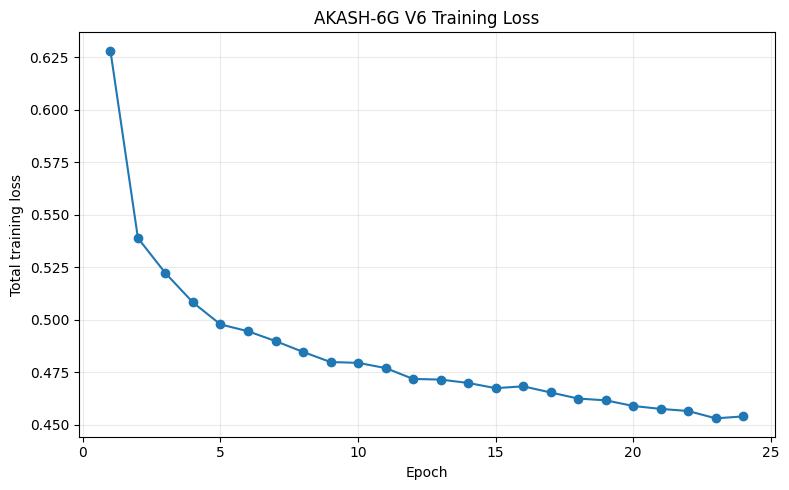

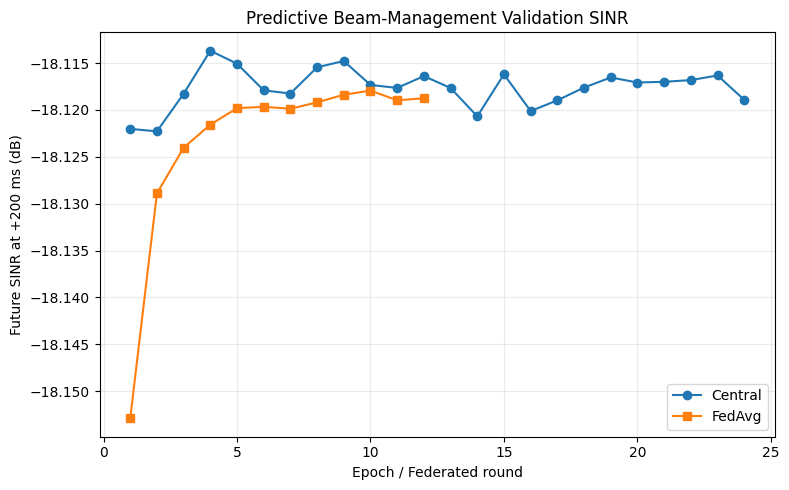

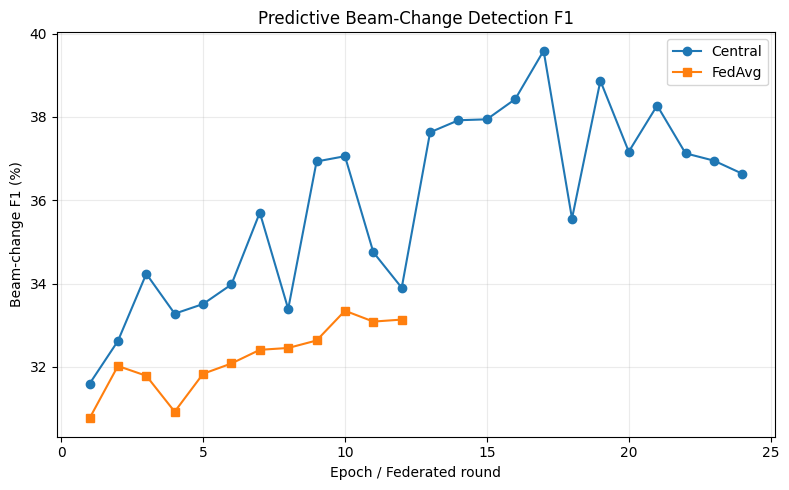

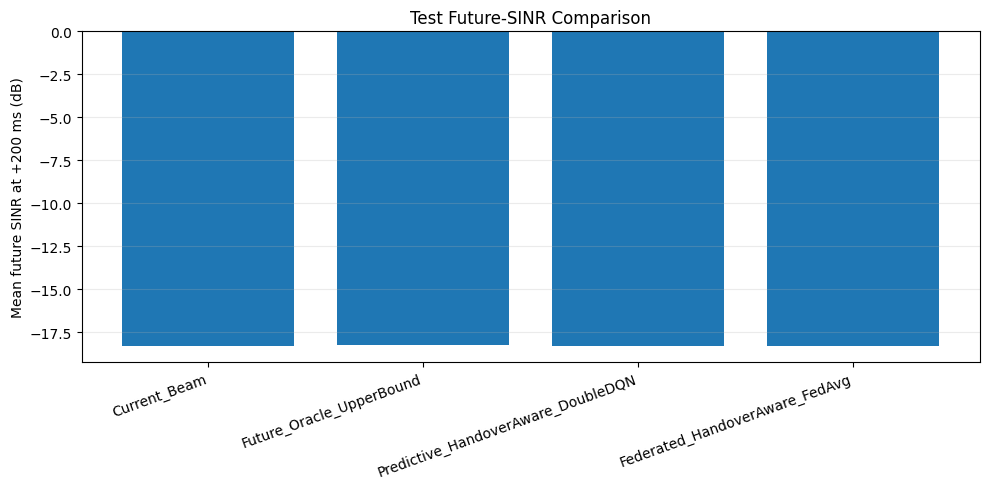

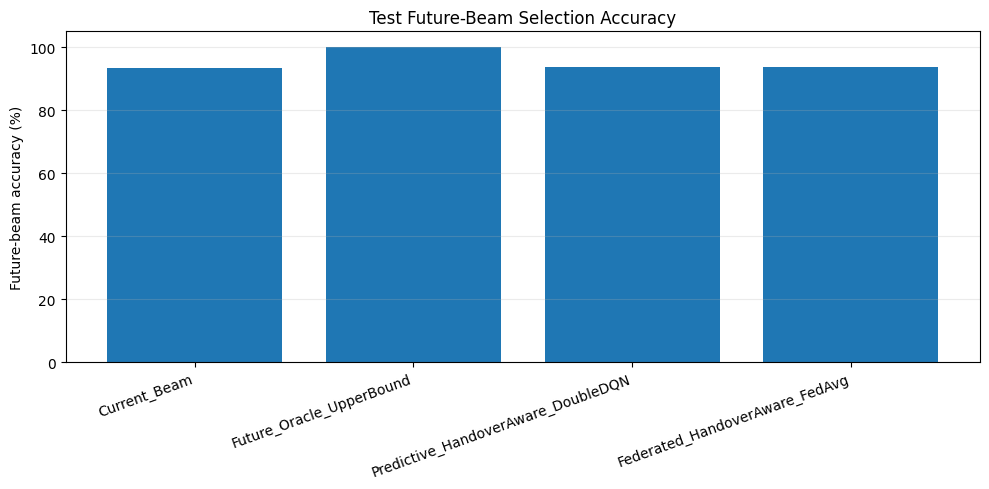

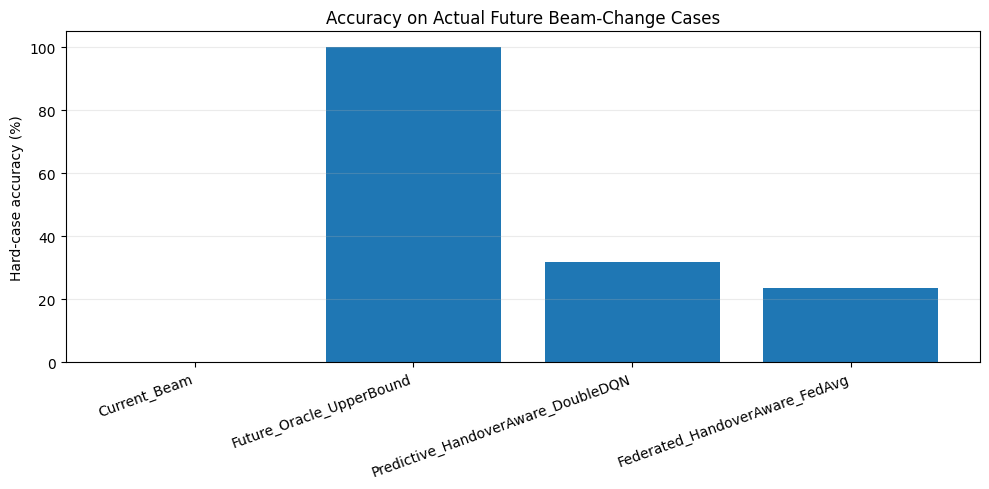

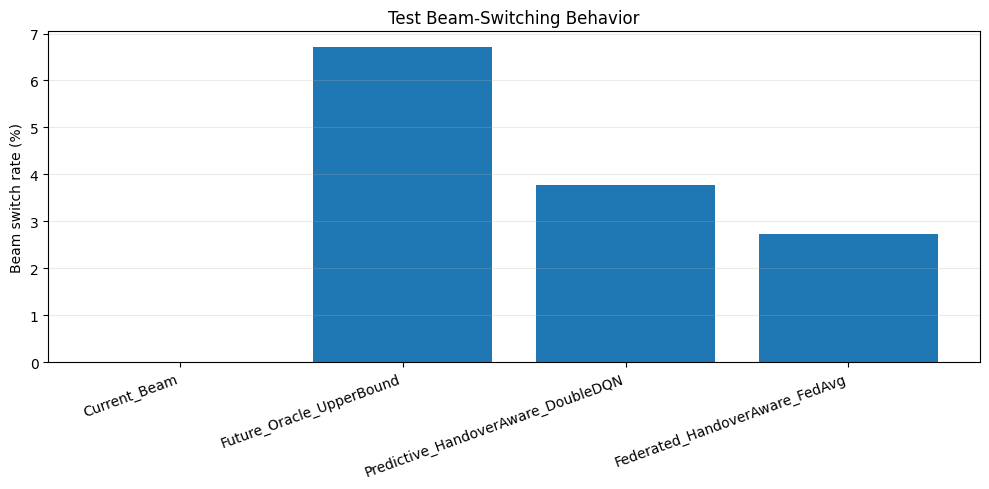

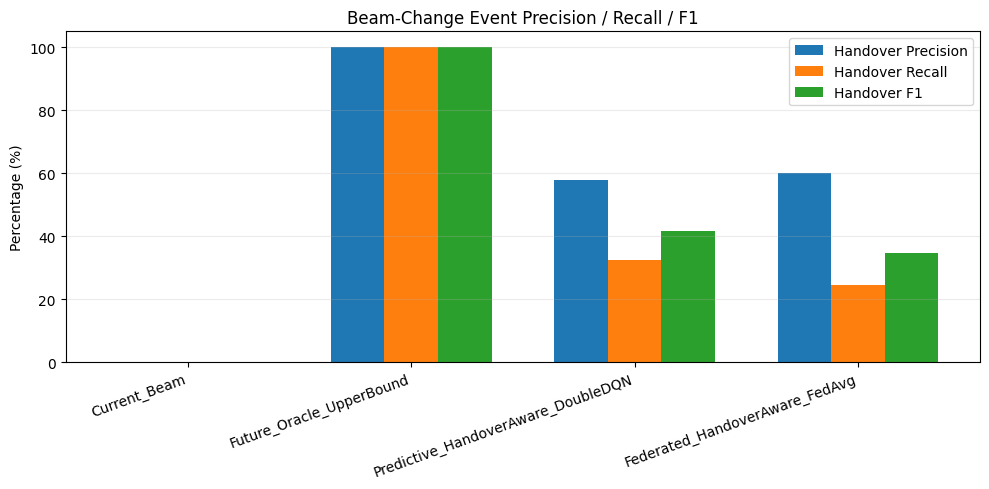

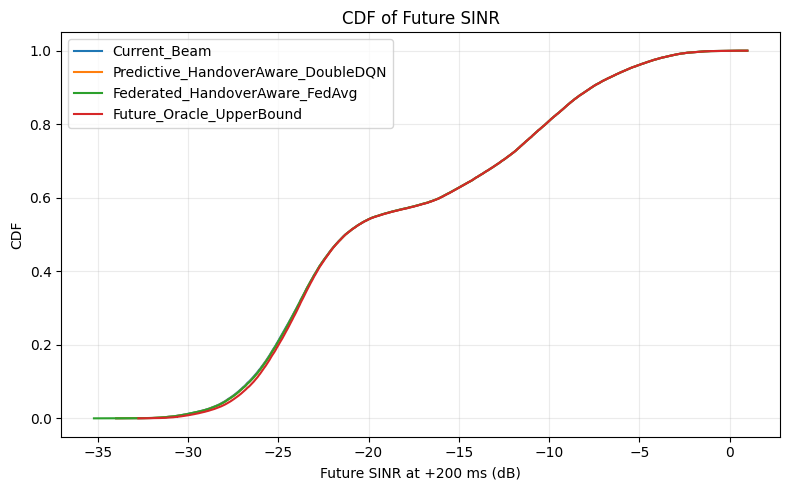

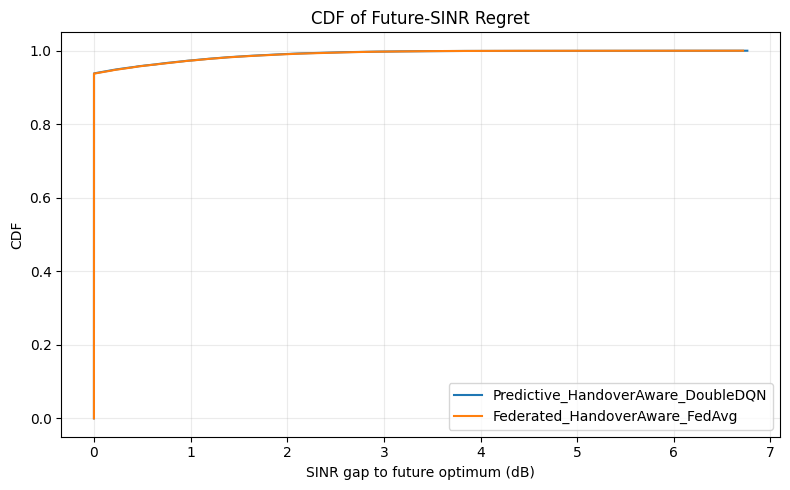

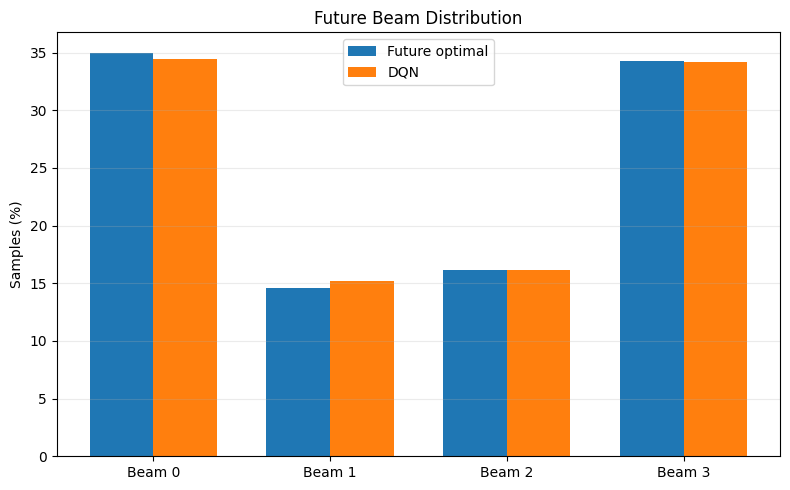

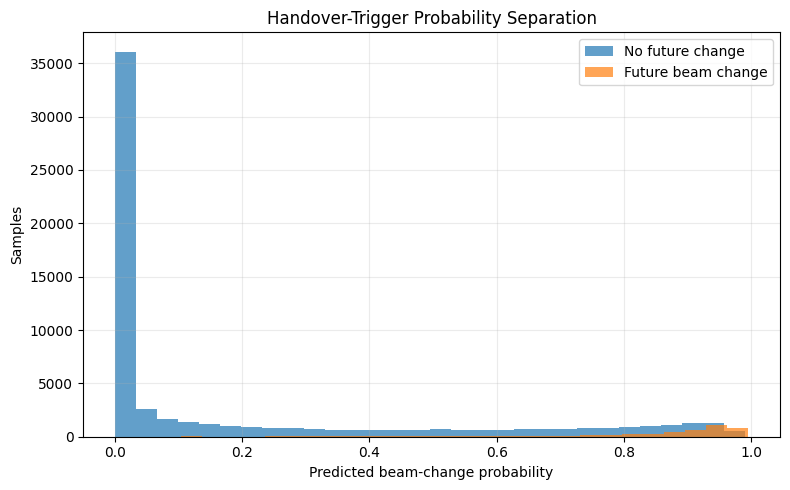

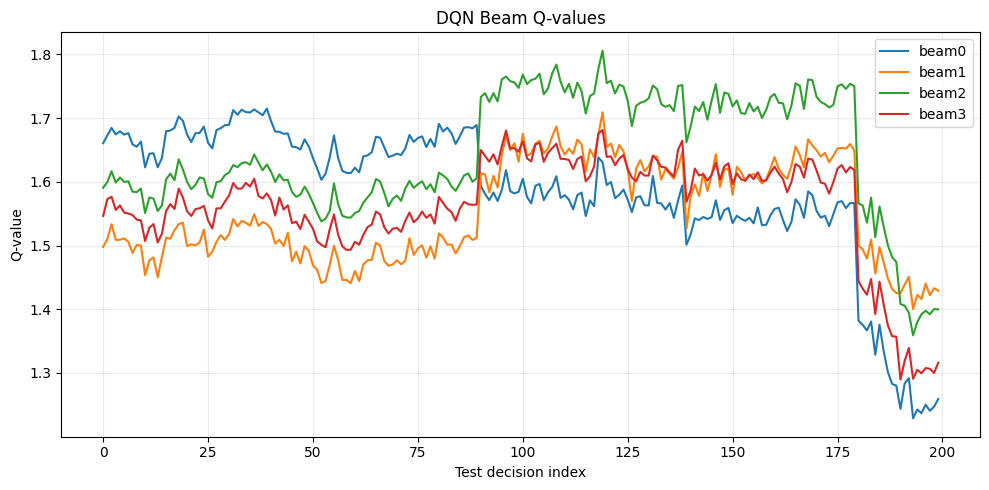


AKASH-6G V6 COMPLETE
Outputs: /content/AKASH6G_V6_RESEARCH_GRADE_RESULTS
Total runtime: 20.42 min
No ground-truth future beam was used as an inference feature.
No beam switch was artificially forced.


In [ ]:

from __future__ import annotations

import copy
import json
import math
import os
import random
import time
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

SEED = 42
N_BEAMS = 4
DT_MS = 20
HORIZON_MS = 200
H_STEPS = HORIZON_MS // DT_MS
ROWS_PER_UE = 100
VALID_STATES_PER_UE = ROWS_PER_UE - H_STEPS  # 90
TRANSITIONS_PER_UE = VALID_STATES_PER_UE - 1  # 89

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Network
HIDDEN = 128
DROPOUT = 0.05
STATE_DIM = 70

# Central Double-DQN
GAMMA = 0.95
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 24
BATCH_SIZE_GPU = 1024
BATCH_SIZE_CPU = 256
TARGET_UPDATE_STEPS = 500
GRAD_CLIP = 5.0

# Loss weights
VALUE_LOSS_WEIGHT = 1.0
RANKING_LOSS_WEIGHT = 0.25
HANDOVER_LOSS_WEIGHT = 0.35
OPPORTUNITY_LOSS_WEIGHT = 0.55
FOCAL_GAMMA = 1.5
PAIR_MARGIN = 0.05

# Handover-trigger deployment
TRIGGER_THRESHOLD_MIN = 0.20
TRIGGER_THRESHOLD_MAX = 0.80
TRIGGER_THRESHOLD_STEPS = 25

# Deployment hysteresis: switch only if the predicted beam has enough
# Q-advantage over staying on the current beam.
SWITCH_ADVANTAGE_GRID = (0.0, 0.0025, 0.005, 0.01, 0.02, 0.04)

# Reward: bounded future utility + future gain over staying.
SINR_THRESHOLD_DB = 5.0
SINR_UTILITY_SCALE_DB = 4.0
GAIN_SCALE_DB = 1.5
MEANINGFUL_GAIN_DB = 0.20
GAIN_TRANSITION_DB = 0.15
SWITCH_PENALTY = 0.002
SWITCH_BENEFIT = 0.12
SWITCH_OPPORTUNITY_BONUS = 0.08

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 12
N_CLIENTS = 10
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 2
FED_LR = 3e-4
FED_TARGET_UPDATE_STEPS = 400
CLIENT_MAX_STATES = 35_000

# Bootstrap CIs
BOOTSTRAP_REPS = 400

OUTPUT_DIR = Path(
    os.environ.get(
        "AKASH6G_OUTPUT_DIR",
        "/content/AKASH6G_V6_RESEARCH_GRADE_RESULTS",
    )
)
DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()

DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]
SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path.cwd(),
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = BATCH_SIZE_GPU if DEVICE.type == "cuda" else BATCH_SIZE_CPU


# ============================================================================
# 2. COLUMNS
# ============================================================================

BEAM_RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]
BEAM_SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]

BASE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS

DELTA_COLS = [f"d_{c}" for c in BASE_COLS]
MARGIN_COLS = [f"margin_{c}" for c in BEAM_RSRP_COLS + BEAM_SINR_COLS]

REQUIRED_COLUMNS = [
    "Time_ms",
    "UE_ID",
    "Satellite_ID",
    "Satellite_Altitude_km",
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Prediction_Horizon_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "Beam_Switch",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS


# ============================================================================
# 3. REPRODUCIBILITY / HELPERS
# ============================================================================

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


def log(msg: str = "") -> None:
    print(msg, flush=True)


def save_json(path: Path, obj: object) -> None:
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        if isinstance(v, torch.Tensor):
            return v.detach().cpu().tolist()
        raise TypeError(f"Cannot serialize {type(v)}")

    path.write_text(json.dumps(obj, indent=2, default=convert), encoding="utf-8")


def beam_to_int(x, allow_minus_one: bool = False) -> int:
    if pd.isna(x):
        raise ValueError("Beam label is NaN")
    try:
        if isinstance(x, str):
            s = x.strip().lower()
            if s.startswith("beam"):
                s = s[4:]
            b = int(float(s))
        else:
            b = int(x)
    except Exception as exc:
        raise ValueError(f"Invalid beam label: {x!r}") from exc
    if allow_minus_one and b == -1:
        return -1
    if not 0 <= b < N_BEAMS:
        raise ValueError(f"Beam must be 0..{N_BEAMS-1}, got {b}")
    return b


def convert_beam_column(series: pd.Series, allow_minus_one: bool = False) -> np.ndarray:
    return np.asarray(
        [beam_to_int(v, allow_minus_one=allow_minus_one) for v in series],
        dtype=np.int64,
    )


def beam_name(b: int) -> str:
    return f"beam{int(b)}" if 0 <= int(b) < N_BEAMS else "N/A"


# ============================================================================
# 4. DATASET DISCOVERY
# ============================================================================

def candidate_score(path: Path) -> int:
    name = path.name.lower()
    score = 0
    if "final_corrected" in name:
        score += 100
    if "5000ue" in name:
        score += 50
    if "physical" in name:
        score += 25
    if name.endswith("(2).csv"):
        score += 5
    try:
        score += min(int(path.stat().st_size / 1_000_000), 50)
    except Exception:
        pass
    return score


def is_candidate(path: Path) -> bool:
    if not path.is_file() or path.suffix.lower() != ".csv":
        return False
    name = path.name.lower()
    return "akash6g" in name and any(k in name for k in ("physical", "corrected", "5000ue"))


def resolve_dataset_path() -> Path:
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if not p.is_file():
            raise FileNotFoundError(f"AKASH6G_DATASET_PATH does not exist: {p}")
        return p

    candidates: Dict[str, Path] = {}
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for fname in DATASET_FILENAMES:
            p = root / fname
            if p.is_file():
                candidates[str(p.resolve())] = p
        try:
            for p in root.rglob("*.csv"):
                if is_candidate(p):
                    candidates[str(p.resolve())] = p
        except Exception:
            continue

    if candidates:
        ranked = sorted(candidates.values(), key=candidate_score, reverse=True)
        chosen = ranked[0]
        log(f"Dataset auto-detected: {chosen}")
        if len(ranked) > 1:
            log("Other candidates:")
            for p in ranked[1:6]:
                log(f"  {p}")
        return chosen

    # Colab upload fallback.
    try:
        from google.colab import files as colab_files
        log("No AKASH-6G CSV found. Opening Colab upload dialog...")
        uploaded = colab_files.upload()
        for name in uploaded:
            p = Path("/content") / name
            if p.is_file() and p.suffix.lower() == ".csv":
                return p
    except Exception:
        pass

    raise FileNotFoundError(
        "AKASH-6G physical CSV not found. Upload the corrected CSV or set "
        "AKASH6G_DATASET_PATH."
    )


# ============================================================================
# 5. LOAD + NORMALIZE LABELS
# ============================================================================

def load_dataset() -> Tuple[pd.DataFrame, Path]:
    path = resolve_dataset_path()
    log("=" * 80)
    log("AKASH-6G V6 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG")
    log("=" * 80)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path, low_memory=False)
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError("Missing required columns:\n" + "\n".join(missing))

    for c in BASE_COLS + ["Time_ms", "UE_ID", "Satellite_ID", "Satellite_Altitude_km", "Prediction_Horizon_ms"]:
        df[c] = pd.to_numeric(df[c], errors="raise")

    df["Current_Beam"] = convert_beam_column(df["Current_Beam"])
    df["Optimal_Beam"] = convert_beam_column(df["Optimal_Beam"])
    df["Future_Beam"] = convert_beam_column(df["Future_Beam"], allow_minus_one=True)
    df["Valid_Future_Target"] = pd.to_numeric(df["Valid_Future_Target"], errors="raise").astype(np.int8)
    df["Beam_Switch"] = pd.to_numeric(df["Beam_Switch"], errors="raise").astype(np.int8)

    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)
    log(f"Loaded shape: {df.shape}")
    return df, path


# ============================================================================
# 6. PHYSICS / LINKAGE AUDIT
# ============================================================================

def audit_dataset(df: pd.DataFrame) -> Dict[str, object]:
    log("\n[1/8] STRICT DATASET AUDIT")

    n = len(df)
    unique_ues = int(df["UE_ID"].nunique())
    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    row_counts = df.groupby("UE_ID").size()
    wrong_row_counts = int((row_counts != ROWS_PER_UE).sum())

    max_dt_error = 0.0
    max_current_rsrp_error = 0.0
    max_current_sinr_error = 0.0
    max_range_geometry_error_km = 0.0
    max_delay_error_ms = 0.0
    future_mismatch = 0
    validity_mismatch = 0
    optimal_rsrp_match = 0
    optimal_sinr_match = 0
    ranking_same = 0

    re_km = 6371.0
    h_km = 600.0
    c_km_s = 299792.458

    for ue, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        t = g["Time_ms"].to_numpy(float)
        if len(t) > 1:
            max_dt_error = max(max_dt_error, float(np.max(np.abs(np.diff(t) - DT_MS))))

        current = g["Current_Beam"].to_numpy(int)
        optimal = g["Optimal_Beam"].to_numpy(int)
        future = g["Future_Beam"].to_numpy(int)
        valid = g["Valid_Future_Target"].to_numpy(int)
        rsrp = g[BEAM_RSRP_COLS].to_numpy(float)
        sinr = g[BEAM_SINR_COLS].to_numpy(float)

        expected_current_rsrp = rsrp[np.arange(len(g)), current]
        expected_current_sinr = sinr[np.arange(len(g)), current]
        max_current_rsrp_error = max(
            max_current_rsrp_error,
            float(np.max(np.abs(g["Current_RSRP_dBm"].to_numpy(float) - expected_current_rsrp))),
        )
        max_current_sinr_error = max(
            max_current_sinr_error,
            float(np.max(np.abs(g["Current_SINR_dB"].to_numpy(float) - expected_current_sinr))),
        )

        rs_arg = rsrp.argmax(axis=1)
        si_arg = sinr.argmax(axis=1)
        optimal_rsrp_match += int(np.sum(optimal == rs_arg))
        optimal_sinr_match += int(np.sum(optimal == si_arg))
        ranking_same += int(np.sum(rs_arg == si_arg))

        # Exact +200 ms target check for valid rows.
        for i in range(VALID_STATES_PER_UE):
            if future[i] != optimal[i + H_STEPS]:
                future_mismatch += 1
            if valid[i] != 1:
                validity_mismatch += 1
        for i in range(VALID_STATES_PER_UE, ROWS_PER_UE):
            if valid[i] != 0 or future[i] != -1:
                validity_mismatch += 1

        # Geometry check using standard spherical slant-range relation.
        elev = np.deg2rad(g["Elevation_Angle_deg"].to_numpy(float))
        expected_d = -re_km * np.sin(elev) + np.sqrt(
            (re_km + h_km) ** 2 - (re_km * np.cos(elev)) ** 2
        )
        max_range_geometry_error_km = max(
            max_range_geometry_error_km,
            float(np.max(np.abs(g["Slant_Range_km"].to_numpy(float) - expected_d))),
        )
        expected_delay_ms = g["Slant_Range_km"].to_numpy(float) / c_km_s * 1000.0
        max_delay_error_ms = max(
            max_delay_error_ms,
            float(np.max(np.abs(g["Propagation_Delay_ms"].to_numpy(float) - expected_delay_ms))),
        )

    valid_rows = int(df["Valid_Future_Target"].sum())
    total = max(n, 1)
    audit = {
        "rows": n,
        "columns": int(df.shape[1]),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "wrong_ue_row_counts": wrong_row_counts,
        "max_time_step_error_ms": max_dt_error,
        "max_current_rsrp_linkage_error_db": max_current_rsrp_error,
        "max_current_sinr_linkage_error_db": max_current_sinr_error,
        "future_mismatches": future_mismatch,
        "future_validity_mismatches": validity_mismatch,
        "valid_predictive_rows": valid_rows,
        "optimal_vs_rsrp_pct": 100.0 * optimal_rsrp_match / total,
        "optimal_vs_sinr_pct": 100.0 * optimal_sinr_match / total,
        "rsrp_sinr_ranking_same_pct": 100.0 * ranking_same / total,
        "max_range_geometry_error_km": max_range_geometry_error_km,
        "max_propagation_delay_error_ms": max_delay_error_ms,
        "altitude_min_km": float(df["Satellite_Altitude_km"].min()),
        "altitude_max_km": float(df["Satellite_Altitude_km"].max()),
        "doppler_min_khz": float(df["Doppler_kHz"].min()),
        "doppler_max_khz": float(df["Doppler_kHz"].max()),
        "doppler_rate_min_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].min()),
        "doppler_rate_max_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].max()),
        "elevation_min_deg": float(df["Elevation_Angle_deg"].min()),
        "elevation_max_deg": float(df["Elevation_Angle_deg"].max()),
        "slant_range_min_km": float(df["Slant_Range_km"].min()),
        "slant_range_max_km": float(df["Slant_Range_km"].max()),
    }

    for k, v in audit.items():
        if isinstance(v, float):
            log(f"{k:38s}: {v:.9g}")
        else:
            log(f"{k:38s}: {v}")

    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("WARNING: RSRP and SINR rankings are nearly identical; this is a simulator limitation.")

    hard_fail = (
        n != 500_000
        or unique_ues != 5_000
        or missing != 0
        or duplicates != 0
        or wrong_row_counts != 0
        or max_dt_error > 1e-6
        or max_current_rsrp_error > 1e-3
        or max_current_sinr_error > 1e-3
        or future_mismatch != 0
        or validity_mismatch != 0
        or max_range_geometry_error_km > 1e-3
        or max_delay_error_ms > 1e-6
    )
    if hard_fail:
        raise ValueError("STRICT DATASET AUDIT FAILED. Training was stopped.")

    log("STRICT DATASET AUDIT: PASS")
    return audit


# ============================================================================
# 7. UE SPLIT
# ============================================================================

def split_ues(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    ues = np.sort(df["UE_ID"].unique().astype(int))
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)
    n = len(ues)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))
    train = np.sort(ues[:n_train])
    val = np.sort(ues[n_train:n_train + n_val])
    test = np.sort(ues[n_train + n_val:])
    if len(set(train) & set(val)) or len(set(train) & set(test)) or len(set(val) & set(test)):
        raise RuntimeError("UE split overlap detected.")
    log(f"UE split: train={len(train)}, val={len(val)}, test={len(test)}")
    return train, val, test


# ============================================================================
# 8. STATE CONSTRUCTION — 55 FEATURES
# ============================================================================

def build_states(
    df: pd.DataFrame,
    train_ues: np.ndarray,
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    log("\n[2/8] BUILDING LEAKAGE-SAFE TEMPORAL STATES")
    n = len(df)
    base = df[BASE_COLS].to_numpy(np.float32)
    current = df["Current_Beam"].to_numpy(np.int64)

    deltas = np.zeros_like(base, dtype=np.float32)
    second_deltas = np.zeros_like(base, dtype=np.float32)
    margins = np.zeros((n, 8), dtype=np.float32)
    history = np.zeros((n, 12), dtype=np.float32)
    dwell = np.zeros(n, dtype=np.float32)

    # Because df is sorted by UE/time, global contiguous slices are safe.
    for _, g in df.groupby("UE_ID", sort=False):
        idx = g.index.to_numpy()
        b = g["Current_Beam"].to_numpy(np.int64)
        bbase = base[idx]
        if len(idx) > 1:
            deltas[idx[1:]] = bbase[1:] - bbase[:-1]
        if len(idx) > 2:
            second_deltas[idx[2:]] = bbase[2:] - 2.0 * bbase[1:-1] + bbase[:-2]
        for j, ridx in enumerate(idx):
            for h in range(3):
                src = max(0, j - h)
                history[ridx, h * N_BEAMS + b[src]] = 1.0
            k = j
            while k > 0 and b[k - 1] == b[j]:
                k -= 1
            dwell[ridx] = j - k

    rsrp = df[BEAM_RSRP_COLS].to_numpy(np.float32)
    sinr = df[BEAM_SINR_COLS].to_numpy(np.float32)
    cur_rsrp = df["Current_RSRP_dBm"].to_numpy(np.float32)[:, None]
    cur_sinr = df["Current_SINR_dB"].to_numpy(np.float32)[:, None]
    margins[:, :4] = rsrp - cur_rsrp
    margins[:, 4:] = sinr - cur_sinr

    continuous = np.concatenate([base, deltas, second_deltas, margins, dwell[:, None]], axis=1)
    if continuous.shape[1] != 54:
        raise RuntimeError(f"Expected 54 continuous features, got {continuous.shape[1]}")

    train_mask = df["UE_ID"].isin(set(train_ues.tolist())).to_numpy()
    train_values = continuous[train_mask]
    mean = train_values.mean(axis=0).astype(np.float32)
    std = train_values.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0
    norm = ((continuous - mean) / std).astype(np.float32)

    onehot = np.zeros((n, N_BEAMS), np.float32)
    onehot[np.arange(n), current] = 1.0
    state = np.concatenate([norm, onehot, history], axis=1).astype(np.float32)
    if state.shape[1] != STATE_DIM:
        raise RuntimeError(f"State dimension mismatch: {state.shape[1]} != {STATE_DIM}")

    log(f"State dimension: {STATE_DIM} = 54 continuous (15 base + 15 first-difference + 15 second-difference + 8 margins + 1 dwell) + 4 current-beam one-hot + 12 beam-history one-hot")
    return df, state, mean, std


# ============================================================================
# 9. STATE-LEVEL COUNTERFACTUAL DATASET
# ============================================================================

def build_decision_dataset(
    df: pd.DataFrame,
    state: np.ndarray,
    ue_ids: np.ndarray,
    max_states: Optional[int] = None,
) -> Dict[str, np.ndarray]:
    """Return one row per valid decision state, not four duplicated rows.

    The implementation is deliberately vectorized per UE.  Earlier versions
    repeatedly used pandas iloc inside the inner time loop, which made the
    315k-state construction unnecessarily slow in Colab.
    """
    ue_set = set(int(x) for x in ue_ids)
    row_parts: List[np.ndarray] = []
    next_parts: List[np.ndarray] = []
    fs_parts: List[np.ndarray] = []
    cur_parts: List[np.ndarray] = []
    opt_parts: List[np.ndarray] = []
    ue_parts: List[np.ndarray] = []
    time_parts: List[np.ndarray] = []
    elevation_parts: List[np.ndarray] = []
    doppler_parts: List[np.ndarray] = []
    doppler_rate_parts: List[np.ndarray] = []
    edge_margin_parts: List[np.ndarray] = []

    for ue, g in df[df["UE_ID"].isin(ue_set)].groupby("UE_ID", sort=True):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            raise RuntimeError(f"UE {ue} has {len(g)} rows; expected {ROWS_PER_UE}")

        ridx = g.index.to_numpy(np.int64)
        # 90 valid decision times: t = 0..89.
        row_parts.append(ridx[:VALID_STATES_PER_UE])
        # The final decision at t=1780 ms uses row 90 (1800 ms) as its
        # one-step next state; row 90 itself does not need a future target.
        next_parts.append(ridx[1:VALID_STATES_PER_UE + 1])

        sinr = g[BEAM_SINR_COLS].to_numpy(np.float32)
        fs_parts.append(sinr[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        cur_parts.append(g["Current_Beam"].to_numpy(np.int64)[:VALID_STATES_PER_UE])
        opt_parts.append(g["Optimal_Beam"].to_numpy(np.int64)[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        ue_parts.append(np.full(VALID_STATES_PER_UE, int(ue), dtype=np.int64))
        time_parts.append(g["Time_ms"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        elevation_parts.append(g["Elevation_Angle_deg"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        doppler_parts.append(g["Doppler_kHz"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        doppler_rate_parts.append(g["Doppler_Rate_kHz_per_ms"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        cur_rsrp = g["Current_RSRP_dBm"].to_numpy(np.float32)[:VALID_STATES_PER_UE]
        all_rsrp = g[BEAM_RSRP_COLS].to_numpy(np.float32)[:VALID_STATES_PER_UE]
        top2 = np.partition(all_rsrp, -2, axis=1)[:, -2]
        edge_margin_parts.append(all_rsrp.max(axis=1) - top2)

    rows = np.concatenate(row_parts)
    next_rows = np.concatenate(next_parts)
    FS = np.concatenate(fs_parts, axis=0)
    CB = np.concatenate(cur_parts)
    FO = np.concatenate(opt_parts)
    UE = np.concatenate(ue_parts)
    TM = np.concatenate(time_parts)

    X = state[rows]
    NX = state[next_rows]

    if max_states is not None and len(X) > max_states:
        rng = np.random.default_rng(SEED + int(len(ue_ids)) + 17)
        idx = rng.choice(len(X), size=int(max_states), replace=False)
        idx.sort()
        X, NX, FS, CB, FO, UE, TM = [a[idx] for a in (X, NX, FS, CB, FO, UE, TM)]

    return {
        "states": X.astype(np.float32, copy=False),
        "next_states": NX.astype(np.float32, copy=False),
        "future_sinr": FS.astype(np.float32, copy=False),
        "current_beam": CB.astype(np.int64, copy=False),
        "future_optimal": FO.astype(np.int64, copy=False),
        "UE_ID": UE.astype(np.int64, copy=False),
        "Time_ms": TM.astype(np.float32, copy=False),
        "Elevation_Angle_deg": np.concatenate(elevation_parts).astype(np.float32, copy=False),
        "Doppler_kHz": np.concatenate(doppler_parts).astype(np.float32, copy=False),
        "Doppler_Rate_kHz_per_ms": np.concatenate(doppler_rate_parts).astype(np.float32, copy=False),
        "BeamEdge_Margin_dB": np.concatenate(edge_margin_parts).astype(np.float32, copy=False),
    }


# ============================================================================
# 10. PHYSICS-BACKED REWARD
# ============================================================================

def counterfactual_reward(future_sinr: np.ndarray, current_beam: np.ndarray) -> np.ndarray:
    """Counterfactual physical utility for all four actions at t+200 ms.

    The future beam label is not used.  The reward is based only on the four
    future SINRs and the current beam.  A smooth opportunity bonus encourages
    switching when the future SINR advantage is meaningful, while a small cost
    discourages gratuitous changes.
    """
    sinr = np.asarray(future_sinr, np.float32)
    current = np.asarray(current_beam, np.int64)
    z = np.clip((sinr - SINR_THRESHOLD_DB) / SINR_UTILITY_SCALE_DB, -30.0, 30.0)
    absolute = 1.0 / (1.0 + np.exp(-z))
    rows = np.arange(len(sinr))
    stay_sinr = sinr[rows, current]
    gain = sinr - stay_sinr[:, None]
    gain_term = np.tanh(gain / GAIN_SCALE_DB)
    opportunity_z = np.clip((gain - MEANINGFUL_GAIN_DB) / GAIN_TRANSITION_DB, -30.0, 30.0)
    opportunity = 1.0 / (1.0 + np.exp(-opportunity_z))
    switches = (np.arange(N_BEAMS)[None, :] != current[:, None]).astype(np.float32)
    reward = (absolute + SWITCH_BENEFIT * gain_term
              + SWITCH_OPPORTUNITY_BONUS * opportunity * switches
              - SWITCH_PENALTY * switches)
    reward -= reward.mean(axis=1, keepdims=True)
    return reward.astype(np.float32)


# ============================================================================
# 11. MODEL
# ============================================================================

class HandoverAwareDuelingDoubleDQN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(STATE_DIM, HIDDEN),
            nn.LayerNorm(HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, N_BEAMS),
        )
        self.handover_head = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.opportunity_head = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.trunk(x)
        v = self.value(h)
        a = self.advantage(h)
        q = v + a - a.mean(dim=1, keepdim=True)
        handover_logit = self.handover_head(h).squeeze(1)
        opportunity_logit = self.opportunity_head(h).squeeze(1)
        return q, handover_logit, opportunity_logit


def clone_model(model: nn.Module) -> nn.Module:
    out = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    out.load_state_dict(model.state_dict())
    return out


# ============================================================================
# 12. TRAINING TENSOR HELPERS
# ============================================================================

def to_tensor(a: np.ndarray, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    return torch.from_numpy(np.asarray(a)).to(device=DEVICE, dtype=dtype)


def compute_handover_labels(current: np.ndarray, future_opt: np.ndarray) -> np.ndarray:
    return (current != future_opt).astype(np.float32)


def batch_indices(n: int, batch_size: int, rng: np.random.Generator) -> Iterable[np.ndarray]:
    order = rng.permutation(n)
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


# ============================================================================
# 13. ONE OPTIMIZATION STEP
# ============================================================================

def ranking_loss(q: torch.Tensor, rewards: torch.Tensor) -> torch.Tensor:
    """Pairwise hinge loss: actions with higher physical reward should have higher Q."""
    # Six unordered pairs for four beams.
    loss_terms = []
    for i in range(N_BEAMS):
        for j in range(i + 1, N_BEAMS):
            better_i = rewards[:, i] > rewards[:, j]
            better_j = rewards[:, j] > rewards[:, i]
            if better_i.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_i, i] - q[better_i, j])).mean())
            if better_j.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_j, j] - q[better_j, i])).mean())
    if not loss_terms:
        return q.sum() * 0.0
    return torch.stack(loss_terms).mean()


def train_batch(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    optimizer: optim.Optimizer,
    xb: torch.Tensor,
    nxb: torch.Tensor,
    reward_b: torch.Tensor,
    ho_b: torch.Tensor,
    opportunity_b: torch.Tensor,
) -> Dict[str, float]:
    model.train()
    q, ho_logit, opportunity_logit = model(xb)

    with torch.no_grad():
        # Double-DQN: online network selects next action; target evaluates it.
        next_q_online, _, _ = model(nxb)
        next_actions = next_q_online.argmax(dim=1)
        next_q_target, _, _ = target(nxb)
        next_best = next_q_target.gather(1, next_actions[:, None]).squeeze(1)
        # Same continuation value is applied to all counterfactual actions of this state.
        y = reward_b + GAMMA * next_best[:, None]

    value_loss = F.smooth_l1_loss(q, y)
    rank = ranking_loss(q, reward_b)

    pos = float(ho_b.sum().item())
    neg = float(len(ho_b) - pos)
    pos_weight = torch.tensor([neg / max(pos, 1.0)], device=DEVICE)
    ho_loss = F.binary_cross_entropy_with_logits(ho_logit, ho_b, pos_weight=pos_weight)
    # Meaningful opportunity label is computed from the physical future-SINR gain
    # and is never available to the deployment policy.
    pos2 = float(opportunity_b.sum().item())
    neg2 = float(len(opportunity_b) - pos2)
    pos_weight2 = torch.tensor([neg2 / max(pos2, 1.0)], device=DEVICE)
    opportunity_loss = F.binary_cross_entropy_with_logits(opportunity_logit, opportunity_b, pos_weight=pos_weight2)

    loss = (VALUE_LOSS_WEIGHT * value_loss + RANKING_LOSS_WEIGHT * rank
            + HANDOVER_LOSS_WEIGHT * ho_loss + OPPORTUNITY_LOSS_WEIGHT * opportunity_loss)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    return {
        "loss": float(loss.item()),
        "value_loss": float(value_loss.item()),
        "rank_loss": float(rank.item()),
        "handover_loss": float(ho_loss.item()),
        "opportunity_loss": float(opportunity_loss.item()),
    }


# ============================================================================
# 14. PREDICTION
# ============================================================================

@torch.no_grad()
def predict_model(
    model: HandoverAwareDuelingDoubleDQN,
    X: np.ndarray,
    batch_size: int = 8192,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    q_out: List[np.ndarray] = []
    p_out: List[np.ndarray] = []
    o_out: List[np.ndarray] = []
    for start in range(0, len(X), batch_size):
        xb = to_tensor(X[start:start + batch_size])
        q, logit, opportunity_logit = model(xb)
        q_out.append(q.cpu().numpy())
        p_out.append(torch.sigmoid(logit).cpu().numpy())
        o_out.append(torch.sigmoid(opportunity_logit).cpu().numpy())
    return np.concatenate(q_out), np.concatenate(p_out), np.concatenate(o_out)


def choose_actions(
    q: np.ndarray,
    opportunity_probability: np.ndarray,
    current: np.ndarray,
    trigger_threshold: float,
    switch_advantage: float,
) -> np.ndarray:
    best = q.argmax(axis=1).astype(np.int64)
    actions = current.astype(np.int64).copy()
    rows = np.arange(len(q))
    advantage = q[rows, best] - q[rows, current]
    switch = (
        (best != current)
        & (opportunity_probability >= trigger_threshold)
        & (advantage >= switch_advantage)
    )
    actions[switch] = best[switch]
    return actions


# ============================================================================
# 15. EVALUATION
# ============================================================================

def evaluate_predictions(
    actions: np.ndarray,
    q: np.ndarray,
    p: np.ndarray,
    opportunity_p: np.ndarray,
    data: Dict[str, np.ndarray],
    trigger_threshold: float,
    switch_advantage: float,
) -> Dict[str, object]:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    future_sinr = data["future_sinr"]
    rows = np.arange(len(actions))
    chosen_sinr = future_sinr[rows, actions]
    optimal_sinr = future_sinr.max(axis=1)

    actual_event = current != optimal
    rows2 = np.arange(len(future_sinr))
    stay_future = future_sinr[rows2, current]
    future_gain = optimal_sinr - stay_future
    meaningful_event = actual_event & (future_gain >= MEANINGFUL_GAIN_DB)
    predicted_event = actions != current
    tp = int(np.sum(actual_event & predicted_event))
    fp = int(np.sum(~actual_event & predicted_event))
    fn = int(np.sum(actual_event & ~predicted_event))
    tn = int(np.sum(~actual_event & ~predicted_event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    hard = actual_event
    hard_acc = float(np.mean(actions[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan")
    accuracy = float(np.mean(actions == optimal) * 100.0)
    switch_rate = float(np.mean(actions != current) * 100.0)
    future_mean = float(chosen_sinr.mean())
    opt_mean = float(optimal_sinr.mean())
    gap = opt_mean - future_mean

    # Event-trigger metrics independent of the beam hysteresis decision.
    trigger_pred = opportunity_p >= trigger_threshold
    ttp = int(np.sum(actual_event & trigger_pred))
    tfp = int(np.sum(~actual_event & trigger_pred))
    tfn = int(np.sum(actual_event & ~trigger_pred))
    trigger_precision = ttp / max(ttp + tfp, 1)
    trigger_recall = ttp / max(ttp + tfn, 1)
    trigger_f1 = 2 * trigger_precision * trigger_recall / max(trigger_precision + trigger_recall, 1e-12)

    meaningful_pred = actions != current
    mtp = int(np.sum(meaningful_event & meaningful_pred))
    mfp = int(np.sum(~meaningful_event & meaningful_pred))
    mfn = int(np.sum(meaningful_event & ~meaningful_pred))
    mprec = mtp / max(mtp + mfp, 1)
    mrec = mtp / max(mtp + mfn, 1)
    mf1 = 2 * mprec * mrec / max(mprec + mrec, 1e-12)

    reward_matrix = counterfactual_reward(future_sinr, current)
    chosen_reward = reward_matrix[rows, actions]

    return {
        "future_sinr_db": future_mean,
        "optimal_future_sinr_db": opt_mean,
        "sinr_gap_db": gap,
        "beam_accuracy_pct": accuracy,
        "hard_case_accuracy_pct": hard_acc,
        "hard_cases": int(hard.sum()),
        "switch_rate_pct": switch_rate,
        "correct_handover": int(np.sum(actual_event & (actions == optimal))),
        "missed_handover": int(np.sum(actual_event & (actions == current))),
        "unnecessary_handover": int(np.sum((~actual_event) & (actions != current))),
        "handover_precision_pct": precision * 100.0,
        "handover_recall_pct": recall * 100.0,
        "handover_f1_pct": f1 * 100.0,
        "trigger_precision_pct": trigger_precision * 100.0,
        "trigger_recall_pct": trigger_recall * 100.0,
        "trigger_f1_pct": trigger_f1 * 100.0,
        "meaningful_handover_precision_pct": mprec * 100.0,
        "meaningful_handover_recall_pct": mrec * 100.0,
        "meaningful_handover_f1_pct": mf1 * 100.0,
        "meaningful_event_count": int(meaningful_event.sum()),
        "mean_reward": float(chosen_reward.mean()),
        "trigger_threshold": float(trigger_threshold),
        "switch_advantage": float(switch_advantage),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "actions": actions,
        "q_values": q,
        "handover_probability": p,
        "opportunity_probability": opportunity_p,
    }


# ============================================================================
# 16. VALIDATION THRESHOLD SELECTION
# ============================================================================

def select_deployment_policy(
    model: HandoverAwareDuelingDoubleDQN,
    val_data: Dict[str, np.ndarray],
) -> Tuple[float, float, Dict[str, float]]:
    """Select trigger threshold and Q-advantage using validation only."""
    q, p, o = predict_model(model, val_data["states"])
    best_t = 0.5
    best_adv = 0.01
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)
    best_metrics: Dict[str, float] = {}
    for t in np.linspace(TRIGGER_THRESHOLD_MIN, TRIGGER_THRESHOLD_MAX, TRIGGER_THRESHOLD_STEPS):
        for adv in SWITCH_ADVANTAGE_GRID:
            actions = choose_actions(q, o, val_data["current_beam"], float(t), float(adv))
            m = evaluate_predictions(actions, q, p, o, val_data, float(t), float(adv))
            score = (
                m["meaningful_handover_f1_pct"],
                m["handover_f1_pct"],
                m["future_sinr_db"],
                m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
                -m["sinr_gap_db"],
            )
            if score > best_score:
                best_score = score
                best_t = float(t)
                best_adv = float(adv)
                best_metrics = {
                    "handover_f1_pct": float(m["handover_f1_pct"]),
                    "future_sinr_db": float(m["future_sinr_db"]),
                    "hard_case_accuracy_pct": float(m["hard_case_accuracy_pct"]),
                    "switch_rate_pct": float(m["switch_rate_pct"]),
                }
    return best_t, best_adv, best_metrics


# ============================================================================
# 17. CENTRAL TRAINING
# ============================================================================

def train_central(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float]:
    log("\n[4/8] CENTRAL HANDOVER-AWARE DOUBLE-DQN TRAINING")
    model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    target = clone_model(model)
    target.eval()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    rng = np.random.default_rng(SEED + 100)
    reward = counterfactual_reward(train_data["future_sinr"], train_data["current_beam"])
    ho = compute_handover_labels(train_data["current_beam"], train_data["future_optimal"])
    rows = np.arange(len(train_data["future_sinr"]))
    stay = train_data["future_sinr"][rows, train_data["current_beam"]]
    best = train_data["future_sinr"].max(axis=1)
    opportunity = (best - stay >= MEANINGFUL_GAIN_DB).astype(np.float32)

    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)
    history = []
    global_step = 0
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        metrics_accum = []
        for idx in batch_indices(len(train_data["states"]), BATCH_SIZE, rng):
            xb = to_tensor(train_data["states"][idx])
            nxb = to_tensor(train_data["next_states"][idx])
            rb = to_tensor(reward[idx])
            hb = to_tensor(ho[idx])
            metrics_accum.append(train_batch(model, target, optimizer, xb, nxb, rb, hb, to_tensor(opportunity[idx])))
            global_step += 1
            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        val_q, val_p, val_o = predict_model(model, val_data["states"])
        threshold, switch_adv, _ = select_deployment_policy(model, val_data)
        val_actions = choose_actions(val_q, val_o, val_data["current_beam"], threshold, switch_adv)
        vm = evaluate_predictions(val_actions, val_q, val_p, val_o, val_data, threshold, switch_adv)

        row = {
            "epoch": epoch,
            "loss": float(np.mean([x["loss"] for x in metrics_accum])),
            "value_loss": float(np.mean([x["value_loss"] for x in metrics_accum])),
            "rank_loss": float(np.mean([x["rank_loss"] for x in metrics_accum])),
            "handover_loss": float(np.mean([x["handover_loss"] for x in metrics_accum])),
            "opportunity_loss": float(np.mean([x["opportunity_loss"] for x in metrics_accum])),
            "val_future_sinr_db": vm["future_sinr_db"],
            "val_sinr_gap_db": vm["sinr_gap_db"],
            "val_accuracy_pct": vm["beam_accuracy_pct"],
            "val_hard_accuracy_pct": vm["hard_case_accuracy_pct"],
            "val_switch_rate_pct": vm["switch_rate_pct"],
            "val_handover_precision_pct": vm["handover_precision_pct"],
            "val_handover_recall_pct": vm["handover_recall_pct"],
            "val_handover_f1_pct": vm["handover_f1_pct"],
            "val_trigger_f1_pct": vm["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"Epoch {epoch:02d}/{EPOCHS} | Loss {row['loss']:.5f} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} | Gap {row['val_sinr_gap_db']:.4f} | "
            f"Acc {row['val_accuracy_pct']:.2f}% | Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"HO-F1 {row['val_handover_f1_pct']:.2f}% | Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Thr {threshold:.2f}"
        )

        score = (
            vm["meaningful_handover_f1_pct"],
            vm["handover_f1_pct"],
            vm["hard_case_accuracy_pct"] if np.isfinite(vm["hard_case_accuracy_pct"]) else -np.inf,
            vm["future_sinr_db"],
            -vm["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())

    if best_state is None:
        raise RuntimeError("Central training produced no checkpoint.")
    model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(model, val_data)
    log(f"Central training time: {(time.time() - start) / 60.0:.2f} min")
    return model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 18. FEDAVG
# ============================================================================

def weighted_average_state_dicts(
    states: Sequence[Dict[str, torch.Tensor]],
    weights: Sequence[float],
) -> Dict[str, torch.Tensor]:
    if not states:
        raise ValueError("No client models to average.")
    total = float(sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")
    out: Dict[str, torch.Tensor] = {}
    for key in states[0]:
        first = states[0][key]
        if not torch.is_floating_point(first):
            # LayerNorm/batch-free model has no integer buffers, but keep this safe.
            out[key] = first.clone()
            continue
        acc = torch.zeros_like(first, dtype=torch.float32)
        for sd, w in zip(states, weights):
            acc += sd[key].float() * (float(w) / total)
        out[key] = acc.to(dtype=first.dtype)
    return out


def local_train(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    data: Dict[str, np.ndarray],
    epochs: int,
    lr: float,
    rng: np.random.Generator,
) -> None:
    reward = counterfactual_reward(data["future_sinr"], data["current_beam"])
    ho = compute_handover_labels(data["current_beam"], data["future_optimal"])
    rows = np.arange(len(data["future_sinr"]))
    stay = data["future_sinr"][rows, data["current_beam"]]
    best = data["future_sinr"].max(axis=1)
    opportunity = (best - stay >= MEANINGFUL_GAIN_DB).astype(np.float32)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    steps = 0
    for _ in range(epochs):
        for idx in batch_indices(len(data["states"]), BATCH_SIZE, rng):
            metrics = train_batch(
                model,
                target,
                optimizer,
                to_tensor(data["states"][idx]),
                to_tensor(data["next_states"][idx]),
                to_tensor(reward[idx]),
                to_tensor(ho[idx]),
                to_tensor(opportunity[idx]),
            )
            steps += 1
            if steps % FED_TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())


def federated_train(
    client_data: Sequence[Dict[str, np.ndarray]],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float]:
    log("\n[6/8] INDEPENDENT FEDAVG TRAINING")
    global_model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    rng = np.random.default_rng(SEED + 2000)
    history = []
    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= len(client_data):
            selected = np.arange(len(client_data))
        else:
            selected = rng.choice(len(client_data), size=CLIENTS_PER_ROUND, replace=False)

        local_states = []
        weights = []
        for cid in selected:
            local = clone_model(global_model)
            target = clone_model(local)
            target.eval()
            local_train(local, target, client_data[int(cid)], LOCAL_EPOCHS, FED_LR, rng)
            local_states.append({k: v.detach().cpu().clone() for k, v in local.state_dict().items()})
            weights.append(float(len(client_data[int(cid)]["states"])))
            del local, target

        averaged = weighted_average_state_dicts(local_states, weights)
        global_model.load_state_dict(averaged)

        threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
        q, p, o = predict_model(global_model, val_data["states"])
        actions = choose_actions(q, o, val_data["current_beam"], threshold, switch_adv)
        m = evaluate_predictions(actions, q, p, o, val_data, threshold, switch_adv)
        row = {
            "round": rnd,
            "val_future_sinr_db": m["future_sinr_db"],
            "val_sinr_gap_db": m["sinr_gap_db"],
            "val_accuracy_pct": m["beam_accuracy_pct"],
            "val_hard_accuracy_pct": m["hard_case_accuracy_pct"],
            "val_switch_rate_pct": m["switch_rate_pct"],
            "val_handover_precision_pct": m["handover_precision_pct"],
            "val_handover_recall_pct": m["handover_recall_pct"],
            "val_handover_f1_pct": m["handover_f1_pct"],
            "val_trigger_f1_pct": m["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | ValSINR {row['val_future_sinr_db']:.4f} | "
            f"Gap {row['val_sinr_gap_db']:.4f} | Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | HO-F1 {row['val_handover_f1_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        score = (
            m["handover_f1_pct"],
            m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
            m["future_sinr_db"],
            -m["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(global_model.state_dict())

    if best_state is None:
        raise RuntimeError("FedAvg training produced no checkpoint.")
    global_model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
    return global_model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 19. USE-CASE / SCENARIO EVALUATION
# ============================================================================

def evaluate_use_cases(data: Dict[str, np.ndarray], model_results: Dict[str, Dict[str, object]]) -> pd.DataFrame:
    """Evaluate realistic mobility-management stress cases without changing labels.

    These are test-set slices, not synthetic re-labeling.  Thresholds are fixed
    from physical quantities already present in the dataset and are reported as
    diagnostic use cases rather than additional training targets.
    """
    scenarios = {
        "Low_Elevation": data["Elevation_Angle_deg"] <= 20.0,
        "High_Absolute_Doppler": np.abs(data["Doppler_kHz"]) >= 35.0,
        "High_Doppler_Rate": np.abs(data["Doppler_Rate_kHz_per_ms"]) >= 0.0004,
        "Beam_Edge": data["BeamEdge_Margin_dB"] <= 1.0,
    }
    rows = []
    for scenario, mask in scenarios.items():
        idx = np.flatnonzero(mask)
        if len(idx) == 0:
            continue
        optimal = data["future_optimal"][idx]
        current = data["current_beam"][idx]
        fs = data["future_sinr"][idx]
        for method, result in model_results.items():
            actions = np.asarray(result["actions"])[idx]
            chosen = fs[np.arange(len(idx)), actions]
            best = fs.max(axis=1)
            event = current != optimal
            predicted = actions != current
            tp = int(np.sum(event & predicted)); fp = int(np.sum(~event & predicted)); fn = int(np.sum(event & ~predicted))
            prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1); f1 = 2 * prec * rec / max(prec + rec, 1e-12)
            rows.append({
                "Use_Case": scenario, "Samples": len(idx), "Method": method,
                "Future_SINR_dB": float(chosen.mean()),
                "SINR_Gap_dB": float(best.mean() - chosen.mean()),
                "Beam_Accuracy_pct": float(np.mean(actions == optimal) * 100.0),
                "Handover_Precision_pct": prec * 100.0,
                "Handover_Recall_pct": rec * 100.0,
                "Handover_F1_pct": f1 * 100.0,
                "Switch_Rate_pct": float(np.mean(predicted) * 100.0),
            })
    return pd.DataFrame(rows)


# ============================================================================
# 20. BASELINES
# ============================================================================

def evaluate_baselines(data: Dict[str, np.ndarray]) -> Dict[str, Dict[str, object]]:
    fs = data["future_sinr"]
    current = data["current_beam"]
    rows = np.arange(len(fs))
    optimal = data["future_optimal"]
    out = {}

    # Current RSRP/SINR baseline is represented by the current beam: this is a
    # deployment-realistic zero-wait baseline, not a future oracle.
    choices = {
        "Current_Beam": current,
        "Future_Oracle_UpperBound": fs.argmax(axis=1),
    }
    for name, action in choices.items():
        chosen = fs[rows, action]
        hard = current != optimal
        event = action != current
        actual = current != optimal
        tp = int(np.sum(actual & event))
        fp = int(np.sum(~actual & event))
        fn = int(np.sum(actual & ~event))
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-12)
        out[name] = {
            "future_sinr_db": float(chosen.mean()),
            "optimal_future_sinr_db": float(fs.max(axis=1).mean()),
            "sinr_gap_db": float(fs.max(axis=1).mean() - chosen.mean()),
            "beam_accuracy_pct": float(np.mean(action == optimal) * 100.0),
            "hard_case_accuracy_pct": float(np.mean(action[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan"),
            "switch_rate_pct": float(np.mean(action != current) * 100.0),
            "correct_handover": int(np.sum(actual & (action == optimal))),
            "missed_handover": int(np.sum(actual & (action == current))),
            "unnecessary_handover": int(np.sum((~actual) & (action != current))),
            "handover_precision_pct": prec * 100.0,
            "handover_recall_pct": rec * 100.0,
            "handover_f1_pct": f1 * 100.0,
            "mean_reward": float(counterfactual_reward(fs, current)[rows, action].mean()),
            "actions": action,
        }
    return out


# ============================================================================
# 20. BOOTSTRAP 95% CIs — TEST ONLY
# ============================================================================

def bootstrap_mean_ci(values: np.ndarray, reps: int = BOOTSTRAP_REPS, seed: int = SEED) -> Tuple[float, float]:
    values = np.asarray(values, float)
    if len(values) == 0:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    n = len(values)
    # Process in chunks to avoid huge memory use.
    means = np.empty(reps, float)
    chunk = 50
    for s in range(0, reps, chunk):
        r = min(chunk, reps - s)
        idx = rng.integers(0, n, size=(r, n))
        means[s:s + r] = values[idx].mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


# ============================================================================
# 21. PREDICTION TABLE
# ============================================================================

def make_prediction_table(
    data: Dict[str, np.ndarray],
    dqn_result: Dict[str, object],
    fed_result: Optional[Dict[str, object]],
) -> pd.DataFrame:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    fs = data["future_sinr"]
    q = dqn_result["q_values"]
    p = dqn_result["handover_probability"]
    op = dqn_result["opportunity_probability"]
    actions = dqn_result["actions"]
    fed_actions = fed_result["actions"] if fed_result is not None else np.full(len(actions), -1, int)
    fed_q = fed_result["q_values"] if fed_result is not None else None
    fed_p = fed_result["handover_probability"] if fed_result is not None else None
    fed_op = fed_result["opportunity_probability"] if fed_result is not None else None

    fed_actions = (
        fed_result["actions"]
        if fed_result is not None
        else np.full(len(actions), -1, dtype=int)
    )

    fed_raw_best = (
        np.argmax(fed_q, axis=1).astype(np.int64)
        if fed_q is not None
        else np.full(len(actions), -1, dtype=int)
    )

    rows = []
    for i in range(len(actions)):
        row = {
            "UE_ID": int(data["UE_ID"][i]),
            "Time_ms": float(data["Time_ms"][i]),
            "Current_Beam": beam_name(current[i]),
            "Future_Optimal_Beam": beam_name(optimal[i]),
            "DQN_Beam": beam_name(actions[i]),
            "DQN_Handover_Probability": float(p[i]),
            "DQN_Opportunity_Probability": float(op[i]),
            "DQN_Correct": int(actions[i] == optimal[i]),
            "DQN_Switch": int(actions[i] != current[i]),
            "DQN_Future_SINR_dB": float(fs[i, actions[i]]),
            "Hard_Case": int(current[i] != optimal[i]),
        }
        for a in range(N_BEAMS):
            row[f"DQN_Q_beam{a}"] = float(q[i, a])
            row[f"Future_SINR_beam{a}_dB"] = float(fs[i, a])
        if fed_result is not None:
            row["FedAvg_Beam"] = beam_name(fed_actions[i])
            row["FedAvg_Handover_Probability"] = float(fed_p[i])
            row["FedAvg_Opportunity_Probability"] = float(fed_op[i])
            row["FedAvg_Correct"] = int(fed_actions[i] == optimal[i])
            row["FedAvg_Switch"] = int(fed_actions[i] != current[i])
            row["FedAvg_Future_SINR_dB"] = float(fs[i, fed_actions[i]])
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(fed_q[i, a])
        rows.append(row)
    return pd.DataFrame(rows)


# ============================================================================
# 22. PLOTS
# ============================================================================

def savefig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_plots(
    central_history: pd.DataFrame,
    fed_history: Optional[pd.DataFrame],
    comparison: pd.DataFrame,
    pred: pd.DataFrame,
    out: Path,
) -> None:
    # 01 loss
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Total training loss")
    plt.title("AKASH-6G V6 Training Loss")
    plt.grid(alpha=0.25)
    savefig(out / "01_training_loss.png")

    # 02 validation SINR
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_future_sinr_db"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_future_sinr_db"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "02_validation_future_sinr.png")

    # 03 handover F1
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_handover_f1_pct"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_handover_f1_pct"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Beam-change F1 (%)")
    plt.title("Predictive Beam-Change Detection F1")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "03_validation_handover_f1.png")

    # 04 test SINR
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Future_SINR_dB"])
    plt.ylabel("Mean future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "04_test_future_sinr.png")

    # 05 accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Accuracy_pct"])
    plt.ylabel("Future-beam accuracy (%)")
    plt.title("Test Future-Beam Selection Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "05_test_accuracy.png")

    # 06 hard-case accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Hard_Case_Accuracy_pct"])
    plt.ylabel("Hard-case accuracy (%)")
    plt.title("Accuracy on Actual Future Beam-Change Cases")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "06_test_hard_case_accuracy.png")

    # 07 switch rate
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Switch_Rate_pct"])
    plt.ylabel("Beam switch rate (%)")
    plt.title("Test Beam-Switching Behavior")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "07_test_switch_rate.png")

    # 08 event F1
    x = np.arange(len(comparison))
    width = 0.24
    plt.figure(figsize=(10, 5))
    for j, col in enumerate(["Handover_Precision_pct", "Handover_Recall_pct", "Handover_F1_pct"]):
        plt.bar(x + (j - 1) * width, comparison[col], width, label=col.replace("_pct", "").replace("_", " "))
    plt.xticks(x, comparison["Method"], rotation=20, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title("Beam-Change Event Precision / Recall / F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "08_handover_event_metrics.png")

    # 09 Future SINR CDF
    plt.figure(figsize=(8, 5))
    for method in ["Current_Beam", "Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg", "Future_Oracle_UpperBound"]:
        if method not in pred.attrs.get("cdf_data", {}):
            continue
        values = np.sort(pred.attrs["cdf_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("Future SINR at +200 ms (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "09_future_sinr_cdf.png")

    # 10 SINR gap CDF
    plt.figure(figsize=(8, 5))
    for method in ["Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg"]:
        if method not in pred.attrs.get("gap_data", {}):
            continue
        values = np.sort(pred.attrs["gap_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("SINR gap to future optimum (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future-SINR Regret")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "10_future_sinr_gap_cdf.png")

    # 11 beam distribution
    plt.figure(figsize=(8, 5))
    x = np.arange(N_BEAMS)
    actual = pred.groupby("Future_Optimal_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    actual_pct = actual.to_numpy() / len(pred) * 100
    dqn = pred.groupby("DQN_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    dqn_pct = dqn.to_numpy() / len(pred) * 100
    plt.bar(x - 0.18, actual_pct, 0.36, label="Future optimal")
    plt.bar(x + 0.18, dqn_pct, 0.36, label="DQN")
    plt.xticks(x, [f"Beam {i}" for i in range(N_BEAMS)])
    plt.ylabel("Samples (%)")
    plt.title("Future Beam Distribution")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "11_beam_distribution.png")

    # 12 trigger probability histogram
    plt.figure(figsize=(8, 5))
    hard = pred["Hard_Case"] == 1
    plt.hist(pred.loc[~hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="No future change")
    plt.hist(pred.loc[hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="Future beam change")
    plt.xlabel("Predicted beam-change probability")
    plt.ylabel("Samples")
    plt.title("Handover-Trigger Probability Separation")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "12_handover_probability.png")

    # 13 Q-value sample
    sample = pred.head(min(200, len(pred)))
    plt.figure(figsize=(10, 5))
    for a in range(N_BEAMS):
        plt.plot(sample.index, sample[f"DQN_Q_beam{a}"], label=f"beam{a}")
    plt.xlabel("Test decision index")
    plt.ylabel("Q-value")
    plt.title("DQN Beam Q-values")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "13_q_values.png")


# ============================================================================
# 23. MAIN
# ============================================================================

def result_row(name: str, m: Dict[str, object]) -> Dict[str, object]:
    return {
        "Method": name,
        "Future_SINR_dB": m["future_sinr_db"],
        "Optimal_Future_SINR_dB": m["optimal_future_sinr_db"],
        "SINR_Gap_dB": m["sinr_gap_db"],
        "Beam_Accuracy_pct": m["beam_accuracy_pct"],
        "Hard_Case_Accuracy_pct": m["hard_case_accuracy_pct"],
        "Beam_Switch_Rate_pct": m["switch_rate_pct"],
        "Correct_Handover": m["correct_handover"],
        "Missed_Handover": m["missed_handover"],
        "Unnecessary_Handover": m["unnecessary_handover"],
        "Handover_Precision_pct": m["handover_precision_pct"],
        "Handover_Recall_pct": m["handover_recall_pct"],
        "Handover_F1_pct": m["handover_f1_pct"],
        "Meaningful_HO_Precision_pct": m.get("meaningful_handover_precision_pct", np.nan),
        "Meaningful_HO_Recall_pct": m.get("meaningful_handover_recall_pct", np.nan),
        "Meaningful_HO_F1_pct": m.get("meaningful_handover_f1_pct", np.nan),
        "Trigger_Precision_pct": m.get("trigger_precision_pct", np.nan),
        "Trigger_Recall_pct": m.get("trigger_recall_pct", np.nan),
        "Trigger_F1_pct": m.get("trigger_f1_pct", np.nan),
        "Mean_Reward": m["mean_reward"],
    }


def main() -> None:
    seed_everything()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    total_start = time.time()

    df, dataset_path = load_dataset()
    audit = audit_dataset(df)
    save_json(OUTPUT_DIR / "dataset_audit.json", audit)

    train_ues, val_ues, test_ues = split_ues(df)
    _, state, state_mean, state_std = build_states(df, train_ues)
    np.save(OUTPUT_DIR / "train_state_mean.npy", state_mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", state_std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    log("\nBuilding decision datasets...")
    train_data = build_decision_dataset(df, state, train_ues)
    val_data = build_decision_dataset(df, state, val_ues)
    test_data = build_decision_dataset(df, state, test_ues)
    log(f"Decision states: train={len(train_data['states']):,}, val={len(val_data['states']):,}, test={len(test_data['states']):,}")

    # Central model.
    central_model, central_history, central_threshold, central_advantage = train_central(train_data, val_data)
    torch.save(central_model.state_dict(), OUTPUT_DIR / "AKASH6G_V6_Central_TrendAware_HandoverAware_DoubleDQN.pt")
    central_history.to_csv(OUTPUT_DIR / "Central_training_history.csv", index=False)

    cq, cp, co = predict_model(central_model, test_data["states"])
    ca = choose_actions(cq, co, test_data["current_beam"], central_threshold, central_advantage)
    central_test = evaluate_predictions(ca, cq, cp, co, test_data, central_threshold, central_advantage)

    # Baselines.
    log("\n[5/8] TEST BASELINES")
    baselines = evaluate_baselines(test_data)

    # Independent FedAvg.
    fed_model = None
    fed_history = None
    fed_threshold = None
    fed_advantage = None
    fed_test = None
    if RUN_FEDERATED:
        client_groups = np.array_split(train_ues, N_CLIENTS)
        client_data = []
        for cid, group in enumerate(client_groups):
            d = build_decision_dataset(df, state, group, max_states=CLIENT_MAX_STATES)
            client_data.append(d)
            log(f"Client {cid + 1:02d}/{N_CLIENTS}: {len(group)} UEs, {len(d['states']):,} states")
        fed_model, fed_history, fed_threshold, fed_advantage = federated_train(client_data, val_data)
        torch.save(fed_model.state_dict(), OUTPUT_DIR / "AKASH6G_V6_FedAvg_TrendAware_HandoverAware_DoubleDQN.pt")
        fed_history.to_csv(OUTPUT_DIR / "FedAvg_training_history.csv", index=False)
        fq, fp, fo = predict_model(fed_model, test_data["states"])
        fa = choose_actions(fq, fo, test_data["current_beam"], fed_threshold, fed_advantage)
        fed_test = evaluate_predictions(fa, fq, fp, fo, test_data, fed_threshold, fed_advantage)

    # Realistic stress/use-case analysis on the untouched test set.
    model_results = {"Current_Beam": baselines["Current_Beam"], "Predictive_HandoverAware_DoubleDQN": central_test}
    if fed_test is not None:
        model_results["Federated_HandoverAware_FedAvg"] = fed_test
    use_case_table = evaluate_use_cases(test_data, model_results)
    use_case_table.to_csv(OUTPUT_DIR / "USE_CASE_SCENARIO_RESULTS.csv", index=False)

    # Comparison.
    comparison_rows = []
    for name in ["Current_Beam", "Future_Oracle_UpperBound"]:
        comparison_rows.append(result_row(name, baselines[name]))
    comparison_rows.append(result_row("Predictive_HandoverAware_DoubleDQN", central_test))
    if fed_test is not None:
        comparison_rows.append(result_row("Federated_HandoverAware_FedAvg", fed_test))
    comparison = pd.DataFrame(comparison_rows)
    comparison.to_csv(OUTPUT_DIR / "FINAL_TEST_COMPARISON.csv", index=False)

    # Bootstrap CIs for main methods on future SINR.
    ci = {}
    for name, m in [
        ("Current_Beam", baselines["Current_Beam"]),
        ("Predictive_HandoverAware_DoubleDQN", central_test),
    ]:
        actions = m["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals)
        ci[name] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    if fed_test is not None:
        actions = fed_test["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals, seed=SEED + 1)
        ci["Federated_HandoverAware_FedAvg"] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    save_json(OUTPUT_DIR / "test_bootstrap_ci95.json", ci)

    # Prediction table.
    fed_result_for_table = fed_test if fed_test is not None else None
    pred = make_prediction_table(test_data, central_test, fed_result_for_table)
    pred.to_csv(OUTPUT_DIR / "ACTUAL_BEAM_DECISIONS_TEST.csv", index=False)

    # CDF data stored as attrs for plot function.
    cdf_data = {
        "Current_Beam": test_data["future_sinr"][np.arange(len(test_data["states"])), baselines["Current_Beam"]["actions"]],
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"][np.arange(len(test_data["states"])), central_test["actions"]],
        "Future_Oracle_UpperBound": test_data["future_sinr"].max(axis=1),
    }
    gap_data = {
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"].max(axis=1) - cdf_data["Predictive_HandoverAware_DoubleDQN"],
    }
    if fed_test is not None:
        cdf_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"][np.arange(len(test_data["states"])), fed_test["actions"]]
        gap_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"].max(axis=1) - cdf_data["Federated_HandoverAware_FedAvg"]
    pred.attrs["cdf_data"] = cdf_data
    pred.attrs["gap_data"] = gap_data

    # Print results.
    log("\n" + "=" * 80)
    log("FINAL TEST RESULTS — V6")
    log("=" * 80)
    print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    log("\nBootstrap 95% CI for mean future SINR:")
    print(json.dumps(ci, indent=2))
    log("\nUSE-CASE / STRESS-CASE TEST RESULTS")
    print(use_case_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # Scientific warning, never hide poor results.
    if central_test["handover_recall_pct"] < 50.0:
        log("\nRESEARCH WARNING: central beam-change recall is below 50%.")
        log("Do not claim reliable predictive handover detection in the paper.")
    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("RESEARCH WARNING: current simulator makes RSRP and SINR beam ranking nearly identical.")
        log("Do not claim the AI learned interference-separated beam ranking from this dataset.")

    # Config / methodology record.
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "output_dir": str(OUTPUT_DIR),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "state_dim": STATE_DIM,
        "state_definition": "54 normalized continuous features + 4 current-beam one-hot + 12 beam-history one-hot; first/second temporal differences, beam margins, and dwell time are included in the 54 continuous features",
        "dt_ms": DT_MS,
        "prediction_horizon_ms": HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_states_per_ue": VALID_STATES_PER_UE,
        "ue_split": [TRAIN_FRAC, VAL_FRAC, TEST_FRAC],
        "gamma": GAMMA,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "federated_rounds": FED_ROUNDS,
        "clients": N_CLIENTS,
        "local_epochs": LOCAL_EPOCHS,
        "client_max_states": CLIENT_MAX_STATES,
        "trigger_threshold_central": central_threshold,
        "switch_advantage_central": central_advantage,
        "trigger_threshold_fedavg": fed_threshold,
        "switch_advantage_fedavg": fed_advantage,
        "switch_advantage_grid": list(SWITCH_ADVANTAGE_GRID),
        "meaningful_gain_threshold_db": MEANINGFUL_GAIN_DB,
        "use_cases": {"Low_Elevation": "elevation <= 20 deg", "High_Absolute_Doppler": "|Doppler| >= 35 kHz", "High_Doppler_Rate": "|Doppler rate| >= 0.0004 kHz/ms", "Beam_Edge": "top-two beam RSRP margin <= 1 dB"},
        "reward": "bounded future SINR utility + smooth future-gain utility + meaningful-switch opportunity bonus + small switching cost; centered per state",
        "future_label_used_as_inference_input": False,
        "future_sinr_used_as_counterfactual_training_outcome": True,
        "methodology": "handover-aware hybrid offline/counterfactual Double-DQN + supervised trigger head + independent FedAvg",
        "scientific_scope": "single-satellite intra-satellite beam management",
        "dataset_type": "physics-based simulation, not measured satellite telemetry",
        "confidence_interval": "bootstrap 95% CI on test future-SINR means; no fabricated Monte Carlo claims",
    }
    save_json(OUTPUT_DIR / "experiment_config.json", config)

    audit_text = f"""AKASH-6G V6 RESEARCH AUDIT\n==========================\n\nDataset: {dataset_path}\nRows: {len(df):,}\nUEs: {df['UE_ID'].nunique():,}\nTime step: {DT_MS} ms\nPrediction horizon: {HORIZON_MS} ms\nValid prediction states: {VALID_STATES_PER_UE} per UE\n\nMethod: Handover-aware hybrid offline/counterfactual Dueling Double-DQN + independent FedAvg.\nFuture_Beam is never an inference input. Future four-beam SINR is used as the physical counterfactual outcome.\n\nScope: one satellite, four beams; results are intra-satellite beam-management / beam-change results.\nThe physical dataset is simulated, not measured satellite telemetry.\n\nPhysical-model limitation: RSRP/SINR beam rankings are audited and reported; Python does not artificially alter them.\n\nCentral validation trigger threshold: {central_threshold:.4f}\nCentral validation Q-advantage threshold: {central_advantage:.6f}\nFedAvg validation trigger threshold: {fed_threshold if fed_threshold is not None else float('nan'):.4f}\nFedAvg validation Q-advantage threshold: {fed_advantage if fed_advantage is not None else float('nan'):.6f}\n"""
    (OUTPUT_DIR / "RESEARCH_AUDIT.txt").write_text(audit_text, encoding="utf-8")

    save_plots(central_history, fed_history, comparison, pred, OUTPUT_DIR)

    log("\n" + "=" * 80)
    log("AKASH-6G V6 COMPLETE")
    log("=" * 80)
    log(f"Outputs: {OUTPUT_DIR}")
    log(f"Total runtime: {(time.time() - total_start) / 60.0:.2f} min")
    log("No ground-truth future beam was used as an inference feature.")
    log("No beam switch was artificially forced.")


if __name__ == "__main__":
    main()

Dataset auto-detected: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G V6 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/8] STRICT DATASET AUDIT
rows                                  : 500000
columns                               : 25
unique_ues                            : 5000
missing                               : 0
duplicates                            : 0
wrong_ue_row_counts                   : 0
max_time_step_error_ms                : 0
max_current_rsrp_linkage_error_db     : 0
max_current_sinr_linkage_error_db     : 0
future_mismatches                     : 0
future_validity_mismatches            : 0
valid_predictive_rows                 : 450000
optimal_vs_rsrp_pct                   : 100
optimal_vs_sinr_pct                   : 100
rsrp_sinr_ranking_same_pct            : 100
max_range_geometry_error_km           : 3.53363703e-

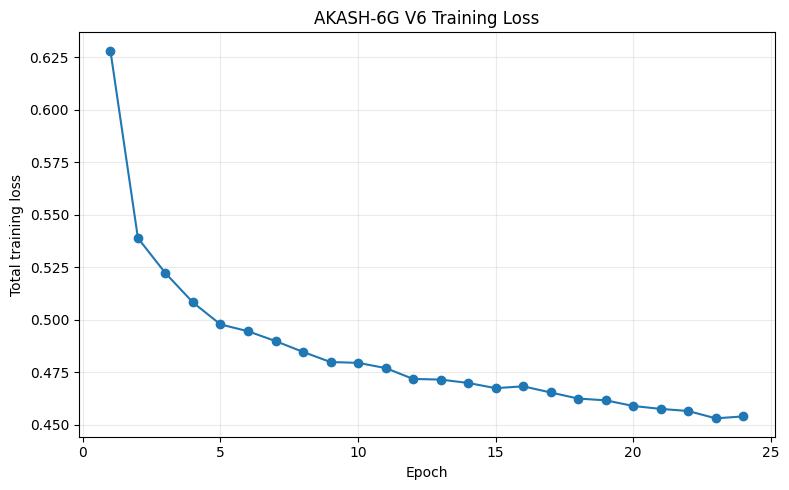

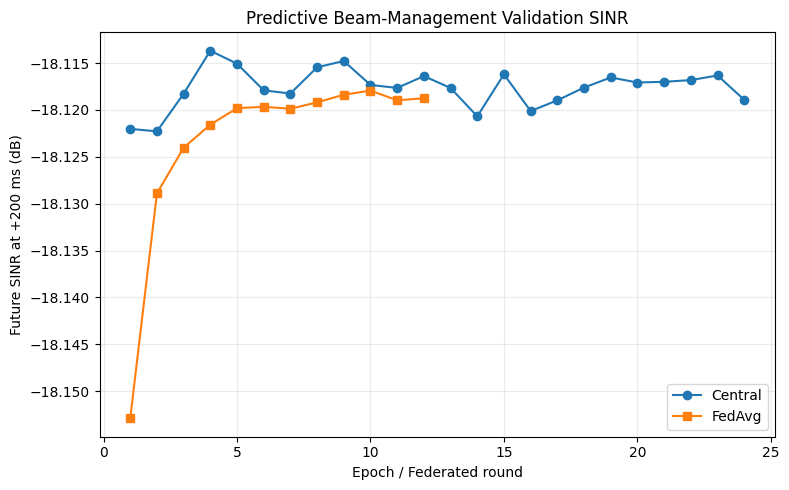

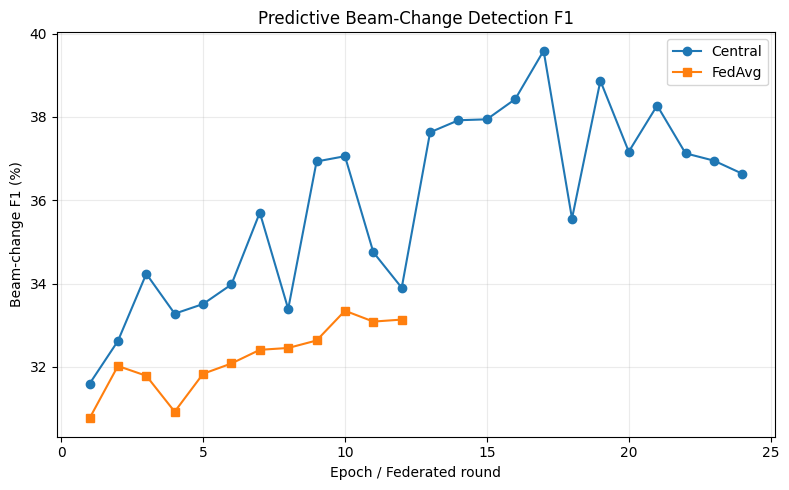

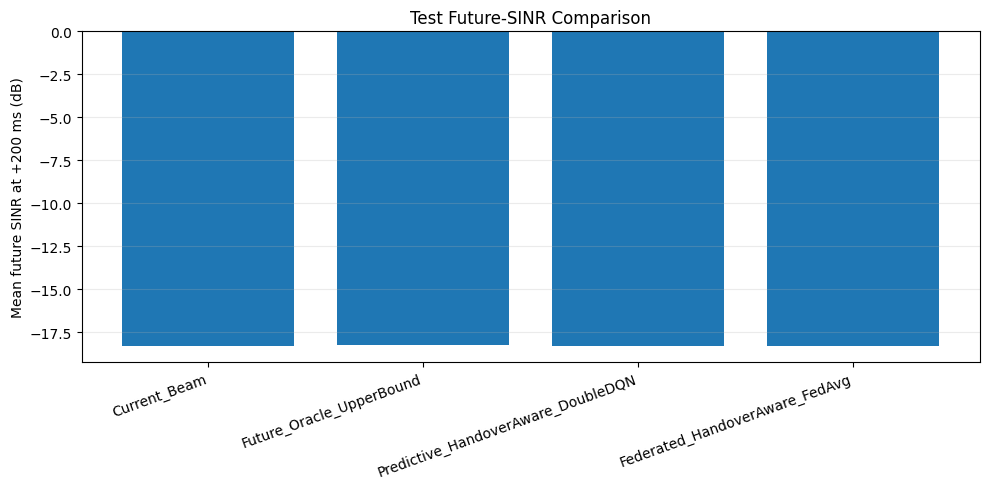

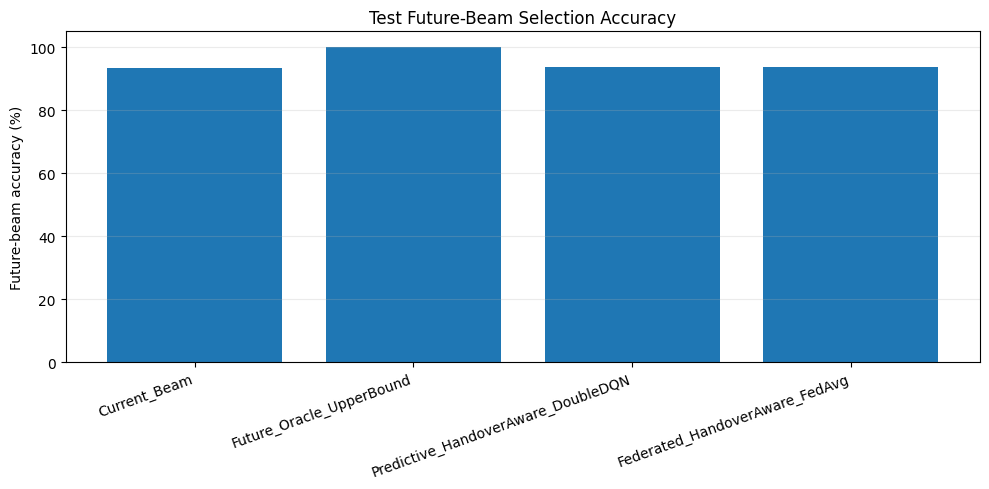

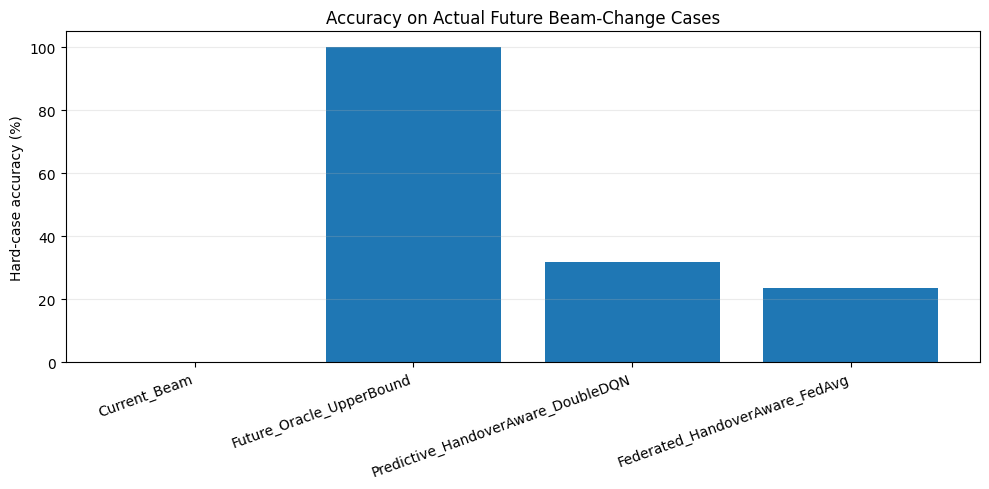

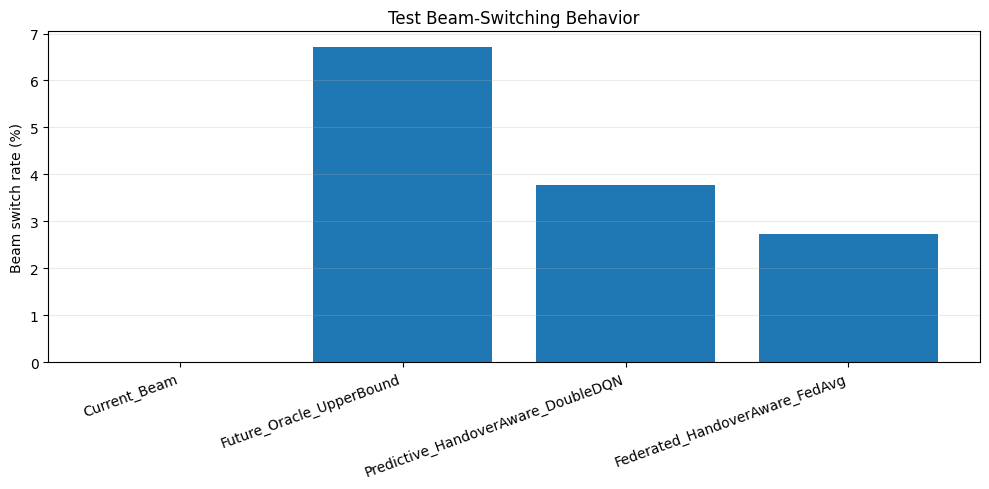

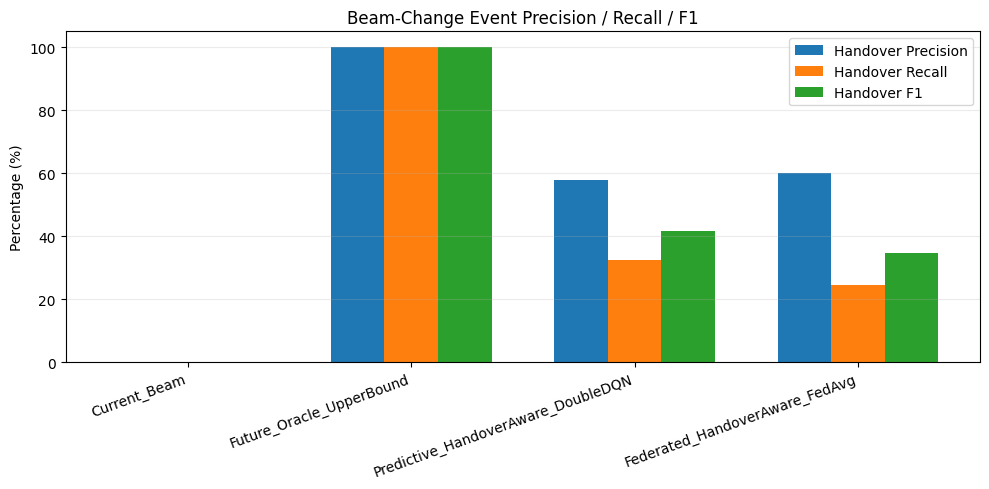

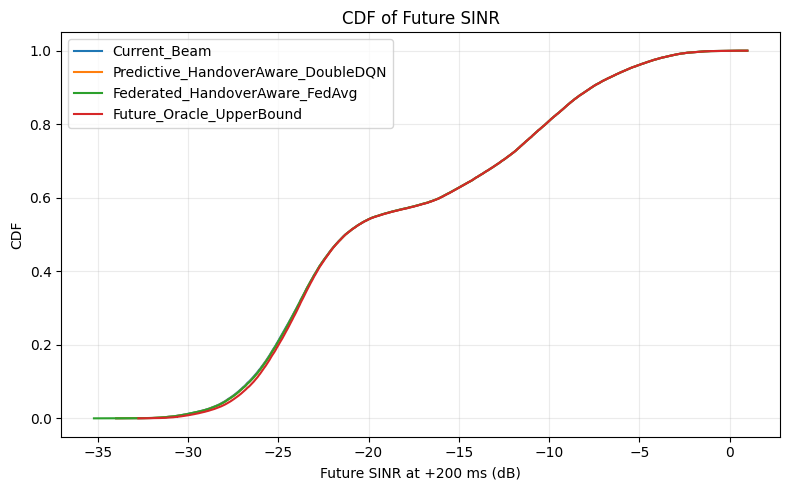

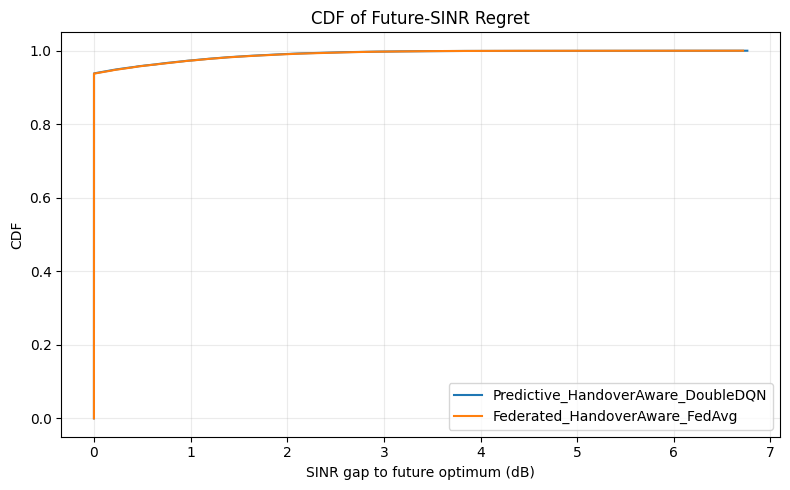

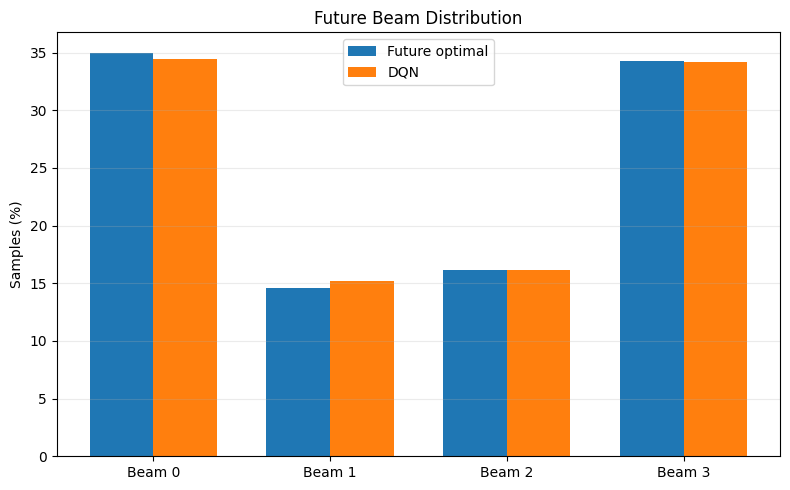

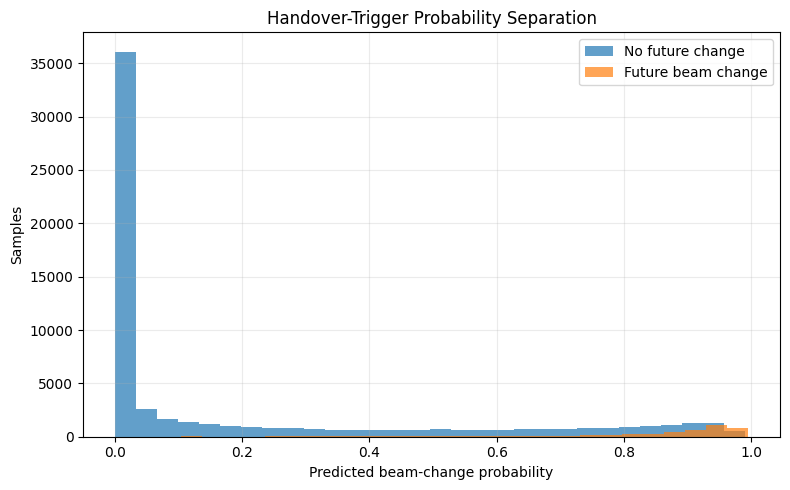

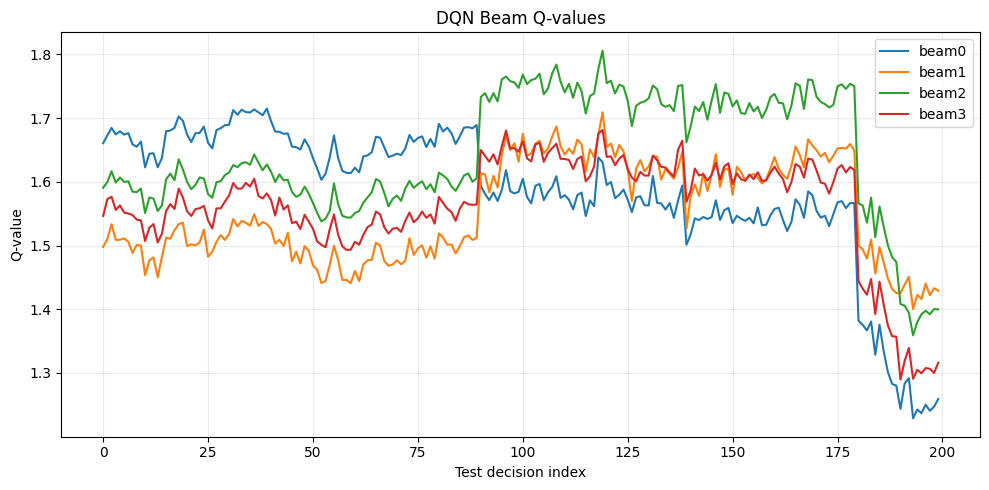


AKASH-6G V6 COMPLETE
Outputs: /content/AKASH6G_V6_RESEARCH_GRADE_RESULTS
Future-beam decision file: PREDICTED_FUTURE_BEAM_DECISIONS_TEST.csv
Total runtime: 18.48 min
No ground-truth future beam was used as an inference feature.
No beam switch was artificially forced.


In [ ]:
from __future__ import annotations

import copy
import json
import math
import os
import random
import time
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

SEED = 42
N_BEAMS = 4
DT_MS = 20
HORIZON_MS = 200
H_STEPS = HORIZON_MS // DT_MS
ROWS_PER_UE = 100
VALID_STATES_PER_UE = ROWS_PER_UE - H_STEPS  # 90
TRANSITIONS_PER_UE = VALID_STATES_PER_UE - 1  # 89

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Network
HIDDEN = 128
DROPOUT = 0.05
STATE_DIM = 70

# Central Double-DQN
GAMMA = 0.95
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 24
BATCH_SIZE_GPU = 1024
BATCH_SIZE_CPU = 256
TARGET_UPDATE_STEPS = 500
GRAD_CLIP = 5.0

# Loss weights
VALUE_LOSS_WEIGHT = 1.0
RANKING_LOSS_WEIGHT = 0.25
HANDOVER_LOSS_WEIGHT = 0.35
OPPORTUNITY_LOSS_WEIGHT = 0.55
FOCAL_GAMMA = 1.5
PAIR_MARGIN = 0.05

# Handover-trigger deployment
TRIGGER_THRESHOLD_MIN = 0.20
TRIGGER_THRESHOLD_MAX = 0.80
TRIGGER_THRESHOLD_STEPS = 25

# Deployment hysteresis: switch only if the predicted beam has enough
# Q-advantage over staying on the current beam.
SWITCH_ADVANTAGE_GRID = (0.0, 0.0025, 0.005, 0.01, 0.02, 0.04)

# Reward: bounded future utility + future gain over staying.
SINR_THRESHOLD_DB = 5.0
SINR_UTILITY_SCALE_DB = 4.0
GAIN_SCALE_DB = 1.5
MEANINGFUL_GAIN_DB = 0.20
GAIN_TRANSITION_DB = 0.15
SWITCH_PENALTY = 0.002
SWITCH_BENEFIT = 0.12
SWITCH_OPPORTUNITY_BONUS = 0.08

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 12
N_CLIENTS = 10
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 2
FED_LR = 3e-4
FED_TARGET_UPDATE_STEPS = 400
CLIENT_MAX_STATES = 35_000

# Bootstrap CIs
BOOTSTRAP_REPS = 400

OUTPUT_DIR = Path(
    os.environ.get(
        "AKASH6G_OUTPUT_DIR",
        "/content/AKASH6G_V6_RESEARCH_GRADE_RESULTS",
    )
)
DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()

DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]
SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path.cwd(),
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = BATCH_SIZE_GPU if DEVICE.type == "cuda" else BATCH_SIZE_CPU


# ============================================================================
# 2. COLUMNS
# ============================================================================

BEAM_RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]
BEAM_SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]

BASE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS

DELTA_COLS = [f"d_{c}" for c in BASE_COLS]
MARGIN_COLS = [f"margin_{c}" for c in BEAM_RSRP_COLS + BEAM_SINR_COLS]

REQUIRED_COLUMNS = [
    "Time_ms",
    "UE_ID",
    "Satellite_ID",
    "Satellite_Altitude_km",
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Prediction_Horizon_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "Beam_Switch",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS


# ============================================================================
# 3. REPRODUCIBILITY / HELPERS
# ============================================================================

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


def log(msg: str = "") -> None:
    print(msg, flush=True)


def save_json(path: Path, obj: object) -> None:
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        if isinstance(v, torch.Tensor):
            return v.detach().cpu().tolist()
        raise TypeError(f"Cannot serialize {type(v)}")

    path.write_text(json.dumps(obj, indent=2, default=convert), encoding="utf-8")


def beam_to_int(x, allow_minus_one: bool = False) -> int:
    if pd.isna(x):
        raise ValueError("Beam label is NaN")
    try:
        if isinstance(x, str):
            s = x.strip().lower()
            if s.startswith("beam"):
                s = s[4:]
            b = int(float(s))
        else:
            b = int(x)
    except Exception as exc:
        raise ValueError(f"Invalid beam label: {x!r}") from exc
    if allow_minus_one and b == -1:
        return -1
    if not 0 <= b < N_BEAMS:
        raise ValueError(f"Beam must be 0..{N_BEAMS-1}, got {b}")
    return b


def convert_beam_column(series: pd.Series, allow_minus_one: bool = False) -> np.ndarray:
    return np.asarray(
        [beam_to_int(v, allow_minus_one=allow_minus_one) for v in series],
        dtype=np.int64,
    )


def beam_name(b: int) -> str:
    return f"beam{int(b)}" if 0 <= int(b) < N_BEAMS else "N/A"


# ============================================================================
# 4. DATASET DISCOVERY
# ============================================================================

def candidate_score(path: Path) -> int:
    name = path.name.lower()
    score = 0
    if "final_corrected" in name:
        score += 100
    if "5000ue" in name:
        score += 50
    if "physical" in name:
        score += 25
    if name.endswith("(2).csv"):
        score += 5
    try:
        score += min(int(path.stat().st_size / 1_000_000), 50)
    except Exception:
        pass
    return score


def is_candidate(path: Path) -> bool:
    if not path.is_file() or path.suffix.lower() != ".csv":
        return False
    name = path.name.lower()
    return "akash6g" in name and any(k in name for k in ("physical", "corrected", "5000ue"))


def resolve_dataset_path() -> Path:
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if not p.is_file():
            raise FileNotFoundError(f"AKASH6G_DATASET_PATH does not exist: {p}")
        return p

    candidates: Dict[str, Path] = {}
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for fname in DATASET_FILENAMES:
            p = root / fname
            if p.is_file():
                candidates[str(p.resolve())] = p
        try:
            for p in root.rglob("*.csv"):
                if is_candidate(p):
                    candidates[str(p.resolve())] = p
        except Exception:
            continue

    if candidates:
        ranked = sorted(candidates.values(), key=candidate_score, reverse=True)
        chosen = ranked[0]
        log(f"Dataset auto-detected: {chosen}")
        if len(ranked) > 1:
            log("Other candidates:")
            for p in ranked[1:6]:
                log(f"  {p}")
        return chosen

    # Colab upload fallback.
    try:
        from google.colab import files as colab_files
        log("No AKASH-6G CSV found. Opening Colab upload dialog...")
        uploaded = colab_files.upload()
        for name in uploaded:
            p = Path("/content") / name
            if p.is_file() and p.suffix.lower() == ".csv":
                return p
    except Exception:
        pass

    raise FileNotFoundError(
        "AKASH-6G physical CSV not found. Upload the corrected CSV or set "
        "AKASH6G_DATASET_PATH."
    )


# ============================================================================
# 5. LOAD + NORMALIZE LABELS
# ============================================================================

def load_dataset() -> Tuple[pd.DataFrame, Path]:
    path = resolve_dataset_path()
    log("=" * 80)
    log("AKASH-6G V6 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG")
    log("=" * 80)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path, low_memory=False)
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError("Missing required columns:\n" + "\n".join(missing))

    for c in BASE_COLS + ["Time_ms", "UE_ID", "Satellite_ID", "Satellite_Altitude_km", "Prediction_Horizon_ms"]:
        df[c] = pd.to_numeric(df[c], errors="raise")

    df["Current_Beam"] = convert_beam_column(df["Current_Beam"])
    df["Optimal_Beam"] = convert_beam_column(df["Optimal_Beam"])
    df["Future_Beam"] = convert_beam_column(df["Future_Beam"], allow_minus_one=True)
    df["Valid_Future_Target"] = pd.to_numeric(df["Valid_Future_Target"], errors="raise").astype(np.int8)
    df["Beam_Switch"] = pd.to_numeric(df["Beam_Switch"], errors="raise").astype(np.int8)

    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)
    log(f"Loaded shape: {df.shape}")
    return df, path


# ============================================================================
# 6. PHYSICS / LINKAGE AUDIT
# ============================================================================

def audit_dataset(df: pd.DataFrame) -> Dict[str, object]:
    log("\n[1/8] STRICT DATASET AUDIT")

    n = len(df)
    unique_ues = int(df["UE_ID"].nunique())
    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    row_counts = df.groupby("UE_ID").size()
    wrong_row_counts = int((row_counts != ROWS_PER_UE).sum())

    max_dt_error = 0.0
    max_current_rsrp_error = 0.0
    max_current_sinr_error = 0.0
    max_range_geometry_error_km = 0.0
    max_delay_error_ms = 0.0
    future_mismatch = 0
    validity_mismatch = 0
    optimal_rsrp_match = 0
    optimal_sinr_match = 0
    ranking_same = 0

    re_km = 6371.0
    h_km = 600.0
    c_km_s = 299792.458

    for ue, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        t = g["Time_ms"].to_numpy(float)
        if len(t) > 1:
            max_dt_error = max(max_dt_error, float(np.max(np.abs(np.diff(t) - DT_MS))))

        current = g["Current_Beam"].to_numpy(int)
        optimal = g["Optimal_Beam"].to_numpy(int)
        future = g["Future_Beam"].to_numpy(int)
        valid = g["Valid_Future_Target"].to_numpy(int)
        rsrp = g[BEAM_RSRP_COLS].to_numpy(float)
        sinr = g[BEAM_SINR_COLS].to_numpy(float)

        expected_current_rsrp = rsrp[np.arange(len(g)), current]
        expected_current_sinr = sinr[np.arange(len(g)), current]
        max_current_rsrp_error = max(
            max_current_rsrp_error,
            float(np.max(np.abs(g["Current_RSRP_dBm"].to_numpy(float) - expected_current_rsrp))),
        )
        max_current_sinr_error = max(
            max_current_sinr_error,
            float(np.max(np.abs(g["Current_SINR_dB"].to_numpy(float) - expected_current_sinr))),
        )

        rs_arg = rsrp.argmax(axis=1)
        si_arg = sinr.argmax(axis=1)
        optimal_rsrp_match += int(np.sum(optimal == rs_arg))
        optimal_sinr_match += int(np.sum(optimal == si_arg))
        ranking_same += int(np.sum(rs_arg == si_arg))

        # Exact +200 ms target check for valid rows.
        for i in range(VALID_STATES_PER_UE):
            if future[i] != optimal[i + H_STEPS]:
                future_mismatch += 1
            if valid[i] != 1:
                validity_mismatch += 1
        for i in range(VALID_STATES_PER_UE, ROWS_PER_UE):
            if valid[i] != 0 or future[i] != -1:
                validity_mismatch += 1

        # Geometry check using standard spherical slant-range relation.
        elev = np.deg2rad(g["Elevation_Angle_deg"].to_numpy(float))
        expected_d = -re_km * np.sin(elev) + np.sqrt(
            (re_km + h_km) ** 2 - (re_km * np.cos(elev)) ** 2
        )
        max_range_geometry_error_km = max(
            max_range_geometry_error_km,
            float(np.max(np.abs(g["Slant_Range_km"].to_numpy(float) - expected_d))),
        )
        expected_delay_ms = g["Slant_Range_km"].to_numpy(float) / c_km_s * 1000.0
        max_delay_error_ms = max(
            max_delay_error_ms,
            float(np.max(np.abs(g["Propagation_Delay_ms"].to_numpy(float) - expected_delay_ms))),
        )

    valid_rows = int(df["Valid_Future_Target"].sum())
    total = max(n, 1)
    audit = {
        "rows": n,
        "columns": int(df.shape[1]),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "wrong_ue_row_counts": wrong_row_counts,
        "max_time_step_error_ms": max_dt_error,
        "max_current_rsrp_linkage_error_db": max_current_rsrp_error,
        "max_current_sinr_linkage_error_db": max_current_sinr_error,
        "future_mismatches": future_mismatch,
        "future_validity_mismatches": validity_mismatch,
        "valid_predictive_rows": valid_rows,
        "optimal_vs_rsrp_pct": 100.0 * optimal_rsrp_match / total,
        "optimal_vs_sinr_pct": 100.0 * optimal_sinr_match / total,
        "rsrp_sinr_ranking_same_pct": 100.0 * ranking_same / total,
        "max_range_geometry_error_km": max_range_geometry_error_km,
        "max_propagation_delay_error_ms": max_delay_error_ms,
        "altitude_min_km": float(df["Satellite_Altitude_km"].min()),
        "altitude_max_km": float(df["Satellite_Altitude_km"].max()),
        "doppler_min_khz": float(df["Doppler_kHz"].min()),
        "doppler_max_khz": float(df["Doppler_kHz"].max()),
        "doppler_rate_min_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].min()),
        "doppler_rate_max_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].max()),
        "elevation_min_deg": float(df["Elevation_Angle_deg"].min()),
        "elevation_max_deg": float(df["Elevation_Angle_deg"].max()),
        "slant_range_min_km": float(df["Slant_Range_km"].min()),
        "slant_range_max_km": float(df["Slant_Range_km"].max()),
    }

    for k, v in audit.items():
        if isinstance(v, float):
            log(f"{k:38s}: {v:.9g}")
        else:
            log(f"{k:38s}: {v}")

    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("WARNING: RSRP and SINR rankings are nearly identical; this is a simulator limitation.")

    hard_fail = (
        n != 500_000
        or unique_ues != 5_000
        or missing != 0
        or duplicates != 0
        or wrong_row_counts != 0
        or max_dt_error > 1e-6
        or max_current_rsrp_error > 1e-3
        or max_current_sinr_error > 1e-3
        or future_mismatch != 0
        or validity_mismatch != 0
        or max_range_geometry_error_km > 1e-3
        or max_delay_error_ms > 1e-6
    )
    if hard_fail:
        raise ValueError("STRICT DATASET AUDIT FAILED. Training was stopped.")

    log("STRICT DATASET AUDIT: PASS")
    return audit


# ============================================================================
# 7. UE SPLIT
# ============================================================================

def split_ues(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    ues = np.sort(df["UE_ID"].unique().astype(int))
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)
    n = len(ues)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))
    train = np.sort(ues[:n_train])
    val = np.sort(ues[n_train:n_train + n_val])
    test = np.sort(ues[n_train + n_val:])
    if len(set(train) & set(val)) or len(set(train) & set(test)) or len(set(val) & set(test)):
        raise RuntimeError("UE split overlap detected.")
    log(f"UE split: train={len(train)}, val={len(val)}, test={len(test)}")
    return train, val, test


# ============================================================================
# 8. STATE CONSTRUCTION — 55 FEATURES
# ============================================================================

def build_states(
    df: pd.DataFrame,
    train_ues: np.ndarray,
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    log("\n[2/8] BUILDING LEAKAGE-SAFE TEMPORAL STATES")
    n = len(df)
    base = df[BASE_COLS].to_numpy(np.float32)
    current = df["Current_Beam"].to_numpy(np.int64)

    deltas = np.zeros_like(base, dtype=np.float32)
    second_deltas = np.zeros_like(base, dtype=np.float32)
    margins = np.zeros((n, 8), dtype=np.float32)
    history = np.zeros((n, 12), dtype=np.float32)
    dwell = np.zeros(n, dtype=np.float32)

    # Because df is sorted by UE/time, global contiguous slices are safe.
    for _, g in df.groupby("UE_ID", sort=False):
        idx = g.index.to_numpy()
        b = g["Current_Beam"].to_numpy(np.int64)
        bbase = base[idx]
        if len(idx) > 1:
            deltas[idx[1:]] = bbase[1:] - bbase[:-1]
        if len(idx) > 2:
            second_deltas[idx[2:]] = bbase[2:] - 2.0 * bbase[1:-1] + bbase[:-2]
        for j, ridx in enumerate(idx):
            for h in range(3):
                src = max(0, j - h)
                history[ridx, h * N_BEAMS + b[src]] = 1.0
            k = j
            while k > 0 and b[k - 1] == b[j]:
                k -= 1
            dwell[ridx] = j - k

    rsrp = df[BEAM_RSRP_COLS].to_numpy(np.float32)
    sinr = df[BEAM_SINR_COLS].to_numpy(np.float32)
    cur_rsrp = df["Current_RSRP_dBm"].to_numpy(np.float32)[:, None]
    cur_sinr = df["Current_SINR_dB"].to_numpy(np.float32)[:, None]
    margins[:, :4] = rsrp - cur_rsrp
    margins[:, 4:] = sinr - cur_sinr

    continuous = np.concatenate([base, deltas, second_deltas, margins, dwell[:, None]], axis=1)
    if continuous.shape[1] != 54:
        raise RuntimeError(f"Expected 54 continuous features, got {continuous.shape[1]}")

    train_mask = df["UE_ID"].isin(set(train_ues.tolist())).to_numpy()
    train_values = continuous[train_mask]
    mean = train_values.mean(axis=0).astype(np.float32)
    std = train_values.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0
    norm = ((continuous - mean) / std).astype(np.float32)

    onehot = np.zeros((n, N_BEAMS), np.float32)
    onehot[np.arange(n), current] = 1.0
    state = np.concatenate([norm, onehot, history], axis=1).astype(np.float32)
    if state.shape[1] != STATE_DIM:
        raise RuntimeError(f"State dimension mismatch: {state.shape[1]} != {STATE_DIM}")

    log(f"State dimension: {STATE_DIM} = 54 continuous (15 base + 15 first-difference + 15 second-difference + 8 margins + 1 dwell) + 4 current-beam one-hot + 12 beam-history one-hot")
    return df, state, mean, std


# ============================================================================
# 9. STATE-LEVEL COUNTERFACTUAL DATASET
# ============================================================================

def build_decision_dataset(
    df: pd.DataFrame,
    state: np.ndarray,
    ue_ids: np.ndarray,
    max_states: Optional[int] = None,
) -> Dict[str, np.ndarray]:
    """Return one row per valid decision state, not four duplicated rows.

    The implementation is deliberately vectorized per UE.  Earlier versions
    repeatedly used pandas iloc inside the inner time loop, which made the
    315k-state construction unnecessarily slow in Colab.
    """
    ue_set = set(int(x) for x in ue_ids)
    row_parts: List[np.ndarray] = []
    next_parts: List[np.ndarray] = []
    fs_parts: List[np.ndarray] = []
    cur_parts: List[np.ndarray] = []
    opt_parts: List[np.ndarray] = []
    ue_parts: List[np.ndarray] = []
    time_parts: List[np.ndarray] = []
    elevation_parts: List[np.ndarray] = []
    doppler_parts: List[np.ndarray] = []
    doppler_rate_parts: List[np.ndarray] = []
    edge_margin_parts: List[np.ndarray] = []

    for ue, g in df[df["UE_ID"].isin(ue_set)].groupby("UE_ID", sort=True):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            raise RuntimeError(f"UE {ue} has {len(g)} rows; expected {ROWS_PER_UE}")

        ridx = g.index.to_numpy(np.int64)
        # 90 valid decision times: t = 0..89.
        row_parts.append(ridx[:VALID_STATES_PER_UE])
        # The final decision at t=1780 ms uses row 90 (1800 ms) as its
        # one-step next state; row 90 itself does not need a future target.
        next_parts.append(ridx[1:VALID_STATES_PER_UE + 1])

        sinr = g[BEAM_SINR_COLS].to_numpy(np.float32)
        fs_parts.append(sinr[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        cur_parts.append(g["Current_Beam"].to_numpy(np.int64)[:VALID_STATES_PER_UE])
        opt_parts.append(g["Optimal_Beam"].to_numpy(np.int64)[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        ue_parts.append(np.full(VALID_STATES_PER_UE, int(ue), dtype=np.int64))
        time_parts.append(g["Time_ms"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        elevation_parts.append(g["Elevation_Angle_deg"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        doppler_parts.append(g["Doppler_kHz"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        doppler_rate_parts.append(g["Doppler_Rate_kHz_per_ms"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        cur_rsrp = g["Current_RSRP_dBm"].to_numpy(np.float32)[:VALID_STATES_PER_UE]
        all_rsrp = g[BEAM_RSRP_COLS].to_numpy(np.float32)[:VALID_STATES_PER_UE]
        top2 = np.partition(all_rsrp, -2, axis=1)[:, -2]
        edge_margin_parts.append(all_rsrp.max(axis=1) - top2)

    rows = np.concatenate(row_parts)
    next_rows = np.concatenate(next_parts)
    FS = np.concatenate(fs_parts, axis=0)
    CB = np.concatenate(cur_parts)
    FO = np.concatenate(opt_parts)
    UE = np.concatenate(ue_parts)
    TM = np.concatenate(time_parts)

    X = state[rows]
    NX = state[next_rows]

    if max_states is not None and len(X) > max_states:
        rng = np.random.default_rng(SEED + int(len(ue_ids)) + 17)
        idx = rng.choice(len(X), size=int(max_states), replace=False)
        idx.sort()
        X, NX, FS, CB, FO, UE, TM = [a[idx] for a in (X, NX, FS, CB, FO, UE, TM)]

    return {
        "states": X.astype(np.float32, copy=False),
        "next_states": NX.astype(np.float32, copy=False),
        "future_sinr": FS.astype(np.float32, copy=False),
        "current_beam": CB.astype(np.int64, copy=False),
        "future_optimal": FO.astype(np.int64, copy=False),
        "UE_ID": UE.astype(np.int64, copy=False),
        "Time_ms": TM.astype(np.float32, copy=False),
        "Elevation_Angle_deg": np.concatenate(elevation_parts).astype(np.float32, copy=False),
        "Doppler_kHz": np.concatenate(doppler_parts).astype(np.float32, copy=False),
        "Doppler_Rate_kHz_per_ms": np.concatenate(doppler_rate_parts).astype(np.float32, copy=False),
        "BeamEdge_Margin_dB": np.concatenate(edge_margin_parts).astype(np.float32, copy=False),
    }


# ============================================================================
# 10. PHYSICS-BACKED REWARD
# ============================================================================

def counterfactual_reward(future_sinr: np.ndarray, current_beam: np.ndarray) -> np.ndarray:
    """Counterfactual physical utility for all four actions at t+200 ms.

    The future beam label is not used.  The reward is based only on the four
    future SINRs and the current beam.  A smooth opportunity bonus encourages
    switching when the future SINR advantage is meaningful, while a small cost
    discourages gratuitous changes.
    """
    sinr = np.asarray(future_sinr, np.float32)
    current = np.asarray(current_beam, np.int64)
    z = np.clip((sinr - SINR_THRESHOLD_DB) / SINR_UTILITY_SCALE_DB, -30.0, 30.0)
    absolute = 1.0 / (1.0 + np.exp(-z))
    rows = np.arange(len(sinr))
    stay_sinr = sinr[rows, current]
    gain = sinr - stay_sinr[:, None]
    gain_term = np.tanh(gain / GAIN_SCALE_DB)
    opportunity_z = np.clip((gain - MEANINGFUL_GAIN_DB) / GAIN_TRANSITION_DB, -30.0, 30.0)
    opportunity = 1.0 / (1.0 + np.exp(-opportunity_z))
    switches = (np.arange(N_BEAMS)[None, :] != current[:, None]).astype(np.float32)
    reward = (absolute + SWITCH_BENEFIT * gain_term
              + SWITCH_OPPORTUNITY_BONUS * opportunity * switches
              - SWITCH_PENALTY * switches)
    reward -= reward.mean(axis=1, keepdims=True)
    return reward.astype(np.float32)


# ============================================================================
# 11. MODEL
# ============================================================================

class HandoverAwareDuelingDoubleDQN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(STATE_DIM, HIDDEN),
            nn.LayerNorm(HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, N_BEAMS),
        )
        self.handover_head = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.opportunity_head = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.trunk(x)
        v = self.value(h)
        a = self.advantage(h)
        q = v + a - a.mean(dim=1, keepdim=True)
        handover_logit = self.handover_head(h).squeeze(1)
        opportunity_logit = self.opportunity_head(h).squeeze(1)
        return q, handover_logit, opportunity_logit


def clone_model(model: nn.Module) -> nn.Module:
    out = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    out.load_state_dict(model.state_dict())
    return out


# ============================================================================
# 12. TRAINING TENSOR HELPERS
# ============================================================================

def to_tensor(a: np.ndarray, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    return torch.from_numpy(np.asarray(a)).to(device=DEVICE, dtype=dtype)


def compute_handover_labels(current: np.ndarray, future_opt: np.ndarray) -> np.ndarray:
    return (current != future_opt).astype(np.float32)


def batch_indices(n: int, batch_size: int, rng: np.random.Generator) -> Iterable[np.ndarray]:
    order = rng.permutation(n)
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


# ============================================================================
# 13. ONE OPTIMIZATION STEP
# ============================================================================

def ranking_loss(q: torch.Tensor, rewards: torch.Tensor) -> torch.Tensor:
    """Pairwise hinge loss: actions with higher physical reward should have higher Q."""
    # Six unordered pairs for four beams.
    loss_terms = []
    for i in range(N_BEAMS):
        for j in range(i + 1, N_BEAMS):
            better_i = rewards[:, i] > rewards[:, j]
            better_j = rewards[:, j] > rewards[:, i]
            if better_i.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_i, i] - q[better_i, j])).mean())
            if better_j.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_j, j] - q[better_j, i])).mean())
    if not loss_terms:
        return q.sum() * 0.0
    return torch.stack(loss_terms).mean()


def train_batch(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    optimizer: optim.Optimizer,
    xb: torch.Tensor,
    nxb: torch.Tensor,
    reward_b: torch.Tensor,
    ho_b: torch.Tensor,
    opportunity_b: torch.Tensor,
) -> Dict[str, float]:
    model.train()
    q, ho_logit, opportunity_logit = model(xb)

    with torch.no_grad():
        # Double-DQN: online network selects next action; target evaluates it.
        next_q_online, _, _ = model(nxb)
        next_actions = next_q_online.argmax(dim=1)
        next_q_target, _, _ = target(nxb)
        next_best = next_q_target.gather(1, next_actions[:, None]).squeeze(1)
        # Same continuation value is applied to all counterfactual actions of this state.
        y = reward_b + GAMMA * next_best[:, None]

    value_loss = F.smooth_l1_loss(q, y)
    rank = ranking_loss(q, reward_b)

    pos = float(ho_b.sum().item())
    neg = float(len(ho_b) - pos)
    pos_weight = torch.tensor([neg / max(pos, 1.0)], device=DEVICE)
    ho_loss = F.binary_cross_entropy_with_logits(ho_logit, ho_b, pos_weight=pos_weight)
    # Meaningful opportunity label is computed from the physical future-SINR gain
    # and is never available to the deployment policy.
    pos2 = float(opportunity_b.sum().item())
    neg2 = float(len(opportunity_b) - pos2)
    pos_weight2 = torch.tensor([neg2 / max(pos2, 1.0)], device=DEVICE)
    opportunity_loss = F.binary_cross_entropy_with_logits(opportunity_logit, opportunity_b, pos_weight=pos_weight2)

    loss = (VALUE_LOSS_WEIGHT * value_loss + RANKING_LOSS_WEIGHT * rank
            + HANDOVER_LOSS_WEIGHT * ho_loss + OPPORTUNITY_LOSS_WEIGHT * opportunity_loss)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    return {
        "loss": float(loss.item()),
        "value_loss": float(value_loss.item()),
        "rank_loss": float(rank.item()),
        "handover_loss": float(ho_loss.item()),
        "opportunity_loss": float(opportunity_loss.item()),
    }


# ============================================================================
# 14. PREDICTION
# ============================================================================

@torch.no_grad()
def predict_model(
    model: HandoverAwareDuelingDoubleDQN,
    X: np.ndarray,
    batch_size: int = 8192,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    q_out: List[np.ndarray] = []
    p_out: List[np.ndarray] = []
    o_out: List[np.ndarray] = []
    for start in range(0, len(X), batch_size):
        xb = to_tensor(X[start:start + batch_size])
        q, logit, opportunity_logit = model(xb)
        q_out.append(q.cpu().numpy())
        p_out.append(torch.sigmoid(logit).cpu().numpy())
        o_out.append(torch.sigmoid(opportunity_logit).cpu().numpy())
    return np.concatenate(q_out), np.concatenate(p_out), np.concatenate(o_out)


def choose_actions(
    q: np.ndarray,
    opportunity_probability: np.ndarray,
    current: np.ndarray,
    trigger_threshold: float,
    switch_advantage: float,
) -> np.ndarray:
    best = q.argmax(axis=1).astype(np.int64)
    actions = current.astype(np.int64).copy()
    rows = np.arange(len(q))
    advantage = q[rows, best] - q[rows, current]
    switch = (
        (best != current)
        & (opportunity_probability >= trigger_threshold)
        & (advantage >= switch_advantage)
    )
    actions[switch] = best[switch]
    return actions


# ============================================================================
# 15. EVALUATION
# ============================================================================

def evaluate_predictions(
    actions: np.ndarray,
    q: np.ndarray,
    p: np.ndarray,
    opportunity_p: np.ndarray,
    data: Dict[str, np.ndarray],
    trigger_threshold: float,
    switch_advantage: float,
) -> Dict[str, object]:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    future_sinr = data["future_sinr"]
    rows = np.arange(len(actions))
    chosen_sinr = future_sinr[rows, actions]
    optimal_sinr = future_sinr.max(axis=1)

    actual_event = current != optimal
    rows2 = np.arange(len(future_sinr))
    stay_future = future_sinr[rows2, current]
    future_gain = optimal_sinr - stay_future
    meaningful_event = actual_event & (future_gain >= MEANINGFUL_GAIN_DB)
    predicted_event = actions != current
    tp = int(np.sum(actual_event & predicted_event))
    fp = int(np.sum(~actual_event & predicted_event))
    fn = int(np.sum(actual_event & ~predicted_event))
    tn = int(np.sum(~actual_event & ~predicted_event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    hard = actual_event
    hard_acc = float(np.mean(actions[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan")
    accuracy = float(np.mean(actions == optimal) * 100.0)
    switch_rate = float(np.mean(actions != current) * 100.0)
    future_mean = float(chosen_sinr.mean())
    opt_mean = float(optimal_sinr.mean())
    gap = opt_mean - future_mean

    # Event-trigger metrics independent of the beam hysteresis decision.
    trigger_pred = opportunity_p >= trigger_threshold
    ttp = int(np.sum(actual_event & trigger_pred))
    tfp = int(np.sum(~actual_event & trigger_pred))
    tfn = int(np.sum(actual_event & ~trigger_pred))
    trigger_precision = ttp / max(ttp + tfp, 1)
    trigger_recall = ttp / max(ttp + tfn, 1)
    trigger_f1 = 2 * trigger_precision * trigger_recall / max(trigger_precision + trigger_recall, 1e-12)

    meaningful_pred = actions != current
    mtp = int(np.sum(meaningful_event & meaningful_pred))
    mfp = int(np.sum(~meaningful_event & meaningful_pred))
    mfn = int(np.sum(meaningful_event & ~meaningful_pred))
    mprec = mtp / max(mtp + mfp, 1)
    mrec = mtp / max(mtp + mfn, 1)
    mf1 = 2 * mprec * mrec / max(mprec + mrec, 1e-12)

    reward_matrix = counterfactual_reward(future_sinr, current)
    chosen_reward = reward_matrix[rows, actions]

    return {
        "future_sinr_db": future_mean,
        "optimal_future_sinr_db": opt_mean,
        "sinr_gap_db": gap,
        "beam_accuracy_pct": accuracy,
        "hard_case_accuracy_pct": hard_acc,
        "hard_cases": int(hard.sum()),
        "switch_rate_pct": switch_rate,
        "correct_handover": int(np.sum(actual_event & (actions == optimal))),
        "missed_handover": int(np.sum(actual_event & (actions == current))),
        "unnecessary_handover": int(np.sum((~actual_event) & (actions != current))),
        "handover_precision_pct": precision * 100.0,
        "handover_recall_pct": recall * 100.0,
        "handover_f1_pct": f1 * 100.0,
        "trigger_precision_pct": trigger_precision * 100.0,
        "trigger_recall_pct": trigger_recall * 100.0,
        "trigger_f1_pct": trigger_f1 * 100.0,
        "meaningful_handover_precision_pct": mprec * 100.0,
        "meaningful_handover_recall_pct": mrec * 100.0,
        "meaningful_handover_f1_pct": mf1 * 100.0,
        "meaningful_event_count": int(meaningful_event.sum()),
        "mean_reward": float(chosen_reward.mean()),
        "trigger_threshold": float(trigger_threshold),
        "switch_advantage": float(switch_advantage),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "actions": actions,
        "q_values": q,
        "handover_probability": p,
        "opportunity_probability": opportunity_p,
    }


# ============================================================================
# 16. VALIDATION THRESHOLD SELECTION
# ============================================================================

def select_deployment_policy(
    model: HandoverAwareDuelingDoubleDQN,
    val_data: Dict[str, np.ndarray],
) -> Tuple[float, float, Dict[str, float]]:
    """Select trigger threshold and Q-advantage using validation only."""
    q, p, o = predict_model(model, val_data["states"])
    best_t = 0.5
    best_adv = 0.01
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)
    best_metrics: Dict[str, float] = {}
    for t in np.linspace(TRIGGER_THRESHOLD_MIN, TRIGGER_THRESHOLD_MAX, TRIGGER_THRESHOLD_STEPS):
        for adv in SWITCH_ADVANTAGE_GRID:
            actions = choose_actions(q, o, val_data["current_beam"], float(t), float(adv))
            m = evaluate_predictions(actions, q, p, o, val_data, float(t), float(adv))
            score = (
                m["meaningful_handover_f1_pct"],
                m["handover_f1_pct"],
                m["future_sinr_db"],
                m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
                -m["sinr_gap_db"],
            )
            if score > best_score:
                best_score = score
                best_t = float(t)
                best_adv = float(adv)
                best_metrics = {
                    "handover_f1_pct": float(m["handover_f1_pct"]),
                    "future_sinr_db": float(m["future_sinr_db"]),
                    "hard_case_accuracy_pct": float(m["hard_case_accuracy_pct"]),
                    "switch_rate_pct": float(m["switch_rate_pct"]),
                }
    return best_t, best_adv, best_metrics


# ============================================================================
# 17. CENTRAL TRAINING
# ============================================================================

def train_central(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float]:
    log("\n[4/8] CENTRAL HANDOVER-AWARE DOUBLE-DQN TRAINING")
    model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    target = clone_model(model)
    target.eval()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    rng = np.random.default_rng(SEED + 100)
    reward = counterfactual_reward(train_data["future_sinr"], train_data["current_beam"])
    ho = compute_handover_labels(train_data["current_beam"], train_data["future_optimal"])
    rows = np.arange(len(train_data["future_sinr"]))
    stay = train_data["future_sinr"][rows, train_data["current_beam"]]
    best = train_data["future_sinr"].max(axis=1)
    opportunity = (best - stay >= MEANINGFUL_GAIN_DB).astype(np.float32)

    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)
    history = []
    global_step = 0
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        metrics_accum = []
        for idx in batch_indices(len(train_data["states"]), BATCH_SIZE, rng):
            xb = to_tensor(train_data["states"][idx])
            nxb = to_tensor(train_data["next_states"][idx])
            rb = to_tensor(reward[idx])
            hb = to_tensor(ho[idx])
            metrics_accum.append(train_batch(model, target, optimizer, xb, nxb, rb, hb, to_tensor(opportunity[idx])))
            global_step += 1
            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        val_q, val_p, val_o = predict_model(model, val_data["states"])
        threshold, switch_adv, _ = select_deployment_policy(model, val_data)
        val_actions = choose_actions(val_q, val_o, val_data["current_beam"], threshold, switch_adv)
        vm = evaluate_predictions(val_actions, val_q, val_p, val_o, val_data, threshold, switch_adv)

        row = {
            "epoch": epoch,
            "loss": float(np.mean([x["loss"] for x in metrics_accum])),
            "value_loss": float(np.mean([x["value_loss"] for x in metrics_accum])),
            "rank_loss": float(np.mean([x["rank_loss"] for x in metrics_accum])),
            "handover_loss": float(np.mean([x["handover_loss"] for x in metrics_accum])),
            "opportunity_loss": float(np.mean([x["opportunity_loss"] for x in metrics_accum])),
            "val_future_sinr_db": vm["future_sinr_db"],
            "val_sinr_gap_db": vm["sinr_gap_db"],
            "val_accuracy_pct": vm["beam_accuracy_pct"],
            "val_hard_accuracy_pct": vm["hard_case_accuracy_pct"],
            "val_switch_rate_pct": vm["switch_rate_pct"],
            "val_handover_precision_pct": vm["handover_precision_pct"],
            "val_handover_recall_pct": vm["handover_recall_pct"],
            "val_handover_f1_pct": vm["handover_f1_pct"],
            "val_trigger_f1_pct": vm["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"Epoch {epoch:02d}/{EPOCHS} | Loss {row['loss']:.5f} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} | Gap {row['val_sinr_gap_db']:.4f} | "
            f"Acc {row['val_accuracy_pct']:.2f}% | Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"HO-F1 {row['val_handover_f1_pct']:.2f}% | Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Thr {threshold:.2f}"
        )

        score = (
            vm["meaningful_handover_f1_pct"],
            vm["handover_f1_pct"],
            vm["hard_case_accuracy_pct"] if np.isfinite(vm["hard_case_accuracy_pct"]) else -np.inf,
            vm["future_sinr_db"],
            -vm["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())

    if best_state is None:
        raise RuntimeError("Central training produced no checkpoint.")
    model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(model, val_data)
    log(f"Central training time: {(time.time() - start) / 60.0:.2f} min")
    return model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 18. FEDAVG
# ============================================================================

def weighted_average_state_dicts(
    states: Sequence[Dict[str, torch.Tensor]],
    weights: Sequence[float],
) -> Dict[str, torch.Tensor]:
    if not states:
        raise ValueError("No client models to average.")
    total = float(sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")
    out: Dict[str, torch.Tensor] = {}
    for key in states[0]:
        first = states[0][key]
        if not torch.is_floating_point(first):
            # LayerNorm/batch-free model has no integer buffers, but keep this safe.
            out[key] = first.clone()
            continue
        acc = torch.zeros_like(first, dtype=torch.float32)
        for sd, w in zip(states, weights):
            acc += sd[key].float() * (float(w) / total)
        out[key] = acc.to(dtype=first.dtype)
    return out


def local_train(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    data: Dict[str, np.ndarray],
    epochs: int,
    lr: float,
    rng: np.random.Generator,
) -> None:
    reward = counterfactual_reward(data["future_sinr"], data["current_beam"])
    ho = compute_handover_labels(data["current_beam"], data["future_optimal"])
    rows = np.arange(len(data["future_sinr"]))
    stay = data["future_sinr"][rows, data["current_beam"]]
    best = data["future_sinr"].max(axis=1)
    opportunity = (best - stay >= MEANINGFUL_GAIN_DB).astype(np.float32)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    steps = 0
    for _ in range(epochs):
        for idx in batch_indices(len(data["states"]), BATCH_SIZE, rng):
            metrics = train_batch(
                model,
                target,
                optimizer,
                to_tensor(data["states"][idx]),
                to_tensor(data["next_states"][idx]),
                to_tensor(reward[idx]),
                to_tensor(ho[idx]),
                to_tensor(opportunity[idx]),
            )
            steps += 1
            if steps % FED_TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())


def federated_train(
    client_data: Sequence[Dict[str, np.ndarray]],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float]:
    log("\n[6/8] INDEPENDENT FEDAVG TRAINING")
    global_model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    rng = np.random.default_rng(SEED + 2000)
    history = []
    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= len(client_data):
            selected = np.arange(len(client_data))
        else:
            selected = rng.choice(len(client_data), size=CLIENTS_PER_ROUND, replace=False)

        local_states = []
        weights = []
        for cid in selected:
            local = clone_model(global_model)
            target = clone_model(local)
            target.eval()
            local_train(local, target, client_data[int(cid)], LOCAL_EPOCHS, FED_LR, rng)
            local_states.append({k: v.detach().cpu().clone() for k, v in local.state_dict().items()})
            weights.append(float(len(client_data[int(cid)]["states"])))
            del local, target

        averaged = weighted_average_state_dicts(local_states, weights)
        global_model.load_state_dict(averaged)

        threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
        q, p, o = predict_model(global_model, val_data["states"])
        actions = choose_actions(q, o, val_data["current_beam"], threshold, switch_adv)
        m = evaluate_predictions(actions, q, p, o, val_data, threshold, switch_adv)
        row = {
            "round": rnd,
            "val_future_sinr_db": m["future_sinr_db"],
            "val_sinr_gap_db": m["sinr_gap_db"],
            "val_accuracy_pct": m["beam_accuracy_pct"],
            "val_hard_accuracy_pct": m["hard_case_accuracy_pct"],
            "val_switch_rate_pct": m["switch_rate_pct"],
            "val_handover_precision_pct": m["handover_precision_pct"],
            "val_handover_recall_pct": m["handover_recall_pct"],
            "val_handover_f1_pct": m["handover_f1_pct"],
            "val_trigger_f1_pct": m["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | ValSINR {row['val_future_sinr_db']:.4f} | "
            f"Gap {row['val_sinr_gap_db']:.4f} | Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | HO-F1 {row['val_handover_f1_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        score = (
            m["handover_f1_pct"],
            m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
            m["future_sinr_db"],
            -m["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(global_model.state_dict())

    if best_state is None:
        raise RuntimeError("FedAvg training produced no checkpoint.")
    global_model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
    return global_model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 19. USE-CASE / SCENARIO EVALUATION
# ============================================================================

def evaluate_use_cases(data: Dict[str, np.ndarray], model_results: Dict[str, Dict[str, object]]) -> pd.DataFrame:
    """Evaluate realistic mobility-management stress cases without changing labels.

    These are test-set slices, not synthetic re-labeling.  Thresholds are fixed
    from physical quantities already present in the dataset and are reported as
    diagnostic use cases rather than additional training targets.
    """
    scenarios = {
        "Low_Elevation": data["Elevation_Angle_deg"] <= 20.0,
        "High_Absolute_Doppler": np.abs(data["Doppler_kHz"]) >= 35.0,
        "High_Doppler_Rate": np.abs(data["Doppler_Rate_kHz_per_ms"]) >= 0.0004,
        "Beam_Edge": data["BeamEdge_Margin_dB"] <= 1.0,
    }
    rows = []
    for scenario, mask in scenarios.items():
        idx = np.flatnonzero(mask)
        if len(idx) == 0:
            continue
        optimal = data["future_optimal"][idx]
        current = data["current_beam"][idx]
        fs = data["future_sinr"][idx]
        for method, result in model_results.items():
            actions = np.asarray(result["actions"])[idx]
            chosen = fs[np.arange(len(idx)), actions]
            best = fs.max(axis=1)
            event = current != optimal
            predicted = actions != current
            tp = int(np.sum(event & predicted)); fp = int(np.sum(~event & predicted)); fn = int(np.sum(event & ~predicted))
            prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1); f1 = 2 * prec * rec / max(prec + rec, 1e-12)
            rows.append({
                "Use_Case": scenario, "Samples": len(idx), "Method": method,
                "Future_SINR_dB": float(chosen.mean()),
                "SINR_Gap_dB": float(best.mean() - chosen.mean()),
                "Beam_Accuracy_pct": float(np.mean(actions == optimal) * 100.0),
                "Handover_Precision_pct": prec * 100.0,
                "Handover_Recall_pct": rec * 100.0,
                "Handover_F1_pct": f1 * 100.0,
                "Switch_Rate_pct": float(np.mean(predicted) * 100.0),
            })
    return pd.DataFrame(rows)


# ============================================================================
# 20. BASELINES
# ============================================================================

def evaluate_baselines(data: Dict[str, np.ndarray]) -> Dict[str, Dict[str, object]]:
    fs = data["future_sinr"]
    current = data["current_beam"]
    rows = np.arange(len(fs))
    optimal = data["future_optimal"]
    out = {}

    # Current RSRP/SINR baseline is represented by the current beam: this is a
    # deployment-realistic zero-wait baseline, not a future oracle.
    choices = {
        "Current_Beam": current,
        "Future_Oracle_UpperBound": fs.argmax(axis=1),
    }
    for name, action in choices.items():
        chosen = fs[rows, action]
        hard = current != optimal
        event = action != current
        actual = current != optimal
        tp = int(np.sum(actual & event))
        fp = int(np.sum(~actual & event))
        fn = int(np.sum(actual & ~event))
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-12)
        out[name] = {
            "future_sinr_db": float(chosen.mean()),
            "optimal_future_sinr_db": float(fs.max(axis=1).mean()),
            "sinr_gap_db": float(fs.max(axis=1).mean() - chosen.mean()),
            "beam_accuracy_pct": float(np.mean(action == optimal) * 100.0),
            "hard_case_accuracy_pct": float(np.mean(action[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan"),
            "switch_rate_pct": float(np.mean(action != current) * 100.0),
            "correct_handover": int(np.sum(actual & (action == optimal))),
            "missed_handover": int(np.sum(actual & (action == current))),
            "unnecessary_handover": int(np.sum((~actual) & (action != current))),
            "handover_precision_pct": prec * 100.0,
            "handover_recall_pct": rec * 100.0,
            "handover_f1_pct": f1 * 100.0,
            "mean_reward": float(counterfactual_reward(fs, current)[rows, action].mean()),
            "actions": action,
        }
    return out


# ============================================================================
# 20. BOOTSTRAP 95% CIs — TEST ONLY
# ============================================================================

def bootstrap_mean_ci(values: np.ndarray, reps: int = BOOTSTRAP_REPS, seed: int = SEED) -> Tuple[float, float]:
    values = np.asarray(values, float)
    if len(values) == 0:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    n = len(values)
    # Process in chunks to avoid huge memory use.
    means = np.empty(reps, float)
    chunk = 50
    for s in range(0, reps, chunk):
        r = min(chunk, reps - s)
        idx = rng.integers(0, n, size=(r, n))
        means[s:s + r] = values[idx].mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


# ============================================================================
# 21. PREDICTION TABLE
# ============================================================================

def make_prediction_table(
    data: Dict[str, np.ndarray],
    dqn_result: Dict[str, object],
    fed_result: Optional[Dict[str, object]],
) -> pd.DataFrame:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    fs = data["future_sinr"]
    q = dqn_result["q_values"]
    p = dqn_result["handover_probability"]
    op = dqn_result["opportunity_probability"]
    actions = dqn_result["actions"]
    fed_actions = fed_result["actions"] if fed_result is not None else np.full(len(actions), -1, int)
    fed_q = fed_result["q_values"] if fed_result is not None else None
    fed_p = fed_result["handover_probability"] if fed_result is not None else None
    fed_op = fed_result["opportunity_probability"] if fed_result is not None else None

    rows = []
    for i in range(len(actions)):
        row = {
            "UE_ID": int(data["UE_ID"][i]),
            "Time_ms": float(data["Time_ms"][i]),
            "Prediction_Horizon_ms": int(HORIZON_MS),
            "Future_Time_ms": float(data["Time_ms"][i] + HORIZON_MS),
            "Current_Beam": beam_name(current[i]),
            "Predicted_Beam_at_t_plus_200ms": beam_name(actions[i]),
            "Future_Optimal_Beam": beam_name(optimal[i]),
            "Predicted_Beam_Correct": int(actions[i] == optimal[i]),
            "Predicted_Switch": int(actions[i] != current[i]),
            "DQN_Beam": beam_name(actions[i]),
            "DQN_Handover_Probability": float(p[i]),
            "DQN_Opportunity_Probability": float(op[i]),
            "DQN_Correct": int(actions[i] == optimal[i]),
            "DQN_Switch": int(actions[i] != current[i]),
            "Selected_Beam_Future_SINR_dB": float(fs[i, actions[i]]),
            "DQN_Future_SINR_dB": float(fs[i, actions[i]]),
            "Oracle_Best_Future_SINR_dB": float(fs[i].max()),
            "Future_Beam_SINR_Gap_dB": float(fs[i].max() - fs[i, actions[i]]),
            "Hard_Case": int(current[i] != optimal[i]),
        }
        for a in range(N_BEAMS):
            row[f"DQN_Q_beam{a}"] = float(q[i, a])
            row[f"Future_SINR_beam{a}_dB"] = float(fs[i, a])
        if fed_result is not None:
            row["FedAvg_Predicted_Beam_at_t_plus_200ms"] = beam_name(fed_actions[i])
            row["FedAvg_Beam"] = beam_name(fed_actions[i])
            row["FedAvg_Handover_Probability"] = float(fed_p[i])
            row["FedAvg_Opportunity_Probability"] = float(fed_op[i])
            row["FedAvg_Correct"] = int(fed_actions[i] == optimal[i])
            row["FedAvg_Switch"] = int(fed_actions[i] != current[i])
            row["FedAvg_Future_SINR_dB"] = float(fs[i, fed_actions[i]])
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(fed_q[i, a])
        rows.append(row)
    return pd.DataFrame(rows)


# ============================================================================
# 22. PLOTS
# ============================================================================

def savefig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_plots(
    central_history: pd.DataFrame,
    fed_history: Optional[pd.DataFrame],
    comparison: pd.DataFrame,
    pred: pd.DataFrame,
    out: Path,
) -> None:
    # 01 loss
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Total training loss")
    plt.title("AKASH-6G V6 Training Loss")
    plt.grid(alpha=0.25)
    savefig(out / "01_training_loss.png")

    # 02 validation SINR
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_future_sinr_db"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_future_sinr_db"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "02_validation_future_sinr.png")

    # 03 handover F1
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_handover_f1_pct"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_handover_f1_pct"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Beam-change F1 (%)")
    plt.title("Predictive Beam-Change Detection F1")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "03_validation_handover_f1.png")

    # 04 test SINR
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Future_SINR_dB"])
    plt.ylabel("Mean future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "04_test_future_sinr.png")

    # 05 accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Accuracy_pct"])
    plt.ylabel("Future-beam accuracy (%)")
    plt.title("Test Future-Beam Selection Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "05_test_accuracy.png")

    # 06 hard-case accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Hard_Case_Accuracy_pct"])
    plt.ylabel("Hard-case accuracy (%)")
    plt.title("Accuracy on Actual Future Beam-Change Cases")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "06_test_hard_case_accuracy.png")

    # 07 switch rate
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Switch_Rate_pct"])
    plt.ylabel("Beam switch rate (%)")
    plt.title("Test Beam-Switching Behavior")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "07_test_switch_rate.png")

    # 08 event F1
    x = np.arange(len(comparison))
    width = 0.24
    plt.figure(figsize=(10, 5))
    for j, col in enumerate(["Handover_Precision_pct", "Handover_Recall_pct", "Handover_F1_pct"]):
        plt.bar(x + (j - 1) * width, comparison[col], width, label=col.replace("_pct", "").replace("_", " "))
    plt.xticks(x, comparison["Method"], rotation=20, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title("Beam-Change Event Precision / Recall / F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "08_handover_event_metrics.png")

    # 09 Future SINR CDF
    plt.figure(figsize=(8, 5))
    for method in ["Current_Beam", "Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg", "Future_Oracle_UpperBound"]:
        if method not in pred.attrs.get("cdf_data", {}):
            continue
        values = np.sort(pred.attrs["cdf_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("Future SINR at +200 ms (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "09_future_sinr_cdf.png")

    # 10 SINR gap CDF
    plt.figure(figsize=(8, 5))
    for method in ["Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg"]:
        if method not in pred.attrs.get("gap_data", {}):
            continue
        values = np.sort(pred.attrs["gap_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("SINR gap to future optimum (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future-SINR Regret")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "10_future_sinr_gap_cdf.png")

    # 11 beam distribution
    plt.figure(figsize=(8, 5))
    x = np.arange(N_BEAMS)
    actual = pred.groupby("Future_Optimal_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    actual_pct = actual.to_numpy() / len(pred) * 100
    dqn = pred.groupby("DQN_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    dqn_pct = dqn.to_numpy() / len(pred) * 100
    plt.bar(x - 0.18, actual_pct, 0.36, label="Future optimal")
    plt.bar(x + 0.18, dqn_pct, 0.36, label="DQN")
    plt.xticks(x, [f"Beam {i}" for i in range(N_BEAMS)])
    plt.ylabel("Samples (%)")
    plt.title("Future Beam Distribution")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "11_beam_distribution.png")

    # 12 trigger probability histogram
    plt.figure(figsize=(8, 5))
    hard = pred["Hard_Case"] == 1
    plt.hist(pred.loc[~hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="No future change")
    plt.hist(pred.loc[hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="Future beam change")
    plt.xlabel("Predicted beam-change probability")
    plt.ylabel("Samples")
    plt.title("Handover-Trigger Probability Separation")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "12_handover_probability.png")

    # 13 Q-value sample
    sample = pred.head(min(200, len(pred)))
    plt.figure(figsize=(10, 5))
    for a in range(N_BEAMS):
        plt.plot(sample.index, sample[f"DQN_Q_beam{a}"], label=f"beam{a}")
    plt.xlabel("Test decision index")
    plt.ylabel("Q-value")
    plt.title("DQN Beam Q-values")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "13_q_values.png")


# ============================================================================
# 23. MAIN
# ============================================================================

def result_row(name: str, m: Dict[str, object]) -> Dict[str, object]:
    return {
        "Method": name,
        "Future_SINR_dB": m["future_sinr_db"],
        "Optimal_Future_SINR_dB": m["optimal_future_sinr_db"],
        "SINR_Gap_dB": m["sinr_gap_db"],
        "Beam_Accuracy_pct": m["beam_accuracy_pct"],
        "Hard_Case_Accuracy_pct": m["hard_case_accuracy_pct"],
        "Beam_Switch_Rate_pct": m["switch_rate_pct"],
        "Correct_Handover": m["correct_handover"],
        "Missed_Handover": m["missed_handover"],
        "Unnecessary_Handover": m["unnecessary_handover"],
        "Handover_Precision_pct": m["handover_precision_pct"],
        "Handover_Recall_pct": m["handover_recall_pct"],
        "Handover_F1_pct": m["handover_f1_pct"],
        "Meaningful_HO_Precision_pct": m.get("meaningful_handover_precision_pct", np.nan),
        "Meaningful_HO_Recall_pct": m.get("meaningful_handover_recall_pct", np.nan),
        "Meaningful_HO_F1_pct": m.get("meaningful_handover_f1_pct", np.nan),
        "Trigger_Precision_pct": m.get("trigger_precision_pct", np.nan),
        "Trigger_Recall_pct": m.get("trigger_recall_pct", np.nan),
        "Trigger_F1_pct": m.get("trigger_f1_pct", np.nan),
        "Mean_Reward": m["mean_reward"],
    }


def main() -> None:
    seed_everything()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    total_start = time.time()

    df, dataset_path = load_dataset()
    audit = audit_dataset(df)
    save_json(OUTPUT_DIR / "dataset_audit.json", audit)

    train_ues, val_ues, test_ues = split_ues(df)
    _, state, state_mean, state_std = build_states(df, train_ues)
    np.save(OUTPUT_DIR / "train_state_mean.npy", state_mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", state_std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    log("\nBuilding decision datasets...")
    train_data = build_decision_dataset(df, state, train_ues)
    val_data = build_decision_dataset(df, state, val_ues)
    test_data = build_decision_dataset(df, state, test_ues)
    log(f"Decision states: train={len(train_data['states']):,}, val={len(val_data['states']):,}, test={len(test_data['states']):,}")

    # Central model.
    central_model, central_history, central_threshold, central_advantage = train_central(train_data, val_data)
    torch.save(central_model.state_dict(), OUTPUT_DIR / "AKASH6G_V6_Central_TrendAware_HandoverAware_DoubleDQN.pt")
    central_history.to_csv(OUTPUT_DIR / "Central_training_history.csv", index=False)

    cq, cp, co = predict_model(central_model, test_data["states"])
    ca = choose_actions(cq, co, test_data["current_beam"], central_threshold, central_advantage)
    central_test = evaluate_predictions(ca, cq, cp, co, test_data, central_threshold, central_advantage)

    # Baselines.
    log("\n[5/8] TEST BASELINES")
    baselines = evaluate_baselines(test_data)

    # Independent FedAvg.
    fed_model = None
    fed_history = None
    fed_threshold = None
    fed_advantage = None
    fed_test = None
    if RUN_FEDERATED:
        client_groups = np.array_split(train_ues, N_CLIENTS)
        client_data = []
        for cid, group in enumerate(client_groups):
            d = build_decision_dataset(df, state, group, max_states=CLIENT_MAX_STATES)
            client_data.append(d)
            log(f"Client {cid + 1:02d}/{N_CLIENTS}: {len(group)} UEs, {len(d['states']):,} states")
        fed_model, fed_history, fed_threshold, fed_advantage = federated_train(client_data, val_data)
        torch.save(fed_model.state_dict(), OUTPUT_DIR / "AKASH6G_V6_FedAvg_TrendAware_HandoverAware_DoubleDQN.pt")
        fed_history.to_csv(OUTPUT_DIR / "FedAvg_training_history.csv", index=False)
        fq, fp, fo = predict_model(fed_model, test_data["states"])
        fa = choose_actions(fq, fo, test_data["current_beam"], fed_threshold, fed_advantage)
        fed_test = evaluate_predictions(fa, fq, fp, fo, test_data, fed_threshold, fed_advantage)

    # Realistic stress/use-case analysis on the untouched test set.
    model_results = {"Current_Beam": baselines["Current_Beam"], "Predictive_HandoverAware_DoubleDQN": central_test}
    if fed_test is not None:
        model_results["Federated_HandoverAware_FedAvg"] = fed_test
    use_case_table = evaluate_use_cases(test_data, model_results)
    use_case_table.to_csv(OUTPUT_DIR / "USE_CASE_SCENARIO_RESULTS.csv", index=False)

    # Comparison.
    comparison_rows = []
    for name in ["Current_Beam", "Future_Oracle_UpperBound"]:
        comparison_rows.append(result_row(name, baselines[name]))
    comparison_rows.append(result_row("Predictive_HandoverAware_DoubleDQN", central_test))
    if fed_test is not None:
        comparison_rows.append(result_row("Federated_HandoverAware_FedAvg", fed_test))
    comparison = pd.DataFrame(comparison_rows)
    comparison.to_csv(OUTPUT_DIR / "FINAL_TEST_COMPARISON.csv", index=False)

    # Bootstrap CIs for main methods on future SINR.
    ci = {}
    for name, m in [
        ("Current_Beam", baselines["Current_Beam"]),
        ("Predictive_HandoverAware_DoubleDQN", central_test),
    ]:
        actions = m["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals)
        ci[name] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    if fed_test is not None:
        actions = fed_test["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals, seed=SEED + 1)
        ci["Federated_HandoverAware_FedAvg"] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    save_json(OUTPUT_DIR / "test_bootstrap_ci95.json", ci)

    # Prediction table.
    fed_result_for_table = fed_test if fed_test is not None else None
    pred = make_prediction_table(test_data, central_test, fed_result_for_table)
    pred.to_csv(OUTPUT_DIR / "ACTUAL_BEAM_DECISIONS_TEST.csv", index=False)

    # Explicit future-beam decision outputs for the paper and deployment inspection.
    # The DQN action is the beam selected NOW for use at t+200 ms.
    beam_cols = [
        "UE_ID", "Time_ms", "Future_Time_ms", "Current_Beam",
        "Predicted_Beam_at_t_plus_200ms", "Future_Optimal_Beam",
        "Predicted_Beam_Correct", "Selected_Beam_Future_SINR_dB",
        "Oracle_Best_Future_SINR_dB", "Future_Beam_SINR_Gap_dB",
        "DQN_Handover_Probability", "DQN_Opportunity_Probability",
        "Predicted_Switch"
    ]
    pred[beam_cols].to_csv(OUTPUT_DIR / "PREDICTED_FUTURE_BEAM_DECISIONS_TEST.csv", index=False)

    # One compact timeline per UE: current beam -> predicted future beam -> actual future optimum.
    ue_preview = pred.sort_values(["UE_ID", "Time_ms"]).groupby("UE_ID", as_index=False).head(10)
    ue_preview[beam_cols].to_csv(OUTPUT_DIR / "PREDICTED_FUTURE_BEAM_PREVIEW_FIRST10_PER_UE.csv", index=False)

    log("\nEXPLICIT FUTURE-BEAM PREDICTION EXAMPLE (first 20 test states)")
    log("Columns: UE, t(ms), t+200(ms), current -> predicted -> actual future optimal")
    for _, r in pred[beam_cols].head(20).iterrows():
        log(f"UE {int(r['UE_ID']):4d} | {r['Time_ms']:7.0f} -> {r['Future_Time_ms']:7.0f} ms | "
            f"{r['Current_Beam']} -> {r['Predicted_Beam_at_t_plus_200ms']} -> {r['Future_Optimal_Beam']} | "
            f"correct={int(r['Predicted_Beam_Correct'])} | future SINR={r['Selected_Beam_Future_SINR_dB']:.3f} dB")

    # CDF data stored as attrs for plot function.
    cdf_data = {
        "Current_Beam": test_data["future_sinr"][np.arange(len(test_data["states"])), baselines["Current_Beam"]["actions"]],
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"][np.arange(len(test_data["states"])), central_test["actions"]],
        "Future_Oracle_UpperBound": test_data["future_sinr"].max(axis=1),
    }
    gap_data = {
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"].max(axis=1) - cdf_data["Predictive_HandoverAware_DoubleDQN"],
    }
    if fed_test is not None:
        cdf_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"][np.arange(len(test_data["states"])), fed_test["actions"]]
        gap_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"].max(axis=1) - cdf_data["Federated_HandoverAware_FedAvg"]
    pred.attrs["cdf_data"] = cdf_data
    pred.attrs["gap_data"] = gap_data

    # Print results.
    log("\n" + "=" * 80)
    log("FINAL TEST RESULTS — V6")
    log("=" * 80)
    print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    log("\nBootstrap 95% CI for mean future SINR:")
    print(json.dumps(ci, indent=2))
    log("\nUSE-CASE / STRESS-CASE TEST RESULTS")
    print(use_case_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # Scientific warning, never hide poor results.
    if central_test["handover_recall_pct"] < 50.0:
        log("\nRESEARCH WARNING: central beam-change recall is below 50%.")
        log("Do not claim reliable predictive handover detection in the paper.")
    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("RESEARCH WARNING: current simulator makes RSRP and SINR beam ranking nearly identical.")
        log("Do not claim the AI learned interference-separated beam ranking from this dataset.")

    # Config / methodology record.
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "output_dir": str(OUTPUT_DIR),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "state_dim": STATE_DIM,
        "state_definition": "54 normalized continuous features + 4 current-beam one-hot + 12 beam-history one-hot; first/second temporal differences, beam margins, and dwell time are included in the 54 continuous features",
        "dt_ms": DT_MS,
        "prediction_horizon_ms": HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_states_per_ue": VALID_STATES_PER_UE,
        "ue_split": [TRAIN_FRAC, VAL_FRAC, TEST_FRAC],
        "gamma": GAMMA,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "federated_rounds": FED_ROUNDS,
        "clients": N_CLIENTS,
        "local_epochs": LOCAL_EPOCHS,
        "client_max_states": CLIENT_MAX_STATES,
        "trigger_threshold_central": central_threshold,
        "switch_advantage_central": central_advantage,
        "trigger_threshold_fedavg": fed_threshold,
        "switch_advantage_fedavg": fed_advantage,
        "switch_advantage_grid": list(SWITCH_ADVANTAGE_GRID),
        "meaningful_gain_threshold_db": MEANINGFUL_GAIN_DB,
        "use_cases": {"Low_Elevation": "elevation <= 20 deg", "High_Absolute_Doppler": "|Doppler| >= 35 kHz", "High_Doppler_Rate": "|Doppler rate| >= 0.0004 kHz/ms", "Beam_Edge": "top-two beam RSRP margin <= 1 dB"},
        "reward": "bounded future SINR utility + smooth future-gain utility + meaningful-switch opportunity bonus + small switching cost; centered per state",
        "future_label_used_as_inference_input": False,
        "future_sinr_used_as_counterfactual_training_outcome": True,
        "methodology": "handover-aware hybrid offline/counterfactual Double-DQN + supervised trigger head + independent FedAvg",
        "scientific_scope": "single-satellite intra-satellite beam management",
        "dataset_type": "physics-based simulation, not measured satellite telemetry",
        "confidence_interval": "bootstrap 95% CI on test future-SINR means; no fabricated Monte Carlo claims",
    }
    save_json(OUTPUT_DIR / "experiment_config.json", config)

    audit_text = f"""AKASH-6G V6 RESEARCH AUDIT\n==========================\n\nDataset: {dataset_path}\nRows: {len(df):,}\nUEs: {df['UE_ID'].nunique():,}\nTime step: {DT_MS} ms\nPrediction horizon: {HORIZON_MS} ms\nValid prediction states: {VALID_STATES_PER_UE} per UE\n\nMethod: Handover-aware hybrid offline/counterfactual Dueling Double-DQN + independent FedAvg.\nFuture_Beam is never an inference input. Future four-beam SINR is used as the physical counterfactual outcome.\n\nScope: one satellite, four beams; results are intra-satellite beam-management / beam-change results.\nThe physical dataset is simulated, not measured satellite telemetry.\n\nPhysical-model limitation: RSRP/SINR beam rankings are audited and reported; Python does not artificially alter them.\n\nCentral validation trigger threshold: {central_threshold:.4f}\nCentral validation Q-advantage threshold: {central_advantage:.6f}\nFedAvg validation trigger threshold: {fed_threshold if fed_threshold is not None else float('nan'):.4f}\nFedAvg validation Q-advantage threshold: {fed_advantage if fed_advantage is not None else float('nan'):.6f}\n"""
    (OUTPUT_DIR / "RESEARCH_AUDIT.txt").write_text(audit_text, encoding="utf-8")

    save_plots(central_history, fed_history, comparison, pred, OUTPUT_DIR)

    log("\n" + "=" * 80)
    log("AKASH-6G V6 COMPLETE")
    log("=" * 80)
    log(f"Outputs: {OUTPUT_DIR}")
    log("Future-beam decision file: PREDICTED_FUTURE_BEAM_DECISIONS_TEST.csv")
    log(f"Total runtime: {(time.time() - total_start) / 60.0:.2f} min")
    log("No ground-truth future beam was used as an inference feature.")
    log("No beam switch was artificially forced.")


if __name__ == "__main__":
    main()


Dataset auto-detected: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
AKASH-6G V6.2 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG
Device : cpu
Dataset: /content/AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv
Loaded shape: (500000, 25)

[1/8] STRICT DATASET AUDIT
rows                                  : 500000
columns                               : 25
unique_ues                            : 5000
missing                               : 0
duplicates                            : 0
wrong_ue_row_counts                   : 0
max_time_step_error_ms                : 0
max_current_rsrp_linkage_error_db     : 0
max_current_sinr_linkage_error_db     : 0
future_mismatches                     : 0
future_validity_mismatches            : 0
valid_predictive_rows                 : 450000
optimal_vs_rsrp_pct                   : 100
optimal_vs_sinr_pct                   : 100
rsrp_sinr_ranking_same_pct            : 100
max_range_geometry_error_km           : 3.53363703

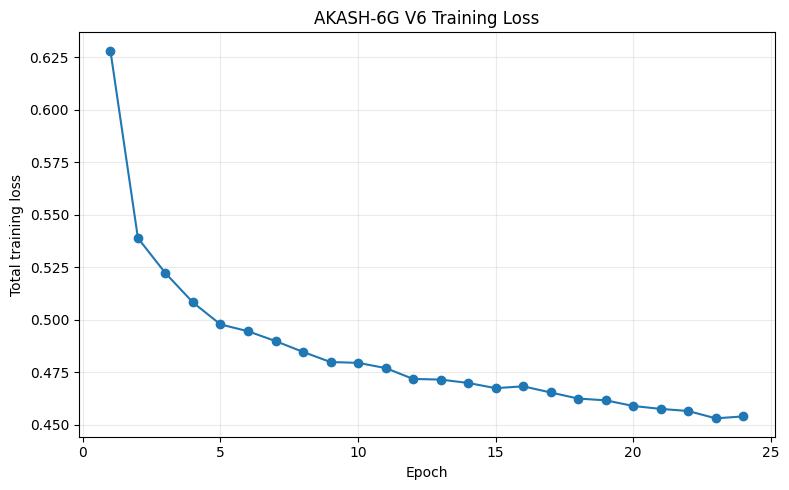

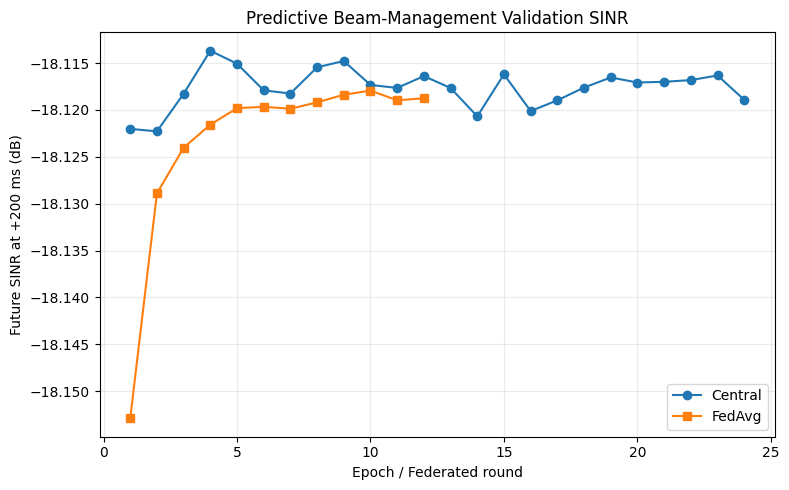

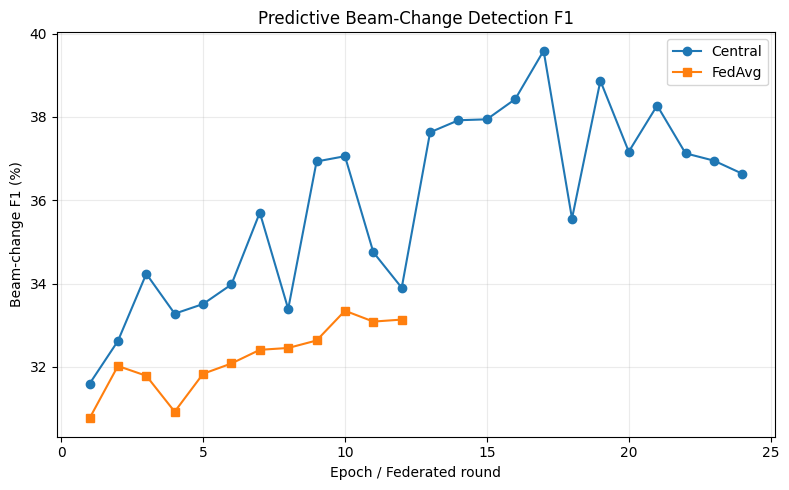

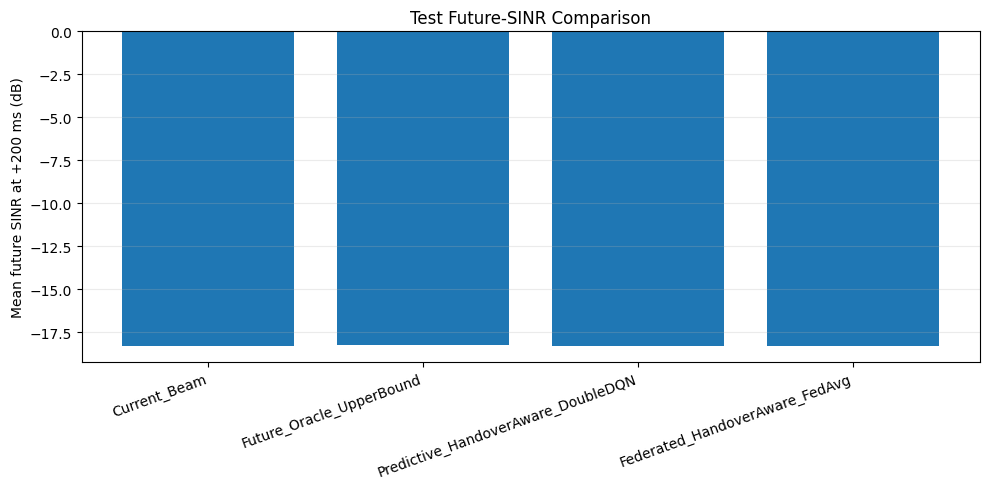

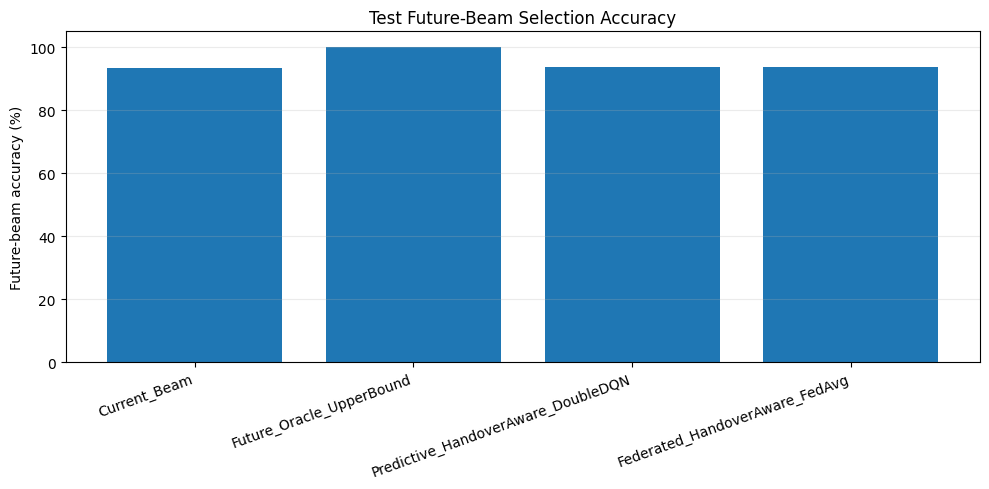

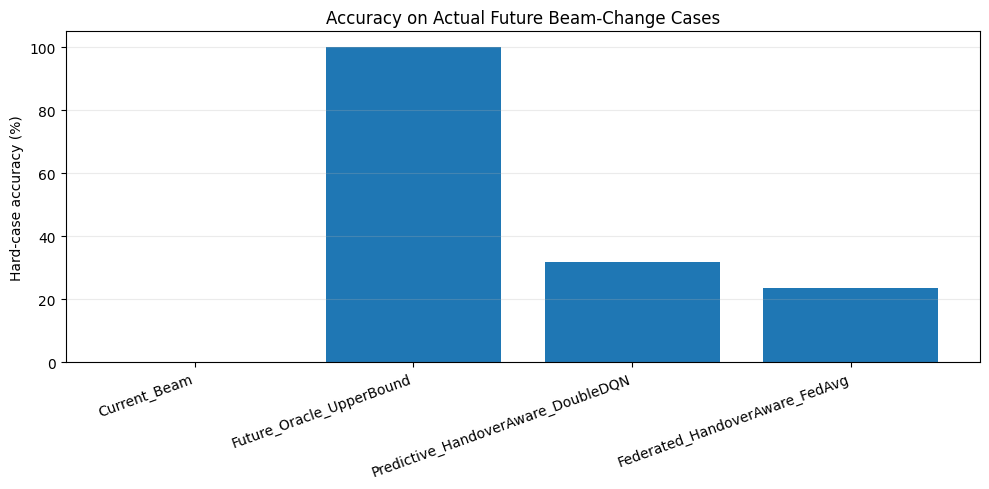

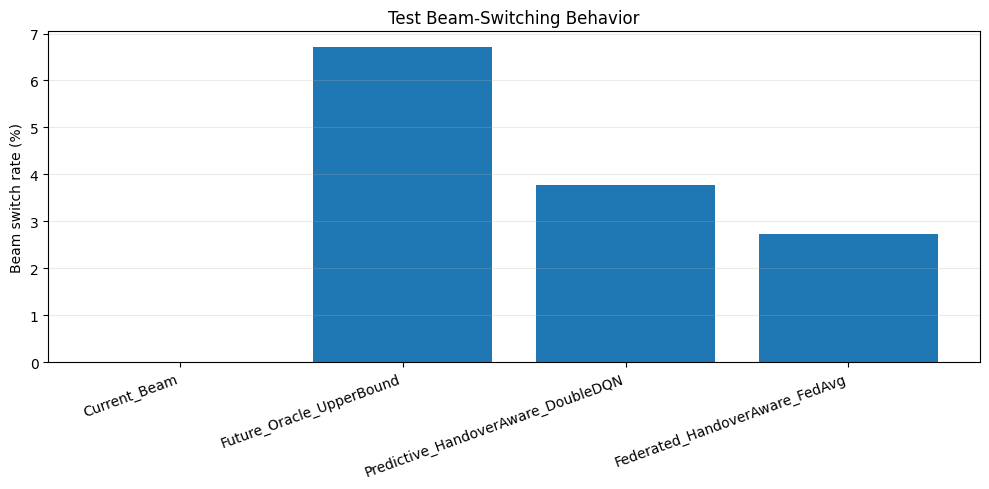

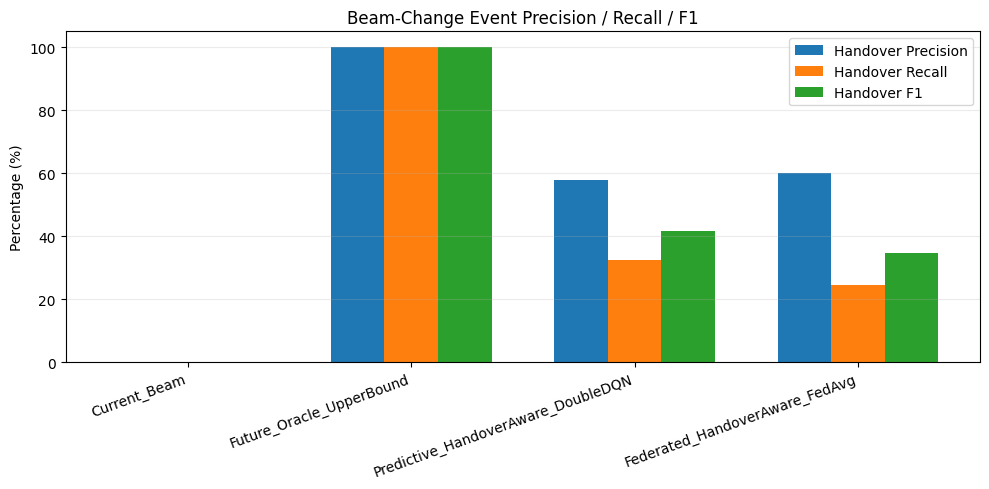

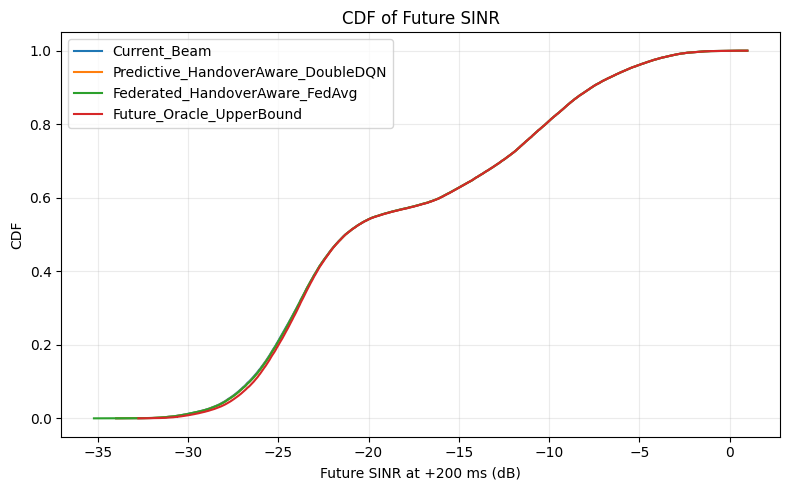

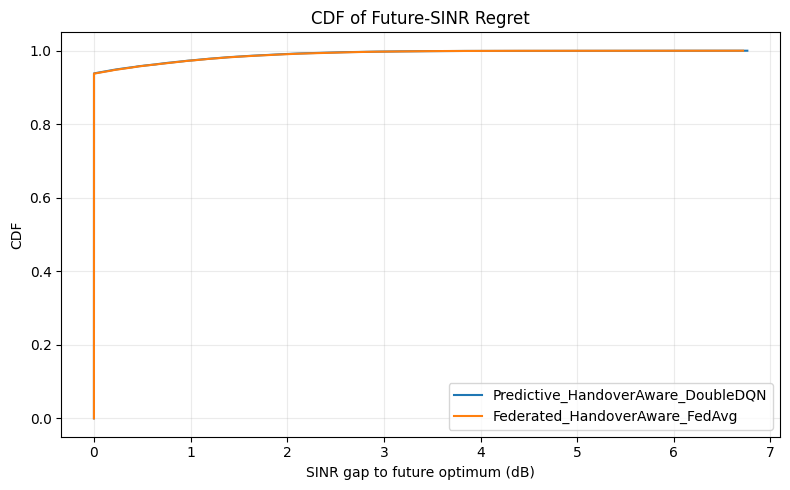

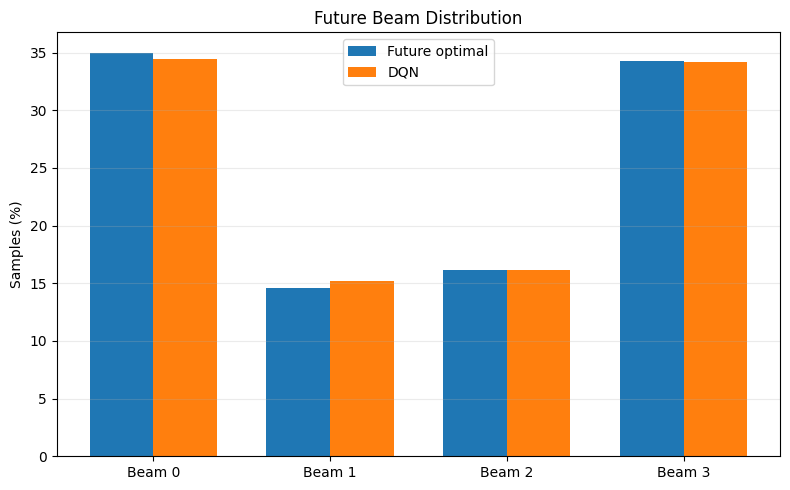

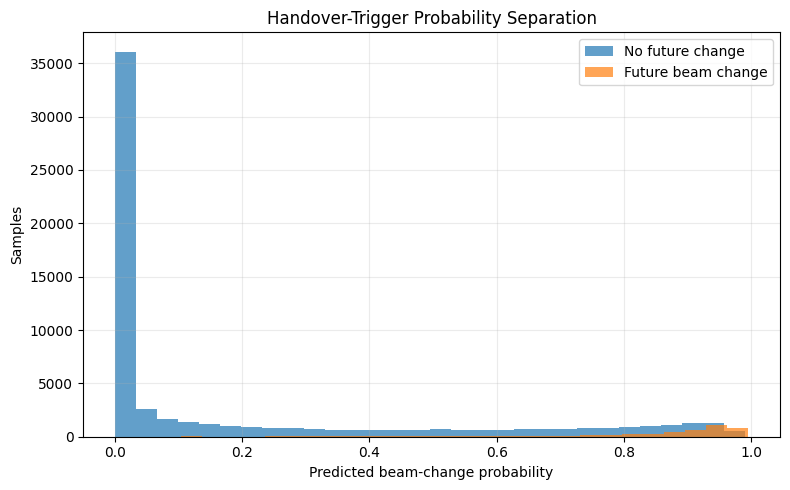

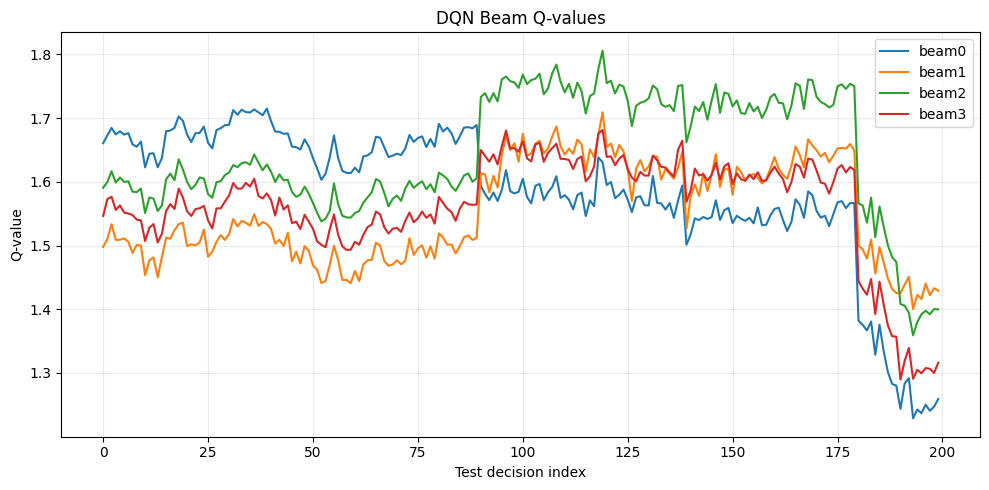

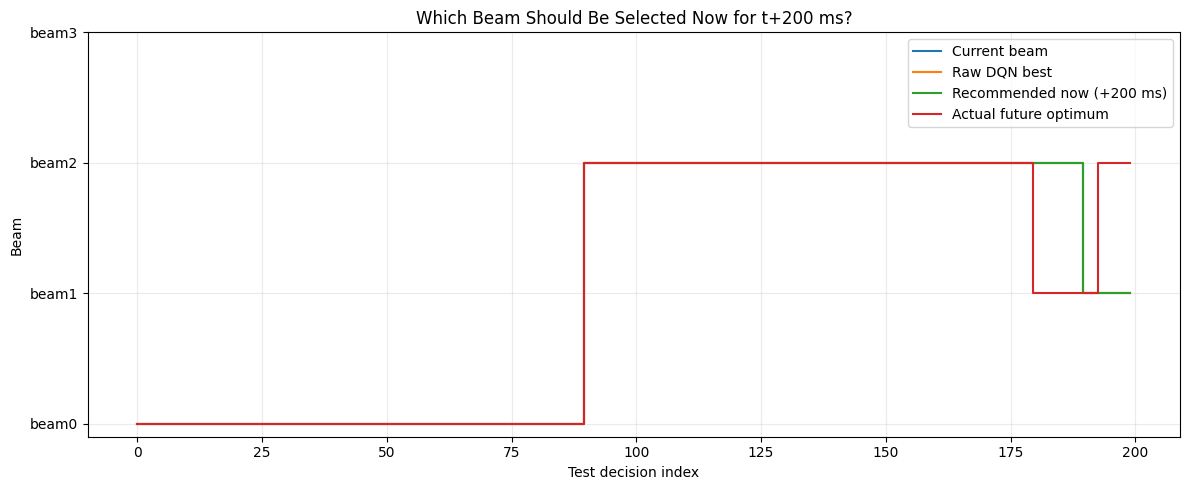


AKASH-6G V6.2 COMPLETE
Outputs: /content/AKASH6G_V6_RESEARCH_GRADE_RESULTS
Future-beam decision file: PREDICTED_FUTURE_BEAM_DECISIONS_TEST.csv
Total runtime: 19.06 min
No ground-truth future beam was used as an inference feature.
No beam switch was artificially forced.


In [ ]:

from __future__ import annotations

import copy
import json
import math
import os
import random
import time
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

SEED = 42
N_BEAMS = 4
DT_MS = 20
HORIZON_MS = 200
H_STEPS = HORIZON_MS // DT_MS
ROWS_PER_UE = 100
VALID_STATES_PER_UE = ROWS_PER_UE - H_STEPS  # 90
TRANSITIONS_PER_UE = VALID_STATES_PER_UE - 1  # 89

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Network
HIDDEN = 128
DROPOUT = 0.05
STATE_DIM = 70

# Central Double-DQN
GAMMA = 0.95
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 24
BATCH_SIZE_GPU = 1024
BATCH_SIZE_CPU = 256
TARGET_UPDATE_STEPS = 500
GRAD_CLIP = 5.0

# Loss weights
VALUE_LOSS_WEIGHT = 1.0
RANKING_LOSS_WEIGHT = 0.25
HANDOVER_LOSS_WEIGHT = 0.35
OPPORTUNITY_LOSS_WEIGHT = 0.55
FOCAL_GAMMA = 1.5
PAIR_MARGIN = 0.05

# Handover-trigger deployment
TRIGGER_THRESHOLD_MIN = 0.20
TRIGGER_THRESHOLD_MAX = 0.80
TRIGGER_THRESHOLD_STEPS = 25

# Deployment hysteresis: switch only if the predicted beam has enough
# Q-advantage over staying on the current beam.
SWITCH_ADVANTAGE_GRID = (0.0, 0.0025, 0.005, 0.01, 0.02, 0.04)

# Reward: bounded future utility + future gain over staying.
SINR_THRESHOLD_DB = 5.0
SINR_UTILITY_SCALE_DB = 4.0
GAIN_SCALE_DB = 1.5
MEANINGFUL_GAIN_DB = 0.20
GAIN_TRANSITION_DB = 0.15
SWITCH_PENALTY = 0.002
SWITCH_BENEFIT = 0.12
SWITCH_OPPORTUNITY_BONUS = 0.08

# Federated learning
RUN_FEDERATED = True
FED_ROUNDS = 12
N_CLIENTS = 10
CLIENTS_PER_ROUND = 10
LOCAL_EPOCHS = 2
FED_LR = 3e-4
FED_TARGET_UPDATE_STEPS = 400
CLIENT_MAX_STATES = 35_000

# Bootstrap CIs
BOOTSTRAP_REPS = 400

OUTPUT_DIR = Path(
    os.environ.get(
        "AKASH6G_OUTPUT_DIR",
        "/content/AKASH6G_V6_RESEARCH_GRADE_RESULTS",
    )
)
DATASET_ENV = os.environ.get("AKASH6G_DATASET_PATH", "").strip()

DATASET_FILENAMES = [
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED.csv",
    "AKASH6G_5000UE_Physical_Dataset_FINAL_CORRECTED (2).csv",
    "AKASH6G_5000UE_Physical_Dataset.csv",
]
SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path.cwd(),
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = BATCH_SIZE_GPU if DEVICE.type == "cuda" else BATCH_SIZE_CPU


# ============================================================================
# 2. COLUMNS
# ============================================================================

BEAM_RSRP_COLS = [f"beam{i}_RSRP_dBm" for i in range(N_BEAMS)]
BEAM_SINR_COLS = [f"beam{i}_SINR_dB" for i in range(N_BEAMS)]

BASE_COLS = [
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS

DELTA_COLS = [f"d_{c}" for c in BASE_COLS]
MARGIN_COLS = [f"margin_{c}" for c in BEAM_RSRP_COLS + BEAM_SINR_COLS]

REQUIRED_COLUMNS = [
    "Time_ms",
    "UE_ID",
    "Satellite_ID",
    "Satellite_Altitude_km",
    "Elevation_Angle_deg",
    "Slant_Range_km",
    "Doppler_kHz",
    "Doppler_Rate_kHz_per_ms",
    "Propagation_Delay_ms",
    "Prediction_Horizon_ms",
    "Current_Beam",
    "Optimal_Beam",
    "Future_Beam",
    "Valid_Future_Target",
    "Current_RSRP_dBm",
    "Current_SINR_dB",
    "Beam_Switch",
] + BEAM_RSRP_COLS + BEAM_SINR_COLS


# ============================================================================
# 3. REPRODUCIBILITY / HELPERS
# ============================================================================

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


def log(msg: str = "") -> None:
    print(msg, flush=True)


def save_json(path: Path, obj: object) -> None:
    def convert(v):
        if isinstance(v, (np.integer,)):
            return int(v)
        if isinstance(v, (np.floating,)):
            return float(v)
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, Path):
            return str(v)
        if isinstance(v, torch.Tensor):
            return v.detach().cpu().tolist()
        raise TypeError(f"Cannot serialize {type(v)}")

    path.write_text(json.dumps(obj, indent=2, default=convert), encoding="utf-8")


def beam_to_int(x, allow_minus_one: bool = False) -> int:
    if pd.isna(x):
        raise ValueError("Beam label is NaN")
    try:
        if isinstance(x, str):
            s = x.strip().lower()
            if s.startswith("beam"):
                s = s[4:]
            b = int(float(s))
        else:
            b = int(x)
    except Exception as exc:
        raise ValueError(f"Invalid beam label: {x!r}") from exc
    if allow_minus_one and b == -1:
        return -1
    if not 0 <= b < N_BEAMS:
        raise ValueError(f"Beam must be 0..{N_BEAMS-1}, got {b}")
    return b


def convert_beam_column(series: pd.Series, allow_minus_one: bool = False) -> np.ndarray:
    return np.asarray(
        [beam_to_int(v, allow_minus_one=allow_minus_one) for v in series],
        dtype=np.int64,
    )


def beam_name(b: int) -> str:
    return f"beam{int(b)}" if 0 <= int(b) < N_BEAMS else "N/A"


# ============================================================================
# 4. DATASET DISCOVERY
# ============================================================================

def candidate_score(path: Path) -> int:
    name = path.name.lower()
    score = 0
    if "final_corrected" in name:
        score += 100
    if "5000ue" in name:
        score += 50
    if "physical" in name:
        score += 25
    if name.endswith("(2).csv"):
        score += 5
    try:
        score += min(int(path.stat().st_size / 1_000_000), 50)
    except Exception:
        pass
    return score


def is_candidate(path: Path) -> bool:
    if not path.is_file() or path.suffix.lower() != ".csv":
        return False
    name = path.name.lower()
    return "akash6g" in name and any(k in name for k in ("physical", "corrected", "5000ue"))


def resolve_dataset_path() -> Path:
    if DATASET_ENV:
        p = Path(DATASET_ENV).expanduser()
        if not p.is_file():
            raise FileNotFoundError(f"AKASH6G_DATASET_PATH does not exist: {p}")
        return p

    candidates: Dict[str, Path] = {}
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for fname in DATASET_FILENAMES:
            p = root / fname
            if p.is_file():
                candidates[str(p.resolve())] = p
        try:
            for p in root.rglob("*.csv"):
                if is_candidate(p):
                    candidates[str(p.resolve())] = p
        except Exception:
            continue

    if candidates:
        ranked = sorted(candidates.values(), key=candidate_score, reverse=True)
        chosen = ranked[0]
        log(f"Dataset auto-detected: {chosen}")
        if len(ranked) > 1:
            log("Other candidates:")
            for p in ranked[1:6]:
                log(f"  {p}")
        return chosen

    # Colab upload fallback.
    try:
        from google.colab import files as colab_files
        log("No AKASH-6G CSV found. Opening Colab upload dialog...")
        uploaded = colab_files.upload()
        for name in uploaded:
            p = Path("/content") / name
            if p.is_file() and p.suffix.lower() == ".csv":
                return p
    except Exception:
        pass

    raise FileNotFoundError(
        "AKASH-6G physical CSV not found. Upload the corrected CSV or set "
        "AKASH6G_DATASET_PATH."
    )


# ============================================================================
# 5. LOAD + NORMALIZE LABELS
# ============================================================================

def load_dataset() -> Tuple[pd.DataFrame, Path]:
    path = resolve_dataset_path()
    log("=" * 80)
    log("AKASH-6G V6.2 — HANDOVER-AWARE PREDICTIVE DUELING DOUBLE-DQN + FEDAVG")
    log("=" * 80)
    log(f"Device : {DEVICE}")
    log(f"Dataset: {path}")

    df = pd.read_csv(path, low_memory=False)
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError("Missing required columns:\n" + "\n".join(missing))

    for c in BASE_COLS + ["Time_ms", "UE_ID", "Satellite_ID", "Satellite_Altitude_km", "Prediction_Horizon_ms"]:
        df[c] = pd.to_numeric(df[c], errors="raise")

    df["Current_Beam"] = convert_beam_column(df["Current_Beam"])
    df["Optimal_Beam"] = convert_beam_column(df["Optimal_Beam"])
    df["Future_Beam"] = convert_beam_column(df["Future_Beam"], allow_minus_one=True)
    df["Valid_Future_Target"] = pd.to_numeric(df["Valid_Future_Target"], errors="raise").astype(np.int8)
    df["Beam_Switch"] = pd.to_numeric(df["Beam_Switch"], errors="raise").astype(np.int8)

    df = df.sort_values(["UE_ID", "Time_ms"]).reset_index(drop=True)
    log(f"Loaded shape: {df.shape}")
    return df, path


# ============================================================================
# 6. PHYSICS / LINKAGE AUDIT
# ============================================================================

def audit_dataset(df: pd.DataFrame) -> Dict[str, object]:
    log("\n[1/8] STRICT DATASET AUDIT")

    n = len(df)
    unique_ues = int(df["UE_ID"].nunique())
    missing = int(df.isna().sum().sum())
    duplicates = int(df.duplicated().sum())
    row_counts = df.groupby("UE_ID").size()
    wrong_row_counts = int((row_counts != ROWS_PER_UE).sum())

    max_dt_error = 0.0
    max_current_rsrp_error = 0.0
    max_current_sinr_error = 0.0
    max_range_geometry_error_km = 0.0
    max_delay_error_ms = 0.0
    future_mismatch = 0
    validity_mismatch = 0
    optimal_rsrp_match = 0
    optimal_sinr_match = 0
    ranking_same = 0

    re_km = 6371.0
    h_km = 600.0
    c_km_s = 299792.458

    for ue, g in df.groupby("UE_ID", sort=False):
        g = g.sort_values("Time_ms").reset_index(drop=True)
        t = g["Time_ms"].to_numpy(float)
        if len(t) > 1:
            max_dt_error = max(max_dt_error, float(np.max(np.abs(np.diff(t) - DT_MS))))

        current = g["Current_Beam"].to_numpy(int)
        optimal = g["Optimal_Beam"].to_numpy(int)
        future = g["Future_Beam"].to_numpy(int)
        valid = g["Valid_Future_Target"].to_numpy(int)
        rsrp = g[BEAM_RSRP_COLS].to_numpy(float)
        sinr = g[BEAM_SINR_COLS].to_numpy(float)

        expected_current_rsrp = rsrp[np.arange(len(g)), current]
        expected_current_sinr = sinr[np.arange(len(g)), current]
        max_current_rsrp_error = max(
            max_current_rsrp_error,
            float(np.max(np.abs(g["Current_RSRP_dBm"].to_numpy(float) - expected_current_rsrp))),
        )
        max_current_sinr_error = max(
            max_current_sinr_error,
            float(np.max(np.abs(g["Current_SINR_dB"].to_numpy(float) - expected_current_sinr))),
        )

        rs_arg = rsrp.argmax(axis=1)
        si_arg = sinr.argmax(axis=1)
        optimal_rsrp_match += int(np.sum(optimal == rs_arg))
        optimal_sinr_match += int(np.sum(optimal == si_arg))
        ranking_same += int(np.sum(rs_arg == si_arg))

        # Exact +200 ms target check for valid rows.
        for i in range(VALID_STATES_PER_UE):
            if future[i] != optimal[i + H_STEPS]:
                future_mismatch += 1
            if valid[i] != 1:
                validity_mismatch += 1
        for i in range(VALID_STATES_PER_UE, ROWS_PER_UE):
            if valid[i] != 0 or future[i] != -1:
                validity_mismatch += 1

        # Geometry check using standard spherical slant-range relation.
        elev = np.deg2rad(g["Elevation_Angle_deg"].to_numpy(float))
        expected_d = -re_km * np.sin(elev) + np.sqrt(
            (re_km + h_km) ** 2 - (re_km * np.cos(elev)) ** 2
        )
        max_range_geometry_error_km = max(
            max_range_geometry_error_km,
            float(np.max(np.abs(g["Slant_Range_km"].to_numpy(float) - expected_d))),
        )
        expected_delay_ms = g["Slant_Range_km"].to_numpy(float) / c_km_s * 1000.0
        max_delay_error_ms = max(
            max_delay_error_ms,
            float(np.max(np.abs(g["Propagation_Delay_ms"].to_numpy(float) - expected_delay_ms))),
        )

    valid_rows = int(df["Valid_Future_Target"].sum())
    total = max(n, 1)
    audit = {
        "rows": n,
        "columns": int(df.shape[1]),
        "unique_ues": unique_ues,
        "missing": missing,
        "duplicates": duplicates,
        "wrong_ue_row_counts": wrong_row_counts,
        "max_time_step_error_ms": max_dt_error,
        "max_current_rsrp_linkage_error_db": max_current_rsrp_error,
        "max_current_sinr_linkage_error_db": max_current_sinr_error,
        "future_mismatches": future_mismatch,
        "future_validity_mismatches": validity_mismatch,
        "valid_predictive_rows": valid_rows,
        "optimal_vs_rsrp_pct": 100.0 * optimal_rsrp_match / total,
        "optimal_vs_sinr_pct": 100.0 * optimal_sinr_match / total,
        "rsrp_sinr_ranking_same_pct": 100.0 * ranking_same / total,
        "max_range_geometry_error_km": max_range_geometry_error_km,
        "max_propagation_delay_error_ms": max_delay_error_ms,
        "altitude_min_km": float(df["Satellite_Altitude_km"].min()),
        "altitude_max_km": float(df["Satellite_Altitude_km"].max()),
        "doppler_min_khz": float(df["Doppler_kHz"].min()),
        "doppler_max_khz": float(df["Doppler_kHz"].max()),
        "doppler_rate_min_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].min()),
        "doppler_rate_max_khz_per_ms": float(df["Doppler_Rate_kHz_per_ms"].max()),
        "elevation_min_deg": float(df["Elevation_Angle_deg"].min()),
        "elevation_max_deg": float(df["Elevation_Angle_deg"].max()),
        "slant_range_min_km": float(df["Slant_Range_km"].min()),
        "slant_range_max_km": float(df["Slant_Range_km"].max()),
    }

    for k, v in audit.items():
        if isinstance(v, float):
            log(f"{k:38s}: {v:.9g}")
        else:
            log(f"{k:38s}: {v}")

    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("WARNING: RSRP and SINR rankings are nearly identical; this is a simulator limitation.")

    hard_fail = (
        n != 500_000
        or unique_ues != 5_000
        or missing != 0
        or duplicates != 0
        or wrong_row_counts != 0
        or max_dt_error > 1e-6
        or max_current_rsrp_error > 1e-3
        or max_current_sinr_error > 1e-3
        or future_mismatch != 0
        or validity_mismatch != 0
        or max_range_geometry_error_km > 1e-3
        or max_delay_error_ms > 1e-6
    )
    if hard_fail:
        raise ValueError("STRICT DATASET AUDIT FAILED. Training was stopped.")

    log("STRICT DATASET AUDIT: PASS")
    return audit


# ============================================================================
# 7. UE SPLIT
# ============================================================================

def split_ues(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    ues = np.sort(df["UE_ID"].unique().astype(int))
    rng = np.random.default_rng(SEED)
    rng.shuffle(ues)
    n = len(ues)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))
    train = np.sort(ues[:n_train])
    val = np.sort(ues[n_train:n_train + n_val])
    test = np.sort(ues[n_train + n_val:])
    if len(set(train) & set(val)) or len(set(train) & set(test)) or len(set(val) & set(test)):
        raise RuntimeError("UE split overlap detected.")
    log(f"UE split: train={len(train)}, val={len(val)}, test={len(test)}")
    return train, val, test


# ============================================================================
# 8. STATE CONSTRUCTION — 70 FEATURES
# ============================================================================

def build_states(
    df: pd.DataFrame,
    train_ues: np.ndarray,
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    log("\n[2/8] BUILDING LEAKAGE-SAFE TEMPORAL STATES")
    n = len(df)
    base = df[BASE_COLS].to_numpy(np.float32)
    current = df["Current_Beam"].to_numpy(np.int64)

    deltas = np.zeros_like(base, dtype=np.float32)
    second_deltas = np.zeros_like(base, dtype=np.float32)
    margins = np.zeros((n, 8), dtype=np.float32)
    history = np.zeros((n, 12), dtype=np.float32)
    dwell = np.zeros(n, dtype=np.float32)

    # Because df is sorted by UE/time, global contiguous slices are safe.
    for _, g in df.groupby("UE_ID", sort=False):
        idx = g.index.to_numpy()
        b = g["Current_Beam"].to_numpy(np.int64)
        bbase = base[idx]
        if len(idx) > 1:
            deltas[idx[1:]] = bbase[1:] - bbase[:-1]
        if len(idx) > 2:
            second_deltas[idx[2:]] = bbase[2:] - 2.0 * bbase[1:-1] + bbase[:-2]
        for j, ridx in enumerate(idx):
            for h in range(3):
                src = max(0, j - h)
                history[ridx, h * N_BEAMS + b[src]] = 1.0
            k = j
            while k > 0 and b[k - 1] == b[j]:
                k -= 1
            dwell[ridx] = j - k

    rsrp = df[BEAM_RSRP_COLS].to_numpy(np.float32)
    sinr = df[BEAM_SINR_COLS].to_numpy(np.float32)
    cur_rsrp = df["Current_RSRP_dBm"].to_numpy(np.float32)[:, None]
    cur_sinr = df["Current_SINR_dB"].to_numpy(np.float32)[:, None]
    margins[:, :4] = rsrp - cur_rsrp
    margins[:, 4:] = sinr - cur_sinr

    continuous = np.concatenate([base, deltas, second_deltas, margins, dwell[:, None]], axis=1)
    if continuous.shape[1] != 54:
        raise RuntimeError(f"Expected 54 continuous features, got {continuous.shape[1]}")

    train_mask = df["UE_ID"].isin(set(train_ues.tolist())).to_numpy()
    train_values = continuous[train_mask]
    mean = train_values.mean(axis=0).astype(np.float32)
    std = train_values.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0
    norm = ((continuous - mean) / std).astype(np.float32)

    onehot = np.zeros((n, N_BEAMS), np.float32)
    onehot[np.arange(n), current] = 1.0
    state = np.concatenate([norm, onehot, history], axis=1).astype(np.float32)
    if state.shape[1] != STATE_DIM:
        raise RuntimeError(f"State dimension mismatch: {state.shape[1]} != {STATE_DIM}")

    log(f"State dimension: {STATE_DIM} = 54 continuous (15 base + 15 first-difference + 15 second-difference + 8 margins + 1 dwell) + 4 current-beam one-hot + 12 beam-history one-hot")
    return df, state, mean, std


# ============================================================================
# 9. STATE-LEVEL COUNTERFACTUAL DATASET
# ============================================================================

def build_decision_dataset(
    df: pd.DataFrame,
    state: np.ndarray,
    ue_ids: np.ndarray,
    max_states: Optional[int] = None,
) -> Dict[str, np.ndarray]:
    """Return one row per valid decision state, not four duplicated rows.

    The implementation is deliberately vectorized per UE.  Earlier versions
    repeatedly used pandas iloc inside the inner time loop, which made the
    315k-state construction unnecessarily slow in Colab.
    """
    ue_set = set(int(x) for x in ue_ids)
    row_parts: List[np.ndarray] = []
    next_parts: List[np.ndarray] = []
    fs_parts: List[np.ndarray] = []
    cur_parts: List[np.ndarray] = []
    opt_parts: List[np.ndarray] = []
    ue_parts: List[np.ndarray] = []
    time_parts: List[np.ndarray] = []
    elevation_parts: List[np.ndarray] = []
    doppler_parts: List[np.ndarray] = []
    doppler_rate_parts: List[np.ndarray] = []
    edge_margin_parts: List[np.ndarray] = []

    for ue, g in df[df["UE_ID"].isin(ue_set)].groupby("UE_ID", sort=True):
        g = g.sort_values("Time_ms")
        if len(g) != ROWS_PER_UE:
            raise RuntimeError(f"UE {ue} has {len(g)} rows; expected {ROWS_PER_UE}")

        ridx = g.index.to_numpy(np.int64)
        # 90 valid decision times: t = 0..89.
        row_parts.append(ridx[:VALID_STATES_PER_UE])
        # The final decision at t=1780 ms uses row 90 (1800 ms) as its
        # one-step next state; row 90 itself does not need a future target.
        next_parts.append(ridx[1:VALID_STATES_PER_UE + 1])

        sinr = g[BEAM_SINR_COLS].to_numpy(np.float32)
        fs_parts.append(sinr[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        cur_parts.append(g["Current_Beam"].to_numpy(np.int64)[:VALID_STATES_PER_UE])
        opt_parts.append(g["Optimal_Beam"].to_numpy(np.int64)[H_STEPS:H_STEPS + VALID_STATES_PER_UE])
        ue_parts.append(np.full(VALID_STATES_PER_UE, int(ue), dtype=np.int64))
        time_parts.append(g["Time_ms"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        elevation_parts.append(g["Elevation_Angle_deg"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        doppler_parts.append(g["Doppler_kHz"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        doppler_rate_parts.append(g["Doppler_Rate_kHz_per_ms"].to_numpy(np.float32)[:VALID_STATES_PER_UE])
        cur_rsrp = g["Current_RSRP_dBm"].to_numpy(np.float32)[:VALID_STATES_PER_UE]
        all_rsrp = g[BEAM_RSRP_COLS].to_numpy(np.float32)[:VALID_STATES_PER_UE]
        top2 = np.partition(all_rsrp, -2, axis=1)[:, -2]
        edge_margin_parts.append(all_rsrp.max(axis=1) - top2)

    rows = np.concatenate(row_parts)
    next_rows = np.concatenate(next_parts)
    FS = np.concatenate(fs_parts, axis=0)
    CB = np.concatenate(cur_parts)
    FO = np.concatenate(opt_parts)
    UE = np.concatenate(ue_parts)
    TM = np.concatenate(time_parts)

    X = state[rows]
    NX = state[next_rows]

    if max_states is not None and len(X) > max_states:
        rng = np.random.default_rng(SEED + int(len(ue_ids)) + 17)
        idx = rng.choice(len(X), size=int(max_states), replace=False)
        idx.sort()
        X, NX, FS, CB, FO, UE, TM = [a[idx] for a in (X, NX, FS, CB, FO, UE, TM)]

    return {
        "states": X.astype(np.float32, copy=False),
        "next_states": NX.astype(np.float32, copy=False),
        "future_sinr": FS.astype(np.float32, copy=False),
        "current_beam": CB.astype(np.int64, copy=False),
        "future_optimal": FO.astype(np.int64, copy=False),
        "UE_ID": UE.astype(np.int64, copy=False),
        "Time_ms": TM.astype(np.float32, copy=False),
        "Elevation_Angle_deg": np.concatenate(elevation_parts).astype(np.float32, copy=False),
        "Doppler_kHz": np.concatenate(doppler_parts).astype(np.float32, copy=False),
        "Doppler_Rate_kHz_per_ms": np.concatenate(doppler_rate_parts).astype(np.float32, copy=False),
        "BeamEdge_Margin_dB": np.concatenate(edge_margin_parts).astype(np.float32, copy=False),
    }


# ============================================================================
# 10. PHYSICS-BACKED REWARD
# ============================================================================

def counterfactual_reward(future_sinr: np.ndarray, current_beam: np.ndarray) -> np.ndarray:
    """Counterfactual physical utility for all four actions at t+200 ms.

    The future beam label is not used.  The reward is based only on the four
    future SINRs and the current beam.  A smooth opportunity bonus encourages
    switching when the future SINR advantage is meaningful, while a small cost
    discourages gratuitous changes.
    """
    sinr = np.asarray(future_sinr, np.float32)
    current = np.asarray(current_beam, np.int64)
    z = np.clip((sinr - SINR_THRESHOLD_DB) / SINR_UTILITY_SCALE_DB, -30.0, 30.0)
    absolute = 1.0 / (1.0 + np.exp(-z))
    rows = np.arange(len(sinr))
    stay_sinr = sinr[rows, current]
    gain = sinr - stay_sinr[:, None]
    gain_term = np.tanh(gain / GAIN_SCALE_DB)
    opportunity_z = np.clip((gain - MEANINGFUL_GAIN_DB) / GAIN_TRANSITION_DB, -30.0, 30.0)
    opportunity = 1.0 / (1.0 + np.exp(-opportunity_z))
    switches = (np.arange(N_BEAMS)[None, :] != current[:, None]).astype(np.float32)
    reward = (absolute + SWITCH_BENEFIT * gain_term
              + SWITCH_OPPORTUNITY_BONUS * opportunity * switches
              - SWITCH_PENALTY * switches)
    reward -= reward.mean(axis=1, keepdims=True)
    return reward.astype(np.float32)


# ============================================================================
# 11. MODEL
# ============================================================================

class HandoverAwareDuelingDoubleDQN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(STATE_DIM, HIDDEN),
            nn.LayerNorm(HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, HIDDEN),
            nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, N_BEAMS),
        )
        self.handover_head = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )
        self.opportunity_head = nn.Sequential(
            nn.Linear(HIDDEN, HIDDEN // 2),
            nn.ReLU(),
            nn.Linear(HIDDEN // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.trunk(x)
        v = self.value(h)
        a = self.advantage(h)
        q = v + a - a.mean(dim=1, keepdim=True)
        handover_logit = self.handover_head(h).squeeze(1)
        opportunity_logit = self.opportunity_head(h).squeeze(1)
        return q, handover_logit, opportunity_logit


def clone_model(model: nn.Module) -> nn.Module:
    out = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    out.load_state_dict(model.state_dict())
    return out


# ============================================================================
# 12. TRAINING TENSOR HELPERS
# ============================================================================

def to_tensor(a: np.ndarray, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    return torch.from_numpy(np.asarray(a)).to(device=DEVICE, dtype=dtype)


def compute_handover_labels(current: np.ndarray, future_opt: np.ndarray) -> np.ndarray:
    return (current != future_opt).astype(np.float32)


def batch_indices(n: int, batch_size: int, rng: np.random.Generator) -> Iterable[np.ndarray]:
    order = rng.permutation(n)
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


# ============================================================================
# 13. ONE OPTIMIZATION STEP
# ============================================================================

def ranking_loss(q: torch.Tensor, rewards: torch.Tensor) -> torch.Tensor:
    """Pairwise hinge loss: actions with higher physical reward should have higher Q."""
    # Six unordered pairs for four beams.
    loss_terms = []
    for i in range(N_BEAMS):
        for j in range(i + 1, N_BEAMS):
            better_i = rewards[:, i] > rewards[:, j]
            better_j = rewards[:, j] > rewards[:, i]
            if better_i.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_i, i] - q[better_i, j])).mean())
            if better_j.any():
                loss_terms.append(F.relu(PAIR_MARGIN - (q[better_j, j] - q[better_j, i])).mean())
    if not loss_terms:
        return q.sum() * 0.0
    return torch.stack(loss_terms).mean()


def train_batch(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    optimizer: optim.Optimizer,
    xb: torch.Tensor,
    nxb: torch.Tensor,
    reward_b: torch.Tensor,
    ho_b: torch.Tensor,
    opportunity_b: torch.Tensor,
) -> Dict[str, float]:
    model.train()
    q, ho_logit, opportunity_logit = model(xb)

    with torch.no_grad():
        # Double-DQN: online network selects next action; target evaluates it.
        next_q_online, _, _ = model(nxb)
        next_actions = next_q_online.argmax(dim=1)
        next_q_target, _, _ = target(nxb)
        next_best = next_q_target.gather(1, next_actions[:, None]).squeeze(1)
        # Same continuation value is applied to all counterfactual actions of this state.
        y = reward_b + GAMMA * next_best[:, None]

    value_loss = F.smooth_l1_loss(q, y)
    rank = ranking_loss(q, reward_b)

    pos = float(ho_b.sum().item())
    neg = float(len(ho_b) - pos)
    pos_weight = torch.tensor([neg / max(pos, 1.0)], device=DEVICE)
    ho_loss = F.binary_cross_entropy_with_logits(ho_logit, ho_b, pos_weight=pos_weight)
    # Meaningful opportunity label is computed from the physical future-SINR gain
    # and is never available to the deployment policy.
    pos2 = float(opportunity_b.sum().item())
    neg2 = float(len(opportunity_b) - pos2)
    pos_weight2 = torch.tensor([neg2 / max(pos2, 1.0)], device=DEVICE)
    opportunity_loss = F.binary_cross_entropy_with_logits(opportunity_logit, opportunity_b, pos_weight=pos_weight2)

    loss = (VALUE_LOSS_WEIGHT * value_loss + RANKING_LOSS_WEIGHT * rank
            + HANDOVER_LOSS_WEIGHT * ho_loss + OPPORTUNITY_LOSS_WEIGHT * opportunity_loss)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    return {
        "loss": float(loss.item()),
        "value_loss": float(value_loss.item()),
        "rank_loss": float(rank.item()),
        "handover_loss": float(ho_loss.item()),
        "opportunity_loss": float(opportunity_loss.item()),
    }


# ============================================================================
# 14. PREDICTION
# ============================================================================

@torch.no_grad()
def predict_model(
    model: HandoverAwareDuelingDoubleDQN,
    X: np.ndarray,
    batch_size: int = 8192,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    q_out: List[np.ndarray] = []
    p_out: List[np.ndarray] = []
    o_out: List[np.ndarray] = []
    for start in range(0, len(X), batch_size):
        xb = to_tensor(X[start:start + batch_size])
        q, logit, opportunity_logit = model(xb)
        q_out.append(q.cpu().numpy())
        p_out.append(torch.sigmoid(logit).cpu().numpy())
        o_out.append(torch.sigmoid(opportunity_logit).cpu().numpy())
    return np.concatenate(q_out), np.concatenate(p_out), np.concatenate(o_out)


def choose_actions(
    q: np.ndarray,
    opportunity_probability: np.ndarray,
    current: np.ndarray,
    trigger_threshold: float,
    switch_advantage: float,
) -> np.ndarray:
    best = q.argmax(axis=1).astype(np.int64)
    actions = current.astype(np.int64).copy()
    rows = np.arange(len(q))
    advantage = q[rows, best] - q[rows, current]
    switch = (
        (best != current)
        & (opportunity_probability >= trigger_threshold)
        & (advantage >= switch_advantage)
    )
    actions[switch] = best[switch]
    return actions


# ============================================================================
# 15. EVALUATION
# ============================================================================

def evaluate_predictions(
    actions: np.ndarray,
    q: np.ndarray,
    p: np.ndarray,
    opportunity_p: np.ndarray,
    data: Dict[str, np.ndarray],
    trigger_threshold: float,
    switch_advantage: float,
) -> Dict[str, object]:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    future_sinr = data["future_sinr"]
    rows = np.arange(len(actions))
    chosen_sinr = future_sinr[rows, actions]
    optimal_sinr = future_sinr.max(axis=1)

    actual_event = current != optimal
    rows2 = np.arange(len(future_sinr))
    stay_future = future_sinr[rows2, current]
    future_gain = optimal_sinr - stay_future
    meaningful_event = actual_event & (future_gain >= MEANINGFUL_GAIN_DB)
    predicted_event = actions != current
    tp = int(np.sum(actual_event & predicted_event))
    fp = int(np.sum(~actual_event & predicted_event))
    fn = int(np.sum(actual_event & ~predicted_event))
    tn = int(np.sum(~actual_event & ~predicted_event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    hard = actual_event
    hard_acc = float(np.mean(actions[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan")
    accuracy = float(np.mean(actions == optimal) * 100.0)
    switch_rate = float(np.mean(actions != current) * 100.0)
    future_mean = float(chosen_sinr.mean())
    opt_mean = float(optimal_sinr.mean())
    gap = opt_mean - future_mean

    # Event-trigger metrics independent of the beam hysteresis decision.
    trigger_pred = opportunity_p >= trigger_threshold
    ttp = int(np.sum(actual_event & trigger_pred))
    tfp = int(np.sum(~actual_event & trigger_pred))
    tfn = int(np.sum(actual_event & ~trigger_pred))
    trigger_precision = ttp / max(ttp + tfp, 1)
    trigger_recall = ttp / max(ttp + tfn, 1)
    trigger_f1 = 2 * trigger_precision * trigger_recall / max(trigger_precision + trigger_recall, 1e-12)

    meaningful_pred = actions != current
    mtp = int(np.sum(meaningful_event & meaningful_pred))
    mfp = int(np.sum(~meaningful_event & meaningful_pred))
    mfn = int(np.sum(meaningful_event & ~meaningful_pred))
    mprec = mtp / max(mtp + mfp, 1)
    mrec = mtp / max(mtp + mfn, 1)
    mf1 = 2 * mprec * mrec / max(mprec + mrec, 1e-12)

    reward_matrix = counterfactual_reward(future_sinr, current)
    chosen_reward = reward_matrix[rows, actions]

    return {
        "future_sinr_db": future_mean,
        "optimal_future_sinr_db": opt_mean,
        "sinr_gap_db": gap,
        "beam_accuracy_pct": accuracy,
        "hard_case_accuracy_pct": hard_acc,
        "hard_cases": int(hard.sum()),
        "switch_rate_pct": switch_rate,
        "correct_handover": int(np.sum(actual_event & (actions == optimal))),
        "missed_handover": int(np.sum(actual_event & (actions == current))),
        "unnecessary_handover": int(np.sum((~actual_event) & (actions != current))),
        "handover_precision_pct": precision * 100.0,
        "handover_recall_pct": recall * 100.0,
        "handover_f1_pct": f1 * 100.0,
        "trigger_precision_pct": trigger_precision * 100.0,
        "trigger_recall_pct": trigger_recall * 100.0,
        "trigger_f1_pct": trigger_f1 * 100.0,
        "meaningful_handover_precision_pct": mprec * 100.0,
        "meaningful_handover_recall_pct": mrec * 100.0,
        "meaningful_handover_f1_pct": mf1 * 100.0,
        "meaningful_event_count": int(meaningful_event.sum()),
        "mean_reward": float(chosen_reward.mean()),
        "trigger_threshold": float(trigger_threshold),
        "switch_advantage": float(switch_advantage),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "actions": actions,
        "q_values": q,
        "handover_probability": p,
        "opportunity_probability": opportunity_p,
    }


# ============================================================================
# 16. VALIDATION THRESHOLD SELECTION
# ============================================================================

def select_deployment_policy(
    model: HandoverAwareDuelingDoubleDQN,
    val_data: Dict[str, np.ndarray],
) -> Tuple[float, float, Dict[str, float]]:
    """Select trigger threshold and Q-advantage using validation only."""
    q, p, o = predict_model(model, val_data["states"])
    best_t = 0.5
    best_adv = 0.01
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)
    best_metrics: Dict[str, float] = {}
    for t in np.linspace(TRIGGER_THRESHOLD_MIN, TRIGGER_THRESHOLD_MAX, TRIGGER_THRESHOLD_STEPS):
        for adv in SWITCH_ADVANTAGE_GRID:
            actions = choose_actions(q, o, val_data["current_beam"], float(t), float(adv))
            m = evaluate_predictions(actions, q, p, o, val_data, float(t), float(adv))
            score = (
                m["meaningful_handover_f1_pct"],
                m["handover_f1_pct"],
                m["future_sinr_db"],
                m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
                -m["sinr_gap_db"],
            )
            if score > best_score:
                best_score = score
                best_t = float(t)
                best_adv = float(adv)
                best_metrics = {
                    "handover_f1_pct": float(m["handover_f1_pct"]),
                    "future_sinr_db": float(m["future_sinr_db"]),
                    "hard_case_accuracy_pct": float(m["hard_case_accuracy_pct"]),
                    "switch_rate_pct": float(m["switch_rate_pct"]),
                }
    return best_t, best_adv, best_metrics


# ============================================================================
# 17. CENTRAL TRAINING
# ============================================================================

def train_central(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float, float]:
    log("\n[4/8] CENTRAL HANDOVER-AWARE DOUBLE-DQN TRAINING")
    model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    target = clone_model(model)
    target.eval()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    rng = np.random.default_rng(SEED + 100)
    reward = counterfactual_reward(train_data["future_sinr"], train_data["current_beam"])
    ho = compute_handover_labels(train_data["current_beam"], train_data["future_optimal"])
    rows = np.arange(len(train_data["future_sinr"]))
    stay = train_data["future_sinr"][rows, train_data["current_beam"]]
    best = train_data["future_sinr"].max(axis=1)
    opportunity = (best - stay >= MEANINGFUL_GAIN_DB).astype(np.float32)

    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)
    history = []
    global_step = 0
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        metrics_accum = []
        for idx in batch_indices(len(train_data["states"]), BATCH_SIZE, rng):
            xb = to_tensor(train_data["states"][idx])
            nxb = to_tensor(train_data["next_states"][idx])
            rb = to_tensor(reward[idx])
            hb = to_tensor(ho[idx])
            metrics_accum.append(train_batch(model, target, optimizer, xb, nxb, rb, hb, to_tensor(opportunity[idx])))
            global_step += 1
            if global_step % TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())

        val_q, val_p, val_o = predict_model(model, val_data["states"])
        threshold, switch_adv, _ = select_deployment_policy(model, val_data)
        val_actions = choose_actions(val_q, val_o, val_data["current_beam"], threshold, switch_adv)
        vm = evaluate_predictions(val_actions, val_q, val_p, val_o, val_data, threshold, switch_adv)

        row = {
            "epoch": epoch,
            "loss": float(np.mean([x["loss"] for x in metrics_accum])),
            "value_loss": float(np.mean([x["value_loss"] for x in metrics_accum])),
            "rank_loss": float(np.mean([x["rank_loss"] for x in metrics_accum])),
            "handover_loss": float(np.mean([x["handover_loss"] for x in metrics_accum])),
            "opportunity_loss": float(np.mean([x["opportunity_loss"] for x in metrics_accum])),
            "val_future_sinr_db": vm["future_sinr_db"],
            "val_sinr_gap_db": vm["sinr_gap_db"],
            "val_accuracy_pct": vm["beam_accuracy_pct"],
            "val_hard_accuracy_pct": vm["hard_case_accuracy_pct"],
            "val_switch_rate_pct": vm["switch_rate_pct"],
            "val_handover_precision_pct": vm["handover_precision_pct"],
            "val_handover_recall_pct": vm["handover_recall_pct"],
            "val_handover_f1_pct": vm["handover_f1_pct"],
            "val_trigger_f1_pct": vm["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"Epoch {epoch:02d}/{EPOCHS} | Loss {row['loss']:.5f} | "
            f"ValSINR {row['val_future_sinr_db']:.4f} | Gap {row['val_sinr_gap_db']:.4f} | "
            f"Acc {row['val_accuracy_pct']:.2f}% | Hard {row['val_hard_accuracy_pct']:.2f}% | "
            f"HO-F1 {row['val_handover_f1_pct']:.2f}% | Switch {row['val_switch_rate_pct']:.2f}% | "
            f"Thr {threshold:.2f}"
        )

        score = (
            vm["meaningful_handover_f1_pct"],
            vm["handover_f1_pct"],
            vm["hard_case_accuracy_pct"] if np.isfinite(vm["hard_case_accuracy_pct"]) else -np.inf,
            vm["future_sinr_db"],
            -vm["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())

    if best_state is None:
        raise RuntimeError("Central training produced no checkpoint.")
    model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(model, val_data)
    log(f"Central training time: {(time.time() - start) / 60.0:.2f} min")
    return model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 18. FEDAVG
# ============================================================================

def weighted_average_state_dicts(
    states: Sequence[Dict[str, torch.Tensor]],
    weights: Sequence[float],
) -> Dict[str, torch.Tensor]:
    if not states:
        raise ValueError("No client models to average.")
    total = float(sum(weights))
    if total <= 0:
        raise ValueError("Invalid FedAvg weights.")
    out: Dict[str, torch.Tensor] = {}
    for key in states[0]:
        first = states[0][key]
        if not torch.is_floating_point(first):
            # LayerNorm/batch-free model has no integer buffers, but keep this safe.
            out[key] = first.clone()
            continue
        acc = torch.zeros_like(first, dtype=torch.float32)
        for sd, w in zip(states, weights):
            acc += sd[key].float() * (float(w) / total)
        out[key] = acc.to(dtype=first.dtype)
    return out


def local_train(
    model: HandoverAwareDuelingDoubleDQN,
    target: HandoverAwareDuelingDoubleDQN,
    data: Dict[str, np.ndarray],
    epochs: int,
    lr: float,
    rng: np.random.Generator,
) -> None:
    reward = counterfactual_reward(data["future_sinr"], data["current_beam"])
    ho = compute_handover_labels(data["current_beam"], data["future_optimal"])
    rows = np.arange(len(data["future_sinr"]))
    stay = data["future_sinr"][rows, data["current_beam"]]
    best = data["future_sinr"].max(axis=1)
    opportunity = (best - stay >= MEANINGFUL_GAIN_DB).astype(np.float32)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    steps = 0
    for _ in range(epochs):
        for idx in batch_indices(len(data["states"]), BATCH_SIZE, rng):
            metrics = train_batch(
                model,
                target,
                optimizer,
                to_tensor(data["states"][idx]),
                to_tensor(data["next_states"][idx]),
                to_tensor(reward[idx]),
                to_tensor(ho[idx]),
                to_tensor(opportunity[idx]),
            )
            steps += 1
            if steps % FED_TARGET_UPDATE_STEPS == 0:
                target.load_state_dict(model.state_dict())


def federated_train(
    client_data: Sequence[Dict[str, np.ndarray]],
    val_data: Dict[str, np.ndarray],
) -> Tuple[HandoverAwareDuelingDoubleDQN, pd.DataFrame, float, float]:
    log("\n[6/8] INDEPENDENT FEDAVG TRAINING")
    global_model = HandoverAwareDuelingDoubleDQN().to(DEVICE)
    rng = np.random.default_rng(SEED + 2000)
    history = []
    best_state = None
    best_score = (-np.inf, -np.inf, -np.inf, -np.inf, -np.inf)

    for rnd in range(1, FED_ROUNDS + 1):
        if CLIENTS_PER_ROUND >= len(client_data):
            selected = np.arange(len(client_data))
        else:
            selected = rng.choice(len(client_data), size=CLIENTS_PER_ROUND, replace=False)

        local_states = []
        weights = []
        for cid in selected:
            local = clone_model(global_model)
            target = clone_model(local)
            target.eval()
            local_train(local, target, client_data[int(cid)], LOCAL_EPOCHS, FED_LR, rng)
            local_states.append({k: v.detach().cpu().clone() for k, v in local.state_dict().items()})
            weights.append(float(len(client_data[int(cid)]["states"])))
            del local, target

        averaged = weighted_average_state_dicts(local_states, weights)
        global_model.load_state_dict(averaged)

        threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
        q, p, o = predict_model(global_model, val_data["states"])
        actions = choose_actions(q, o, val_data["current_beam"], threshold, switch_adv)
        m = evaluate_predictions(actions, q, p, o, val_data, threshold, switch_adv)
        row = {
            "round": rnd,
            "val_future_sinr_db": m["future_sinr_db"],
            "val_sinr_gap_db": m["sinr_gap_db"],
            "val_accuracy_pct": m["beam_accuracy_pct"],
            "val_hard_accuracy_pct": m["hard_case_accuracy_pct"],
            "val_switch_rate_pct": m["switch_rate_pct"],
            "val_handover_precision_pct": m["handover_precision_pct"],
            "val_handover_recall_pct": m["handover_recall_pct"],
            "val_handover_f1_pct": m["handover_f1_pct"],
            "val_trigger_f1_pct": m["trigger_f1_pct"],
            "trigger_threshold": threshold,
            "switch_advantage": switch_adv,
        }
        history.append(row)
        log(
            f"FedRound {rnd:02d}/{FED_ROUNDS} | ValSINR {row['val_future_sinr_db']:.4f} | "
            f"Gap {row['val_sinr_gap_db']:.4f} | Acc {row['val_accuracy_pct']:.2f}% | "
            f"Hard {row['val_hard_accuracy_pct']:.2f}% | HO-F1 {row['val_handover_f1_pct']:.2f}% | "
            f"Switch {row['val_switch_rate_pct']:.2f}%"
        )

        score = (
            m["handover_f1_pct"],
            m["hard_case_accuracy_pct"] if np.isfinite(m["hard_case_accuracy_pct"]) else -np.inf,
            m["future_sinr_db"],
            -m["sinr_gap_db"],
        )
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(global_model.state_dict())

    if best_state is None:
        raise RuntimeError("FedAvg training produced no checkpoint.")
    global_model.load_state_dict(best_state)
    threshold, switch_adv, _ = select_deployment_policy(global_model, val_data)
    return global_model, pd.DataFrame(history), threshold, switch_adv


# ============================================================================
# 19. USE-CASE / SCENARIO EVALUATION
# ============================================================================

def evaluate_use_cases(data: Dict[str, np.ndarray], model_results: Dict[str, Dict[str, object]]) -> pd.DataFrame:
    """Evaluate realistic mobility-management stress cases without changing labels.

    These are test-set slices, not synthetic re-labeling.  Thresholds are fixed
    from physical quantities already present in the dataset and are reported as
    diagnostic use cases rather than additional training targets.
    """
    scenarios = {
        "Low_Elevation": data["Elevation_Angle_deg"] <= 20.0,
        "High_Absolute_Doppler": np.abs(data["Doppler_kHz"]) >= 35.0,
        "High_Doppler_Rate": np.abs(data["Doppler_Rate_kHz_per_ms"]) >= 0.0004,
        "Beam_Edge": data["BeamEdge_Margin_dB"] <= 1.0,
    }
    rows = []
    for scenario, mask in scenarios.items():
        idx = np.flatnonzero(mask)
        if len(idx) == 0:
            continue
        optimal = data["future_optimal"][idx]
        current = data["current_beam"][idx]
        fs = data["future_sinr"][idx]
        for method, result in model_results.items():
            actions = np.asarray(result["actions"])[idx]
            chosen = fs[np.arange(len(idx)), actions]
            best = fs.max(axis=1)
            event = current != optimal
            predicted = actions != current
            tp = int(np.sum(event & predicted)); fp = int(np.sum(~event & predicted)); fn = int(np.sum(event & ~predicted))
            prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1); f1 = 2 * prec * rec / max(prec + rec, 1e-12)
            rows.append({
                "Use_Case": scenario, "Samples": len(idx), "Method": method,
                "Future_SINR_dB": float(chosen.mean()),
                "SINR_Gap_dB": float(best.mean() - chosen.mean()),
                "Beam_Accuracy_pct": float(np.mean(actions == optimal) * 100.0),
                "Handover_Precision_pct": prec * 100.0,
                "Handover_Recall_pct": rec * 100.0,
                "Handover_F1_pct": f1 * 100.0,
                "Switch_Rate_pct": float(np.mean(predicted) * 100.0),
            })
    return pd.DataFrame(rows)


# ============================================================================
# 20. BASELINES
# ============================================================================

def evaluate_baselines(data: Dict[str, np.ndarray]) -> Dict[str, Dict[str, object]]:
    fs = data["future_sinr"]
    current = data["current_beam"]
    rows = np.arange(len(fs))
    optimal = data["future_optimal"]
    out = {}

    # Current RSRP/SINR baseline is represented by the current beam: this is a
    # deployment-realistic zero-wait baseline, not a future oracle.
    choices = {
        "Current_Beam": current,
        "Future_Oracle_UpperBound": fs.argmax(axis=1),
    }
    for name, action in choices.items():
        chosen = fs[rows, action]
        hard = current != optimal
        event = action != current
        actual = current != optimal
        tp = int(np.sum(actual & event))
        fp = int(np.sum(~actual & event))
        fn = int(np.sum(actual & ~event))
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-12)
        out[name] = {
            "future_sinr_db": float(chosen.mean()),
            "optimal_future_sinr_db": float(fs.max(axis=1).mean()),
            "sinr_gap_db": float(fs.max(axis=1).mean() - chosen.mean()),
            "beam_accuracy_pct": float(np.mean(action == optimal) * 100.0),
            "hard_case_accuracy_pct": float(np.mean(action[hard] == optimal[hard]) * 100.0) if hard.any() else float("nan"),
            "switch_rate_pct": float(np.mean(action != current) * 100.0),
            "correct_handover": int(np.sum(actual & (action == optimal))),
            "missed_handover": int(np.sum(actual & (action == current))),
            "unnecessary_handover": int(np.sum((~actual) & (action != current))),
            "handover_precision_pct": prec * 100.0,
            "handover_recall_pct": rec * 100.0,
            "handover_f1_pct": f1 * 100.0,
            "mean_reward": float(counterfactual_reward(fs, current)[rows, action].mean()),
            "actions": action,
        }
    return out


# ============================================================================
# 20. BOOTSTRAP 95% CIs — TEST ONLY
# ============================================================================

def bootstrap_mean_ci(values: np.ndarray, reps: int = BOOTSTRAP_REPS, seed: int = SEED) -> Tuple[float, float]:
    values = np.asarray(values, float)
    if len(values) == 0:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    n = len(values)
    # Process in chunks to avoid huge memory use.
    means = np.empty(reps, float)
    chunk = 50
    for s in range(0, reps, chunk):
        r = min(chunk, reps - s)
        idx = rng.integers(0, n, size=(r, n))
        means[s:s + r] = values[idx].mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


# ============================================================================
# 21. PREDICTION TABLE
# ============================================================================

def make_prediction_table(
    data: Dict[str, np.ndarray],
    dqn_result: Dict[str, object],
    fed_result: Optional[Dict[str, object]],
) -> pd.DataFrame:
    current = data["current_beam"]
    optimal = data["future_optimal"]
    fs = data["future_sinr"]
    q = dqn_result["q_values"]
    p = dqn_result["handover_probability"]
    op = dqn_result["opportunity_probability"]
    actions = dqn_result["actions"]
    raw_best = np.argmax(q, axis=1).astype(np.int64)

    fed_q = fed_result["q_values"] if fed_result is not None else None
    fed_p = fed_result["handover_probability"] if fed_result is not None else None
    fed_op = fed_result["opportunity_probability"] if fed_result is not None else None

    fed_actions = (
        fed_result["actions"]
        if fed_result is not None
        else np.full(len(actions), -1, dtype=np.int64)
    )

    fed_raw_best = (
        np.argmax(fed_q, axis=1).astype(np.int64)
        if fed_q is not None
        else np.full(len(actions), -1, dtype=np.int64)
    )

    rows = []
    for i in range(len(actions)):
        row = {
            "UE_ID": int(data["UE_ID"][i]),
            "Time_ms": float(data["Time_ms"][i]),
            "Prediction_Horizon_ms": int(HORIZON_MS),
            "Future_Time_ms": float(data["Time_ms"][i] + HORIZON_MS),
            "Current_Beam": beam_name(current[i]),
            "DQN_Raw_Best_Beam": beam_name(raw_best[i]),
            "Recommended_Beam_Now_for_t_plus_200ms": beam_name(actions[i]),
            "Predicted_Beam_at_t_plus_200ms": beam_name(actions[i]),
            "Future_Optimal_Beam": beam_name(optimal[i]),
            "Predicted_Beam_Correct": int(actions[i] == optimal[i]),
            "Predicted_Switch": int(actions[i] != current[i]),
            "DQN_Beam": beam_name(actions[i]),
            "DQN_Handover_Probability": float(p[i]),
            "DQN_Opportunity_Probability": float(op[i]),
            "DQN_Correct": int(actions[i] == optimal[i]),
            "DQN_Switch": int(actions[i] != current[i]),
            "Selected_Beam_Future_SINR_dB": float(fs[i, actions[i]]),
            "DQN_Future_SINR_dB": float(fs[i, actions[i]]),
            "Oracle_Best_Future_SINR_dB": float(fs[i].max()),
            "Future_Beam_SINR_Gap_dB": float(fs[i].max() - fs[i, actions[i]]),
            "Hard_Case": int(current[i] != optimal[i]),
        }
        for a in range(N_BEAMS):
            row[f"DQN_Q_beam{a}"] = float(q[i, a])
            row[f"Future_SINR_beam{a}_dB"] = float(fs[i, a])
        if fed_result is not None:
            row["FedAvg_Raw_Best_Beam"] = beam_name(fed_raw_best[i])
            row["FedAvg_Recommended_Beam_Now_for_t_plus_200ms"] = beam_name(fed_actions[i])
            row["FedAvg_Predicted_Beam_at_t_plus_200ms"] = beam_name(fed_actions[i])
            row["FedAvg_Beam"] = beam_name(fed_actions[i])
            row["FedAvg_Handover_Probability"] = float(fed_p[i])
            row["FedAvg_Opportunity_Probability"] = float(fed_op[i])
            row["FedAvg_Correct"] = int(fed_actions[i] == optimal[i])
            row["FedAvg_Switch"] = int(fed_actions[i] != current[i])
            row["FedAvg_Future_SINR_dB"] = float(fs[i, fed_actions[i]])
            for a in range(N_BEAMS):
                row[f"FedAvg_Q_beam{a}"] = float(fed_q[i, a])
        rows.append(row)
    return pd.DataFrame(rows)


# ============================================================================
# 22. PLOTS
# ============================================================================

def savefig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_plots(
    central_history: pd.DataFrame,
    fed_history: Optional[pd.DataFrame],
    comparison: pd.DataFrame,
    pred: pd.DataFrame,
    out: Path,
) -> None:
    # 01 loss
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Total training loss")
    plt.title("AKASH-6G V6 Training Loss")
    plt.grid(alpha=0.25)
    savefig(out / "01_training_loss.png")

    # 02 validation SINR
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_future_sinr_db"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_future_sinr_db"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Future SINR at +200 ms (dB)")
    plt.title("Predictive Beam-Management Validation SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "02_validation_future_sinr.png")

    # 03 handover F1
    plt.figure(figsize=(8, 5))
    plt.plot(central_history["epoch"], central_history["val_handover_f1_pct"], marker="o", label="Central")
    if fed_history is not None:
        plt.plot(np.arange(1, len(fed_history) + 1), fed_history["val_handover_f1_pct"], marker="s", label="FedAvg")
    plt.xlabel("Epoch / Federated round")
    plt.ylabel("Beam-change F1 (%)")
    plt.title("Predictive Beam-Change Detection F1")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "03_validation_handover_f1.png")

    # 04 test SINR
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Future_SINR_dB"])
    plt.ylabel("Mean future SINR at +200 ms (dB)")
    plt.title("Test Future-SINR Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "04_test_future_sinr.png")

    # 05 accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Accuracy_pct"])
    plt.ylabel("Future-beam accuracy (%)")
    plt.title("Test Future-Beam Selection Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "05_test_accuracy.png")

    # 06 hard-case accuracy
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Hard_Case_Accuracy_pct"])
    plt.ylabel("Hard-case accuracy (%)")
    plt.title("Accuracy on Actual Future Beam-Change Cases")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "06_test_hard_case_accuracy.png")

    # 07 switch rate
    plt.figure(figsize=(10, 5))
    plt.bar(comparison["Method"], comparison["Beam_Switch_Rate_pct"])
    plt.ylabel("Beam switch rate (%)")
    plt.title("Test Beam-Switching Behavior")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "07_test_switch_rate.png")

    # 08 event F1
    x = np.arange(len(comparison))
    width = 0.24
    plt.figure(figsize=(10, 5))
    for j, col in enumerate(["Handover_Precision_pct", "Handover_Recall_pct", "Handover_F1_pct"]):
        plt.bar(x + (j - 1) * width, comparison[col], width, label=col.replace("_pct", "").replace("_", " "))
    plt.xticks(x, comparison["Method"], rotation=20, ha="right")
    plt.ylabel("Percentage (%)")
    plt.title("Beam-Change Event Precision / Recall / F1")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "08_handover_event_metrics.png")

    # 09 Future SINR CDF
    plt.figure(figsize=(8, 5))
    for method in ["Current_Beam", "Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg", "Future_Oracle_UpperBound"]:
        if method not in pred.attrs.get("cdf_data", {}):
            continue
        values = np.sort(pred.attrs["cdf_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("Future SINR at +200 ms (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future SINR")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "09_future_sinr_cdf.png")

    # 10 SINR gap CDF
    plt.figure(figsize=(8, 5))
    for method in ["Predictive_HandoverAware_DoubleDQN", "Federated_HandoverAware_FedAvg"]:
        if method not in pred.attrs.get("gap_data", {}):
            continue
        values = np.sort(pred.attrs["gap_data"][method])
        y = np.arange(1, len(values) + 1) / len(values)
        plt.plot(values, y, label=method)
    plt.xlabel("SINR gap to future optimum (dB)")
    plt.ylabel("CDF")
    plt.title("CDF of Future-SINR Regret")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "10_future_sinr_gap_cdf.png")

    # 11 beam distribution
    plt.figure(figsize=(8, 5))
    x = np.arange(N_BEAMS)
    actual = pred.groupby("Future_Optimal_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    actual_pct = actual.to_numpy() / len(pred) * 100
    dqn = pred.groupby("DQN_Beam").size().reindex([f"beam{i}" for i in range(N_BEAMS)], fill_value=0)
    dqn_pct = dqn.to_numpy() / len(pred) * 100
    plt.bar(x - 0.18, actual_pct, 0.36, label="Future optimal")
    plt.bar(x + 0.18, dqn_pct, 0.36, label="DQN")
    plt.xticks(x, [f"Beam {i}" for i in range(N_BEAMS)])
    plt.ylabel("Samples (%)")
    plt.title("Future Beam Distribution")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    savefig(out / "11_beam_distribution.png")

    # 12 trigger probability histogram
    plt.figure(figsize=(8, 5))
    hard = pred["Hard_Case"] == 1
    plt.hist(pred.loc[~hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="No future change")
    plt.hist(pred.loc[hard, "DQN_Handover_Probability"], bins=30, alpha=0.7, label="Future beam change")
    plt.xlabel("Predicted beam-change probability")
    plt.ylabel("Samples")
    plt.title("Handover-Trigger Probability Separation")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "12_handover_probability.png")

    # 13 Q-value sample
    sample = pred.head(min(200, len(pred)))
    plt.figure(figsize=(10, 5))
    for a in range(N_BEAMS):
        plt.plot(sample.index, sample[f"DQN_Q_beam{a}"], label=f"beam{a}")
    plt.xlabel("Test decision index")
    plt.ylabel("Q-value")
    plt.title("DQN Beam Q-values")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "13_q_values.png")

    # 14 explicit future-beam decisions
    sample = pred.head(min(200, len(pred))).copy()
    beam_map = {f"beam{i}": i for i in range(N_BEAMS)}
    plt.figure(figsize=(12, 5))
    plt.step(np.arange(len(sample)), sample["Current_Beam"].map(beam_map), where="mid", label="Current beam")
    plt.step(np.arange(len(sample)), sample["DQN_Raw_Best_Beam"].map(beam_map), where="mid", label="Raw DQN best")
    plt.step(np.arange(len(sample)), sample["Recommended_Beam_Now_for_t_plus_200ms"].map(beam_map), where="mid", label="Recommended now (+200 ms)")
    plt.step(np.arange(len(sample)), sample["Future_Optimal_Beam"].map(beam_map), where="mid", label="Actual future optimum")
    plt.yticks(range(N_BEAMS), [f"beam{i}" for i in range(N_BEAMS)])
    plt.xlabel("Test decision index")
    plt.ylabel("Beam")
    plt.title("Which Beam Should Be Selected Now for t+200 ms?")
    plt.legend()
    plt.grid(alpha=0.25)
    savefig(out / "14_explicit_future_beam_decision.png")


# ============================================================================
# 23. MAIN
# ============================================================================

def result_row(name: str, m: Dict[str, object]) -> Dict[str, object]:
    return {
        "Method": name,
        "Future_SINR_dB": m["future_sinr_db"],
        "Optimal_Future_SINR_dB": m["optimal_future_sinr_db"],
        "SINR_Gap_dB": m["sinr_gap_db"],
        "Beam_Accuracy_pct": m["beam_accuracy_pct"],
        "Hard_Case_Accuracy_pct": m["hard_case_accuracy_pct"],
        "Beam_Switch_Rate_pct": m["switch_rate_pct"],
        "Correct_Handover": m["correct_handover"],
        "Missed_Handover": m["missed_handover"],
        "Unnecessary_Handover": m["unnecessary_handover"],
        "Handover_Precision_pct": m["handover_precision_pct"],
        "Handover_Recall_pct": m["handover_recall_pct"],
        "Handover_F1_pct": m["handover_f1_pct"],
        "Meaningful_HO_Precision_pct": m.get("meaningful_handover_precision_pct", np.nan),
        "Meaningful_HO_Recall_pct": m.get("meaningful_handover_recall_pct", np.nan),
        "Meaningful_HO_F1_pct": m.get("meaningful_handover_f1_pct", np.nan),
        "Trigger_Precision_pct": m.get("trigger_precision_pct", np.nan),
        "Trigger_Recall_pct": m.get("trigger_recall_pct", np.nan),
        "Trigger_F1_pct": m.get("trigger_f1_pct", np.nan),
        "Mean_Reward": m["mean_reward"],
    }


def main() -> None:
    seed_everything()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    total_start = time.time()

    df, dataset_path = load_dataset()
    audit = audit_dataset(df)
    save_json(OUTPUT_DIR / "dataset_audit.json", audit)

    train_ues, val_ues, test_ues = split_ues(df)
    _, state, state_mean, state_std = build_states(df, train_ues)
    np.save(OUTPUT_DIR / "train_state_mean.npy", state_mean)
    np.save(OUTPUT_DIR / "train_state_std.npy", state_std)
    np.save(OUTPUT_DIR / "train_ues.npy", train_ues)
    np.save(OUTPUT_DIR / "val_ues.npy", val_ues)
    np.save(OUTPUT_DIR / "test_ues.npy", test_ues)

    log("\nBuilding decision datasets...")
    train_data = build_decision_dataset(df, state, train_ues)
    val_data = build_decision_dataset(df, state, val_ues)
    test_data = build_decision_dataset(df, state, test_ues)
    log(f"Decision states: train={len(train_data['states']):,}, val={len(val_data['states']):,}, test={len(test_data['states']):,}")

    # Central model.
    central_model, central_history, central_threshold, central_advantage = train_central(train_data, val_data)
    torch.save(central_model.state_dict(), OUTPUT_DIR / "AKASH6G_V6_Central_TrendAware_HandoverAware_DoubleDQN.pt")
    central_history.to_csv(OUTPUT_DIR / "Central_training_history.csv", index=False)

    cq, cp, co = predict_model(central_model, test_data["states"])
    ca = choose_actions(cq, co, test_data["current_beam"], central_threshold, central_advantage)
    central_test = evaluate_predictions(ca, cq, cp, co, test_data, central_threshold, central_advantage)

    # Baselines.
    log("\n[5/8] TEST BASELINES")
    baselines = evaluate_baselines(test_data)

    # Independent FedAvg.
    fed_model = None
    fed_history = None
    fed_threshold = None
    fed_advantage = None
    fed_test = None
    if RUN_FEDERATED:
        client_groups = np.array_split(train_ues, N_CLIENTS)
        client_data = []
        for cid, group in enumerate(client_groups):
            d = build_decision_dataset(df, state, group, max_states=CLIENT_MAX_STATES)
            client_data.append(d)
            log(f"Client {cid + 1:02d}/{N_CLIENTS}: {len(group)} UEs, {len(d['states']):,} states")
        fed_model, fed_history, fed_threshold, fed_advantage = federated_train(client_data, val_data)
        torch.save(fed_model.state_dict(), OUTPUT_DIR / "AKASH6G_V6_FedAvg_TrendAware_HandoverAware_DoubleDQN.pt")
        fed_history.to_csv(OUTPUT_DIR / "FedAvg_training_history.csv", index=False)
        fq, fp, fo = predict_model(fed_model, test_data["states"])
        fa = choose_actions(fq, fo, test_data["current_beam"], fed_threshold, fed_advantage)
        fed_test = evaluate_predictions(fa, fq, fp, fo, test_data, fed_threshold, fed_advantage)

    # Realistic stress/use-case analysis on the untouched test set.
    model_results = {"Current_Beam": baselines["Current_Beam"], "Predictive_HandoverAware_DoubleDQN": central_test}
    if fed_test is not None:
        model_results["Federated_HandoverAware_FedAvg"] = fed_test
    use_case_table = evaluate_use_cases(test_data, model_results)
    use_case_table.to_csv(OUTPUT_DIR / "USE_CASE_SCENARIO_RESULTS.csv", index=False)

    # Comparison.
    comparison_rows = []
    for name in ["Current_Beam", "Future_Oracle_UpperBound"]:
        comparison_rows.append(result_row(name, baselines[name]))
    comparison_rows.append(result_row("Predictive_HandoverAware_DoubleDQN", central_test))
    if fed_test is not None:
        comparison_rows.append(result_row("Federated_HandoverAware_FedAvg", fed_test))
    comparison = pd.DataFrame(comparison_rows)
    comparison.to_csv(OUTPUT_DIR / "FINAL_TEST_COMPARISON.csv", index=False)

    # Bootstrap CIs for main methods on future SINR.
    ci = {}
    for name, m in [
        ("Current_Beam", baselines["Current_Beam"]),
        ("Predictive_HandoverAware_DoubleDQN", central_test),
    ]:
        actions = m["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals)
        ci[name] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    if fed_test is not None:
        actions = fed_test["actions"]
        vals = test_data["future_sinr"][np.arange(len(actions)), actions]
        lo, hi = bootstrap_mean_ci(vals, seed=SEED + 1)
        ci["Federated_HandoverAware_FedAvg"] = {"future_sinr_mean_db": float(vals.mean()), "ci95_low_db": lo, "ci95_high_db": hi}
    save_json(OUTPUT_DIR / "test_bootstrap_ci95.json", ci)

    # Prediction table.
    fed_result_for_table = fed_test if fed_test is not None else None
    pred = make_prediction_table(test_data, central_test, fed_result_for_table)
    pred.to_csv(OUTPUT_DIR / "ACTUAL_BEAM_DECISIONS_TEST.csv", index=False)

    # Explicit future-beam decision outputs for the paper and deployment inspection.
    # The DQN action is the beam selected NOW for use at t+200 ms.
    beam_cols = [
        "UE_ID", "Time_ms", "Future_Time_ms", "Current_Beam",
        "DQN_Raw_Best_Beam", "Recommended_Beam_Now_for_t_plus_200ms",
        "Predicted_Beam_at_t_plus_200ms", "Future_Optimal_Beam",
        "Predicted_Beam_Correct", "Selected_Beam_Future_SINR_dB",
        "Oracle_Best_Future_SINR_dB", "Future_Beam_SINR_Gap_dB",
        "DQN_Handover_Probability", "DQN_Opportunity_Probability",
        "Predicted_Switch"
    ]
    pred[beam_cols].to_csv(OUTPUT_DIR / "PREDICTED_FUTURE_BEAM_DECISIONS_TEST.csv", index=False)

    # One compact timeline per UE: current beam -> predicted future beam -> actual future optimum.
    ue_preview = pred.sort_values(["UE_ID", "Time_ms"]).groupby("UE_ID", as_index=False).head(10)
    ue_preview[beam_cols].to_csv(OUTPUT_DIR / "PREDICTED_FUTURE_BEAM_PREVIEW_FIRST10_PER_UE.csv", index=False)

    log("\nEXPLICIT BEAM DECISION NOW FOR t+200 ms (first 20 test states)")
    log("Meaning: RAW BEST = highest DQN Q-value; RECOMMENDED NOW = after trigger+hysteresis; ACTUAL FUTURE = evaluation only")
    log("Format: UE | now | +200ms | current | raw-best | recommended-now | actual-future | correct")
    for _, r in pred[beam_cols].head(20).iterrows():
        log(f"UE {int(r['UE_ID']):4d} | {r['Time_ms']:7.0f} | {r['Future_Time_ms']:7.0f} | "
            f"{r['Current_Beam']:>5s} | {r['DQN_Raw_Best_Beam']:>5s} | "
            f"{r['Recommended_Beam_Now_for_t_plus_200ms']:>5s} | {r['Future_Optimal_Beam']:>5s} | "
            f"correct={int(r['Predicted_Beam_Correct'])}")

    # Compact decision summary: this is the operational answer to "which beam do I select now?"
    summary_cols = [
        "UE_ID", "Time_ms", "Future_Time_ms", "Current_Beam",
        "DQN_Raw_Best_Beam", "Recommended_Beam_Now_for_t_plus_200ms",
        "Future_Optimal_Beam", "Predicted_Beam_Correct",
        "DQN_Handover_Probability", "DQN_Opportunity_Probability",
        "Selected_Beam_Future_SINR_dB", "Oracle_Best_Future_SINR_dB",
        "Future_Beam_SINR_Gap_dB", "Predicted_Switch"
    ]
    pred[summary_cols].to_csv(OUTPUT_DIR / "WHICH_BEAM_TO_SELECT_NOW_TEST.csv", index=False)

    # One-line operational examples where the recommended beam differs from the current beam.
    changed = pred[pred["Recommended_Beam_Now_for_t_plus_200ms"] != pred["Current_Beam"]].head(20)
    log("\nEXAMPLES WHERE THE MODEL ACTUALLY RECOMMENDS A DIFFERENT BEAM NOW")
    if len(changed) == 0:
        log("No switch examples found in the first test rows; inspect WHICH_BEAM_TO_SELECT_NOW_TEST.csv.")
    else:
        for _, r in changed.iterrows():
            log(f"UE {int(r['UE_ID']):4d} | now={r['Current_Beam']} | SELECT NOW={r['Recommended_Beam_Now_for_t_plus_200ms']} | "
                f"use at {r['Future_Time_ms']:.0f} ms | actual future={r['Future_Optimal_Beam']} | "
                f"gap={r['Future_Beam_SINR_Gap_dB']:.3f} dB")

    # CDF data stored as attrs for plot function.
    cdf_data = {
        "Current_Beam": test_data["future_sinr"][np.arange(len(test_data["states"])), baselines["Current_Beam"]["actions"]],
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"][np.arange(len(test_data["states"])), central_test["actions"]],
        "Future_Oracle_UpperBound": test_data["future_sinr"].max(axis=1),
    }
    gap_data = {
        "Predictive_HandoverAware_DoubleDQN": test_data["future_sinr"].max(axis=1) - cdf_data["Predictive_HandoverAware_DoubleDQN"],
    }
    if fed_test is not None:
        cdf_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"][np.arange(len(test_data["states"])), fed_test["actions"]]
        gap_data["Federated_HandoverAware_FedAvg"] = test_data["future_sinr"].max(axis=1) - cdf_data["Federated_HandoverAware_FedAvg"]
    pred.attrs["cdf_data"] = cdf_data
    pred.attrs["gap_data"] = gap_data

    # Print results.
    log("\n" + "=" * 80)
    log("FINAL TEST RESULTS — V6.2")
    log("=" * 80)
    print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    log("\nBootstrap 95% CI for mean future SINR:")
    print(json.dumps(ci, indent=2))
    log("\nUSE-CASE / STRESS-CASE TEST RESULTS")
    print(use_case_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # Scientific warning, never hide poor results.
    if central_test["handover_recall_pct"] < 50.0:
        log("\nRESEARCH WARNING: central beam-change recall is below 50%.")
        log("Do not claim reliable predictive handover detection in the paper.")
    if audit["rsrp_sinr_ranking_same_pct"] > 99.0:
        log("RESEARCH WARNING: current simulator makes RSRP and SINR beam ranking nearly identical.")
        log("Do not claim the AI learned interference-separated beam ranking from this dataset.")

    # Config / methodology record.
    config = {
        "seed": SEED,
        "dataset": str(dataset_path),
        "output_dir": str(OUTPUT_DIR),
        "device": str(DEVICE),
        "n_beams": N_BEAMS,
        "state_dim": STATE_DIM,
        "state_definition": "54 normalized continuous features + 4 current-beam one-hot + 12 beam-history one-hot; first/second temporal differences, beam margins, and dwell time are included in the 54 continuous features",
        "dt_ms": DT_MS,
        "prediction_horizon_ms": HORIZON_MS,
        "prediction_steps": H_STEPS,
        "rows_per_ue": ROWS_PER_UE,
        "valid_states_per_ue": VALID_STATES_PER_UE,
        "ue_split": [TRAIN_FRAC, VAL_FRAC, TEST_FRAC],
        "gamma": GAMMA,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "federated_rounds": FED_ROUNDS,
        "clients": N_CLIENTS,
        "local_epochs": LOCAL_EPOCHS,
        "client_max_states": CLIENT_MAX_STATES,
        "trigger_threshold_central": central_threshold,
        "switch_advantage_central": central_advantage,
        "trigger_threshold_fedavg": fed_threshold,
        "switch_advantage_fedavg": fed_advantage,
        "switch_advantage_grid": list(SWITCH_ADVANTAGE_GRID),
        "meaningful_gain_threshold_db": MEANINGFUL_GAIN_DB,
        "use_cases": {"Low_Elevation": "elevation <= 20 deg", "High_Absolute_Doppler": "|Doppler| >= 35 kHz", "High_Doppler_Rate": "|Doppler rate| >= 0.0004 kHz/ms", "Beam_Edge": "top-two beam RSRP margin <= 1 dB"},
        "reward": "bounded future SINR utility + smooth future-gain utility + meaningful-switch opportunity bonus + small switching cost; centered per state",
        "future_label_used_as_inference_input": False,
        "future_sinr_used_as_counterfactual_training_outcome": True,
        "methodology": "handover-aware hybrid offline/counterfactual Double-DQN + supervised trigger head + independent FedAvg",
        "scientific_scope": "single-satellite intra-satellite beam management",
        "dataset_type": "physics-based simulation, not measured satellite telemetry",
        "confidence_interval": "bootstrap 95% CI on test future-SINR means; no fabricated Monte Carlo claims",
    }
    save_json(OUTPUT_DIR / "experiment_config.json", config)

    audit_text = f"""AKASH-6G V6 RESEARCH AUDIT\n==========================\n\nDataset: {dataset_path}\nRows: {len(df):,}\nUEs: {df['UE_ID'].nunique():,}\nTime step: {DT_MS} ms\nPrediction horizon: {HORIZON_MS} ms\nValid prediction states: {VALID_STATES_PER_UE} per UE\n\nMethod: Handover-aware hybrid offline/counterfactual Dueling Double-DQN + independent FedAvg.\nFuture_Beam is never an inference input. Future four-beam SINR is used as the physical counterfactual outcome.\n\nScope: one satellite, four beams; results are intra-satellite beam-management / beam-change results.\nThe physical dataset is simulated, not measured satellite telemetry.\n\nPhysical-model limitation: RSRP/SINR beam rankings are audited and reported; Python does not artificially alter them.\n\nCentral validation trigger threshold: {central_threshold:.4f}\nCentral validation Q-advantage threshold: {central_advantage:.6f}\nFedAvg validation trigger threshold: {fed_threshold if fed_threshold is not None else float('nan'):.4f}\nFedAvg validation Q-advantage threshold: {fed_advantage if fed_advantage is not None else float('nan'):.6f}\n"""
    (OUTPUT_DIR / "RESEARCH_AUDIT.txt").write_text(audit_text, encoding="utf-8")

    save_plots(central_history, fed_history, comparison, pred, OUTPUT_DIR)

    log("\n" + "=" * 80)
    log("AKASH-6G V6.2 COMPLETE")
    log("=" * 80)
    log(f"Outputs: {OUTPUT_DIR}")
    log("Future-beam decision file: PREDICTED_FUTURE_BEAM_DECISIONS_TEST.csv")
    log(f"Total runtime: {(time.time() - total_start) / 60.0:.2f} min")
    log("No ground-truth future beam was used as an inference feature.")
    log("No beam switch was artificially forced.")


if __name__ == "__main__":
    main()




In [ ]:
from pathlib import Path

PROJECT = Path("/content/AKASH6G")

folders = [
    "notebooks",
    "src",
    "data/sample",
    "results/metrics",
    "results/tables",
    "figures",
    "models",
    "paper",
    "docs"
]

for folder in folders:
    (PROJECT / folder).mkdir(parents=True, exist_ok=True)

print("AKASH-6G project structure created.")

AKASH-6G project structure created.


⚠️ V7 Python file was not found:
stage-2 project .ipynb
